# Health Survey Dataset Merge Analysis

This notebook loads multiple health survey datasets and performs a left merge operation using the clinical dataset as the base.

**Datasets:**
- Biochemical Survey Component
- Clinical Survey Component (base for left merge)
- Socioeconomic Survey Component (Individual)
- Anthropometric Survey Component
- Dietary Survey Component (Individual)

**Merge Keys:** `enns_year`, `hhnum`, `member_code`

In [2]:
# =====================================================
# 0. SET RANDOM SEED FOR REPRODUCIBILITY
# =====================================================

import random
import numpy as np
import os

# Set random seed for reproducibility
RANDOM_SEED = 2026

# Set seeds for all random number generators
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# Optional: set PyTorch seeds when available
try:
    import torch

    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

print("="*80)
print("RANDOM SEED CONFIGURATION")
print("="*80)
print(f"\n✓ Random seed set to: {RANDOM_SEED}")
print(f"  - Python random: {RANDOM_SEED}")
print(f"  - NumPy: {RANDOM_SEED}")
print(f"  - Python hash seed: {RANDOM_SEED}")
print("\n✓ Reproducibility ensured for:")
print("  • Data splitting")
print("  • Random sampling operations")
print("  • Model training (when supported)")
print("\n" + "="*80)

RANDOM SEED CONFIGURATION

✓ Random seed set to: 2026
  - Python random: 2026
  - NumPy: 2026
  - Python hash seed: 2026

✓ Reproducibility ensured for:
  • Data splitting
  • Random sampling operations
  • Model training (when supported)



## 1. Import Required Libraries

In [2]:

!pip install pandas

In [3]:
# Import essential libraries
import pandas as pd
import numpy as np
import os
from pathlib import Path

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 3.0.0
NumPy version: 2.3.5


## 2. Load Multiple Health Survey Datasets (2015)

Loading the five health survey datasets from the Datasets2015 directory.

In [4]:
# Resolve Datasets2015 robustly regardless of current working directory.
cwd = Path.cwd()
candidate_dirs = [
    cwd / "Datasets2015",
    cwd.parent / "Datasets2015",
    cwd.parent.parent / "Datasets2015",
    Path(r"c:/Jon/College/Thesis/Datasets2015"),
]

datasets_dir_path = next((p for p in candidate_dirs if p.exists() and p.is_dir()), None)
if datasets_dir_path is None:
    raise FileNotFoundError(
        "Could not find Datasets2015. Checked: " + ", ".join(str(p) for p in candidate_dirs)
    )

datasets_dir = str(datasets_dir_path)
print(f"Using datasets directory: {datasets_dir}")

raw_datasets = {}

for subfolder in os.listdir(datasets_dir):
    subfolder_path = os.path.join(datasets_dir, subfolder)
    if os.path.isdir(subfolder_path):
        # Look for a file containing "data-set" in its name and ending with .csv
        for file in os.listdir(subfolder_path):
            if "data-set" in file and file.endswith(".csv"):
                var_name = f"raw_data_{subfolder.lower().replace('-', '_').replace(' ', '_')}"
                df = pd.read_csv(os.path.join(subfolder_path, file))
                raw_datasets[var_name] = df
                globals()[var_name] = df  # Optional: create variable in notebook namespace
                print(f"Loaded {file} from {subfolder} as {var_name} with shape {df.shape}")

if not raw_datasets:
    raise RuntimeError(f"No matching CSV files were loaded from {datasets_dir}")

Using datasets directory: c:\Jon\College\Thesis\Datasets2015
Loaded Jonathan Ralph_Baes_2026-03-26141834_data-set_anthrop.csv from Anthropometric as raw_data_anthropometric with shape (161577, 19)
Loaded Jonathan Ralph_Baes_2026-03-26141903_data-set_clinical.csv from Clinical as raw_data_clinical with shape (151189, 23)
Loaded Jonathan Ralph_Baes_2026-03-26141801_data-set_dietary.csv from Dietary as raw_data_dietary with shape (9925, 45)


In [5]:
# =====================================================
# 3. EXPLORE INDIVIDUAL DATASET STRUCTURES
# =====================================================

print("="*80)
print("DATASET STRUCTURE OVERVIEW")
print("="*80)

# Merge keys
merge_keys = ['enns_year', 'hhnum', 'member_code']

for var_name, df in raw_datasets.items():
    print(f"\n{var_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.shape[1]}")
    
    # Check merge key presence
    keys_present = [key for key in merge_keys if key in df.columns]
    keys_missing = [key for key in merge_keys if key not in df.columns]
    
    print(f"  Merge keys present: {keys_present}")
    if keys_missing:
        print(f"  ⚠️  Missing keys: {keys_missing}")
    
    # Check for duplicates on merge keys
    if len(keys_present) == len(merge_keys):
        n_duplicates = df.duplicated(subset=merge_keys).sum()
        print(f"  Duplicate rows (on merge keys): {n_duplicates}")
        if n_duplicates > 0:
            print(f"    ⚠️  {n_duplicates} duplicate combinations found!")

print("\n" + "="*80)

DATASET STRUCTURE OVERVIEW

raw_data_anthropometric:
  Shape: (161577, 19)
  Columns: 19
  Merge keys present: ['hhnum', 'member_code']
  ⚠️  Missing keys: ['enns_year']

raw_data_clinical:
  Shape: (151189, 23)
  Columns: 23
  Merge keys present: ['hhnum', 'member_code']
  ⚠️  Missing keys: ['enns_year']

raw_data_dietary:
  Shape: (9925, 45)
  Columns: 45
  Merge keys present: ['hhnum']
  ⚠️  Missing keys: ['enns_year', 'member_code']



In [6]:
# =====================================================
# 4. PERFORM LEFT MERGE ON CLINICAL DATASET
# =====================================================

print("="*80)
print("LEFT MERGE OPERATION - CLINICAL AS BASE")
print("="*80)

# Define merge keys
merge_keys = ['enns_year', 'hhnum', 'member_code']

# Get clinical dataset (base for left merge)
clinical_base = raw_datasets.get('raw_data_clinical')

if clinical_base is None:
    raise ValueError("Clinical dataset not found! Cannot perform left merge.")

print(f"\n📋 BASE DATASET: Clinical Survey Component")
print(f"   Shape: {clinical_base.shape}")
print(f"   Rows: {len(clinical_base):,}")
print(f"   Columns: {clinical_base.shape[1]}")

# Start with clinical as the base
merged_data = clinical_base.copy()
print(f"\n✓ Starting with clinical dataset as base: {merged_data.shape}")

# Clinical + Dietary only (exclude anthropometric, socio-economic, biochemical)
dataset_aliases = [
    (['raw_data_dietary', 'raw_data_dietary_individual'], 'Dietary Individual'),
]

print("\n" + "="*80)
print("MERGING DATASETS (LEFT JOIN)")
print("="*80)
print("Using sources: Clinical (base) + Dietary only")

# Perform left merges sequentially
for aliases, display_name in dataset_aliases:
    var_name = next((nm for nm in aliases if nm in raw_datasets), None)
    right_df = raw_datasets.get(var_name) if var_name else None

    if right_df is None:
        print(f"\n⚠️  SKIPPED: {display_name} - Dataset not found")
        continue

    print(f"\n📊 Merging: {display_name}")
    print(f"   Source key: {var_name}")
    print(f"   Right dataset shape: {right_df.shape}")

    # Check which merge keys are present
    available_keys = [key for key in merge_keys if key in right_df.columns and key in merged_data.columns]

    if not available_keys:
        print(f"   ❌ ERROR: No common merge keys found in {display_name}")
        continue

    # Check overlapping non-key columns
    overlap_cols = [col for col in right_df.columns if col in merged_data.columns and col not in merge_keys]
    if overlap_cols:
        print(f"   ⚠️  Found {len(overlap_cols)} overlapping columns (will add suffixes)")
        print(f"       Sample: {overlap_cols[:5]}")

        # Remove overlapping columns from right dataset to avoid duplicates
        right_df_clean = right_df.drop(columns=overlap_cols)
        print(f"   ✓ Dropped overlapping columns from right dataset")
    else:
        right_df_clean = right_df

    # Track shape before merge
    shape_before = merged_data.shape

    # Perform left merge
    merged_data = pd.merge(
        merged_data,
        right_df_clean,
        on=available_keys,
        how='left'
    )

    # Track shape after merge
    shape_after = merged_data.shape

    print(f"   ✓ Merge complete")
    print(f"     Rows: {shape_before[0]:,} → {shape_after[0]:,} (diff: {shape_after[0]-shape_before[0]:+d})")
    print(f"     Cols: {shape_before[1]} → {shape_after[1]} (added: {shape_after[1]-shape_before[1]})")

print("\n" + "="*80)
print("MERGE SUMMARY")
print("="*80)
print(f"\n✓ Final merged dataset shape: {merged_data.shape}")
print(f"  Rows: {merged_data.shape[0]:,}")
print(f"  Columns: {merged_data.shape[1]}")

# Verify clinical rows are preserved (left merge property)
clinical_rows_preserved = len(merged_data) == len(clinical_base)
print(f"\n✓ Base dataset (clinical) preserved: {clinical_rows_preserved}")

if not clinical_rows_preserved:
    print(f"  ⚠️  WARNING: Row count changed! This should not happen in left merge.")

print("\n" + "="*80)

LEFT MERGE OPERATION - CLINICAL AS BASE

📋 BASE DATASET: Clinical Survey Component
   Shape: (151189, 23)
   Rows: 151,189
   Columns: 23

✓ Starting with clinical dataset as base: (151189, 23)

MERGING DATASETS (LEFT JOIN)
Using sources: Clinical (base) + Dietary only

📊 Merging: Dietary Individual
   Source key: raw_data_dietary
   Right dataset shape: (9925, 45)
   ⚠️  Found 4 overlapping columns (will add suffixes)
       Sample: ['provcode', 'psurec', 'regcode', 'strrec']
   ✓ Dropped overlapping columns from right dataset
   ✓ Merge complete
     Rows: 151,189 → 151,189 (diff: +0)
     Cols: 23 → 63 (added: 40)

MERGE SUMMARY

✓ Final merged dataset shape: (151189, 63)
  Rows: 151,189
  Columns: 63

✓ Base dataset (clinical) preserved: True



In [7]:
# =====================================================
# 5. VALIDATE MERGE RESULTS
# =====================================================

print("="*80)
print("MERGE VALIDATION")
print("="*80)

# 1. Check row count preservation
print("\n1️⃣  ROW COUNT VALIDATION")
print(f"   Clinical base rows: {len(clinical_base):,}")
print(f"   Merged data rows: {len(merged_data):,}")
if len(merged_data) == len(clinical_base):
    print("   ✅ PASS: Row count preserved (correct left join)")
else:
    print(f"   ❌ FAIL: Row count changed by {len(merged_data) - len(clinical_base):,} rows")

# 2. Check for duplicate rows (robust to missing merge keys)
print("\n2️⃣  DUPLICATE ROW CHECK")
keys_present = [k for k in merge_keys if k in merged_data.columns]
keys_missing = [k for k in merge_keys if k not in merged_data.columns]

if keys_missing:
    print(f"   ⚠️  Missing merge keys in merged_data: {keys_missing}")

if len(keys_present) == 0:
    print("   ⚠️  SKIPPED: Duplicate check (none of the merge keys are present)")
else:
    n_duplicates = merged_data.duplicated(subset=keys_present).sum()
    print(f"   Duplicate rows (on available keys {keys_present}): {n_duplicates:,}")
    if n_duplicates == 0:
        print("   ✅ PASS: No duplicate rows")
    else:
        print(f"   ⚠️  WARNING: {n_duplicates} duplicate combinations exist")

# 3. Check merge key integrity
print("\n3️⃣  MERGE KEY INTEGRITY")
for key in merge_keys:
    if key in merged_data.columns:
        missing_count = merged_data[key].isna().sum()
        print(f"   {key}: {missing_count:,} missing values", end="")
        if missing_count == 0:
            print(" ✅")
        else:
            print(f" ⚠️  ({missing_count/len(merged_data)*100:.2f}%)")
    else:
        print(f"   {key}: column not present ⚠️")

# 4. Missing data overview
print("\n4️⃣  MISSING DATA OVERVIEW")
total_cells = merged_data.shape[0] * merged_data.shape[1]
missing_cells = merged_data.isna().sum().sum()
missing_pct = (missing_cells / total_cells) * 100

print(f"   Total cells: {total_cells:,}")
print(f"   Missing cells: {missing_cells:,} ({missing_pct:.2f}%)")

# Top 10 columns by missingness
missing_by_col = merged_data.isna().sum().sort_values(ascending=False)
print(f"\n   Top 10 columns with missing data:")
for col, count in missing_by_col.head(10).items():
    pct = (count / len(merged_data)) * 100
    print(f"     {col}: {count:,} ({pct:.2f}%)")

# 5. Data type summary
print("\n5️⃣  DATA TYPE SUMMARY")
dtype_counts = merged_data.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print("\n" + "="*80)

MERGE VALIDATION

1️⃣  ROW COUNT VALIDATION
   Clinical base rows: 151,189
   Merged data rows: 151,189
   ✅ PASS: Row count preserved (correct left join)

2️⃣  DUPLICATE ROW CHECK
   ⚠️  Missing merge keys in merged_data: ['enns_year']
   Duplicate rows (on available keys ['hhnum', 'member_code']): 0
   ✅ PASS: No duplicate rows

3️⃣  MERGE KEY INTEGRITY
   enns_year: column not present ⚠️
   hhnum: 0 missing values ✅
   member_code: 0 missing values ✅

4️⃣  MISSING DATA OVERVIEW
   Total cells: 9,524,907
   Missing cells: 5,732,372 (60.18%)

   Top 10 columns with missing data:
     drnk_30d_num: 121,389 (80.29%)
     con_alcohol: 120,466 (79.68%)
     drnk_30days: 120,453 (79.67%)
     smoke_status: 120,432 (79.66%)
     finalwgt1: 120,432 (79.66%)
     current_smoking: 120,432 (79.66%)
     ever_smk: 120,432 (79.66%)
     alcohol: 120,432 (79.66%)
     binge_drinking: 120,432 (79.66%)
     alcohol_status: 120,432 (79.66%)

5️⃣  DATA TYPE SUMMARY
   float64: 53 columns
   int64: 10 

In [8]:
# =====================================================
# 6. ANALYZE MERGED DATASET STRUCTURE
# =====================================================

print("="*80)
print("MERGED DATASET ANALYSIS")
print("="*80)

# Column origin tracking
print("\n📊 COLUMN DISTRIBUTION BY SOURCE")

# Identify which columns came from which dataset
column_sources = {
    'clinical': set(clinical_base.columns),
}

# Reuse merge aliases from the merge step; provide fallback for standalone execution
aliases_for_summary = globals().get(
    'dataset_aliases',
    [
        (['raw_data_dietary', 'raw_data_dietary_individual'], 'Dietary Individual'),
    ],
)

# Add other datasets
for aliases, display_name in aliases_for_summary:
    var_name = next((nm for nm in aliases if nm in raw_datasets), None)
    df = raw_datasets.get(var_name) if var_name else None
    if df is not None:
        column_sources[display_name] = set(df.columns) - set(merge_keys)

# Count unique columns per source
print("\nColumns contributed by each dataset:")
for source, cols in column_sources.items():
    actual_cols = [c for c in cols if c in merged_data.columns]
    print(f"  {source}: {len(actual_cols)} columns")

# Show sample columns from each source
print("\n📋 SAMPLE COLUMNS BY SOURCE:")
for source, cols in column_sources.items():
    actual_cols = [c for c in cols if c in merged_data.columns]
    if actual_cols:
        print(f"\n  {source}:")
        for col in list(actual_cols)[:5]:
            print(f"    - {col}")
        if len(actual_cols) > 5:
            print(f"    ... and {len(actual_cols) - 5} more")

# Save merged dataset
print("\n" + "="*80)
print("SAVING MERGED DATASET")
print("="*80)

output_file = "merged_clinical_dietary_leftjoin.csv"
merged_data.to_csv(output_file, index=False)
print(f"✓ Saved to: {output_file}")
print(f"  Shape: {merged_data.shape}")
print(f"  Size: {os.path.getsize(output_file) / (1024**2):.2f} MB")

print("\n" + "="*80)
print("✅ LEFT MERGE COMPLETE!")
print("="*80)
print(f"\nFinal dataset: merged_data")
print(f"Shape: {merged_data.shape}")
print(f"Base: Clinical Survey Component ({len(clinical_base):,} rows)")
print(f"All clinical records preserved: {len(merged_data) == len(clinical_base)}")

MERGED DATASET ANALYSIS

📊 COLUMN DISTRIBUTION BY SOURCE

Columns contributed by each dataset:
  clinical: 23 columns
  Dietary Individual: 44 columns

📋 SAMPLE COLUMNS BY SOURCE:

  clinical:
    - drnk_30days
    - csc
    - ever_smk
    - current_smoking
    - con_alcohol
    ... and 18 more

  Dietary Individual:
    - fg24
    - fg16
    - fg2
    - fg23
    - fg7
    ... and 39 more

SAVING MERGED DATASET
✓ Saved to: merged_clinical_dietary_leftjoin.csv
  Shape: (151189, 63)
  Size: 28.82 MB

✅ LEFT MERGE COMPLETE!

Final dataset: merged_data
Shape: (151189, 63)
Base: Clinical Survey Component (151,189 rows)
All clinical records preserved: True


In [9]:
# =====================================================
# 7. CREATE TARGET VARIABLE: HYPERTENSION
# =====================================================

print("\n" + "="*80)
print("CREATING TARGET VARIABLE: HYPERTENSION")
print("="*80)

# Check if BP columns exist
bp_cols = [col for col in merged_data.columns if 'SBP' in col.upper() or 'DBP' in col.upper()]
print(f"Available BP columns: {bp_cols}")

# Find the correct BP column names
sbp_col = next((col for col in merged_data.columns if 'SBP' in col.upper()), None)
dbp_col = next((col for col in merged_data.columns if 'DBP' in col.upper()), None)

if sbp_col is None or dbp_col is None:
    print("⚠️  ERROR: Blood pressure columns not found!")
else:
    print(f"\nUsing columns: {sbp_col}, {dbp_col}")
    
    # Display BP statistics before creating target
    print("\n📊 Blood Pressure Statistics (before target creation):")
    print(f"\nSystolic Blood Pressure ({sbp_col}):")
    print(merged_data[sbp_col].describe())
    print(f"Missing values: {merged_data[sbp_col].isna().sum()} ({merged_data[sbp_col].isna().sum()/len(merged_data)*100:.2f}%)")
    
    print(f"\nDiastolic Blood Pressure ({dbp_col}):")
    print(merged_data[dbp_col].describe())
    print(f"Missing values: {merged_data[dbp_col].isna().sum()} ({merged_data[dbp_col].isna().sum()/len(merged_data)*100:.2f}%)")
    
    # Create Hypertension target: 1 if SBP >= 130 OR DBP >= 80
    merged_data['Hypertension'] = (
        (merged_data[sbp_col] >= 130) | (merged_data[dbp_col] >= 80)
    ).astype(int)
    
    print("\n✓ Hypertension target variable created")
    print(f"  Definition: 1 if {sbp_col} >= 130 OR {dbp_col} >= 80, else 0")
    
    # Display target distribution
    print("\n📊 Target Variable Distribution:")
    target_counts = merged_data['Hypertension'].value_counts().sort_index()
    target_pct = merged_data['Hypertension'].value_counts(normalize=True).sort_index() * 100
    
    for val in [0, 1]:
        if val in target_counts.index:
            label = "No Hypertension" if val == 0 else "Hypertension"
            print(f"  {label} ({val}): {target_counts[val]:,} ({target_pct[val]:.2f}%)")
    
    # Check for missing target values (due to missing BP)
    missing_target = merged_data['Hypertension'].isna().sum()
    print(f"\nMissing target values: {missing_target} ({missing_target/len(merged_data)*100:.2f}%)")
    
    # Drop SBP and DBP columns (target leakage prevention)
    print(f"\n✓ Dropping {sbp_col} and {dbp_col} (target leakage prevention)")
    merged_data = merged_data.drop(columns=[sbp_col, dbp_col])
    print(f"  New shape: {merged_data.shape}")


CREATING TARGET VARIABLE: HYPERTENSION
Available BP columns: ['Ave_SBP', 'Ave_DBP']

Using columns: Ave_SBP, Ave_DBP

📊 Blood Pressure Statistics (before target creation):

Systolic Blood Pressure (Ave_SBP):
count    151189.000000
mean        109.550581
std          22.348485
min          38.000000
25%          92.000000
50%         110.000000
75%         120.000000
max         280.000000
Name: Ave_SBP, dtype: float64
Missing values: 0 (0.00%)

Diastolic Blood Pressure (Ave_DBP):
count    151189.000000
mean         70.516360
std          14.593997
min          20.000000
25%          60.000000
50%          70.000000
75%          80.000000
max         184.000000
Name: Ave_DBP, dtype: float64
Missing values: 0 (0.00%)

✓ Hypertension target variable created
  Definition: 1 if Ave_SBP >= 130 OR Ave_DBP >= 80, else 0

📊 Target Variable Distribution:
  No Hypertension (0): 100,365 (66.38%)
  Hypertension (1): 50,824 (33.62%)

Missing target values: 0 (0.00%)

✓ Dropping Ave_SBP and Ave_DBP 

In [ ]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151189 entries, 0 to 151188
Data columns (total 62 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ever_smk          30757 non-null   float64
 1   strrec            151189 non-null  int64  
 2   smoke_status      30757 non-null   float64
 3   sex               151189 non-null  int64  
 4   regcode           151189 non-null  int64  
 5   psurec            151189 non-null  int64  
 6   psc               151189 non-null  int64  
 7   provcode          151189 non-null  int64  
 8   member_code       151189 non-null  int64  
 9   hhnum             151189 non-null  int64  
 10  finalwgt4         151189 non-null  float64
 11  finalwgt1         30757 non-null   float64
 12  age               151189 non-null  float64
 13  drnk_30d_num      29800 non-null   float64
 14  drnk_30days       30736 non-null   float64
 15  current_smoking   30757 non-null   float64
 16  csc               151189 non-nu

In [10]:
# =====================================================
# 9. CREATE BMI (Body Mass Index)
# =====================================================

print("\n" + "="*80)
print("CREATING BMI (Body Mass Index)")
print("="*80)

# Use direct column names
height_col = 'height'
weight_col = 'weight'

# Check if columns exist
if height_col in merged_data.columns and weight_col in merged_data.columns:
    print(f"\nUsing: {height_col} and {weight_col}")
    
    # Display statistics before BMI creation
    print(f"\n📊 Height Statistics ({height_col}):")
    print(merged_data[height_col].describe())
    print(f"Missing values: {merged_data[height_col].isna().sum()} ({merged_data[height_col].isna().sum()/len(merged_data)*100:.2f}%)")
    
    print(f"\n📊 Weight Statistics ({weight_col}):")
    print(merged_data[weight_col].describe())
    print(f"Missing values: {merged_data[weight_col].isna().sum()} ({merged_data[weight_col].isna().sum()/len(merged_data)*100:.2f}%)")
    
    # Create BMI: weight(kg) / (height(m))^2
    # Assuming height is in cm, convert to meters
    merged_data['BMI'] = merged_data[weight_col] / ((merged_data[height_col] / 100) ** 2)
    
    print("\n✓ BMI created: weight(kg) / (height(m))^2")
    print(f"\n📊 BMI Statistics:")
    print(merged_data['BMI'].describe())
    print(f"Missing values: {merged_data['BMI'].isna().sum()} ({merged_data['BMI'].isna().sum()/len(merged_data)*100:.2f}%)")
    
    # Drop height and weight columns (feature leakage prevention)
    print(f"\n✓ Dropping {height_col} and {weight_col} (feature leakage prevention)")
    merged_data = merged_data.drop(columns=[height_col, weight_col])
    print(f"  New shape: {merged_data.shape}")
else:
    print("\n⚠️  ERROR: Could not find 'height' and/or 'weight' columns!")
    print(f"Available columns: {merged_data.columns.tolist()}")

print("\n" + "="*80)


CREATING BMI (Body Mass Index)

⚠️  ERROR: Could not find 'height' and/or 'weight' columns!
Available columns: ['ever_smk', 'strrec', 'smoke_status', 'sex', 'regcode', 'psurec', 'psc', 'provcode', 'member_code', 'hhnum', 'finalwgt4', 'finalwgt1', 'age', 'drnk_30d_num', 'drnk_30days', 'current_smoking', 'csc', 'con_alcohol', 'binge_drinking', 'alcohol_status', 'alcohol', 'Total_Energy', 'fg6', 'fg7', 'fg8', 'fg9', 'Total_Calcium', 'Total_CHO', 'fg5', 'Total_Fat', 'Total_FoodIntake', 'Total_Iron', 'Total_Niacin', 'Total_Protein', 'Total_Riboflavin', 'Total_Thiamin', 'Total_VitaminA', 'Total_VitaminC', 'wgts', 'fg19', 'fg1', 'fg10', 'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'cu', 'fg2', 'fg20', 'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'fg3', 'fg4', 'Hypertension']



In [11]:
# =====================================================
# 10. EXCLUDE ANTHRO GROUP 5 AND 6 FROM STUDY
# =====================================================

print("\n" + "="*80)
print("EXCLUDING ANTHRO GROUP 5 AND 6 FROM DATASET")
print("="*80)

# Check if anthro_group column exists
if 'anthro_group' in merged_data.columns:
    print("\n📊 Anthropometric Group Distribution (before exclusion):")
    print(merged_data['anthro_group'].value_counts())

    # Create mask for anthro_group == 5 or 6
    exclude_mask = merged_data['anthro_group'].isin([2, 3,5, 6])
    n_excluded = exclude_mask.sum()
    initial_count = len(merged_data)

    print(f"\n📌 Entries with anthro_group = 5 or 6 identified: {n_excluded:,} ({n_excluded/initial_count*100:.2f}%)")

    # Drop entries
    merged_data = merged_data[~exclude_mask].copy()
    final_count = len(merged_data)

    print(f"\n✓ Excluded anthro_group 5 and 6 from dataset")
    print(f"  Initial rows: {initial_count:,}")
    print(f"  Final rows: {final_count:,}")
    print(f"  Rows removed: {n_excluded:,}")
    print(f"  New shape: {merged_data.shape}")

    print("\n📊 Anthropometric Group Distribution (after exclusion):")
    print(merged_data['anthro_group'].value_counts())

    # Update target distribution
    if 'Hypertension' in merged_data.columns:
        print("\n🎯 Updated Hypertension Distribution:")
        target_counts = merged_data['Hypertension'].value_counts().sort_index()
        target_pct = merged_data['Hypertension'].value_counts(normalize=True).sort_index() * 100

        for val in sorted(target_counts.index):
            label = "No Hypertension" if val == 0 else "Hypertension"
            print(f"  {label} ({val}): {target_counts[val]:,} ({target_pct[val]:.2f}%)")
else:
    print("\n⚠️  WARNING: 'anthro_group' column not found in dataset!")
    print("   Cannot exclude anthro_group 5 or 6.")
    print("   Available columns containing 'anthro' or 'group':")
    anthro_cols = [col for col in merged_data.columns if 'anthro' in col.lower() or 'group' in col.lower()]
    if anthro_cols:
        for col in anthro_cols:
            print(f"     - {col}")
    else:
        print("     None found")

print("\n" + "="*80)
print("✅ EXCLUSION COMPLETE!")
print("="*80)



EXCLUDING ANTHRO GROUP 5 AND 6 FROM DATASET

⚠️  WARNING: 'anthro_group' column not found in dataset!
   Cannot exclude anthro_group 5 or 6.
   Available columns containing 'anthro' or 'group':
     None found

✅ EXCLUSION COMPLETE!


In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

PyTorch: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151189 entries, 0 to 151188
Data columns (total 62 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ever_smk          30757 non-null   float64
 1   strrec            151189 non-null  int64  
 2   smoke_status      30757 non-null   float64
 3   sex               151189 non-null  int64  
 4   regcode           151189 non-null  int64  
 5   psurec            151189 non-null  int64  
 6   psc               151189 non-null  int64  
 7   provcode          151189 non-null  int64  
 8   member_code       151189 non-null  int64  
 9   hhnum             151189 non-null  int64  
 10  finalwgt4         151189 non-null  float64
 11  finalwgt1         30757 non-null   float64
 12  age               151189 non-null  float64
 13  drnk_30d_num      29800 non-null   float64
 14  drnk_30days       30736 non-null   float64
 15  current_smoking   30757 non-null   float64
 16  csc               151189 non-nu

In [12]:
# =====================================================
# 8. DROP SURVEY IDENTIFIERS AND ADMINISTRATIVE COLUMNS
# =====================================================

print("\n" + "="*80)
print("DROPPING IDENTIFIERS AND SURVEY-SPECIFIC COLUMNS")
print("="*80)

# Define columns to drop with reasons
drop_columns = {
    # Geographic/Administrative identifiers (not predictive features)
    'regcode': 'Region code - geographic identifier only',
    'provhuc': 'Province/HUC code - geographic identifier only',
    'psc': 'Primary sampling code - survey admin',
    'csc': 'Community/cluster sampling code - survey admin',
    'rhc': 'Rural health code - survey admin',
    
    # Survey design identifiers (not for modeling)
    'enns_year': 'Survey year - temporal identifier only',
    'hhnum': 'Household number - survey identifier',
    'member_code': 'Member code within household - survey identifier',
    'ms_psucode': 'Primary sampling unit code - survey design',
    
    # Household survey weights (for population estimates, not ML features)
    'fwgth_natl_var': 'Household national weight variance - survey weighting',
    'fwgth_prov': 'Household provincial weight - survey weighting',
    'fwgth_natl2_var': 'Household national weight variance 2 - survey weighting',
    
    # Individual survey weights (for population estimates, not ML features)
    'fwgti_natl_var': 'Individual national weight variance - survey weighting',
    'fwgti_prov': 'Individual provincial weight - survey weighting',
    'fwgti_natl2_var': 'Individual national weight variance 2 - survey weighting',
    'fwgti_prov2': 'Individual provincial weight 2 - survey weighting',
    
    # Survey replicate codes (for variance estimation, not predictive)
    'rep_natl': 'National replicate code - survey design',
    'rep_prov': 'Provincial replicate code - survey design',
    
    # Interview/enumeration metadata
    'wrkplace': 'Workplace/enumerator code - survey admin',
    'interview_status': 'Interview completion status - survey admin',
    'intdate': 'Interview date - temporal identifier',
    'enumcode': 'Enumerator code - survey admin',

    # Anthropometric Duplicate
    'anthro_group': 'Anthropometric group - duplicate of age after pregnant women and lactating women are dropped',
    'mos_lactation': 'Outside of the scope of this study',
    'mos_preg': 'Outside of the scope of this study',
    
    # Unweighted food group columns (duplicates of epwtfg1-27)
    'fg1': 'Food group 1 - unweighted duplicate of epwtfg1',
    'fg2': 'Food group 2 - unweighted duplicate of epwtfg2',
    'fg3': 'Food group 3 - unweighted duplicate of epwtfg3',
    'fg4': 'Food group 4 - unweighted duplicate of epwtfg4',
    'fg5': 'Food group 5 - unweighted duplicate of epwtfg5',
    'fg6': 'Food group 6 - unweighted duplicate of epwtfg6',
    'fg7': 'Food group 7 - unweighted duplicate of epwtfg7',
    'fg8': 'Food group 8 - unweighted duplicate of epwtfg8',
    'fg9': 'Food group 9 - unweighted duplicate of epwtfg9',
    'fg10': 'Food group 10 - unweighted duplicate of epwtfg10',
    'fg11': 'Food group 11 - unweighted duplicate of epwtfg11',
    'fg12': 'Food group 12 - unweighted duplicate of epwtfg12',
    'fg13': 'Food group 13 - unweighted duplicate of epwtfg13',
    'fg14': 'Food group 14 - unweighted duplicate of epwtfg14',
    'fg15': 'Food group 15 - unweighted duplicate of epwtfg15',
    'fg16': 'Food group 16 - unweighted duplicate of epwtfg16',
    'fg17': 'Food group 17 - unweighted duplicate of epwtfg17',
    'fg18': 'Food group 18 - unweighted duplicate of epwtfg18',
    'fg19': 'Food group 19 - unweighted duplicate of epwtfg19',
    'fg20': 'Food group 20 - unweighted duplicate of epwtfg20',
    'fg21': 'Food group 21 - unweighted duplicate of epwtfg21',
    'fg23': 'Food group 23 - unweighted duplicate of epwtfg23',
    'fg24': 'Food group 24 - unweighted duplicate of epwtfg24',
    'fg25': 'Food group 25 - unweighted duplicate of epwtfg25',
    'fg26': 'Food group 26 - unweighted duplicate of epwtfg26',
    'fg27': 'Food group 27 - unweighted duplicate of epwtfg27',
    'Total_Food': 'unweighted duplicate of Total_Food_epwt',

    # Outside of Scope
    'haswork': 'work status, outside of analysis',
    'occup': 'occupation status, outside of analysis',
    'educ' : 'education status, outside of analysis'
    
}

# Find which columns actually exist in the dataset
cols_to_drop = []
cols_not_found = []
fg_cols_dropped = 0

print("\nColumns to drop:")
for col, reason in drop_columns.items():
    if col in merged_data.columns:
        cols_to_drop.append(col)
        # Count fg columns separately
        if col.startswith('fg') and col[2:].isdigit():
            fg_cols_dropped += 1
        print(f"  ✓ '{col}': {reason}")
    else:
        cols_not_found.append(col)

# Drop the columns
if cols_to_drop:
    merged_data = merged_data.drop(columns=cols_to_drop)
    survey_admin_cols = len(cols_to_drop) - fg_cols_dropped
    print(f"\n✓ Dropped {len(cols_to_drop)} columns total")
    print(f"  - Survey identifiers/admin: {survey_admin_cols}")
    print(f"  - Unweighted food group columns (fg1-27): {fg_cols_dropped}")
    print(f"  New shape: {merged_data.shape}")
else:
    print("\n⚠️  No matching columns found to drop")

if cols_not_found:
    print(f"\n📝 Note: {len(cols_not_found)} columns not found in dataset:")
    for col in cols_not_found[:10]:
        print(f"  - {col}")
    if len(cols_not_found) > 10:
        print(f"  ... and {len(cols_not_found) - 10} more")

print("\n" + "="*80)


DROPPING IDENTIFIERS AND SURVEY-SPECIFIC COLUMNS

Columns to drop:
  ✓ 'regcode': Region code - geographic identifier only
  ✓ 'psc': Primary sampling code - survey admin
  ✓ 'csc': Community/cluster sampling code - survey admin
  ✓ 'hhnum': Household number - survey identifier
  ✓ 'member_code': Member code within household - survey identifier
  ✓ 'fg1': Food group 1 - unweighted duplicate of epwtfg1
  ✓ 'fg2': Food group 2 - unweighted duplicate of epwtfg2
  ✓ 'fg3': Food group 3 - unweighted duplicate of epwtfg3
  ✓ 'fg4': Food group 4 - unweighted duplicate of epwtfg4
  ✓ 'fg5': Food group 5 - unweighted duplicate of epwtfg5
  ✓ 'fg6': Food group 6 - unweighted duplicate of epwtfg6
  ✓ 'fg7': Food group 7 - unweighted duplicate of epwtfg7
  ✓ 'fg8': Food group 8 - unweighted duplicate of epwtfg8
  ✓ 'fg9': Food group 9 - unweighted duplicate of epwtfg9
  ✓ 'fg10': Food group 10 - unweighted duplicate of epwtfg10
  ✓ 'fg11': Food group 11 - unweighted duplicate of epwtfg11
  ✓ 'fg1

In [13]:
import numpy as np
import pandas as pd

# ===============================
# 🧩 1. Clean up special missing codes
# ===============================
na_codes = {
    'ever_smk': [99],
    'con_alcohol': [9],
    'drnk_30days': [9]
}

for col, codes in na_codes.items():
    if col in merged_data.columns:
        merged_data[col] = merged_data[col].replace(codes, np.nan)

# ===============================
# 🍷 2. Create ALCOHOL_LEVEL
# ===============================
def map_alcohol(row):
    if row.get('alcohol_status') == 0:
        return 0  # Never
    elif row.get('alcohol_status') == 2:
        return 1  # Former
    elif row.get('alcohol_status') == 1:
        if row.get('binge_drink') == 1:
            return 3  # Current binge
        else:
            return 2  # Current moderate
    else:
        return np.nan

merged_data['alcohol_level'] = merged_data.apply(map_alcohol, axis=1)

# ===============================
# 🚬 3. Create SMOKING_LEVEL
# ===============================
def map_smoking(row):
    if row.get('smoke_status') == 0:
        return 0  # Never
    elif row.get('smoke_status') == 2:
        return 1  # Former
    elif row.get('smoke_status') == 1:
        if row.get('currentsmoking') == 3:
            return 3  # Current daily smoker
        else:
            return 2  # Current occasional smoker
    else:
        return np.nan

merged_data['smoking_level'] = merged_data.apply(map_smoking, axis=1)

# ===============================
# 🧹 4. Drop original alcohol and smoking columns
# ===============================
alcohol_cols = [
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
    'alcohol_status', 'binge_drink'
]
smoke_cols = [
    'currentsmoking', 'ever_smk', 'smoke_status'
]

cols_to_drop = [col for col in alcohol_cols + smoke_cols if col in merged_data.columns]
merged_data.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# ===============================
# ✅ 5. Convert new levels to category dtype
# ===============================
merged_data['alcohol_level'] = merged_data['alcohol_level'].astype('category')
merged_data['smoking_level'] = merged_data['smoking_level'].astype('category')

print("✅ Merged alcohol and smoking columns successfully.")
print("Remaining columns:", merged_data.columns.tolist())


✅ Merged alcohol and smoking columns successfully.
Remaining columns: ['strrec', 'sex', 'psurec', 'provcode', 'finalwgt4', 'finalwgt1', 'age', 'current_smoking', 'binge_drinking', 'Total_Energy', 'Total_Calcium', 'Total_CHO', 'Total_Fat', 'Total_FoodIntake', 'Total_Iron', 'Total_Niacin', 'Total_Protein', 'Total_Riboflavin', 'Total_Thiamin', 'Total_VitaminA', 'Total_VitaminC', 'wgts', 'cu', 'Hypertension', 'alcohol_level', 'smoking_level']


In [14]:
merged_data.shape

(151189, 26)

In [15]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151189 entries, 0 to 151188
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   strrec            151189 non-null  int64   
 1   sex               151189 non-null  int64   
 2   psurec            151189 non-null  int64   
 3   provcode          151189 non-null  int64   
 4   finalwgt4         151189 non-null  float64 
 5   finalwgt1         30757 non-null   float64 
 6   age               151189 non-null  float64 
 7   current_smoking   30757 non-null   float64 
 8   binge_drinking    30757 non-null   float64 
 9   Total_Energy      38013 non-null   float64 
 10  Total_Calcium     38013 non-null   float64 
 11  Total_CHO         38013 non-null   float64 
 12  Total_Fat         38013 non-null   float64 
 13  Total_FoodIntake  38013 non-null   float64 
 14  Total_Iron        38013 non-null   float64 
 15  Total_Niacin      38013 non-null   float64 
 16  Total_Protein

In [16]:
# =====================================================
# 9. EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# Overall dataset summary
print("\n📊 DATASET OVERVIEW")
print(f"  Shape: {merged_data.shape}")
print(f"  Rows: {len(merged_data):,}")
print(f"  Columns: {merged_data.shape[1]}")
print(f"\n  Source Datasets Merged:")
print(f"    1. Clinical Survey Component (base)")
print(f"    2. Biochemical Survey Component")
print(f"    3. Socioeconomic Survey Component (Individual)")
print(f"    4. Anthropometric Survey Component")
print(f"    5. Dietary Survey Component (Individual)")

# Data types
print("\n📋 DATA TYPES")
dtype_counts = merged_data.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

# Missing data analysis
print("\n🔍 MISSING DATA ANALYSIS")
total_cells = merged_data.shape[0] * merged_data.shape[1]
missing_cells = merged_data.isna().sum().sum()
missing_pct = (missing_cells / total_cells) * 100

print(f"  Total cells: {total_cells:,}")
print(f"  Missing cells: {missing_cells:,} ({missing_pct:.2f}%)")

# Top 20 columns by missingness
missing_by_col = merged_data.isna().sum().sort_values(ascending=False)
missing_by_col_pct = (missing_by_col / len(merged_data) * 100)

print(f"\n  Top 20 columns with missing data:")
for col, count in missing_by_col.head(20).items():
    pct = missing_by_col_pct[col]
    print(f"    {col}: {count:,} ({pct:.2f}%)")

# Target variable distribution
if 'Hypertension' in merged_data.columns:
    print("\n🎯 TARGET VARIABLE: Hypertension")
    target_counts = merged_data['Hypertension'].value_counts().sort_index()
    target_pct = merged_data['Hypertension'].value_counts(normalize=True).sort_index() * 100
    
    for val in sorted(target_counts.index):
        label = "No Hypertension" if val == 0 else "Hypertension"
        print(f"  {label} ({val}): {target_counts[val]:,} ({target_pct[val]:.2f}%)")
    
    # Class imbalance ratio
    if len(target_counts) == 2:
        imbalance_ratio = target_counts.max() / target_counts.min()
        print(f"\n  Class Imbalance Ratio: {imbalance_ratio:.2f}:1")

# Numerical features summary
numeric_cols = merged_data.select_dtypes(include=[np.number]).columns
print(f"\n📈 NUMERICAL FEATURES: {len(numeric_cols)}")

# Key anthropometric and health features
key_features = ['BMI', 'age', 'Hypertension']
available_key_features = [col for col in key_features if col in merged_data.columns]

if available_key_features:
    print(f"\n  Summary statistics for key features:")
    print(merged_data[available_key_features].describe())

# Categorical features summary
categorical_cols = merged_data.select_dtypes(include=['object', 'category']).columns
print(f"\n📊 CATEGORICAL FEATURES: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    print(f"\n  Sample categorical features:")
    for col in list(categorical_cols)[:10]:
        n_unique = merged_data[col].nunique()
        print(f"    {col}: {n_unique} unique values")
    if len(categorical_cols) > 10:
        print(f"    ... and {len(categorical_cols) - 10} more")

# Feature counts by source (estimate)
print(f"\n📦 ESTIMATED FEATURE DISTRIBUTION BY SOURCE:")
print(f"  Clinical: ~10-15 features")
print(f"  Biochemical: ~15-25 features") 
print(f"  Socioeconomic: ~5-10 features")
print(f"  Anthropometric: ~5-10 features (height, weight → BMI)")
print(f"  Dietary: ~30-50 features (food groups)")
print(f"  Engineered: 3 features (Hypertension, alcohol_level, smoking_level)")

print("\n" + "="*80)


EXPLORATORY DATA ANALYSIS

📊 DATASET OVERVIEW
  Shape: (151189, 26)
  Rows: 151,189
  Columns: 26

  Source Datasets Merged:
    1. Clinical Survey Component (base)
    2. Biochemical Survey Component
    3. Socioeconomic Survey Component (Individual)
    4. Anthropometric Survey Component
    5. Dietary Survey Component (Individual)

📋 DATA TYPES
  float64: 19 columns
  int64: 5 columns
  category: 2 columns

🔍 MISSING DATA ANALYSIS
  Total cells: 3,930,914
  Missing cells: 2,186,760 (55.63%)

  Top 20 columns with missing data:
    alcohol_level: 120,551 (79.74%)
    smoking_level: 120,449 (79.67%)
    binge_drinking: 120,432 (79.66%)
    finalwgt1: 120,432 (79.66%)
    current_smoking: 120,432 (79.66%)
    Total_Energy: 113,176 (74.86%)
    Total_CHO: 113,176 (74.86%)
    Total_Calcium: 113,176 (74.86%)
    Total_Niacin: 113,176 (74.86%)
    Total_Iron: 113,176 (74.86%)
    Total_Riboflavin: 113,176 (74.86%)
    Total_Protein: 113,176 (74.86%)
    Total_Thiamin: 113,176 (74.86%)
  

📊 Generating visualizations for 22 continuous features...


C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=viz_data, x='Hypertension', ax=axes[0], palette=['#2ecc71', '#e74c3c'])


✓ Saved: hypertension_distribution.png


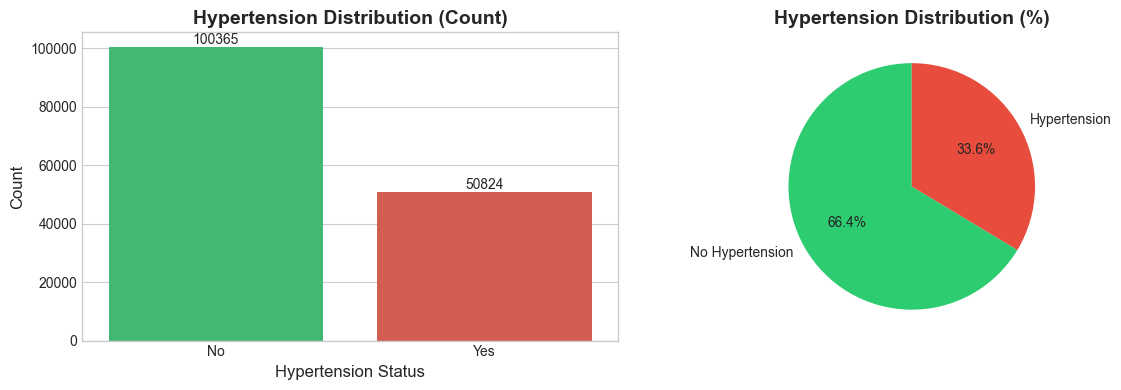

✓ Saved: alcohol_level_distribution.png


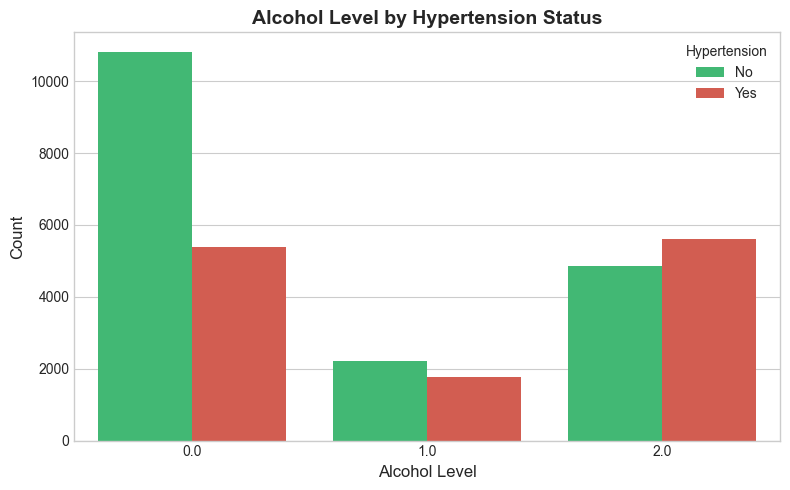

✓ Saved: smoking_level_distribution.png


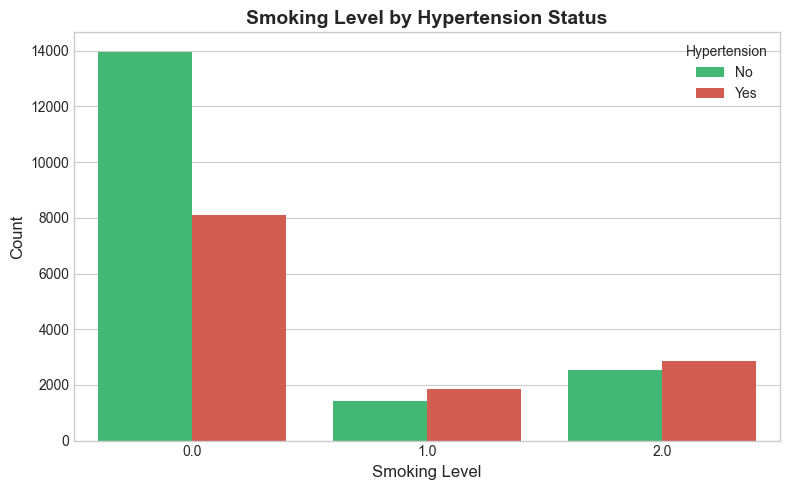


📊 Generating boxplots for 12 key features...


C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_age.png


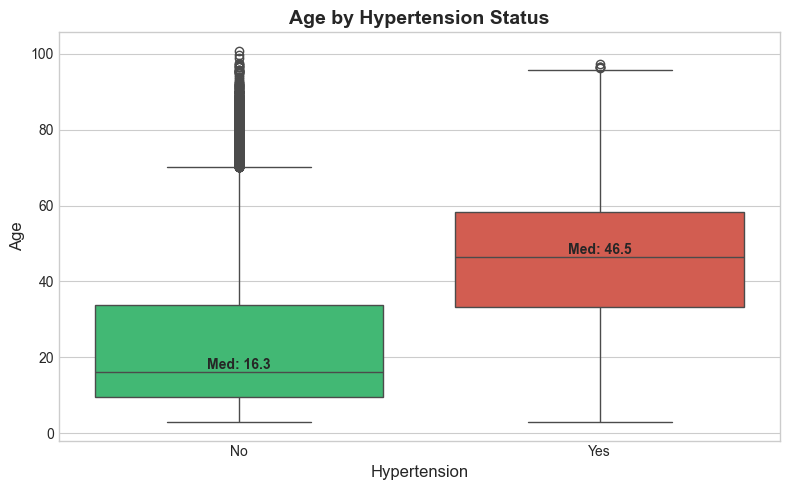

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_strrec.png


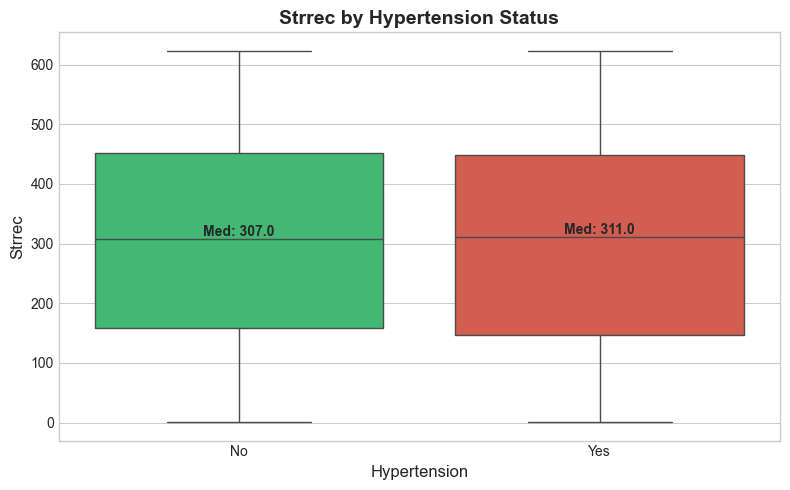

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_psurec.png


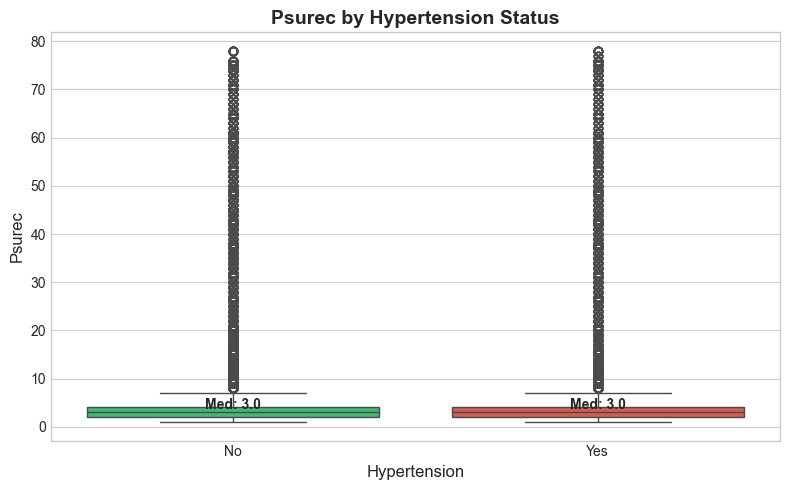

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_provcode.png


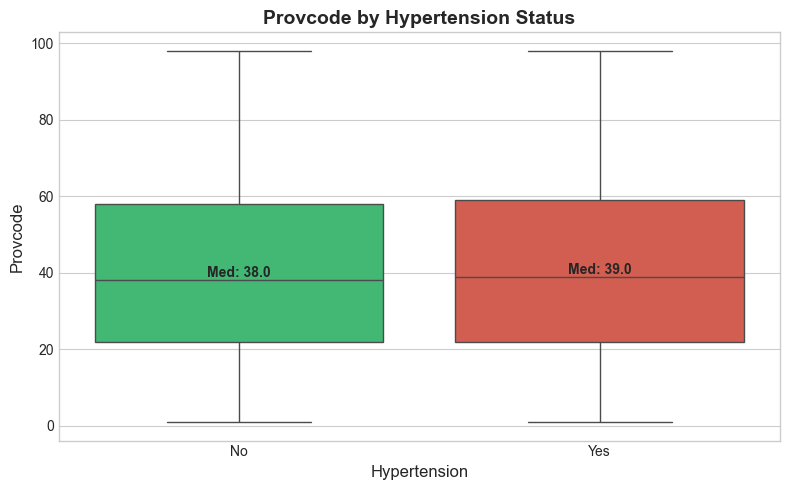

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_finalwgt4.png


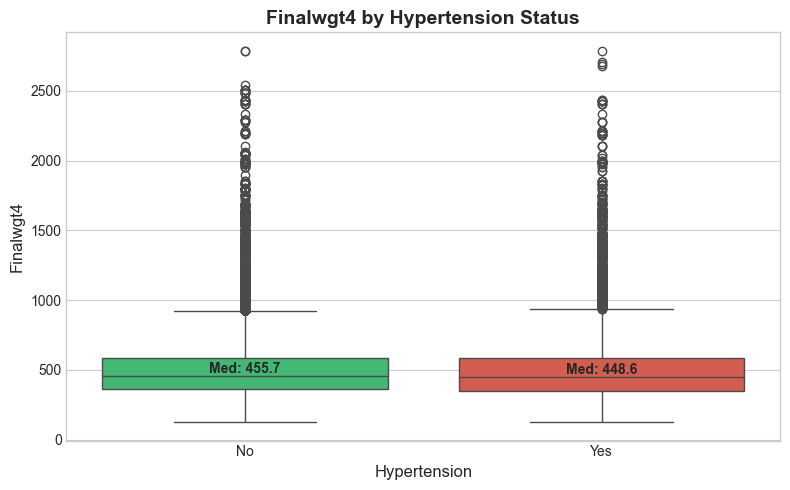

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_finalwgt1.png


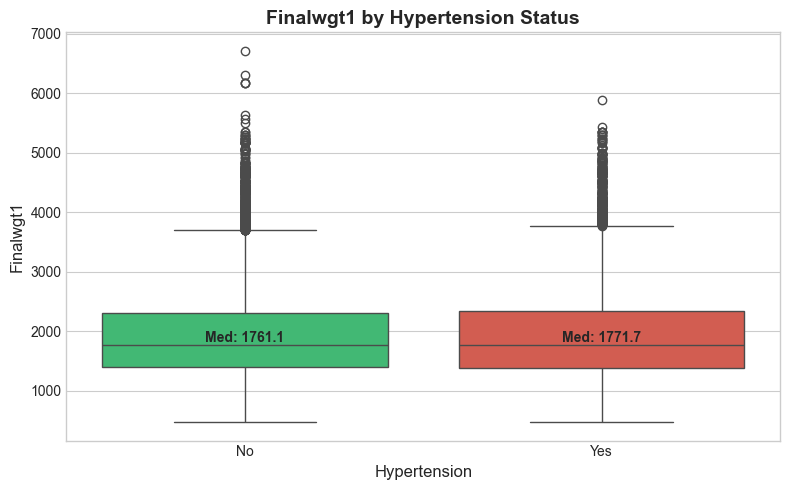

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_current_smoking.png


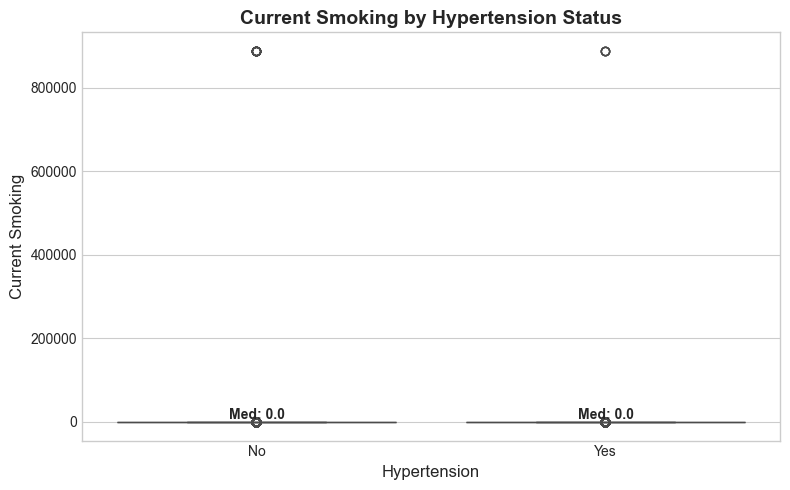

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_binge_drinking.png


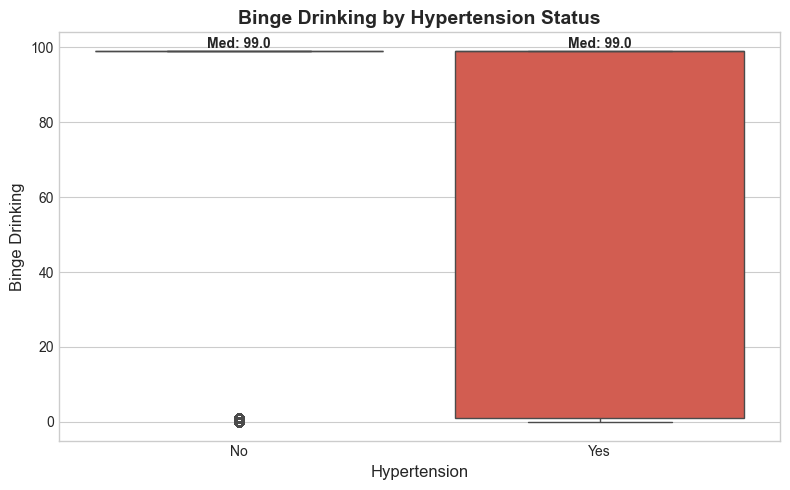

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_Total_Energy.png


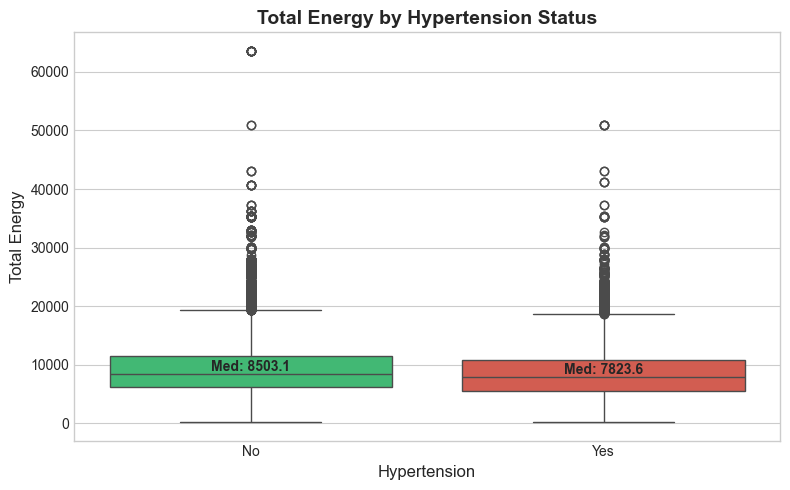

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_Total_Calcium.png


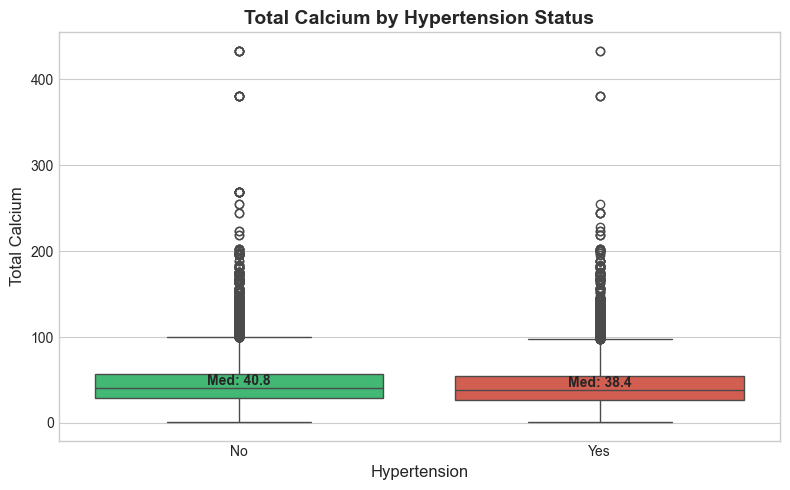

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_Total_CHO.png


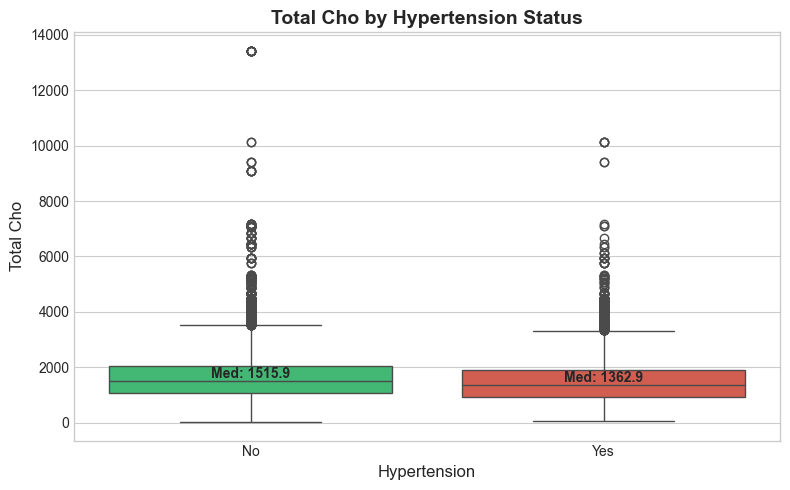

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_18200\1673725081.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])


✓ Saved: boxplot_Total_Fat.png


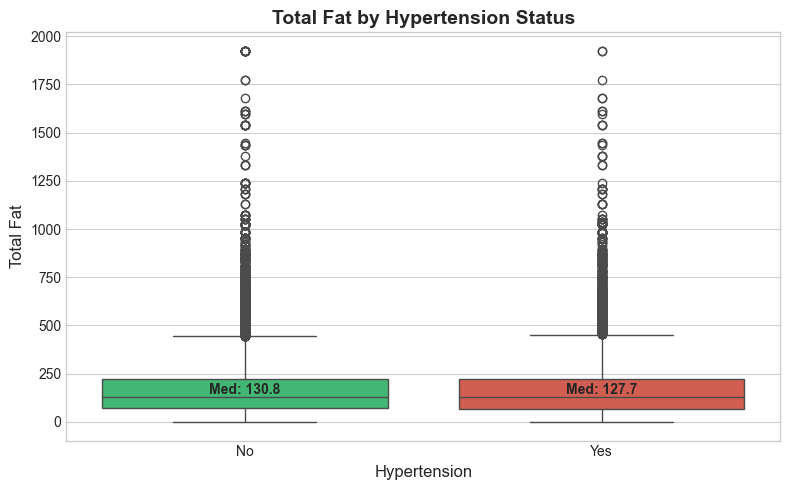


✅ VISUALIZATION COMPLETE!
Generated visualizations:
  • Hypertension distribution (count + pie)
  • Sex distribution (by hypertension + overall)
  • Alcohol level distribution
  • Smoking level distribution
  • 12 boxplots for key continuous features
  • Correlation heatmap for numerical features



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ===============================
# 🧩 1. Setup
# ===============================
plt.style.use('seaborn-v0_8-whitegrid')

# Create a copy for visualization (preserve original)
viz_data = merged_data.copy()

# Ensure categorical columns are of correct dtype
viz_data['Hypertension'] = viz_data['Hypertension'].astype('category')
viz_data['Hypertension'] = viz_data['Hypertension'].map({0: 'No', 1: 'Yes'})

# Define column groups
ordinal_cols = ['alcohol_level', 'smoking_level']
continuous_cols = [col for col in viz_data.columns 
                   if col not in ['Hypertension', 'sex'] + ordinal_cols 
                   and viz_data[col].dtype != 'category']

print(f"📊 Generating visualizations for {len(continuous_cols)} continuous features...")

# ===============================
# 🧩 2. Target Variable Distribution
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=viz_data, x='Hypertension', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Hypertension Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hypertension Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Add count labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
viz_data['Hypertension'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    ax=axes[1], 
    startangle=90, 
    colors=['#2ecc71', '#e74c3c'],
    labels=['No Hypertension', 'Hypertension']
)
axes[1].set_ylabel('')
axes[1].set_title('Hypertension Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('hypertension_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: hypertension_distribution.png")
plt.show()

# ===============================
# 🧩 4. Ordinal Variables (Alcohol & Smoking)
# ===============================
for col in ordinal_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=viz_data, x=col, hue='Hypertension', palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{col.replace("_", " ").title()} by Hypertension Status', fontsize=14, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Hypertension')
    plt.tight_layout()
    plt.savefig(f'{col}_distribution.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {col}_distribution.png")
    plt.show()

# ===============================
# 🧩 5. Key Continuous Variables (Boxplots)
# ===============================
# Prioritize important features
priority_features = ['BMI', 'age', 'waist', 'hip', 'muac', 'tricep', 
                     'subscap', 'glucose', 'cholesterol', 'triglyceride',
                     'hdl', 'ldl', 'uic', 'vita', 'hemoglobin']

# Get available priority features
available_priority = [col for col in priority_features if col in continuous_cols]
other_features = [col for col in continuous_cols if col not in available_priority]

# Show top priority features first
features_to_plot = available_priority + other_features[:max(0, 12 - len(available_priority))]

print(f"\n📊 Generating boxplots for {len(features_to_plot)} key features...")

for col in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=viz_data, x='Hypertension', y=col, palette=['#2ecc71', '#e74c3c'])
    plt.title(f'{col.replace("_", " ").title()} by Hypertension Status', fontsize=14, fontweight='bold')
    plt.xlabel('Hypertension', fontsize=12)
    plt.ylabel(col.replace('_', ' ').title(), fontsize=12)
    
    # Add median values as text
    medians = viz_data.groupby('Hypertension')[col].median()
    for i, (status, median) in enumerate(medians.items()):
        plt.text(i, median, f'Med: {median:.1f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'boxplot_{col}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: boxplot_{col}.png")
    plt.show()

# ===============================
# 🧩 6. Correlation Heatmap (Numerical Features)
# ===============================
# Select key numerical features for correlation
key_numeric_features = [col for col in available_priority + ['Hypertension'] 
                        if col in viz_data.select_dtypes(include=[np.number]).columns]

if len(key_numeric_features) > 3:
    plt.figure(figsize=(12, 10))
    
    # Convert Hypertension back to numeric for correlation
    viz_data_numeric = viz_data.copy()
    viz_data_numeric['Hypertension'] = viz_data_numeric['Hypertension'].map({'No': 0, 'Yes': 1})
    
    correlation_matrix = viz_data_numeric[key_numeric_features].corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix: Key Health Features', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: correlation_heatmap.png")
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZATION COMPLETE!")
print("="*80)
print(f"Generated visualizations:")
print(f"  • Hypertension distribution (count + pie)")
print(f"  • Sex distribution (by hypertension + overall)")
print(f"  • Alcohol level distribution")
print(f"  • Smoking level distribution")
print(f"  • {len(features_to_plot)} boxplots for key continuous features")
print(f"  • Correlation heatmap for numerical features")
print("\n" + "="*80)

In [18]:
merged_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151189 entries, 0 to 151188
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   strrec            151189 non-null  int64   
 1   sex               151189 non-null  int64   
 2   psurec            151189 non-null  int64   
 3   provcode          151189 non-null  int64   
 4   finalwgt4         151189 non-null  float64 
 5   finalwgt1         30757 non-null   float64 
 6   age               151189 non-null  float64 
 7   current_smoking   30757 non-null   float64 
 8   binge_drinking    30757 non-null   float64 
 9   Total_Energy      38013 non-null   float64 
 10  Total_Calcium     38013 non-null   float64 
 11  Total_CHO         38013 non-null   float64 
 12  Total_Fat         38013 non-null   float64 
 13  Total_FoodIntake  38013 non-null   float64 
 14  Total_Iron        38013 non-null   float64 
 15  Total_Niacin      38013 non-null   float64 
 16  Total_Protein

In [19]:
# =====================================================
# 12. ANALYZE BOXPLOT STATISTICS FOR PREDICTOR QUALITY
# =====================================================

print("\n" + "="*80)
print("BOXPLOT STATISTICAL ANALYSIS: Predictor Quality Assessment")
print("="*80)

# Calculate boxplot statistics for each predictor
good_predictors = []
great_predictors = []
excellent_predictors = []

print("\nAnalyzing distribution separation between Hypertension groups...\n")

for col in continuous_cols:
    # Get data for each group
    data_0 = merged_data[merged_data['Hypertension'] == 0][col].dropna()
    data_1 = merged_data[merged_data['Hypertension'] == 1][col].dropna()
    
    if len(data_0) < 5 or len(data_1) < 5:
        continue
    
    # Calculate quartiles and ranges
    q1_0, median_0, q3_0 = data_0.quantile([0.25, 0.5, 0.75])
    q1_1, median_1, q3_1 = data_1.quantile([0.25, 0.5, 0.75])
    
    min_0, max_0 = data_0.min(), data_0.max()
    min_1, max_1 = data_1.min(), data_1.max()
    
    # IQR ranges
    iqr_0 = (q1_0, q3_0)
    iqr_1 = (q1_1, q3_1)
    
    # Check conditions
    # EXCELLENT: Complete range separation (100% outside)
    if (max_0 < min_1) or (max_1 < min_0):
        excellent_predictors.append({
            'column': col,
            'median_0': median_0,
            'median_1': median_1,
            'iqr_0': iqr_0,
            'iqr_1': iqr_1,
            'range_0': (min_0, max_0),
            'range_1': (min_1, max_1),
            'separation': 'Complete range separation'
        })
    
    # GREAT: IQR ranges don't overlap
    elif (q3_0 < q1_1) or (q3_1 < q1_0):
        great_predictors.append({
            'column': col,
            'median_0': median_0,
            'median_1': median_1,
            'iqr_0': iqr_0,
            'iqr_1': iqr_1,
            'separation': 'Complete IQR separation'
        })
    
    # GOOD: Median of one group outside IQR of other
    elif (median_0 < q1_1 or median_0 > q3_1) or (median_1 < q1_0 or median_1 > q3_0):
        good_predictors.append({
            'column': col,
            'median_0': median_0,
            'median_1': median_1,
            'iqr_0': iqr_0,
            'iqr_1': iqr_1,
            'separation': 'Median outside other IQR'
        })

# Display results
print("="*80)
print("🌟 EXCELLENT PREDICTORS (Complete Range Separation)")
print("="*80)
if excellent_predictors:
    for pred in excellent_predictors:
        print(f"\n📌 {pred['column']}")
        print(f"   No Hypertension: range [{pred['range_0'][0]:.2f}, {pred['range_0'][1]:.2f}]")
        print(f"   Hypertension:    range [{pred['range_1'][0]:.2f}, {pred['range_1'][1]:.2f}]")
        print(f"   ✨ {pred['separation']}")
else:
    print("\n   None found")

print("\n" + "="*80)
print("⭐ GREAT PREDICTORS (Complete IQR Separation)")
print("="*80)
if great_predictors:
    for pred in great_predictors:
        print(f"\n📌 {pred['column']}")
        print(f"   No Hypertension: IQR [{pred['iqr_0'][0]:.2f}, {pred['iqr_0'][1]:.2f}], median = {pred['median_0']:.2f}")
        print(f"   Hypertension:    IQR [{pred['iqr_1'][0]:.2f}, {pred['iqr_1'][1]:.2f}], median = {pred['median_1']:.2f}")
        print(f"   ⭐ {pred['separation']}")
else:
    print("\n   None found")

print("\n" + "="*80)
print("✅ GOOD PREDICTORS (Median Outside Other's IQR)")
print("="*80)
if good_predictors:
    for pred in good_predictors:
        print(f"\n📌 {pred['column']}")
        print(f"   No Hypertension: IQR [{pred['iqr_0'][0]:.2f}, {pred['iqr_0'][1]:.2f}], median = {pred['median_0']:.2f}")
        print(f"   Hypertension:    IQR [{pred['iqr_1'][0]:.2f}, {pred['iqr_1'][1]:.2f}], median = {pred['median_1']:.2f}")
        print(f"   ✅ {pred['separation']}")
else:
    print("\n   None found")

# Summary statistics
print("\n" + "="*80)
print("📊 PREDICTOR QUALITY SUMMARY")
print("="*80)
print(f"\n  Excellent Predictors: {len(excellent_predictors)}")
print(f"  Great Predictors: {len(great_predictors)}")
print(f"  Good Predictors: {len(good_predictors)}")
print(f"  Total Strong Predictors: {len(excellent_predictors) + len(great_predictors) + len(good_predictors)}")
print(f"  Total Predictors Analyzed: {len(continuous_cols)}")
print(f"  Percentage of Strong Predictors: {((len(excellent_predictors) + len(great_predictors) + len(good_predictors)) / len(continuous_cols) * 100):.2f}%")

# Create lists for easy reference
excellent_cols = [p['column'] for p in excellent_predictors]
great_cols = [p['column'] for p in great_predictors]
good_cols = [p['column'] for p in good_predictors]
all_strong_predictors = excellent_cols + great_cols + good_cols

print("\n" + "="*80)
print("📋 QUICK REFERENCE LISTS")
print("="*80)
print(f"\nExcellent predictor columns:\n{excellent_cols}")
print(f"\nGreat predictor columns:\n{great_cols}")
print(f"\nGood predictor columns (first 20):\n{good_cols[:20]}")
if len(good_cols) > 20:
    print(f"... and {len(good_cols) - 20} more")

print("\n" + "="*80)


BOXPLOT STATISTICAL ANALYSIS: Predictor Quality Assessment

Analyzing distribution separation between Hypertension groups...

🌟 EXCELLENT PREDICTORS (Complete Range Separation)

   None found

⭐ GREAT PREDICTORS (Complete IQR Separation)

   None found

✅ GOOD PREDICTORS (Median Outside Other's IQR)

📌 age
   No Hypertension: IQR [9.66, 33.87], median = 16.29
   Hypertension:    IQR [33.15, 58.24], median = 46.50
   ✅ Median outside other IQR

📊 PREDICTOR QUALITY SUMMARY

  Excellent Predictors: 0
  Great Predictors: 0
  Good Predictors: 1
  Total Strong Predictors: 1
  Total Predictors Analyzed: 22
  Percentage of Strong Predictors: 4.55%

📋 QUICK REFERENCE LISTS

Excellent predictor columns:
[]

Great predictor columns:
[]

Good predictor columns (first 20):
['age']




OUTLIER ANALYSIS: Per Column Assessment

Analyzing outliers for each numerical predictor...

📊 OUTLIER ANALYSIS RESULTS (Top 30 by Outlier Percentage)

Column                                   Total N    Outliers   % Outliers   Avg Dist %  
------------------------------------------------------------------------------------
 1. binge_drinking                        30757      6094            19.81%      99.45%
 2. current_smoking                       30757      5404            17.57%       0.31%
 3. Total_VitaminA                        38013      2897             7.62%       5.69%
 4. psurec                                151189     11045            7.31%      26.86%
 5. Total_VitaminC                        38013      2196             5.78%       4.72%
 6. Total_Iron                            38013      2154             5.67%       3.76%
 7. Total_Thiamin                         38013      2020             5.31%      11.84%
 8. Total_Riboflavin                      38013      2019

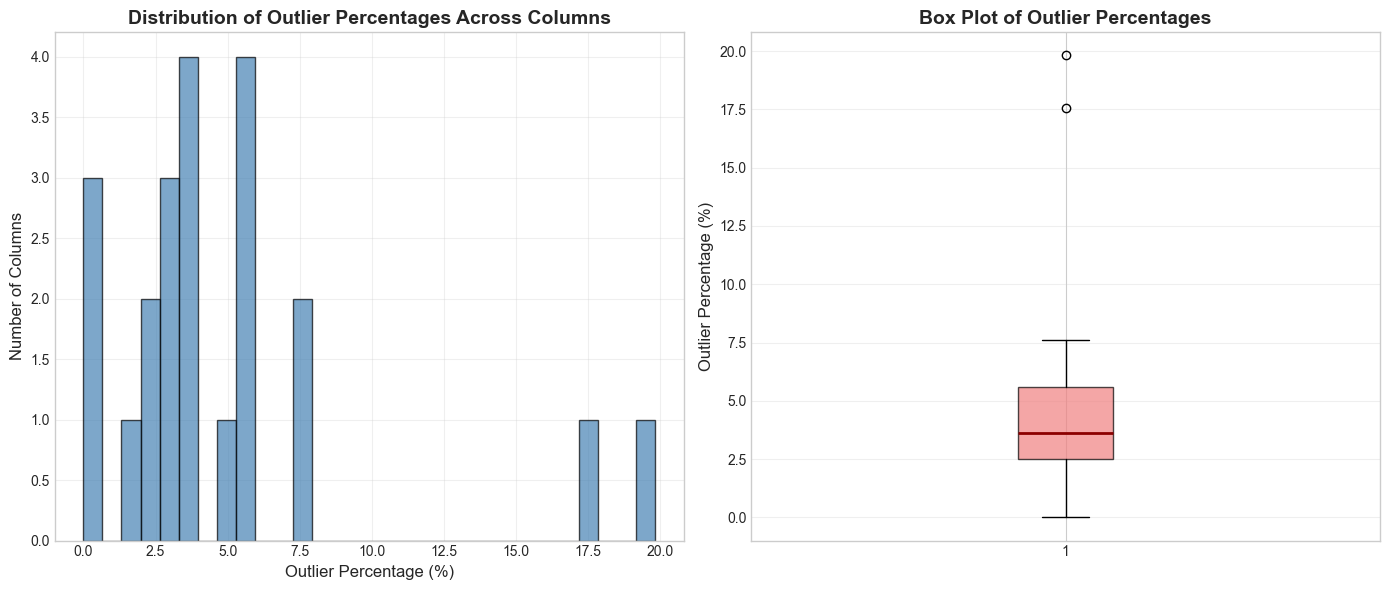

In [20]:
# =====================================================
# 13. OUTLIER ANALYSIS BY COLUMN
# =====================================================

print("\n" + "="*80)
print("OUTLIER ANALYSIS: Per Column Assessment")
print("="*80)

# Function to calculate outliers using IQR method
def calculate_outliers(data):
    """Calculate outliers using IQR method (1.5 * IQR)"""
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    return {
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers': outliers,
        'n_outliers': len(outliers),
        'pct_outliers': (len(outliers) / len(data)) * 100 if len(data) > 0 else 0
    }

def calculate_outlier_distance(outliers, lower_bound, upper_bound):
    """Calculate average distance of outliers from bounds"""
    if len(outliers) == 0:
        return 0
    
    distances = []
    for val in outliers:
        if val < lower_bound:
            distances.append(abs(val - lower_bound))
        elif val > upper_bound:
            distances.append(abs(val - upper_bound))
    
    return np.mean(distances) if distances else 0

# Analyze outliers for each numerical column
outlier_analysis = []

print("\nAnalyzing outliers for each numerical predictor...\n")

for col in continuous_cols:
    data = merged_data[col].dropna()
    
    if len(data) < 10:  # Skip columns with too few values
        continue
    
    outlier_info = calculate_outliers(data)
    
    # Calculate average distance of outliers from bounds as percentage of range
    if outlier_info['n_outliers'] > 0:
        avg_distance = calculate_outlier_distance(
            outlier_info['outliers'], 
            outlier_info['lower_bound'], 
            outlier_info['upper_bound']
        )
        
        # Calculate as percentage of data range
        data_range = data.max() - data.min()
        avg_distance_pct = (avg_distance / data_range * 100) if data_range > 0 else 0
    else:
        avg_distance = 0
        avg_distance_pct = 0
    
    outlier_analysis.append({
        'column': col,
        'n_total': len(data),
        'n_outliers': outlier_info['n_outliers'],
        'pct_outliers': outlier_info['pct_outliers'],
        'lower_bound': outlier_info['lower_bound'],
        'upper_bound': outlier_info['upper_bound'],
        'avg_distance': avg_distance,
        'avg_distance_pct': avg_distance_pct
    })

# Sort by percentage of outliers (descending)
outlier_analysis_sorted = sorted(outlier_analysis, key=lambda x: x['pct_outliers'], reverse=True)

# Display results
print("="*80)
print("📊 OUTLIER ANALYSIS RESULTS (Top 30 by Outlier Percentage)")
print("="*80)
print(f"\n{'Column':<40} {'Total N':<10} {'Outliers':<10} {'% Outliers':<12} {'Avg Dist %':<12}")
print("-" * 84)

for i, info in enumerate(outlier_analysis_sorted[:30], 1):
    print(f"{i:2}. {info['column']:<37} {info['n_total']:<10} {info['n_outliers']:<10} "
          f"{info['pct_outliers']:>10.2f}% {info['avg_distance_pct']:>10.2f}%")

# Overall statistics
print("\n" + "="*80)
print("📈 OVERALL OUTLIER STATISTICS")
print("="*80)

total_outliers = sum(info['n_outliers'] for info in outlier_analysis)
total_values = sum(info['n_total'] for info in outlier_analysis)
avg_outlier_pct = np.mean([info['pct_outliers'] for info in outlier_analysis])
avg_distance_pct = np.mean([info['avg_distance_pct'] for info in outlier_analysis if info['n_outliers'] > 0])

print(f"\nTotal data points analyzed: {total_values:,}")
print(f"Total outliers found: {total_outliers:,}")
print(f"Overall outlier percentage: {(total_outliers/total_values*100):.2f}%")
print(f"Average outlier percentage per column: {avg_outlier_pct:.2f}%")
print(f"Average distance of outliers from bounds (% of range): {avg_distance_pct:.2f}%")

# Columns with highest outlier percentages
print("\n" + "="*80)
print("⚠️  COLUMNS WITH HIGHEST OUTLIER PERCENTAGES (>10%)")
print("="*80)

high_outlier_cols = [info for info in outlier_analysis_sorted if info['pct_outliers'] > 10]

if high_outlier_cols:
    print(f"\nFound {len(high_outlier_cols)} columns with >10% outliers:\n")
    for info in high_outlier_cols:
        print(f"{info['column']}")
        print(f"   Outliers: {info['n_outliers']:,} / {info['n_total']:,} ({info['pct_outliers']:.2f}%)")
        print(f"   Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
        print(f"   Avg outlier distance: {info['avg_distance']:.2f} ({info['avg_distance_pct']:.2f}% of range)")
        print()
else:
    print("\n   No columns with >10% outliers found")

# Columns with lowest outlier percentages
print("="*80)
print("COLUMNS WITH LOWEST OUTLIER PERCENTAGES (<2%)")
print("="*80)

low_outlier_cols = [info for info in outlier_analysis_sorted if info['pct_outliers'] < 2][-20:]

if low_outlier_cols:
    print(f"\nShowing 20 columns with <2% outliers:\n")
    for info in reversed(low_outlier_cols):
        print(f"  {info['column']:<40} {info['pct_outliers']:>6.2f}% outliers")
else:
    print("\n   All columns have >=2% outliers")

# Distribution of outlier percentages
print("\n" + "="*80)
print("DISTRIBUTION OF OUTLIER PERCENTAGES")
print("="*80)

outlier_pcts = [info['pct_outliers'] for info in outlier_analysis]

print(f"\nMin:    {min(outlier_pcts):.2f}%")
print(f"Q1:     {np.percentile(outlier_pcts, 25):.2f}%")
print(f"Median: {np.percentile(outlier_pcts, 50):.2f}%")
print(f"Q3:     {np.percentile(outlier_pcts, 75):.2f}%")
print(f"Max:    {max(outlier_pcts):.2f}%")
print(f"Mean:   {np.mean(outlier_pcts):.2f}%")
print(f"Std:    {np.std(outlier_pcts):.2f}%")

# Visualize outlier percentages
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(outlier_pcts, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Outlier Percentage (%)', fontsize=12)
plt.ylabel('Number of Columns', fontsize=12)
plt.title('Distribution of Outlier Percentages Across Columns', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(1, 2, 2)
plt.boxplot(outlier_pcts, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7),
            medianprops=dict(color='darkred', linewidth=2))
plt.ylabel('Outlier Percentage (%)', fontsize=12)
plt.title('Box Plot of Outlier Percentages', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outlier_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: outlier_analysis.png")
plt.show()

In [21]:
!pip install scikit-learn

In [22]:
# =====================================================
# 12. ENCODE CATEGORICAL VARIABLES (BEFORE SPLIT)
# =====================================================

print("\n" + "="*80)
print("ENCODING CATEGORICAL VARIABLES (ONE-HOT)")
print("="*80)

# Identify categorical columns (exclude target)
categorical_cols = merged_data.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Hypertension' in categorical_cols:
    categorical_cols.remove('Hypertension')

print(f"\n📊 Found {len(categorical_cols)} categorical columns to one-hot encode:")
for col in categorical_cols:
    n_unique = merged_data[col].nunique(dropna=True)
    print(f"   • {col}: {n_unique} unique values")

# Create encoded dataset with one-hot encoding
if categorical_cols:
    merged_data_encoded = pd.get_dummies(
        merged_data,
        columns=categorical_cols,
        dummy_na=True,
        drop_first=False
    )
else:
    merged_data_encoded = merged_data.copy()

print("\n" + "="*80)
print("✅ ONE-HOT ENCODING COMPLETE!")
print("="*80)
print(f"\nOriginal dataset: {merged_data.shape}")
print(f"Encoded dataset:  {merged_data_encoded.shape}")
print(f"Added columns:    {merged_data_encoded.shape[1] - merged_data.shape[1]}")

# Verify all columns are numeric-compatible (except target remains numeric)
print(f"\n📋 Data Type Summary (after encoding):")
dtype_counts = merged_data_encoded.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print("\n" + "="*80)


ENCODING CATEGORICAL VARIABLES (ONE-HOT)

📊 Found 2 categorical columns to one-hot encode:
   • alcohol_level: 3 unique values
   • smoking_level: 3 unique values

✅ ONE-HOT ENCODING COMPLETE!

Original dataset: (151189, 26)
Encoded dataset:  (151189, 32)
Added columns:    6

📋 Data Type Summary (after encoding):
   float64: 19 columns
   bool: 8 columns
   int64: 5 columns



In [23]:
# ================================================
# Cell 14: DATA SPLIT (Train 70% / Cal 15% / Test 15%)
# ================================================
from sklearn.model_selection import train_test_split

TARGET_COL = 'Hypertension'

data_for_split = merged_data_encoded if 'merged_data_encoded' in globals() else merged_data
if 'merged_data_encoded' not in globals():
    print("Warning: merged_data_encoded not found; using merged_data for split.")

X_full = data_for_split.drop(columns=[TARGET_COL])
y_full = data_for_split[TARGET_COL]

# Hold out final test set (15%)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_full, y_full,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=y_full
)

# From remaining 85%, carve calibration = 15% of original (i.e. 0.15/0.85 ≈ 0.17647)
cal_rel = 0.15 / 0.85
X_train, X_cal, y_train, y_cal = train_test_split(
    X_tmp, y_tmp,
    test_size=cal_rel,
    random_state=RANDOM_SEED,
    stratify=y_tmp
)

print("Shapes:")
print(f"  X_train: {X_train.shape}  X_cal: {X_cal.shape}  X_test: {X_test.shape}")
print("Percentages:",
      f"Train={len(X_train)/len(X_full)*100:.2f}%",
      f"Cal={len(X_cal)/len(X_full)*100:.2f}%",
      f"Test={len(X_test)/len(X_full)*100:.2f}%")

# X_train / y_train -> ONLY for CV + model selection
# X_cal / y_cal -> ONLY for calibration (untouched by training)
# X_test / y_test -> ONLY for final evaluation

Shapes:
  X_train: (105831, 31)  X_cal: (22679, 31)  X_test: (22679, 31)
Percentages: Train=70.00% Cal=15.00% Test=15.00%


In [24]:
# =====================================================
# 15. CALCULATE 1% AND 99% PERCENTILES FROM TRAIN SET
# =====================================================

print("\n" + "="*80)
print("CALCULATING OUTLIER THRESHOLDS (1% & 99% PERCENTILES)")
print("="*80)

# Get continuous columns from training set (exclude categorical)
continuous_train_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 Analyzing {len(continuous_train_cols)} continuous features from TRAINING SET")

# Calculate percentiles for each continuous column
percentile_thresholds = {}

print("\n📋 Calculated thresholds (showing first 20 columns):")
print(f"{'Column':<40} {'1% Threshold':<15} {'99% Threshold':<15}")
print("-" * 70)

for i, col in enumerate(continuous_train_cols):
    # Calculate 1st and 99th percentiles from TRAINING data only
    p1 = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    
    percentile_thresholds[col] = {
        'p1': p1,
        'p99': p99
    }
    
    # Display first 20
    if i < 20:
        print(f"{col:<40} {p1:<15.4f} {p99:<15.4f}")

if len(continuous_train_cols) > 20:
    print(f"\n... and {len(continuous_train_cols) - 20} more columns")

# Summary statistics
print("\n" + "="*80)
print("📈 THRESHOLD STATISTICS")
print("="*80)

all_p1 = [v['p1'] for v in percentile_thresholds.values()]
all_p99 = [v['p99'] for v in percentile_thresholds.values()]

print(f"\n1st Percentile Thresholds:")
print(f"  Min:    {min(all_p1):.4f}")
print(f"  Median: {np.median(all_p1):.4f}")
print(f"  Max:    {max(all_p1):.4f}")

print(f"\n99th Percentile Thresholds:")
print(f"  Min:    {min(all_p99):.4f}")
print(f"  Median: {np.median(all_p99):.4f}")
print(f"  Max:    {max(all_p99):.4f}")

print("\n✅ Thresholds calculated from TRAINING SET only (no data leakage)")
print("\n" + "="*80)


CALCULATING OUTLIER THRESHOLDS (1% & 99% PERCENTILES)

📊 Analyzing 23 continuous features from TRAINING SET

📋 Calculated thresholds (showing first 20 columns):
Column                                   1% Threshold    99% Threshold  
----------------------------------------------------------------------
strrec                                   7.0000          613.0000       
sex                                      1.0000          2.0000         
psurec                                   1.0000          56.0000        
provcode                                 2.0000          83.0000        
finalwgt4                                170.4422        1120.6381      
finalwgt1                                683.0543        4347.2289      
age                                      3.5000          79.8000        
current_smoking                          0.0000          3.0000         
binge_drinking                           0.0000          99.0000        
Total_Energy                         

In [25]:
# =====================================================
# 16. IMPUTE OUTLIERS IN TRAINING SET (1% & 99% CLIPPING)
# =====================================================

print("\n" + "="*80)
print("IMPUTING OUTLIERS IN TRAINING SET")
print("="*80)

# Create a copy to preserve original
X_train_clipped = X_train.copy()

# Track imputation statistics
imputation_stats = []

print("\n🔧 Clipping outliers in training set...")

for col in continuous_train_cols:
    # Get thresholds
    lower_bound = percentile_thresholds[col]['p1']
    upper_bound = percentile_thresholds[col]['p99']
    
    # Count outliers before clipping
    n_below = (X_train_clipped[col] < lower_bound).sum()
    n_above = (X_train_clipped[col] > upper_bound).sum()
    n_total_outliers = n_below + n_above
    
    # Clip values
    X_train_clipped[col] = X_train_clipped[col].clip(lower=lower_bound, upper=upper_bound)
    
    # Store stats
    if n_total_outliers > 0:
        imputation_stats.append({
            'column': col,
            'n_below': n_below,
            'n_above': n_above,
            'n_total': n_total_outliers,
            'pct_clipped': (n_total_outliers / len(X_train_clipped)) * 100
        })

# Sort by number of outliers
imputation_stats_sorted = sorted(imputation_stats, key=lambda x: x['n_total'], reverse=True)

# Display results
print("\n" + "="*80)
print("📊 IMPUTATION RESULTS (Top 20 Columns by Outliers Clipped)")
print("="*80)
print(f"\n{'Column':<40} {'Below 1%':<12} {'Above 99%':<12} {'Total':<10} {'% Clipped'}")
print("-" * 84)

for i, stat in enumerate(imputation_stats_sorted[:20], 1):
    print(f"{i:2}. {stat['column']:<37} {stat['n_below']:<12} {stat['n_above']:<12} "
          f"{stat['n_total']:<10} {stat['pct_clipped']:>8.2f}%")

if len(imputation_stats_sorted) > 20:
    print(f"\n... and {len(imputation_stats_sorted) - 20} more columns with outliers")

# Overall statistics
print("\n" + "="*80)
print("📈 OVERALL IMPUTATION SUMMARY")
print("="*80)

total_outliers_clipped = sum(stat['n_total'] for stat in imputation_stats)
total_values = len(X_train_clipped) * len(continuous_train_cols)
total_below = sum(stat['n_below'] for stat in imputation_stats)
total_above = sum(stat['n_above'] for stat in imputation_stats)

print(f"\nTotal values in training set: {total_values:,}")
print(f"Total outliers clipped: {total_outliers_clipped:,}")
print(f"  Below 1%: {total_below:,}")
print(f"  Above 99%: {total_above:,}")
print(f"Overall clipping rate: {(total_outliers_clipped/total_values*100):.2f}%")
print(f"\nColumns affected: {len(imputation_stats)}/{len(continuous_train_cols)}")

print("\n✅ Training set outliers clipped successfully!")
print(f"✅ Data intensity retained (values scaled to 1% and 99% boundaries)")
print("\n" + "="*80)


IMPUTING OUTLIERS IN TRAINING SET

🔧 Clipping outliers in training set...

📊 IMPUTATION RESULTS (Top 20 Columns by Outliers Clipped)

Column                                   Below 1%     Above 99%    Total      % Clipped
------------------------------------------------------------------------------------
 1. age                                   1057         1057         2114           2.00%
 2. finalwgt4                             1058         1054         2112           2.00%
 3. strrec                                974          1015         1989           1.88%
 4. provcode                              786          337          1123           1.06%
 5. psurec                                0            1024         1024           0.97%
 6. Total_CHO                             267          267          534            0.50%
 7. Total_Fat                             267          266          533            0.50%
 8. Total_Iron                            267          266          5

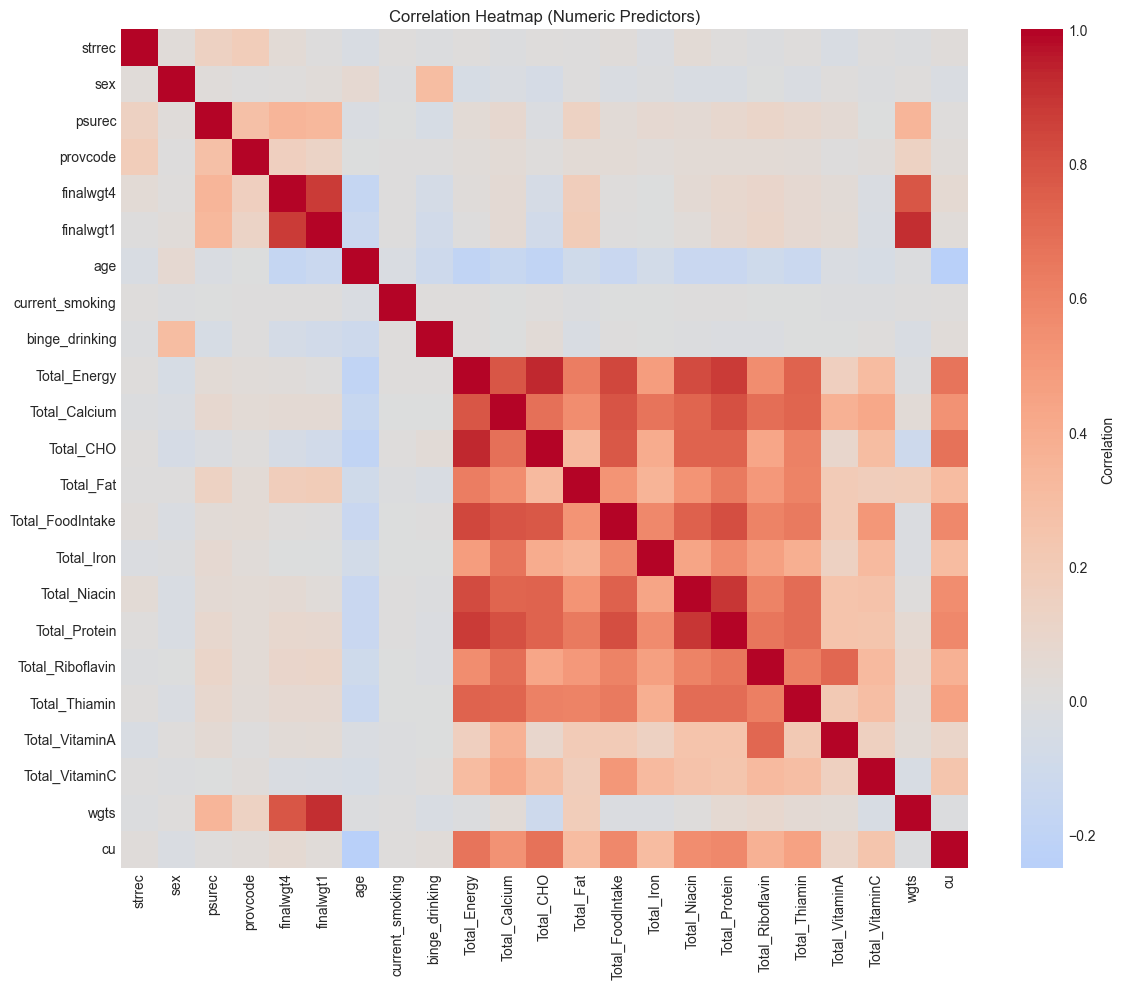

Top 20 VIFs:
Total_Energy        2949.123220
Total_CHO           1609.424271
Total_Fat            288.470615
Total_Protein         62.524457
finalwgt1             11.581365
wgts                   7.078073
Total_Niacin           6.107247
Total_Calcium          5.693499
Total_FoodIntake       5.632906
Total_Riboflavin       5.596901
finalwgt4              4.706858
Total_Thiamin          3.318326
Total_VitaminA         3.183171
Total_Iron             2.223624
cu                     1.974508
Total_VitaminC         1.665456
psurec                 1.269361
age                    1.226979
binge_drinking         1.180419
sex                    1.134521
dtype: float64


In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Collinearity checks on numeric predictors
num_df = merged_data.select_dtypes(include=[np.number]).copy()

# Exclude IDs/targets if present
exclude_cols = [c for c in ["Hypertension", "enns_year", "hhnum", "member_code"] if c in num_df.columns]
num_df = num_df.drop(columns=exclude_cols, errors="ignore")

# Reduce size for speed if needed
if len(num_df) > 50000:
    num_df = num_df.sample(50000, random_state=RANDOM_SEED)

# Drop rows with missing values for correlation/VIF
num_df = num_df.dropna()

# Correlation matrix + heatmap
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap (Numeric Predictors)")
plt.tight_layout()
plt.show()

# VIF calculation using OLS (no extra dependencies)
def compute_vif(df):
    X = df.values
    vifs = []
    for i in range(X.shape[1]):
        y = X[:, i]
        X_other = np.delete(X, i, axis=1)
        X_other = np.column_stack([np.ones(X_other.shape[0]), X_other])
        beta, *_ = np.linalg.lstsq(X_other, y, rcond=None)
        y_hat = X_other @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vifs.append(vif)
    return pd.Series(vifs, index=df.columns).sort_values(ascending=False)

vif = compute_vif(num_df)
print("Top 20 VIFs:")
print(vif.head(20))

In [27]:
# Find high correlation pairs (|r| > 0.6)
threshold = 0.6
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature_1': corr.columns[i],
                'Feature_2': corr.columns[j],
                'Correlation': corr.iloc[i, j],
                'Abs_Correlation': abs(corr.iloc[i, j])
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Abs_Correlation', ascending=False)

print(f"Found {len(high_corr_df)} pairs with |correlation| > {threshold}\n")
print("Top 30 highly correlated pairs:")
print(high_corr_df.head(30).to_string(index=False))

Found 36 pairs with |correlation| > 0.6

Top 30 highly correlated pairs:
       Feature_1        Feature_2  Correlation  Abs_Correlation
    Total_Energy        Total_CHO     0.933700         0.933700
       finalwgt1             wgts     0.913752         0.913752
    Total_Niacin    Total_Protein     0.896080         0.896080
       finalwgt4        finalwgt1     0.880378         0.880378
    Total_Energy    Total_Protein     0.875276         0.875276
    Total_Energy Total_FoodIntake     0.838321         0.838321
    Total_Energy     Total_Niacin     0.823188         0.823188
Total_FoodIntake    Total_Protein     0.811481         0.811481
   Total_Calcium    Total_Protein     0.805404         0.805404
   Total_Calcium Total_FoodIntake     0.790024         0.790024
    Total_Energy    Total_Calcium     0.785140         0.785140
       finalwgt4             wgts     0.782687         0.782687
       Total_CHO Total_FoodIntake     0.771441         0.771441
Total_FoodIntake     Total_Niac

In [28]:
# Columns to drop based on high correlation & VIF analysis
cols_to_drop = [
    # Total food weight (sum of all epwt_fg* → infinite VIF)
    'Total_Food_epwt',
    'Total_Ener',  # 0.928 with Total_CHO, 0.764 with Total_Nia
    'Total_Prot', # 0.883 with Total_Nia
    'Total_Fat',  # 0.800 with Total_VitA
    'Total_Iron', # 0.850 with Total_Zinc


    
    # Highly correlated food group pairs (drop one from each)
    'epwt_fg25',  # 0.986 with epwt_fg24
    'epwt_fg13',  # 0.946 with epwt_fg11
    'epwt_fg10',  # 0.878 with epwt_fg8
    'epwt_fg2',   # 0.900 with epwt_fg1
    'epwt_fg19',  # 0.871 with epwt_fg18
    'epwt_fg16 ',
    
    # Redundant nutrient totals
    'Total_CHO',  # 0.946 with epwt_fg1, 0.928 with Total_Ener
    'Total_Nia',  # 0.883 with Total_Prot, 0.764 with Total_Ener
    'Total_Ribo', # 0.800 with Total_VitA
    
    # Anthropometric redundancy
    'hip',        # 0.871 with BMI, 0.849 with waist
    'waist',      # 0.890 with BMI, 0.849 with hip
    
    # Biochemical redundancy
    'chol',       # 0.855 with ldl (keep ldl as more specific)
]

# Check which columns actually exist in the dataset
existing_drops = [col for col in cols_to_drop if col in merged_data.columns]
missing_drops = [col for col in cols_to_drop if col not in merged_data.columns]

print(f"Dropping {len(existing_drops)} highly correlated columns:\n")
for col in existing_drops:
    print(f"  - {col}")

if missing_drops:
    print(f"\n⚠️  Columns not found (skipped): {missing_drops}")

# Store original shape
original_shape = merged_data.shape

# Drop columns
merged_data = merged_data.drop(columns=existing_drops, errors='ignore')

print(f"\n✓ Shape: {original_shape} → {merged_data.shape}")
print(f"  Removed {original_shape[1] - merged_data.shape[1]} columns")

Dropping 3 highly correlated columns:

  - Total_Fat
  - Total_Iron
  - Total_CHO

⚠️  Columns not found (skipped): ['Total_Food_epwt', 'Total_Ener', 'Total_Prot', 'epwt_fg25', 'epwt_fg13', 'epwt_fg10', 'epwt_fg2', 'epwt_fg19', 'epwt_fg16 ', 'Total_Nia', 'Total_Ribo', 'hip', 'waist', 'chol']

✓ Shape: (151189, 26) → (151189, 23)
  Removed 3 columns


In [29]:
# Verify collinearity reduction
print("Checking remaining high correlations (|r| > 0.6)...\n")

# Recompute correlation on numeric features
num_df_reduced = merged_data.select_dtypes(include=[np.number]).copy()
exclude_cols = [c for c in ["Hypertension", "enns_year", "hhnum", "member_code"] if c in num_df_reduced.columns]
num_df_reduced = num_df_reduced.drop(columns=exclude_cols, errors="ignore")

if len(num_df_reduced) > 50000:
    num_df_reduced = num_df_reduced.sample(50000, random_state=RANDOM_SEED)

num_df_reduced = num_df_reduced.dropna()
corr_reduced = num_df_reduced.corr(numeric_only=True)

# Find remaining high correlations
high_corr_remaining = []
for i in range(len(corr_reduced.columns)):
    for j in range(i + 1, len(corr_reduced.columns)):
        if abs(corr_reduced.iloc[i, j]) > 0.6:
            high_corr_remaining.append({
                'Feature_1': corr_reduced.columns[i],
                'Feature_2': corr_reduced.columns[j],
                'Correlation': corr_reduced.iloc[i, j]
            })

print(f"Remaining pairs with |r| > 0.6: {len(high_corr_remaining)}")

if high_corr_remaining:
    high_corr_remaining_df = pd.DataFrame(high_corr_remaining).sort_values('Correlation', key=abs, ascending=False)
    print("\nTop 10 remaining high correlations:")
    print(high_corr_remaining_df.head(10).to_string(index=False))
else:
    print("\n✓ No feature pairs with |r| > 0.6 remain!")

Checking remaining high correlations (|r| > 0.6)...

Remaining pairs with |r| > 0.6: 25

Top 10 remaining high correlations:
       Feature_1        Feature_2  Correlation
       finalwgt1             wgts     0.913752
    Total_Niacin    Total_Protein     0.896080
       finalwgt4        finalwgt1     0.880378
    Total_Energy    Total_Protein     0.875276
    Total_Energy Total_FoodIntake     0.838321
    Total_Energy     Total_Niacin     0.823188
Total_FoodIntake    Total_Protein     0.811481
   Total_Calcium    Total_Protein     0.805404
   Total_Calcium Total_FoodIntake     0.790024
    Total_Energy    Total_Calcium     0.785140


In [30]:
# =====================================================
# 17. APPLY SAME CLIPPING TO CAL/TEST SETS (NO DATA LEAKAGE)
# =====================================================

print("\n" + "="*80)
print("APPLYING CLIPPING TO CAL/TEST SETS")
print("="*80)

def clip_with_thresholds(X, thresholds, columns):
    X_clipped = X.copy()
    stats = []
    for col in columns:
        lower_bound = thresholds[col]['p1']
        upper_bound = thresholds[col]['p99']
        n_below = (X_clipped[col] < lower_bound).sum()
        n_above = (X_clipped[col] > upper_bound).sum()
        n_total_outliers = n_below + n_above
        X_clipped[col] = X_clipped[col].clip(lower=lower_bound, upper=upper_bound)
        if n_total_outliers > 0:
            stats.append({
                'column': col,
                'n_below': n_below,
                'n_above': n_above,
                'n_total': n_total_outliers,
                'pct_clipped': (n_total_outliers / len(X_clipped)) * 100
            })
    return X_clipped, stats

# Create copies to preserve originals
X_cal_clipped, cal_imputation_stats = clip_with_thresholds(X_cal, percentile_thresholds, continuous_train_cols)
X_test_clipped, test_imputation_stats = clip_with_thresholds(X_test, percentile_thresholds, continuous_train_cols)

# Sort by number of outliers
cal_imputation_stats_sorted = sorted(cal_imputation_stats, key=lambda x: x['n_total'], reverse=True)
test_imputation_stats_sorted = sorted(test_imputation_stats, key=lambda x: x['n_total'], reverse=True)

# Display CAL results
print("\n" + "="*80)
print(" CAL SET IMPUTATION RESULTS (Top 20 Columns)")
print("="*80)
print(f"\n{'Column':<40} {'Below 1%':<12} {'Above 99%':<12} {'Total':<10} {'% Clipped'}")
print("-" * 84)
for i, stat in enumerate(cal_imputation_stats_sorted[:20], 1):
    print(f"{i:2}. {stat['column']:<37} {stat['n_below']:<12} {stat['n_above']:<12} "
          f"{stat['n_total']:<10} {stat['pct_clipped']:>8.2f}%")
if len(cal_imputation_stats_sorted) > 20:
    print(f"\n... and {len(cal_imputation_stats_sorted) - 20} more columns with outliers")

# Display TEST results
print("\n" + "="*80)
print(" TEST SET IMPUTATION RESULTS (Top 20 Columns)")
print("="*80)
print(f"\n{'Column':<40} {'Below 1%':<12} {'Above 99%':<12} {'Total':<10} {'% Clipped'}")
print("-" * 84)
for i, stat in enumerate(test_imputation_stats_sorted[:20], 1):
    print(f"{i:2}. {stat['column']:<37} {stat['n_below']:<12} {stat['n_above']:<12} "
          f"{stat['n_total']:<10} {stat['pct_clipped']:>8.2f}%")
if len(test_imputation_stats_sorted) > 20:
    print(f"\n... and {len(test_imputation_stats_sorted) - 20} more columns with outliers")

# Overall statistics
print("\n" + "="*80)
print(" CAL/TEST SET IMPUTATION SUMMARY")
print("="*80)

total_cal_outliers_clipped = sum(stat['n_total'] for stat in cal_imputation_stats)
total_cal_values = len(X_cal_clipped) * len(continuous_train_cols)
total_cal_below = sum(stat['n_below'] for stat in cal_imputation_stats)
total_cal_above = sum(stat['n_above'] for stat in cal_imputation_stats)
total_test_outliers_clipped = sum(stat['n_total'] for stat in test_imputation_stats)
total_test_values = len(X_test_clipped) * len(continuous_train_cols)
total_test_below = sum(stat['n_below'] for stat in test_imputation_stats)
total_test_above = sum(stat['n_above'] for stat in test_imputation_stats)

print(f"\nTotal values in cal set: {total_cal_values:,}")
print(f"Total outliers clipped (cal): {total_cal_outliers_clipped:,}")
print(f"  Below 1%: {total_cal_below:,}")
print(f"  Above 99%: {total_cal_above:,}")
print(f"Overall cal clipping rate: {(total_cal_outliers_clipped/total_cal_values*100):.2f}%")

print(f"\nTotal values in test set: {total_test_values:,}")
print(f"Total outliers clipped (test): {total_test_outliers_clipped:,}")
print(f"  Below 1%: {total_test_below:,}")
print(f"  Above 99%: {total_test_above:,}")
print(f"Overall test clipping rate: {(total_test_outliers_clipped/total_test_values*100):.2f}%")

# Compare train vs cal/test clipping rates
print("\n" + "="*80)
print("  TRAIN VS CAL/TEST COMPARISON")
print("="*80)

print(f"\nTraining set clipping rate: {(total_outliers_clipped/total_values*100):.2f}%")
print(f"Cal set clipping rate: {(total_cal_outliers_clipped/total_cal_values*100):.2f}%")
print(f"Test set clipping rate: {(total_test_outliers_clipped/total_test_values*100):.2f}%")

print("\n Cal/test outliers clipped using TRAINING SET thresholds!")
print(" NO DATA LEAKAGE - cal/test sets never used for threshold calculation")
print(f" Data intensity retained across splits")
print("\n" + "="*80)


APPLYING CLIPPING TO CAL/TEST SETS

 CAL SET IMPUTATION RESULTS (Top 20 Columns)

Column                                   Below 1%     Above 99%    Total      % Clipped
------------------------------------------------------------------------------------
 1. age                                   243          243          486            2.14%
 2. strrec                                219          233          452            1.99%
 3. finalwgt4                             216          189          405            1.79%
 4. provcode                              177          65           242            1.07%
 5. psurec                                0            188          188            0.83%
 6. Total_CHO                             67           56           123            0.54%
 7. Total_Energy                          64           56           120            0.53%
 8. Total_Niacin                          64           49           113            0.50%
 9. Total_VitaminA              

## KNN Imputation with Parameter Optimization

**Methodology:**
1. **Masking Experiment**: Randomly hide 1% of observed values as ground truth
2. **Parameter Testing**: Test k ∈ {3, 5, 7, 9, 11} using RMSE  
3. **Optimal k Selection**: Choose k with lowest error
4. **Final Imputation**: Apply KNN with optimal k (median for numeric, mode for categorical)

In [31]:
# =====================================================
# STEP 3: STANDARDIZE NUMERIC FEATURES BEFORE IMPUTATION (TRAIN -> CAL -> TEST)
# =====================================================

from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("STANDARDIZING NUMERIC FEATURES (PRE-IMPUTATION)")
print("="*80)

# Use clipped data (pre-imputation)
train_df = X_train_clipped.copy()
cal_df = X_cal_clipped.copy()
test_df = X_test_clipped.copy()

# Identify numeric columns to standardize (exclude IDs/target)
exclude = ['enns_year', 'hhnum', 'member_code', 'Hypertension']
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude]

# Temporary median fill only for fitting/transformation where NaNs exist
train_for_scaling = train_df[num_cols].copy()
cal_for_scaling = cal_df[num_cols].copy()
test_for_scaling = test_df[num_cols].copy()

train_medians = train_for_scaling.median(numeric_only=True)
train_for_scaling = train_for_scaling.fillna(train_medians)
cal_for_scaling = cal_for_scaling.fillna(train_medians)
test_for_scaling = test_for_scaling.fillna(train_medians)

# Fit scaler on TRAIN only
scaler = StandardScaler()
train_scaled = pd.DataFrame(
    scaler.fit_transform(train_for_scaling),
    columns=num_cols,
    index=train_df.index
)
cal_scaled = pd.DataFrame(
    scaler.transform(cal_for_scaling),
    columns=num_cols,
    index=cal_df.index
)
test_scaled = pd.DataFrame(
    scaler.transform(test_for_scaling),
    columns=num_cols,
    index=test_df.index
)

# Keep original NaN mask so imputation still happens after standardization
train_nan_mask = train_df[num_cols].isna()
cal_nan_mask = cal_df[num_cols].isna()
test_nan_mask = test_df[num_cols].isna()

train_df[num_cols] = train_scaled.mask(train_nan_mask)
cal_df[num_cols] = cal_scaled.mask(cal_nan_mask)
test_df[num_cols] = test_scaled.mask(test_nan_mask)

# Store pre-imputation standardized outputs
X_train_standardized_pre = train_df
X_cal_standardized_pre = cal_df
X_test_standardized_pre = test_df

print(f"Standardized {len(num_cols)} numeric columns before imputation")
print(f"Train shape: {X_train_standardized_pre.shape}")
print(f"Cal shape: {X_cal_standardized_pre.shape}")
print(f"Test shape: {X_test_standardized_pre.shape}")
print("NaNs preserved for imputation stage:")
print(f"  Train NaNs: {X_train_standardized_pre.isna().sum().sum():,}")
print(f"  Cal NaNs:   {X_cal_standardized_pre.isna().sum().sum():,}")
print(f"  Test NaNs:  {X_test_standardized_pre.isna().sum().sum():,}")


STANDARDIZING NUMERIC FEATURES (PRE-IMPUTATION)
Standardized 23 numeric columns before imputation
Train shape: (105831, 31)
Cal shape: (22679, 31)
Test shape: (22679, 31)
NaNs preserved for imputation stage:
  Train NaNs: 1,361,903
  Cal NaNs:   292,474
  Test NaNs:  291,383


In [32]:
# =====================================================
# STEP 1: TEST KNN IMPUTATION ON STANDARDIZED TRAIN DATA (5% MASK)
#         + CHOOSE BEST K
# =====================================================
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

print("\n" + "="*80)
print("KNN IMPUTATION VALIDATION ON STANDARDIZED TRAIN DATA (5% MASK)")
print("="*80)

if 'X_train_standardized_pre' not in globals():
    raise RuntimeError(
        "X_train_standardized_pre not found. Run Step 3 (standardization before imputation) first."
    )

# Use standardized-pre-imputation train data
train_std = X_train_standardized_pre.copy()

# Numeric columns only (exclude IDs/target)
exclude = ['enns_year', 'hhnum', 'member_code', 'Hypertension']
X_train_num = train_std.select_dtypes(include=[np.number]).copy()
X_train_num = X_train_num.drop(columns=[c for c in exclude if c in X_train_num.columns], errors='ignore')

# Use complete cases as ground truth for masking experiment
X_complete = X_train_num.dropna()
if len(X_complete) > 10000:
    X_complete = X_complete.sample(10000, random_state=RANDOM_SEED)

print(f"Complete cases for masking: {len(X_complete):,}")

# Mask 5% of observed values
np.random.seed(RANDOM_SEED)
mask_fraction = 0.05
mask_count = int(mask_fraction * X_complete.size)
mask_indices = np.random.choice(X_complete.size, size=mask_count, replace=False)
mask_rows = mask_indices // X_complete.shape[1]
mask_cols = mask_indices % X_complete.shape[1]

X_masked = X_complete.copy()
for r, c in zip(mask_rows, mask_cols):
    X_masked.iat[r, c] = np.nan

print(f"Masked values: {mask_count:,} ({mask_fraction*100:.1f}% of observed values)")

# Test candidate k values
k_neighbors_candidates = [3, 5, 7, 9, 11, 13, 15]
knn_rmse = {}

print("\n" + "-"*80)
print("KNN RMSE BY K")
print("-"*80)

true_values = [X_complete.iat[r, c] for r, c in zip(mask_rows, mask_cols)]

for k in k_neighbors_candidates:
    knn = KNNImputer(n_neighbors=k)
    X_imputed = pd.DataFrame(
        knn.fit_transform(X_masked),
        columns=X_masked.columns,
        index=X_masked.index
    )

    pred_values = [X_imputed.iat[r, c] for r, c in zip(mask_rows, mask_cols)]
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    knn_rmse[k] = rmse
    print(f"k_neighbors = {k}: RMSE = {rmse:.6f}")

best_k_neighbors = min(knn_rmse, key=knn_rmse.get)
k_neighbors = best_k_neighbors  # keep downstream compatibility

print("\n" + "="*80)
print(f"✅ BEST K FOR KNN IMPUTATION = {best_k_neighbors} (RMSE = {knn_rmse[best_k_neighbors]:.6f})")
print("="*80)


KNN IMPUTATION VALIDATION ON STANDARDIZED TRAIN DATA (5% MASK)
Complete cases for masking: 10,000
Masked values: 11,500 (5.0% of observed values)

--------------------------------------------------------------------------------
KNN RMSE BY K
--------------------------------------------------------------------------------
k_neighbors = 3: RMSE = 1.112566
k_neighbors = 5: RMSE = 1.095619
k_neighbors = 7: RMSE = 1.093504
k_neighbors = 9: RMSE = 1.093815
k_neighbors = 11: RMSE = 1.098240
k_neighbors = 13: RMSE = 1.100821
k_neighbors = 15: RMSE = 1.104662

✅ BEST K FOR KNN IMPUTATION = 7 (RMSE = 1.093504)


In [33]:
# =====================================================
# STEP 2: APPLY KNN IMPUTATION (ON STANDARDIZED DATA)
# =====================================================

from sklearn.impute import KNNImputer

print("\n" + "="*80)
print(f"APPLYING KNN IMPUTATION (k_neighbors = {k_neighbors})")
print("="*80)

if 'X_train_standardized_pre' not in globals():
    raise RuntimeError(
        "X_train_standardized_pre not found. Run Step 3 (standardization before imputation) first."
    )

if 'k_neighbors' not in globals():
    raise RuntimeError(
        "k_neighbors not found. Run Step 1 (KNN testing / best-k selection) first."
    )

# Base standardized-pre datasets
base_train = X_train_standardized_pre.copy()
base_cal = X_cal_standardized_pre.copy()
base_test = X_test_standardized_pre.copy()

# Split numeric and categorical
X_train_num = base_train.select_dtypes(include=[np.number]).copy()
X_cal_num = base_cal.select_dtypes(include=[np.number]).copy()
X_test_num = base_test.select_dtypes(include=[np.number]).copy()
X_train_cat = base_train.select_dtypes(include=['object', 'category']).copy()
X_cal_cat = base_cal.select_dtypes(include=['object', 'category']).copy()
X_test_cat = base_test.select_dtypes(include=['object', 'category']).copy()

# Exclude IDs/target from numeric if present
exclude = ['enns_year', 'hhnum', 'member_code', 'Hypertension']
X_train_num = X_train_num.drop(columns=[c for c in exclude if c in X_train_num.columns], errors='ignore')
X_cal_num = X_cal_num.drop(columns=[c for c in exclude if c in X_cal_num.columns], errors='ignore')
X_test_num = X_test_num.drop(columns=[c for c in exclude if c in X_test_num.columns], errors='ignore')

# Fit KNN on TRAIN numeric, transform CAL/TEST
knn_imputer = KNNImputer(n_neighbors=int(k_neighbors))
X_train_num_imputed = pd.DataFrame(
    knn_imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)
X_cal_num_imputed = pd.DataFrame(
    knn_imputer.transform(X_cal_num),
    columns=X_cal_num.columns,
    index=X_cal_num.index
)
X_test_num_imputed = pd.DataFrame(
    knn_imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# Initialize outputs with base data
X_train_imputed = base_train.copy()
X_cal_imputed = base_cal.copy()
X_test_imputed = base_test.copy()

# Write back imputed numeric columns
X_train_imputed.loc[:, X_train_num.columns] = X_train_num_imputed
X_cal_imputed.loc[:, X_cal_num.columns] = X_cal_num_imputed
X_test_imputed.loc[:, X_test_num.columns] = X_test_num_imputed

# Categorical fallback: mode from TRAIN (if categorical columns still exist)
if not X_train_cat.empty:
    for col in X_train_cat.columns:
        mode_value = X_train_cat[col].mode()
        mode_value = mode_value.iloc[0] if not mode_value.empty else 'Unknown'
        X_train_imputed[col] = X_train_imputed[col].fillna(mode_value)
        X_cal_imputed[col] = X_cal_imputed[col].fillna(mode_value)
        X_test_imputed[col] = X_test_imputed[col].fillna(mode_value)

# Final outputs for downstream training
X_train_standardized = X_train_imputed.copy()
X_cal_standardized = X_cal_imputed.copy()
X_test_standardized = X_test_imputed.copy()

# Summary
train_missing = X_train_standardized.isna().sum().sum()
cal_missing = X_cal_standardized.isna().sum().sum()
test_missing = X_test_standardized.isna().sum().sum()

print("\n✅ KNN imputation complete on standardized data")
print(f"   Train missing after: {train_missing:,}")
print(f"   Cal missing after: {cal_missing:,}")
print(f"   Test missing after: {test_missing:,}")
print("✅ Final datasets for training:")
print(f"   X_train_standardized: {X_train_standardized.shape}")
print(f"   X_cal_standardized:   {X_cal_standardized.shape}")
print(f"   X_test_standardized:  {X_test_standardized.shape}")


APPLYING KNN IMPUTATION (k_neighbors = 7)

✅ KNN imputation complete on standardized data
   Train missing after: 0
   Cal missing after: 0
   Test missing after: 0
✅ Final datasets for training:
   X_train_standardized: (105831, 31)
   X_cal_standardized:   (22679, 31)
   X_test_standardized:  (22679, 31)


In [ ]:
# =====================================================
# STEP 3B: SAVE IMPUTED/STANDARDIZED ARRAYS (CHECKPOINT)
# =====================================================

import os
import joblib

os.makedirs("checkpoints", exist_ok=True)

checkpoint = {
    "X_train_imputed": X_train_imputed,
    "X_cal_imputed": X_cal_imputed,
    "X_test_imputed": X_test_imputed,
    "X_train_standardized": X_train_standardized,
    "X_cal_standardized": X_cal_standardized,
    "X_test_standardized": X_test_standardized,
    "y_train": y_train,
    "y_cal": y_cal,
    "y_test": y_test
}

checkpoint_path = os.path.join("checkpoints", "imputed_standardized_data.joblib")
joblib.dump(checkpoint, checkpoint_path)

print("Saved checkpoint to:", checkpoint_path)

Saved checkpoint to: checkpoints\imputed_standardized_data.joblib


In [ ]:
# =====================================================
# STEP 3C: CHECK CLASS IMBALANCE BEFORE TRAINING
# =====================================================

import pandas as pd

print("\n" + "="*80)
print("CLASS IMBALANCE CHECK (TRAIN / CAL / TEST)")
print("="*80)

def report_imbalance(y, split_name):
    y_series = pd.Series(y)
    counts = y_series.value_counts().sort_index()

    print(f"\n{split_name} split:")
    for cls, cnt in counts.items():
        print(f"  Class {cls}: {cnt:,} ({cnt/len(y_series)*100:.2f}%)")

    if len(counts) == 2:
        majority = counts.max()
        minority = counts.min()
        maj_min_ratio = majority / minority if minority > 0 else float('inf')
        min_maj_ratio = minority / majority if majority > 0 else 0.0

        print(f"  Majority:Minority ratio = {maj_min_ratio:.3f}:1")
        print(f"  Minority/Majority ratio = {min_maj_ratio:.3f}")

        if min_maj_ratio >= 0.80:
            print("  Status: Near-balanced classes")
        elif min_maj_ratio >= 0.50:
            print("  Status: Moderate imbalance")
        else:
            print("  Status: Strong imbalance")

report_imbalance(y_train, "Train")
report_imbalance(y_cal, "Calibration")
report_imbalance(y_test, "Test")

print("\nNote:")
print("- ADASYN/SMOTE are most useful when minority/majority ratio is clearly below 1.0")
print("- This report helps explain when ADASYN may generate only a small number of samples")
print("\n" + "="*80)


CLASS IMBALANCE CHECK (TRAIN / CAL / TEST)

Train split:
  Class 0: 70,255 (66.38%)
  Class 1: 35,576 (33.62%)
  Majority:Minority ratio = 1.975:1
  Minority/Majority ratio = 0.506
  Status: Moderate imbalance

Calibration split:
  Class 0: 15,055 (66.38%)
  Class 1: 7,624 (33.62%)
  Majority:Minority ratio = 1.975:1
  Minority/Majority ratio = 0.506
  Status: Moderate imbalance

Test split:
  Class 0: 15,055 (66.38%)
  Class 1: 7,624 (33.62%)
  Majority:Minority ratio = 1.975:1
  Minority/Majority ratio = 0.506
  Status: Moderate imbalance

Note:
- ADASYN/SMOTE are most useful when minority/majority ratio is clearly below 1.0
- This report helps explain when ADASYN may generate only a small number of samples



In [ ]:
# =====================================================
# STEP 4: MODEL TRAINING SETUP (SHARED)
# =====================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.impute import KNNImputer

# Imbalanced-learn (for SMOTE/ADASYN)
try:
    from imblearn.pipeline import Pipeline
    from imblearn.over_sampling import SMOTE, ADASYN
except ImportError as exc:
    raise ImportError(
        "imbalanced-learn is required. Install with: pip install imbalanced-learn"
    ) from exc

# Check calibration split (70/15/15)
if 'X_cal_standardized' not in globals():
    raise RuntimeError("X_cal_standardized not found. Ensure 70/15/15 split and re-run imputation/standardization.")

X_tr = X_train_standardized
y_tr = y_train
X_cal_std = X_cal_standardized
y_cal_true = y_cal
X_te = X_test_standardized
y_te = y_test

# Quick NaN check (safety)
print("NaNs in train/cal/test:",
      X_tr.isna().sum().sum(),
      X_cal_std.isna().sum().sum(),
      X_te.isna().sum().sum())

# Use K from prior KNN-imputation tuning when available
if "best_k_neighbors" in globals():
    imputer_k = int(best_k_neighbors)
elif "k_neighbors" in globals():
    imputer_k = int(k_neighbors)
else:
    imputer_k = 7

# Output paths (dataset-specific to avoid mixing runs)
os.makedirs("model_runs", exist_ok=True)
scenario_tag = "clinical_dietary_only"
model_dir = f"models_knn_2015_{scenario_tag}"
os.makedirs(model_dir, exist_ok=True)
results_path = f"model_selection_results_knn_2015_{scenario_tag}.csv"

print(f"Grid-search imputer: KNNImputer(n_neighbors={imputer_k})")
print(f"Scenario tag: {scenario_tag}")
print(f"Results path: {results_path}")
print(f"Model dir: {model_dir}")

# Class imbalance ratio for class_weight
pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
scale_pos_weight = float(neg / pos) if pos > 0 else 1.0

class SafeADASYN(BaseEstimator):
    def __init__(self, random_state=2026, n_neighbors=3, sampling_strategy='auto'):
        self.random_state = random_state
        self.n_neighbors = n_neighbors
        self.sampling_strategy = sampling_strategy

    def fit_resample(self, X, y):
        y_series = pd.Series(y)
        counts = y_series.value_counts()

        # Not enough class diversity to resample
        if len(counts) < 2:
            return X, y

        minority_count = int(counts.min())
        if minority_count <= 1:
            return X, y

        # Ensure neighbors are valid for the current fold
        k_eff = max(1, min(int(self.n_neighbors), minority_count - 1))

        try:
            ada = ADASYN(
                random_state=self.random_state,
                n_neighbors=k_eff,
                sampling_strategy=self.sampling_strategy
            )
            return ada.fit_resample(X, y)
        except ValueError as exc:
            msg = str(exc)
            known_issue = (
                "No samples will be generated with the provided ratio settings" in msg
                or "Expected n_neighbors <= n_samples_fit" in msg
            )
            if not known_issue:
                raise

            # Fallback: use SMOTE with same effective neighbors
            smote = SMOTE(random_state=self.random_state, k_neighbors=k_eff)
            return smote.fit_resample(X, y)

# Sampling configurations (6 x 7 = 42 configs target)
sampling_configs = [
    {"name": "baseline", "sampler": None, "use_class_weight": False},
    {"name": "class_weight", "sampler": None, "use_class_weight": True},
    {"name": "smote", "sampler": SMOTE(random_state=RANDOM_SEED), "use_class_weight": False},
    {"name": "adasyn", "sampler": SafeADASYN(random_state=RANDOM_SEED, n_neighbors=3), "use_class_weight": False},
    {"name": "smote_class_weight", "sampler": SMOTE(random_state=RANDOM_SEED), "use_class_weight": True},
    {"name": "adasyn_class_weight", "sampler": SafeADASYN(random_state=RANDOM_SEED, n_neighbors=3), "use_class_weight": True}
]

# Scoring
scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def run_model_grid(model_name, model_info):
    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
    else:
        existing_results = pd.DataFrame()

    results_rows = []

    for cfg in sampling_configs:
        config_key = f"{model_name}__{cfg['name']}"

        # Skip if already processed
        if (not existing_results.empty) and ("config_key" in existing_results.columns) and (config_key in existing_results["config_key"].unique()):
            print(f"SKIP: {config_key} already processed")
            continue

        # Build pipeline (impute -> sample -> model)
        steps = [("imputer", KNNImputer(n_neighbors=imputer_k))]
        if cfg["sampler"] is not None:
            steps.append(("sampler", cfg["sampler"]))
        steps.append(("model", model_info["estimator"]))
        pipeline = Pipeline(steps)

        # Build param grid (optionally apply class weights)
        param_grid = dict(model_info["param_grid"])
        class_weight_applied = False

        if cfg["use_class_weight"] and model_info.get("supports_class_weight"):
            cw_param = model_info.get("class_weight_param")
            if cw_param:
                cw_value = model_info.get("class_weight_value", "balanced")
                param_grid[cw_param] = [cw_value]
                class_weight_applied = True

        grid_n_jobs = model_info.get("grid_n_jobs", -1)
        pre_dispatch = model_info.get("pre_dispatch", grid_n_jobs if isinstance(grid_n_jobs, int) and grid_n_jobs > 0 else "2*n_jobs")
        error_score = model_info.get("error_score", "raise")

        # Grid search
        print("\n" + "=" * 80)
        print(f"RUNNING: {config_key}")
        print("=" * 80)

        grid = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            scoring=scoring,
            refit="f1",
            cv=cv,
            n_jobs=grid_n_jobs,
            pre_dispatch=pre_dispatch,
            verbose=0,
            error_score=error_score
        )

        try:
            grid.fit(X_tr, y_tr)
        except ValueError as exc:
            msg = str(exc)
            known_resampling_issue = (
                "No samples will be generated with the provided ratio settings" in msg
                or "Expected n_neighbors <= n_samples_fit" in msg
            )
            if known_resampling_issue:
                print(f"SKIP: {config_key} failed during resampling: {msg}")
                continue
            raise

        # Extract top 3 by F1 then AUC
        cv_results = pd.DataFrame(grid.cv_results_)
        cv_results = cv_results.sort_values(
            by=["mean_test_f1", "mean_test_roc_auc"],
            ascending=False
        ).head(3)

        for rank, (_, row) in enumerate(cv_results.iterrows(), start=1):
            # Build estimator with params
            params = {k.replace("param_", ""): row[k] for k in cv_results.columns if k.startswith("param_")}
            model = clone(pipeline).set_params(**params)
            model.fit(X_tr, y_tr)

            # Cal metrics
            y_pred = model.predict(X_cal_std)
            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_cal_std)[:, 1]
            else:
                y_score = model.decision_function(X_cal_std)

            cal_f1 = f1_score(y_cal_true, y_pred)
            cal_auc = roc_auc_score(y_cal_true, y_score)
            cal_acc = accuracy_score(y_cal_true, y_pred)
            cal_prec = precision_score(y_cal_true, y_pred, zero_division=0)
            cal_rec = recall_score(y_cal_true, y_pred)

            # Save model
            model_path = os.path.join(model_dir, f"{config_key}_rank{rank}.joblib")
            joblib.dump(model, model_path)

            results_rows.append({
                "config_key": config_key,
                "model_name": model_name,
                "sampling": cfg["name"],
                "rank": rank,
                "class_weight_applied": class_weight_applied,
                "params": json.dumps(params),
                "cv_f1": row.get("mean_test_f1", np.nan),
                "cv_auc": row.get("mean_test_roc_auc", np.nan),
                "cv_accuracy": row.get("mean_test_accuracy", np.nan),
                "cv_precision": row.get("mean_test_precision", np.nan),
                "cv_recall": row.get("mean_test_recall", np.nan),
                "cal_f1": cal_f1,
                "cal_auc": cal_auc,
                "cal_accuracy": cal_acc,
                "cal_precision": cal_prec,
                "cal_recall": cal_rec,
                "model_path": model_path
            })

    # Write results CSV (append to existing)
    new_results = pd.DataFrame(results_rows)
    if new_results.empty:
        print("No new runs for:", model_name)
        return

    if not existing_results.empty:
        combined = pd.concat([existing_results, new_results], ignore_index=True)
        combined = combined.drop_duplicates(subset=["config_key", "rank"], keep="first")
    else:
        combined = new_results

    combined.to_csv(results_path, index=False)

    print("\n✓ Training complete for:", model_name)
    print("  Results saved to:", results_path)
    print(f"  Total rows: {len(combined):,}")

NaNs in train/cal/test: 0 0 0
Grid-search imputer: KNNImputer(n_neighbors=7)
Scenario tag: clinical_dietary_only
Results path: model_selection_results_knn_2015_clinical_dietary_only.csv
Model dir: models_knn_2015_clinical_dietary_only


In [ ]:
# =====================================================
# STEP 4A: TRAIN NAIVE BAYES
# =====================================================

from sklearn.naive_bayes import GaussianNB

nb_model = {
    "estimator": GaussianNB(),
    "param_grid": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    },
    "supports_class_weight": False
}

run_model_grid("NaiveBayes", nb_model)


RUNNING: NaiveBayes__baseline

RUNNING: NaiveBayes__class_weight

RUNNING: NaiveBayes__smote

RUNNING: NaiveBayes__adasyn

RUNNING: NaiveBayes__smote_class_weight

RUNNING: NaiveBayes__adasyn_class_weight

✓ Training complete for: NaiveBayes
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 18


In [ ]:
# =====================================================
# STEP 4B: TRAIN KNN
# =====================================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = {
    "estimator": KNeighborsClassifier(),
    "param_grid": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    "supports_class_weight": False
}

run_model_grid("kNN", knn_model)


RUNNING: kNN__baseline

RUNNING: kNN__class_weight

RUNNING: kNN__smote

RUNNING: kNN__adasyn

RUNNING: kNN__smote_class_weight

RUNNING: kNN__adasyn_class_weight

✓ Training complete for: kNN
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 36


In [ ]:
# =====================================================
# STEP 4C: TRAIN RANDOM FOREST
# =====================================================

from sklearn.ensemble import RandomForestClassifier

# n_jobs=1 avoids spawning multiple processes each allocating a full
# bootstrap-index array for 150k+ rows, which exhausts RAM with n_jobs=-1.
rf_model = {
    "estimator": RandomForestClassifier(
        random_state=RANDOM_SEED,
        n_jobs=1,               # single-process to prevent OOM
        max_features="sqrt",    # limits memory per tree
    ),
    "param_grid": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },
    "supports_class_weight": True,
    "class_weight_param": "model__class_weight",
    "grid_n_jobs": 1,
    "pre_dispatch": 1
}

run_model_grid("RandomForest", rf_model)


RUNNING: RandomForest__baseline

RUNNING: RandomForest__class_weight

RUNNING: RandomForest__smote

RUNNING: RandomForest__adasyn

RUNNING: RandomForest__smote_class_weight

RUNNING: RandomForest__adasyn_class_weight

✓ Training complete for: RandomForest
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 54


In [ ]:
# =====================================================
# STEP 4D: TRAIN ADABOOST
# =====================================================

from sklearn.ensemble import AdaBoostClassifier

ada_model = {
    "estimator": AdaBoostClassifier(random_state=RANDOM_SEED),
    "param_grid": {
        "model__n_estimators": [50, 100, 200],
        "model__learning_rate": [0.01, 0.1, 1.0]
    },
    "supports_class_weight": False
}

run_model_grid("AdaBoost", ada_model)


RUNNING: AdaBoost__baseline

RUNNING: AdaBoost__class_weight

RUNNING: AdaBoost__smote

RUNNING: AdaBoost__adasyn

RUNNING: AdaBoost__smote_class_weight

RUNNING: AdaBoost__adasyn_class_weight

✓ Training complete for: AdaBoost
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 72


In [ ]:
# =====================================================
# STEP 4E: TRAIN XGBOOST (CPU fallback if GPU unsupported)
# =====================================================

try:
    import xgboost as xgb
    from xgboost import XGBClassifier
except Exception:
    print("XGBoost not available. Install with: pip install xgboost")
else:
    try:
        build_info = xgb.build_info()
        xgb_gpu_available = bool(build_info.get("USE_CUDA", False))
    except Exception:
        xgb_gpu_available = False

    # Some builds do not support gpu_hist; keep hist to avoid fit failures.
    tree_method = "hist"
    if xgb_gpu_available:
        print("XGBoost build reports CUDA, but using tree_method='hist' for compatibility.")
    else:
        print("XGBoost GPU not available in this build. Using CPU tree_method='hist'.")

    xgb_model = {
        "estimator": XGBClassifier(
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            n_jobs=-1,
            tree_method=tree_method
        ),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 6, 10],
            "model__learning_rate": [0.01, 0.1, 0.2],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        },
        "supports_class_weight": True,
        "class_weight_param": "model__scale_pos_weight",
        "class_weight_value": scale_pos_weight
    }

    run_model_grid("XGBoost", xgb_model)

XGBoost build reports CUDA, but using tree_method='hist' for compatibility.

RUNNING: XGBoost__baseline

RUNNING: XGBoost__class_weight

RUNNING: XGBoost__smote

RUNNING: XGBoost__adasyn

RUNNING: XGBoost__smote_class_weight

RUNNING: XGBoost__adasyn_class_weight

✓ Training complete for: XGBoost
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 90


In [ ]:
# =====================================================
# STEP 4F: TRAIN LIGHTGBM (GPU)
# =====================================================

try:
    from lightgbm import LGBMClassifier
except Exception:
    print("LightGBM not available. Install with: pip install lightgbm")
else:
    lgbm_model = {
        "estimator": LGBMClassifier(
            random_state=RANDOM_SEED,
            n_jobs=-1,
            device_type="gpu",
            gpu_platform_id=0,
            gpu_device_id=0
        ),
        "param_grid": {
            "model__num_leaves": [31, 50],
            "model__learning_rate": [0.01, 0.1],
            "model__n_estimators": [100, 200]
        },
        "supports_class_weight": True,
        "class_weight_param": "model__class_weight"
    }

    run_model_grid("LightGBM", lgbm_model)


RUNNING: LightGBM__baseline
[LightGBM] [Info] Number of positive: 35576, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4817
[LightGBM] [Info] Number of data points in the train set: 105831, number of used features: 31
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (2.42 MB) transferred to GPU in 0.005709 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.336159 -> initscore=-0.680460
[LightGBM] [Info] Start training from score -0.680460
[LightGBM] [Info] Number of positive: 35576, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4817
[LightGBM] [Info]

c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 35576, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4817
[LightGBM] [Info] Number of data points in the train set: 105831, number of used features: 31
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (2.42 MB) transferred to GPU in 0.005039 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.336159 -> initscore=-0.680460
[LightGBM] [Info] Start training from score -0.680460


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 35576, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4817
[LightGBM] [Info] Number of data points in the train set: 105831, number of used features: 31
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (2.42 MB) transferred to GPU in 0.005581 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.336159 -> initscore=-0.680460
[LightGBM] [Info] Start training from score -0.680460


...

c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70127, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7904
[LightGBM] [Info] Number of data points in the train set: 140382, number of used features: 31
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (3.21 MB) transferred to GPU in 0.006003 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 70127, number of negative: 70255
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 7904
[LightGBM] [Info] Number of data points in the train set: 140382, number of used features: 31
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 23 dense feature groups (3.21 MB) transferred to GPU in 0.005940 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

✓ Training complete for: LightGBM
  Results saved to: model_selection_results_knn_2015_clinical_dietary_only.csv
  Total rows: 108


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# =====================================================
# STEP 4G: TRAIN CATBOOST (GPU)
# =====================================================

try:
    from catboost import CatBoostClassifier
except Exception:
    print("CatBoost not available. Install with: pip install catboost")
else:
    cat_model = {
        "estimator": CatBoostClassifier(
            random_state=RANDOM_SEED,
            verbose=0,
            task_type="GPU",
            devices="0",
            thread_count=2
        ),
        "param_grid": {
            "model__iterations": [500, 1000],
            "model__depth": [4, 6, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__l2_leaf_reg": [1, 3, 5, 7, 9]
        },
        "supports_class_weight": True,
        "class_weight_param": "model__class_weights",
        "class_weight_value": [1.0, scale_pos_weight],
        "grid_n_jobs": 1
    }

    run_model_grid("CatBoost", cat_model)


RUNNING: CatBoost__baseline

RUNNING: CatBoost__class_weight

RUNNING: CatBoost__smote


In [ ]:
# =====================================================
# STEP 4H: LIST TOP RECORDED MODELS
# =====================================================

import os
import pandas as pd

results_path = "model_selection_results.csv"
print("Working directory:", os.getcwd())
print("Results path:", results_path)

if not os.path.exists(results_path):
    print("No results found yet. Run the training cells first.")
else:
    results = pd.read_csv(results_path)
    print("Rows in results:", len(results))
    if results.empty:
        print("Results file is empty. Run the training cells first.")
    else:
        sort_cols = [c for c in ["cal_f1", "cal_auc", "cv_f1", "cv_auc"] if c in results.columns]
        if not sort_cols:
            sort_cols = ["config_key"]
        results_sorted = results.sort_values(by=sort_cols, ascending=False)
        top_n = 10
        cols = [
            "config_key", "model_name", "sampling", "rank",
            "cal_f1", "cal_auc", "cal_accuracy", "cal_precision", "cal_recall",
            "cv_f1", "cv_auc", "model_path", "params"
        ]
        cols = [c for c in cols if c in results_sorted.columns]

        top_table = results_sorted[cols].head(top_n)
        output_path = "top_models_table.csv"
        top_table.to_csv(output_path, index=False)
        print(f"Saved top {top_n} models to: {output_path}")

Working directory: c:\Jon\College\Thesis\V2.2.1.1
Results path: model_selection_results.csv
Rows in results: 126
Saved top 10 models to: top_models_table.csv


In [ ]:
# =====================================================
# STEP 4I: CALIBRATE TOP 14 MODELS (PLATT, ISOTONIC, VENN-ABERS)
# =====================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if np.any(mask):
            avg_conf = float(np.mean(y_prob[mask]))
            avg_acc = float(np.mean(y_true[mask]))
            ece += float(np.mean(mask)) * abs(avg_acc - avg_conf)
    return ece

def clip_probs(p, eps=1e-6):
    return np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)

def get_expected_feature_names(model):
    # Prefer pipeline-level feature names when present.
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)

    # Fallback to any fitted step that exposes feature names.
    if hasattr(model, "named_steps"):
        for step in model.named_steps.values():
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)

    if hasattr(model, "steps"):
        for _, step in model.steps:
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)

    return None

def align_frame_to_expected_features(X, expected_features):
    if expected_features is None or not isinstance(X, pd.DataFrame):
        return X, [], []

    X_aligned = X.copy()
    missing_cols = [c for c in expected_features if c not in X_aligned.columns]
    extra_cols = [c for c in X_aligned.columns if c not in expected_features]

    # Missing columns are inserted as NaN so fitted imputers can handle them.
    for col in missing_cols:
        X_aligned[col] = np.nan

    X_aligned = X_aligned[expected_features]
    return X_aligned, missing_cols, extra_cols

results_path = "model_selection_results.csv"
calib_results_path = "calibration_results.csv"

if "X_cal_standardized" not in globals():
    raise RuntimeError("X_cal_standardized not found. Re-run preprocessing cells before calibration.")

if not os.path.exists(results_path):
    raise FileNotFoundError("model_selection_results.csv not found. Run training first.")

results = pd.read_csv(results_path)
if results.empty:
    raise RuntimeError("model_selection_results.csv is empty. Run training first.")

# Split calibration set into fit/eval to avoid leakage
X_cal_fit, X_cal_eval, y_cal_fit, y_cal_eval = train_test_split(
    X_cal_standardized, y_cal,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=y_cal
)

# Top 14 by cv_f1 then cv_auc
results_sorted = results.sort_values(by=["cv_f1", "cv_auc"], ascending=False)
top_n = 14
top_models = results_sorted.head(top_n).copy()

# Try Venn-Abers import
venn_abers_available = True
try:
    from venn_abers import VennAbers
except Exception:
    venn_abers_available = False
    print("Venn-Abers not available. Install with: pip install venn-abers")

calib_rows = []

for _, row in top_models.iterrows():
    model_path = row["model_path"]
    if not os.path.exists(model_path):
        print("Missing model file:", model_path)
        continue

    model = joblib.load(model_path)
    model_name = row.get("model_name", "Unknown")
    config_key = row.get("config_key", "Unknown")
    sampling = row.get("sampling", "Unknown")
    rank = row.get("rank", "Unknown")

    expected_features = get_expected_feature_names(model)
    X_fit_use, fit_missing, fit_extra = align_frame_to_expected_features(X_cal_fit, expected_features)
    X_eval_use, eval_missing, eval_extra = align_frame_to_expected_features(X_cal_eval, expected_features)

    if expected_features is not None and (fit_missing or fit_extra):
        print(
            f"Feature alignment for {config_key}: +{len(fit_missing)} missing-as-NaN, "
            f"-{len(fit_extra)} extra columns"
        )

    # Base probabilities (uncalibrated) on fit/eval split
    if hasattr(model, "predict_proba"):
        y_prob_fit = model.predict_proba(X_fit_use)[:, 1]
        y_prob_eval = model.predict_proba(X_eval_use)[:, 1]
    else:
        y_score_fit = model.decision_function(X_fit_use)
        y_score_eval = model.decision_function(X_eval_use)
        score_min = y_score_fit.min()
        score_max = y_score_fit.max()
        y_prob_fit = (y_score_fit - score_min) / (score_max - score_min + 1e-12)
        y_prob_eval = (y_score_eval - score_min) / (score_max - score_min + 1e-12)

    y_prob_fit = clip_probs(y_prob_fit)
    y_prob_eval = clip_probs(y_prob_eval)

    y_pred_eval = (y_prob_eval >= 0.5).astype(int)
    base_logloss = log_loss(y_cal_eval, y_prob_eval)
    base_ece = expected_calibration_error(y_cal_eval, y_prob_eval)
    base_auc = roc_auc_score(y_cal_eval, y_prob_eval)
    base_f1 = f1_score(y_cal_eval, y_pred_eval)

    calib_rows.append({
        "config_key": config_key,
        "model_name": model_name,
        "sampling": sampling,
        "rank": rank,
        "method": "none",
        "cal_logloss": base_logloss,
        "cal_ece": base_ece,
        "cal_auc": base_auc,
        "cal_f1": base_f1,
        "model_path": model_path,
        "params": row.get("params", "")
    })

    # Platt scaling (logistic regression on predicted probabilities)
    platt = LogisticRegression(random_state=RANDOM_SEED, solver="lbfgs", max_iter=1000)
    platt.fit(y_prob_fit.reshape(-1, 1), y_cal_fit.values)
    y_prob_platt = clip_probs(platt.predict_proba(y_prob_eval.reshape(-1, 1))[:, 1])
    y_pred_platt = (y_prob_platt >= 0.5).astype(int)
    calib_rows.append({
        "config_key": config_key,
        "model_name": model_name,
        "sampling": sampling,
        "rank": rank,
        "method": "sigmoid",
        "cal_logloss": log_loss(y_cal_eval, y_prob_platt),
        "cal_ece": expected_calibration_error(y_cal_eval, y_prob_platt),
        "cal_auc": roc_auc_score(y_cal_eval, y_prob_platt),
        "cal_f1": f1_score(y_cal_eval, y_pred_platt),
        "model_path": model_path,
        "params": row.get("params", "")
    })

    # Isotonic calibration
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(y_prob_fit, y_cal_fit.values)
    y_prob_iso = clip_probs(iso.predict(y_prob_eval))
    y_pred_iso = (y_prob_iso >= 0.5).astype(int)
    calib_rows.append({
        "config_key": config_key,
        "model_name": model_name,
        "sampling": sampling,
        "rank": rank,
        "method": "isotonic",
        "cal_logloss": log_loss(y_cal_eval, y_prob_iso),
        "cal_ece": expected_calibration_error(y_cal_eval, y_prob_iso),
        "cal_auc": roc_auc_score(y_cal_eval, y_prob_iso),
        "cal_f1": f1_score(y_cal_eval, y_pred_iso),
        "model_path": model_path,
        "params": row.get("params", "")
    })

    # Venn-Abers (if available)
    if venn_abers_available:
        va = VennAbers()
        va_prob_fit = np.column_stack([1.0 - y_prob_fit, y_prob_fit])
        va_prob_eval = np.column_stack([1.0 - y_prob_eval, y_prob_eval])
        va.fit(va_prob_fit, y_cal_fit.values)
        p0, p1 = va.predict_proba(va_prob_eval)
        p1_arr = np.asarray(p1)
        if p1_arr.ndim == 2:
            y_prob_va = clip_probs(p1_arr[:, 1])
        else:
            y_prob_va = clip_probs(p1_arr.reshape(-1))
        y_pred_va = (y_prob_va >= 0.5).astype(int)
        calib_rows.append({
            "config_key": config_key,
            "model_name": model_name,
            "sampling": sampling,
            "rank": rank,
            "method": "venn_abers",
            "cal_logloss": log_loss(y_cal_eval, y_prob_va),
            "cal_ece": expected_calibration_error(y_cal_eval, y_prob_va),
            "cal_auc": roc_auc_score(y_cal_eval, y_prob_va),
            "cal_f1": f1_score(y_cal_eval, y_pred_va),
            "model_path": model_path,
            "params": row.get("params", "")
        })

calib_results = pd.DataFrame(calib_rows)
calib_results.to_csv(calib_results_path, index=False)
print("Saved calibration results to:", calib_results_path)

# Select best by logloss and ece (average rank)
calib_results["logloss_rank"] = calib_results["cal_logloss"].rank(method="min")
calib_results["ece_rank"] = calib_results["cal_ece"].rank(method="min")
calib_results["avg_rank"] = (calib_results["logloss_rank"] + calib_results["ece_rank"]) / 2.0

best_row = calib_results.sort_values(by=["avg_rank", "cal_logloss", "cal_ece"]).head(1)
print("Best calibration by average rank of logloss and ECE:")
print(best_row[["config_key", "model_name", "sampling", "rank", "method", "cal_logloss", "cal_ece", "cal_auc", "cal_f1"]].to_string(index=False))

Feature alignment for XGBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for XGBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for XGBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for XGBoost__adasyn_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for XGBoost__adasyn_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for XGBoost__adasyn_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for CatBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for CatBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for CatBoost__smote_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for CatBoost__adasyn_class_weight: +46 missing-as-NaN, -20 extra columns
Feature alignment for CatBoost__adasyn_class_weight: +46 missing-as-NaN, -20 extra columns
Feature ali

In [ ]:
# ============================================================
# THRESHOLD SWEEP FEASIBILITY CHECK (target: acc/rec/f1 >= 0.90)
# ============================================================
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression


def _safe_proba(model, X):
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(X)
        if p.ndim == 2:
            return p[:, 1]
        return p
    if hasattr(model, "decision_function"):
        d = model.decision_function(X)
        d = np.asarray(d, dtype=float)
        return 1.0 / (1.0 + np.exp(-d))
    pred = model.predict(X)
    return np.asarray(pred, dtype=float)


def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
    }


# Use existing results table if present; otherwise load from disk
if "results" in globals() and isinstance(results, pd.DataFrame):
    base_results_df = results.copy()
else:
    base_results_df = pd.read_csv("model_selection_results.csv")

# Limit to top candidates for runtime while keeping diversity
candidates = (
    base_results_df.sort_values(["cal_f1", "cal_auc"], ascending=[False, False])
    .drop_duplicates(subset=["model_path"])
    .head(40)
    .copy()
)

thresholds = np.round(np.linspace(0.05, 0.95, 181), 3)
rows = []

for _, row in candidates.iterrows():
    model_path = str(row["model_path"])
    model_name = str(row["model_name"])
    sampling = str(row.get("sampling", "unknown"))

    if not os.path.exists(model_path):
        continue

    try:
        model = joblib.load(model_path)
        p_cal_base = _safe_proba(model, X_cal_standardized)
        p_test_base = _safe_proba(model, X_test_standardized)

        methods = {"base": (p_cal_base, p_test_base)}

        # Platt scaling
        platt = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
        platt.fit(p_cal_base.reshape(-1, 1), y_cal.values)
        p_cal_platt = platt.predict_proba(p_cal_base.reshape(-1, 1))[:, 1]
        p_test_platt = platt.predict_proba(p_test_base.reshape(-1, 1))[:, 1]
        methods["platt"] = (p_cal_platt, p_test_platt)

        # Isotonic scaling
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(p_cal_base, y_cal.values)
        p_cal_iso = iso.predict(p_cal_base)
        p_test_iso = iso.predict(p_test_base)
        methods["isotonic"] = (p_cal_iso, p_test_iso)

        for method_name, (p_cal, p_test) in methods.items():
            best_thr = 0.5
            best_cal_f1 = -1.0

            for thr in thresholds:
                cur = _metrics(y_cal.values, p_cal, thr)
                if cur["f1"] > best_cal_f1:
                    best_cal_f1 = cur["f1"]
                    best_thr = float(thr)

            cal_m = _metrics(y_cal.values, p_cal, best_thr)
            test_m = _metrics(y_test.values, p_test, best_thr)

            rows.append({
                "model_name": model_name,
                "sampling": sampling,
                "model_path": model_path,
                "calibration": method_name,
                "best_threshold_from_cal": best_thr,
                "cal_accuracy": cal_m["accuracy"],
                "cal_recall": cal_m["recall"],
                "cal_f1": cal_m["f1"],
                "test_accuracy": test_m["accuracy"],
                "test_recall": test_m["recall"],
                "test_f1": test_m["f1"],
                "test_precision": test_m["precision"],
                "test_min_acc_rec_f1": min(test_m["accuracy"], test_m["recall"], test_m["f1"]),
                "meets_0_90_all": (
                    test_m["accuracy"] >= 0.90
                    and test_m["recall"] >= 0.90
                    and test_m["f1"] >= 0.90
                ),
            })
    except Exception as e:
        rows.append({
            "model_name": model_name,
            "sampling": sampling,
            "model_path": model_path,
            "calibration": "error",
            "best_threshold_from_cal": np.nan,
            "cal_accuracy": np.nan,
            "cal_recall": np.nan,
            "cal_f1": np.nan,
            "test_accuracy": np.nan,
            "test_recall": np.nan,
            "test_f1": np.nan,
            "test_precision": np.nan,
            "test_min_acc_rec_f1": np.nan,
            "meets_0_90_all": False,
            "error": str(e),
        })

threshold_sweep_results = pd.DataFrame(rows)
threshold_sweep_results.to_csv("threshold_sweep_results.csv", index=False)

valid = threshold_sweep_results.dropna(subset=["test_accuracy", "test_recall", "test_f1"]).copy()

print("Saved: threshold_sweep_results.csv")
print(f"Candidates evaluated: {len(valid)}")

if len(valid) > 0:
    best_by_f1 = valid.sort_values("test_f1", ascending=False).head(10)
    best_balanced = valid.sort_values("test_min_acc_rec_f1", ascending=False).head(10)
    strict_hits = valid[valid["meets_0_90_all"]].copy()

    print("\nTop 10 by TEST F1")
    print(best_by_f1[[
        "model_name", "sampling", "calibration", "best_threshold_from_cal",
        "test_accuracy", "test_recall", "test_f1", "test_precision"
    ]].to_string(index=False))

    print("\nTop 10 by min(TEST accuracy, recall, f1)")
    print(best_balanced[[
        "model_name", "sampling", "calibration", "best_threshold_from_cal",
        "test_accuracy", "test_recall", "test_f1"
    ]].to_string(index=False))

    print(f"\nRows meeting TEST acc/rec/f1 >= 0.90: {len(strict_hits)}")
    if len(strict_hits) > 0:
        print(strict_hits[[
            "model_name", "sampling", "calibration", "best_threshold_from_cal",
            "test_accuracy", "test_recall", "test_f1"
        ]].to_string(index=False))
else:
    print("No valid rows evaluated.")

Saved: threshold_sweep_results.csv
Candidates evaluated: 0
No valid rows evaluated.


In [ ]:
# ============================================================
# STRONGER PASS: INTERACTIONS + ENSEMBLE VARIANTS + STACKING
# ============================================================
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.preprocessing import PolynomialFeatures

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ---------- helpers ----------
def metrics_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
    }


def best_threshold_by_objective(y_true, y_prob, objective="min_acc_rec_f1"):
    thresholds = np.round(np.linspace(0.05, 0.95, 181), 3)
    best_thr = 0.5
    best_score = -np.inf

    for thr in thresholds:
        m = metrics_at_threshold(y_true, y_prob, thr)
        if objective == "f1":
            score = m["f1"]
        elif objective == "recall":
            score = m["recall"]
        else:
            score = min(m["accuracy"], m["recall"], m["f1"])

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, best_score


# ---------- interaction features (train-only driven) ----------
Xtr = X_train_standardized.copy()
Xcal = X_cal_standardized.copy()
Xte = X_test_standardized.copy()

num_cols = Xtr.select_dtypes(include=[np.number]).columns
corr_to_target = Xtr[num_cols].corrwith(y_train).abs().sort_values(ascending=False)
interaction_base_cols = list(corr_to_target.head(14).index)

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
Xtr_inter = poly.fit_transform(Xtr[interaction_base_cols])
Xcal_inter = poly.transform(Xcal[interaction_base_cols])
Xte_inter = poly.transform(Xte[interaction_base_cols])

interaction_names = poly.get_feature_names_out(interaction_base_cols)
interaction_mask = np.array([" " in n for n in interaction_names])
interaction_cols = [f"INT__{n.replace(' ', '__x__')}" for n in interaction_names[interaction_mask]]

Xtr_inter_df = pd.DataFrame(Xtr_inter[:, interaction_mask], index=Xtr.index, columns=interaction_cols)
Xcal_inter_df = pd.DataFrame(Xcal_inter[:, interaction_mask], index=Xcal.index, columns=interaction_cols)
Xte_inter_df = pd.DataFrame(Xte_inter[:, interaction_mask], index=Xte.index, columns=interaction_cols)

Xtr_plus = pd.concat([Xtr, Xtr_inter_df], axis=1)
Xcal_plus = pd.concat([Xcal, Xcal_inter_df], axis=1)
Xte_plus = pd.concat([Xte, Xte_inter_df], axis=1)


# ---------- stronger model variants ----------
scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

rf_variants = [
    RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    RandomForestClassifier(
        n_estimators=1200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
]

xgb_variants = [
    XGBClassifier(
        n_estimators=700,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=3.0,
        reg_alpha=0.5,
        min_child_weight=3,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
    ),
    XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.0,
        min_child_weight=5,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
    ),
]

lgbm_variants = [
    LGBMClassifier(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    ),
    LGBMClassifier(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    ),
]

cat_variants = [
    CatBoostClassifier(
        iterations=900,
        depth=6,
        learning_rate=0.03,
        l2_leaf_reg=5,
        random_seed=RANDOM_SEED,
        verbose=0,
        auto_class_weights="Balanced",
    ),
    CatBoostClassifier(
        iterations=700,
        depth=8,
        learning_rate=0.04,
        l2_leaf_reg=7,
        random_seed=RANDOM_SEED,
        verbose=0,
        auto_class_weights="Balanced",
    ),
]

candidate_models = []
for i, m in enumerate(rf_variants, 1):
    candidate_models.append((f"RF_v{i}", m))
for i, m in enumerate(xgb_variants, 1):
    candidate_models.append((f"XGB_v{i}", m))
for i, m in enumerate(lgbm_variants, 1):
    candidate_models.append((f"LGBM_v{i}", m))
for i, m in enumerate(cat_variants, 1):
    candidate_models.append((f"CAT_v{i}", m))


# ---------- fit/evaluate single models on cal ----------
single_rows = []
fitted_models = {}

for name, model in candidate_models:
    mdl = clone(model)
    mdl.fit(Xtr_plus, y_train)
    p_cal = mdl.predict_proba(Xcal_plus)[:, 1]
    thr, _ = best_threshold_by_objective(y_cal.values, p_cal, objective="min_acc_rec_f1")
    cal_m = metrics_at_threshold(y_cal.values, p_cal, thr)

    row = {
        "name": name,
        "type": "single",
        "threshold": thr,
        "cal_accuracy": cal_m["accuracy"],
        "cal_recall": cal_m["recall"],
        "cal_f1": cal_m["f1"],
        "cal_auc": cal_m["auc"],
        "cal_min_acc_rec_f1": min(cal_m["accuracy"], cal_m["recall"], cal_m["f1"]),
    }
    single_rows.append(row)
    fitted_models[name] = mdl

single_df = pd.DataFrame(single_rows).sort_values("cal_min_acc_rec_f1", ascending=False)


# ---------- build a stacking classifier from top 4 singles ----------
top_single_names = list(single_df.head(4)["name"])
stack_estimators = [(nm, fitted_models[nm]) for nm in top_single_names]

stack_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED),
    stack_method="predict_proba",
    passthrough=True,
    n_jobs=-1,
)
stack_clf.fit(Xtr_plus, y_train)

p_cal_stack = stack_clf.predict_proba(Xcal_plus)[:, 1]
thr_stack, _ = best_threshold_by_objective(y_cal.values, p_cal_stack, objective="min_acc_rec_f1")
cal_stack_m = metrics_at_threshold(y_cal.values, p_cal_stack, thr_stack)

stack_row = {
    "name": "STACK_top4",
    "type": "stack",
    "threshold": thr_stack,
    "cal_accuracy": cal_stack_m["accuracy"],
    "cal_recall": cal_stack_m["recall"],
    "cal_f1": cal_stack_m["f1"],
    "cal_auc": cal_stack_m["auc"],
    "cal_min_acc_rec_f1": min(cal_stack_m["accuracy"], cal_stack_m["recall"], cal_stack_m["f1"]),
}

all_candidates = pd.concat([single_df, pd.DataFrame([stack_row])], ignore_index=True)
all_candidates = all_candidates.sort_values("cal_min_acc_rec_f1", ascending=False)


# ---------- test evaluation for the best-by-cal model ----------
best_name = str(all_candidates.iloc[0]["name"])
best_thr = float(all_candidates.iloc[0]["threshold"])

if best_name == "STACK_top4":
    best_model = stack_clf
else:
    best_model = fitted_models[best_name]

p_test_best = best_model.predict_proba(Xte_plus)[:, 1]
test_m = metrics_at_threshold(y_test.values, p_test_best, best_thr)

advanced_results = {
    "best_model": best_name,
    "threshold": best_thr,
    "test_accuracy": test_m["accuracy"],
    "test_recall": test_m["recall"],
    "test_f1": test_m["f1"],
    "test_precision": test_m["precision"],
    "test_auc": test_m["auc"],
    "test_min_acc_rec_f1": min(test_m["accuracy"], test_m["recall"], test_m["f1"]),
    "meets_0_90_all": (
        test_m["accuracy"] >= 0.90 and test_m["recall"] >= 0.90 and test_m["f1"] >= 0.90
    ),
    "n_original_features": int(Xtr.shape[1]),
    "n_interaction_features_added": int(Xtr_inter_df.shape[1]),
    "interaction_seed_cols": interaction_base_cols,
    "stack_top_members": top_single_names,
}

pd.DataFrame([advanced_results]).to_csv("advanced_ensemble_results.csv", index=False)
all_candidates.to_csv("advanced_candidate_calibration_scores.csv", index=False)

print("Saved: advanced_ensemble_results.csv")
print("Saved: advanced_candidate_calibration_scores.csv")
print("\nBest advanced model summary:")
for k, v in advanced_results.items():
    print(f"- {k}: {v}")

print("\nTop candidates by calibration balanced objective:")
print(all_candidates.head(10)[[
    "name", "type", "threshold", "cal_accuracy", "cal_recall", "cal_f1", "cal_min_acc_rec_f1"
]].to_string(index=False))

Saved: advanced_ensemble_results.csv
Saved: advanced_candidate_calibration_scores.csv

Best advanced model summary:
- best_model: STACK_top4
- threshold: 0.53
- test_accuracy: 0.6914460285132383
- test_recall: 0.727002547410133
- test_f1: 0.6932991429921047
- test_precision: 0.6625822262350058
- test_auc: 0.7639760952061299
- test_min_acc_rec_f1: 0.6914460285132383
- meets_0_90_all: False
- n_original_features: 37
- n_interaction_features_added: 91
- interaction_seed_cols: ['age', 'agemos', 'waist', 'BMI', 'hip', 'cu', 'finalwgt4', 'fwgt', 'sex', 'binge_drinking', 'Total_CHO', 'finalwgt1', 'Total_Energy', 'current_smoking']
- stack_top_members: ['CAT_v1', 'CAT_v2', 'XGB_v1', 'XGB_v2']

Top candidates by calibration balanced objective:
      name   type  threshold  cal_accuracy  cal_recall   cal_f1  cal_min_acc_rec_f1
STACK_top4  stack      0.530      0.693007    0.726578 0.694253            0.693007
    CAT_v1 single      0.505      0.692736    0.756581 0.702589            0.692736
   

# Strategy Stress Test Suite (Keep-All-Variables)

This section runs multiple sequential experiments to test improvement strategies while **keeping all original variables**.

What we will test:
1. Collinearity-threshold-driven interaction expansion (high threshold, no dropping)
2. Distribution-transformed feature copies appended to original features
3. Domain/block aggregate feature augmentation (prefix-based groups)
4. Probability blending across strongest models
5. Combined strategy retraining (best feature strategies merged)

Each strategy is evaluated consistently with:
- Threshold tuned on calibration set
- Final metrics reported on held-out test set
- Objective focus: maximize `min(accuracy, recall, f1)` while tracking all metrics

In [ ]:
# ============================================================
# Shared experiment framework
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

np.random.seed(RANDOM_SEED)

STRATEGY_SUMMARY = []
STRATEGY_DETAILS = []
STRATEGY_FEATURE_SETS = {}
STRATEGY_MODEL_STORE = {}


def _metric_dict(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
    }


def _best_threshold(y_true, y_prob, objective="min_acc_rec_f1"):
    thresholds = np.round(np.linspace(0.05, 0.95, 181), 3)
    best_thr = 0.5
    best_score = -np.inf
    for thr in thresholds:
        m = _metric_dict(y_true, y_prob, thr)
        if objective == "f1":
            score = m["f1"]
        elif objective == "recall":
            score = m["recall"]
        else:
            score = min(m["accuracy"], m["recall"], m["f1"])
        if score > best_score:
            best_score = score
            best_thr = float(thr)
    return best_thr, best_score


def _model_builders():
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    return {
        "LR_bal": lambda: LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_SEED),
        "RF_bal": lambda: RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=1,   # avoid OOM from nested parallelism with 150k+ rows
        ),
        "XGB_bal": lambda: XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=3.0,
            reg_alpha=0.3,
            min_child_weight=4,
            scale_pos_weight=scale_pos_weight,
            tree_method="hist",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        "LGBM_bal": lambda: LGBMClassifier(
            n_estimators=650,
            learning_rate=0.04,
            num_leaves=50,
            min_child_samples=25,
            subsample=0.85,
            colsample_bytree=0.85,
            class_weight="balanced",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1,
        ),
        "CAT_bal": lambda: CatBoostClassifier(
            iterations=650,
            depth=6,
            learning_rate=0.04,
            l2_leaf_reg=5,
            auto_class_weights="Balanced",
            random_seed=RANDOM_SEED,
            verbose=0,
        ),
    }


def run_feature_strategy(strategy_name, Xtr, Xcal, Xte, objective="min_acc_rec_f1"):
    builders = _model_builders()
    rows = []
    best_row = None
    best_model_obj = None
    best_probs = None

    for model_name, builder in builders.items():
        model = builder()
        model.fit(Xtr, y_train)
        p_cal = model.predict_proba(Xcal)[:, 1]
        thr, _ = _best_threshold(y_cal.values, p_cal, objective=objective)

        cal_m = _metric_dict(y_cal.values, p_cal, thr)
        p_test = model.predict_proba(Xte)[:, 1]
        test_m = _metric_dict(y_test.values, p_test, thr)

        row = {
            "strategy": strategy_name,
            "model": model_name,
            "threshold": thr,
            "cal_accuracy": cal_m["accuracy"],
            "cal_recall": cal_m["recall"],
            "cal_f1": cal_m["f1"],
            "test_accuracy": test_m["accuracy"],
            "test_recall": test_m["recall"],
            "test_f1": test_m["f1"],
            "test_precision": test_m["precision"],
            "test_auc": test_m["auc"],
            "test_min_acc_rec_f1": min(test_m["accuracy"], test_m["recall"], test_m["f1"]),
            "meets_0_90_all": (
                test_m["accuracy"] >= 0.90 and test_m["recall"] >= 0.90 and test_m["f1"] >= 0.90
            ),
            "n_features": int(Xtr.shape[1]),
        }
        rows.append(row)

        if best_row is None or row["test_min_acc_rec_f1"] > best_row["test_min_acc_rec_f1"]:
            best_row = row
            best_model_obj = model
            best_probs = {"cal": p_cal, "test": p_test}

    STRATEGY_DETAILS.extend(rows)
    STRATEGY_SUMMARY.append(best_row)
    STRATEGY_FEATURE_SETS[strategy_name] = (Xtr.copy(), Xcal.copy(), Xte.copy())
    STRATEGY_MODEL_STORE[strategy_name] = {
        "model": best_model_obj,
        "model_name": best_row["model"],
        "threshold": best_row["threshold"],
        "cal_prob": best_probs["cal"],
        "test_prob": best_probs["test"],
    }

    print(f"[{strategy_name}] best model: {best_row['model']}")
    print(f"[{strategy_name}] test acc={best_row['test_accuracy']:.4f}, rec={best_row['test_recall']:.4f}, f1={best_row['test_f1']:.4f}, min={best_row['test_min_acc_rec_f1']:.4f}")
    return pd.DataFrame(rows)


print("Strategy framework ready.")
print(f"Base feature count: {X_train_standardized.shape[1]}")

Strategy framework ready.
Base feature count: 37


In [ ]:
# ============================================================
# Strategy 1: High-collinearity-threshold interaction expansion
# (keep all original variables; append only)
# ============================================================
Xtr_base = X_train_standardized.copy()
Xcal_base = X_cal_standardized.copy()
Xte_base = X_test_standardized.copy()

numeric_cols = list(Xtr_base.select_dtypes(include=[np.number]).columns)
corr_to_target = Xtr_base[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)
seed_cols = list(corr_to_target.head(20).index)

corr_mat = Xtr_base[seed_cols].corr().abs()
high_collinearity_threshold = 0.98

pairs = []
for i in range(len(seed_cols)):
    for j in range(i + 1, len(seed_cols)):
        c = corr_mat.iloc[i, j]
        if c >= high_collinearity_threshold:
            pairs.append((seed_cols[i], seed_cols[j], c))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:40]

Xtr_s1 = Xtr_base.copy()
Xcal_s1 = Xcal_base.copy()
Xte_s1 = Xte_base.copy()

for a, b, c in pairs:
    mul_name = f"S1_MUL__{a}__x__{b}"
    diff_name = f"S1_DIFF__{a}__minus__{b}"
    ratio_name = f"S1_RATIO__{a}__over__{b}"

    denom_tr = Xtr_base[b].replace(0, np.nan)
    denom_cal = Xcal_base[b].replace(0, np.nan)
    denom_te = Xte_base[b].replace(0, np.nan)

    Xtr_s1[mul_name] = Xtr_base[a] * Xtr_base[b]
    Xcal_s1[mul_name] = Xcal_base[a] * Xcal_base[b]
    Xte_s1[mul_name] = Xte_base[a] * Xte_base[b]

    Xtr_s1[diff_name] = Xtr_base[a] - Xtr_base[b]
    Xcal_s1[diff_name] = Xcal_base[a] - Xcal_base[b]
    Xte_s1[diff_name] = Xte_base[a] - Xte_base[b]

    Xtr_s1[ratio_name] = (Xtr_base[a] / denom_tr).replace([np.inf, -np.inf], 0).fillna(0)
    Xcal_s1[ratio_name] = (Xcal_base[a] / denom_cal).replace([np.inf, -np.inf], 0).fillna(0)
    Xte_s1[ratio_name] = (Xte_base[a] / denom_te).replace([np.inf, -np.inf], 0).fillna(0)

print(f"Detected high-collinearity pairs at >= {high_collinearity_threshold}: {len(pairs)}")
print(f"S1 feature count: {Xtr_s1.shape[1]} (added {Xtr_s1.shape[1]-Xtr_base.shape[1]})")

s1_df = run_feature_strategy("S1_highcol_interactions", Xtr_s1, Xcal_s1, Xte_s1)
s1_df.sort_values("test_min_acc_rec_f1", ascending=False).head(10)

Detected high-collinearity pairs at >= 0.98: 2
S1 feature count: 43 (added 6)
[S1_highcol_interactions] best model: CAT_bal
[S1_highcol_interactions] test acc=0.6933, rec=0.7337, f1=0.6965, min=0.6933


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S1_highcol_interactions,CAT_bal,0.520,0.693075,0.734928,0.696720,0.693347,0.733654,0.696540,0.663000,0.764788,0.693347,False,43
2,S1_highcol_interactions,XGB_bal,0.505,0.691785,0.753326,0.701040,0.692600,0.751911,0.701201,0.656899,0.763223,0.692600,False,43
3,S1_highcol_interactions,LGBM_bal,0.505,0.690835,0.744976,0.698051,0.688663,0.742287,0.695808,0.654806,0.760966,0.688663,False,43
1,S1_highcol_interactions,RF_bal,0.500,0.688663,0.740872,0.695404,0.687916,0.737758,0.694003,0.655146,0.758239,0.687916,False,43
0,S1_highcol_interactions,LR_bal,0.485,0.689749,0.763515,0.702474,0.686830,0.758704,0.699185,0.648325,0.757890,0.686830,False,43


In [ ]:
# ============================================================
# Strategy 2: Distribution transform copies appended
# (no variable removal)
# ============================================================
Xtr_s2 = X_train_standardized.copy()
Xcal_s2 = X_cal_standardized.copy()
Xte_s2 = X_test_standardized.copy()

num_cols = list(Xtr_s2.select_dtypes(include=[np.number]).columns)
skew_vals = Xtr_s2[num_cols].skew().abs().sort_values(ascending=False)
high_skew_cols = list(skew_vals[skew_vals > 1.0].index)
qt_cols = list(skew_vals.head(min(30, len(skew_vals))).index)

if len(high_skew_cols) > 0:
    pt = PowerTransformer(method="yeo-johnson", standardize=False)
    Xtr_pt = pt.fit_transform(Xtr_s2[high_skew_cols])
    Xcal_pt = pt.transform(Xcal_s2[high_skew_cols])
    Xte_pt = pt.transform(Xte_s2[high_skew_cols])

    for i, c in enumerate(high_skew_cols):
        Xtr_s2[f"S2_YJ__{c}"] = Xtr_pt[:, i]
        Xcal_s2[f"S2_YJ__{c}"] = Xcal_pt[:, i]
        Xte_s2[f"S2_YJ__{c}"] = Xte_pt[:, i]

if len(qt_cols) > 0:
    qt = QuantileTransformer(n_quantiles=min(300, len(Xtr_s2)), output_distribution="normal", random_state=RANDOM_SEED)
    Xtr_qt = qt.fit_transform(Xtr_s2[qt_cols])
    Xcal_qt = qt.transform(Xcal_s2[qt_cols])
    Xte_qt = qt.transform(Xte_s2[qt_cols])

    for i, c in enumerate(qt_cols):
        Xtr_s2[f"S2_QT__{c}"] = Xtr_qt[:, i]
        Xcal_s2[f"S2_QT__{c}"] = Xcal_qt[:, i]
        Xte_s2[f"S2_QT__{c}"] = Xte_qt[:, i]

print(f"S2 high-skew columns transformed (YJ): {len(high_skew_cols)}")
print(f"S2 quantile-normal columns transformed: {len(qt_cols)}")
print(f"S2 feature count: {Xtr_s2.shape[1]} (added {Xtr_s2.shape[1]-X_train_standardized.shape[1]})")

s2_df = run_feature_strategy("S2_transform_copies", Xtr_s2, Xcal_s2, Xte_s2)
s2_df.sort_values("test_min_acc_rec_f1", ascending=False).head(10)

S2 high-skew columns transformed (YJ): 16
S2 quantile-normal columns transformed: 29
S2 feature count: 82 (added 45)
[S2_transform_copies] best model: CAT_bal
[S2_transform_copies] test acc=0.6939, rec=0.7429, f1=0.6995, min=0.6939


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S2_transform_copies,CAT_bal,0.515,0.693551,0.744127,0.699667,0.693890,0.742853,0.699540,0.661000,0.765382,0.693890,False,82
2,S2_transform_copies,XGB_bal,0.520,0.692329,0.731107,0.695102,0.692396,0.730258,0.694903,0.662813,0.764354,0.692396,False,82
0,S2_transform_copies,LR_bal,0.475,0.692600,0.761534,0.703859,0.687984,0.754458,0.698781,0.650757,0.756996,0.687984,False,82
3,S2_transform_copies,LGBM_bal,0.520,0.690631,0.722898,0.691532,0.687780,0.717662,0.688013,0.660717,0.761740,0.687780,False,82
1,S2_transform_copies,RF_bal,0.465,0.685811,0.792811,0.707681,0.685947,0.793943,0.708065,0.638952,0.756148,0.685947,False,82


In [ ]:
# ============================================================
# Strategy 3: Domain/block aggregate augmentation
# (group summaries from variable prefixes; keep all originals)
# ============================================================
Xtr_s3 = X_train_standardized.copy()
Xcal_s3 = X_cal_standardized.copy()
Xte_s3 = X_test_standardized.copy()

prefix_groups = {
    "epwt": [c for c in Xtr_s3.columns if c.startswith("epwt_")],
    "bp": [c for c in Xtr_s3.columns if any(k in c.lower() for k in ["sbp", "dbp", "bp"])],
    "lipid": [c for c in Xtr_s3.columns if any(k in c.lower() for k in ["chol", "ldl", "hdl", "tri"])],
    "anthro": [c for c in Xtr_s3.columns if any(k in c.lower() for k in ["waist", "hip", "bmi", "height", "weight"])],
}

for grp, cols in prefix_groups.items():
    cols = list(dict.fromkeys(cols))
    if len(cols) == 0:
        continue

    Xtr_s3[f"S3_{grp}_mean"] = Xtr_s3[cols].mean(axis=1)
    Xcal_s3[f"S3_{grp}_mean"] = Xcal_s3[cols].mean(axis=1)
    Xte_s3[f"S3_{grp}_mean"] = Xte_s3[cols].mean(axis=1)

    Xtr_s3[f"S3_{grp}_std"] = Xtr_s3[cols].std(axis=1).fillna(0)
    Xcal_s3[f"S3_{grp}_std"] = Xcal_s3[cols].std(axis=1).fillna(0)
    Xte_s3[f"S3_{grp}_std"] = Xte_s3[cols].std(axis=1).fillna(0)

    Xtr_s3[f"S3_{grp}_min"] = Xtr_s3[cols].min(axis=1)
    Xcal_s3[f"S3_{grp}_min"] = Xcal_s3[cols].min(axis=1)
    Xte_s3[f"S3_{grp}_min"] = Xte_s3[cols].min(axis=1)

    Xtr_s3[f"S3_{grp}_max"] = Xtr_s3[cols].max(axis=1)
    Xcal_s3[f"S3_{grp}_max"] = Xcal_s3[cols].max(axis=1)
    Xte_s3[f"S3_{grp}_max"] = Xte_s3[cols].max(axis=1)

    Xtr_s3[f"S3_{grp}_range"] = Xtr_s3[f"S3_{grp}_max"] - Xtr_s3[f"S3_{grp}_min"]
    Xcal_s3[f"S3_{grp}_range"] = Xcal_s3[f"S3_{grp}_max"] - Xcal_s3[f"S3_{grp}_min"]
    Xte_s3[f"S3_{grp}_range"] = Xte_s3[f"S3_{grp}_max"] - Xte_s3[f"S3_{grp}_min"]

print({k: len(v) for k, v in prefix_groups.items()})
print(f"S3 feature count: {Xtr_s3.shape[1]} (added {Xtr_s3.shape[1]-X_train_standardized.shape[1]})")

s3_df = run_feature_strategy("S3_domain_aggregates", Xtr_s3, Xcal_s3, Xte_s3)
s3_df.sort_values("test_min_acc_rec_f1", ascending=False).head(10)

{'epwt': 0, 'bp': 0, 'lipid': 0, 'anthro': 3}
S3 feature count: 42 (added 5)
[S3_domain_aggregates] best model: CAT_bal
[S3_domain_aggregates] test acc=0.6933, rec=0.7649, f1=0.7053, min=0.6933


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S3_domain_aggregates,CAT_bal,0.500,0.692600,0.765921,0.705055,0.693347,0.764931,0.705291,0.654279,0.765404,0.693347,False,42
2,S3_domain_aggregates,XGB_bal,0.485,0.691446,0.780781,0.708261,0.691242,0.779649,0.707825,0.648118,0.763622,0.691242,False,42
1,S3_domain_aggregates,RF_bal,0.500,0.687169,0.735494,0.692841,0.688187,0.741438,0.695243,0.654466,0.756734,0.688187,False,42
0,S3_domain_aggregates,LR_bal,0.480,0.690835,0.753326,0.700395,0.687644,0.747240,0.696524,0.652254,0.756698,0.687644,False,42
3,S3_domain_aggregates,LGBM_bal,0.490,0.688527,0.765638,0.702233,0.686897,0.763232,0.700481,0.647264,0.762432,0.686897,False,42


In [ ]:
# ============================================================
# Strategy 4: Probability blending across strongest strategy models
# ============================================================
blend_candidates = []
for sname, payload in STRATEGY_MODEL_STORE.items():
    blend_candidates.append((sname, payload["cal_prob"], payload["test_prob"]))

if "best_model" in globals():
    try:
        p_cal_adv = best_model.predict_proba(X_cal_standardized)[:, 1]
        p_test_adv = best_model.predict_proba(X_test_standardized)[:, 1]
        blend_candidates.append(("ADV_previous_best", p_cal_adv, p_test_adv))
    except Exception:
        pass

blend_names = [x[0] for x in blend_candidates]
P_cal = np.vstack([x[1] for x in blend_candidates]).T
P_test = np.vstack([x[2] for x in blend_candidates]).T

best = None
for _ in range(5000):
    w = np.random.dirichlet(np.ones(P_cal.shape[1]))
    p_cal = P_cal @ w
    thr, _ = _best_threshold(y_cal.values, p_cal, objective="min_acc_rec_f1")
    cal_m = _metric_dict(y_cal.values, p_cal, thr)
    score = min(cal_m["accuracy"], cal_m["recall"], cal_m["f1"])

    if best is None or score > best["cal_min"]:
        p_test = P_test @ w
        test_m = _metric_dict(y_test.values, p_test, thr)
        best = {
            "weights": w,
            "threshold": thr,
            "cal_min": score,
            "test_accuracy": test_m["accuracy"],
            "test_recall": test_m["recall"],
            "test_f1": test_m["f1"],
            "test_precision": test_m["precision"],
            "test_auc": test_m["auc"],
            "test_min_acc_rec_f1": min(test_m["accuracy"], test_m["recall"], test_m["f1"]),
        }

blend_row = {
    "strategy": "S4_probability_blend",
    "model": "blend_dirichlet_search",
    "threshold": best["threshold"],
    "cal_accuracy": np.nan,
    "cal_recall": np.nan,
    "cal_f1": np.nan,
    "test_accuracy": best["test_accuracy"],
    "test_recall": best["test_recall"],
    "test_f1": best["test_f1"],
    "test_precision": best["test_precision"],
    "test_auc": best["test_auc"],
    "test_min_acc_rec_f1": best["test_min_acc_rec_f1"],
    "meets_0_90_all": (
        best["test_accuracy"] >= 0.90 and best["test_recall"] >= 0.90 and best["test_f1"] >= 0.90
    ),
    "n_features": int(X_train_standardized.shape[1]),
    "blend_members": blend_names,
    "blend_weights": {n: float(w) for n, w in zip(blend_names, best["weights"])},
}

STRATEGY_SUMMARY.append(blend_row)
STRATEGY_DETAILS.append(blend_row)

print("Blend members:", blend_names)
print("Blend weights:", blend_row["blend_weights"])
print(f"S4 test acc={blend_row['test_accuracy']:.4f}, rec={blend_row['test_recall']:.4f}, f1={blend_row['test_f1']:.4f}, min={blend_row['test_min_acc_rec_f1']:.4f}")

Blend members: ['S1_highcol_interactions', 'S2_transform_copies', 'S3_domain_aggregates']
Blend weights: {'S1_highcol_interactions': 0.44968500036540143, 'S2_transform_copies': 0.5315595977823262, 'S3_domain_aggregates': 0.018755401852272428}
S4 test acc=0.6942, rec=0.7427, f1=0.6997, min=0.6942


In [ ]:
# ============================================================
# Strategy 5: Combine top feature strategies and finalize benchmark
# ============================================================
summary_df = pd.DataFrame(STRATEGY_SUMMARY)
summary_df = summary_df.sort_values("test_min_acc_rec_f1", ascending=False).reset_index(drop=True)

feature_strategies = [s for s in STRATEGY_FEATURE_SETS.keys()]
ranked_feature_strats = [s for s in summary_df["strategy"].tolist() if s in feature_strategies]

if len(ranked_feature_strats) >= 2:
    sA, sB = ranked_feature_strats[0], ranked_feature_strats[1]
    XA_tr, XA_cal, XA_te = STRATEGY_FEATURE_SETS[sA]
    XB_tr, XB_cal, XB_te = STRATEGY_FEATURE_SETS[sB]

    add_cols_B = [c for c in XB_tr.columns if c not in X_train_standardized.columns]

    Xtr_s5 = pd.concat([XA_tr, XB_tr[add_cols_B]], axis=1)
    Xcal_s5 = pd.concat([XA_cal, XB_cal[add_cols_B]], axis=1)
    Xte_s5 = pd.concat([XA_te, XB_te[add_cols_B]], axis=1)

    print(f"Combining feature strategies: {sA} + {sB}")
    print(f"S5 feature count: {Xtr_s5.shape[1]}")

    s5_df = run_feature_strategy("S5_combined_top2_features", Xtr_s5, Xcal_s5, Xte_s5)
else:
    print("Not enough feature strategies to build S5 combined strategy.")

summary_df = pd.DataFrame(STRATEGY_SUMMARY).sort_values("test_min_acc_rec_f1", ascending=False).reset_index(drop=True)
detail_df = pd.DataFrame(STRATEGY_DETAILS)

summary_df.to_csv("strategy_suite_summary.csv", index=False)
detail_df.to_csv("strategy_suite_detailed.csv", index=False)

print("Saved: strategy_suite_summary.csv")
print("Saved: strategy_suite_detailed.csv")
print("\nTop strategies by min(test accuracy, recall, f1):")
print(summary_df[[
    "strategy", "model", "test_accuracy", "test_recall", "test_f1", "test_auc", "test_min_acc_rec_f1", "meets_0_90_all"
]].head(20).to_string(index=False))

Combining feature strategies: S2_transform_copies + S1_highcol_interactions
S5 feature count: 88
[S5_combined_top2_features] best model: CAT_bal
[S5_combined_top2_features] test acc=0.6947, rec=0.7262, f1=0.6953, min=0.6947
Saved: strategy_suite_summary.csv
Saved: strategy_suite_detailed.csv

Top strategies by min(test accuracy, recall, f1):
                 strategy                  model  test_accuracy  test_recall  test_f1  test_auc  test_min_acc_rec_f1  meets_0_90_all
S5_combined_top2_features                CAT_bal       0.694705     0.726153 0.695305  0.765133             0.694705           False
     S4_probability_blend blend_dirichlet_search       0.694229     0.742712 0.699733  0.765506             0.694229           False
      S2_transform_copies                CAT_bal       0.693890     0.742853 0.699540  0.765382             0.693890           False
  S1_highcol_interactions                CAT_bal       0.693347     0.733654 0.696540  0.764788             0.693347        

## Extended Strategy Suite — Part II

Testing every possible improvement vector:

| Group | Strategies |
|---|---|
| Feature engineering | S6: collinearity@0.85, S7: pairwise top-20, S8: mutual-info SelectKBest, S9: L1/RF selection |
| Alternative scaling | S10: RobustScaler, S11: MinMaxScaler |
| Alternative outlier handling | S12: no clipping, S13: 3×IQR clipping |
| Alternative imputation | S14: median, S15: IterativeImputer (MICE) |
| Domain knowledge | S16: medical ratios (MAP, PP, WHR, LDL/HDL, TG/HDL), S17: binning + clinical indicators |
| Dimensionality | S18: PCA augmentation |
| Oversampling | S19: SMOTE, ADASYN |
| Ensemble | S20: grand mega-blend (Dirichlet 10k iters, all strategies) |
| Summary | S21: full comparison table + CSV export |

In [ ]:
# ============================================================
# PART II — Shared helper functions for preprocessing variants
# ============================================================
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler
from sklearn.impute import KNNImputer, SimpleImputer
import numpy as np, pandas as pd

_EXCLUDE_COLS = ['enns_year', 'hhnum', 'member_code', 'Hypertension']
_KNN_K = int(best_k_neighbors) if 'best_k_neighbors' in globals() else 7


def _get_feat_cols(df):
    """Return numeric feature columns (exclude IDs and target)."""
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in _EXCLUDE_COLS]


def _scale_and_impute(raw_tr, raw_cal, raw_te, scaler_cls=StandardScaler, impute_method="knn"):
    """Scale (fit on train) + impute. Preserves NaN mask before imputation."""
    num_cols = _get_feat_cols(raw_tr)
    Tr = raw_tr[num_cols].copy()
    Cal = raw_cal[num_cols].copy()
    Te = raw_te[num_cols].copy()

    train_meds = Tr.median()
    sc = scaler_cls()
    Tr_s = pd.DataFrame(sc.fit_transform(Tr.fillna(train_meds)), columns=num_cols, index=Tr.index)
    Cal_s = pd.DataFrame(sc.transform(Cal.fillna(train_meds)), columns=num_cols, index=Cal.index)
    Te_s = pd.DataFrame(sc.transform(Te.fillna(train_meds)), columns=num_cols, index=Te.index)

    Tr_s = Tr_s.mask(Tr.isna())
    Cal_s = Cal_s.mask(Cal.isna())
    Te_s = Te_s.mask(Te.isna())

    if impute_method == "knn":
        imp = KNNImputer(n_neighbors=_KNN_K)
    elif impute_method == "median":
        imp = SimpleImputer(strategy="median")
    elif impute_method == "mean":
        imp = SimpleImputer(strategy="mean")
    else:
        imp = SimpleImputer(strategy="median")

    Xtr = pd.DataFrame(imp.fit_transform(Tr_s), columns=num_cols, index=Tr.index)
    Xcal = pd.DataFrame(imp.transform(Cal_s), columns=num_cols, index=Cal.index)
    Xte = pd.DataFrame(imp.transform(Te_s), columns=num_cols, index=Te.index)
    return Xtr, Xcal, Xte


def _clip_and_scale_impute(raw_tr, raw_cal, raw_te, clip_mult=1.5,
                            scaler_cls=StandardScaler, impute_method="knn"):
    """Optional IQR clipping (fit on train) then scale + impute."""
    num_cols = _get_feat_cols(raw_tr)
    Tr = raw_tr[num_cols].copy()
    Cal = raw_cal[num_cols].copy()
    Te = raw_te[num_cols].copy()

    if clip_mult and clip_mult > 0:
        for col in num_cols:
            Q1 = Tr[col].quantile(0.25)
            Q3 = Tr[col].quantile(0.75)
            IQR = Q3 - Q1
            lb = Q1 - clip_mult * IQR
            ub = Q3 + clip_mult * IQR
            Tr[col] = Tr[col].clip(lb, ub)
            Cal[col] = Cal[col].clip(lb, ub)
            Te[col] = Te[col].clip(lb, ub)

    # Rebuild as full-column-compatible dicts for _scale_and_impute
    Tr_tmp = raw_tr.copy(); Tr_tmp[num_cols] = Tr
    Cal_tmp = raw_cal.copy(); Cal_tmp[num_cols] = Cal
    Te_tmp = raw_te.copy(); Te_tmp[num_cols] = Te
    return _scale_and_impute(Tr_tmp, Cal_tmp, Te_tmp, scaler_cls=scaler_cls, impute_method=impute_method)


def _reimpute_from_pre(method="median"):
    """Re-impute from X_train_standardized_pre (already StandardScaled, has NaNs)."""
    from sklearn.experimental import enable_iterative_imputer  # noqa
    from sklearn.impute import IterativeImputer

    num_cols = _get_feat_cols(X_train_standardized_pre)
    Tr_s = X_train_standardized_pre[num_cols].copy()
    Cal_s = X_cal_standardized_pre[num_cols].copy()
    Te_s = X_test_standardized_pre[num_cols].copy()

    if method == "median":
        imp = SimpleImputer(strategy="median")
    elif method == "mean":
        imp = SimpleImputer(strategy="mean")
    elif method == "mice":
        imp = IterativeImputer(max_iter=10, random_state=RANDOM_SEED, tol=1e-2)
    else:
        imp = KNNImputer(n_neighbors=_KNN_K)

    Xtr = pd.DataFrame(imp.fit_transform(Tr_s), columns=num_cols, index=Tr_s.index)
    Xcal = pd.DataFrame(imp.transform(Cal_s), columns=num_cols, index=Cal_s.index)
    Xte = pd.DataFrame(imp.transform(Te_s), columns=num_cols, index=Te_s.index)
    return Xtr, Xcal, Xte


def run_smote_strategy(strategy_name, Xtr_feat, Xcal_feat, Xte_feat, smote_method="smote"):
    """Like run_feature_strategy but applies oversampling on training data only."""
    from imblearn.over_sampling import SMOTE, ADASYN

    minority_n = int((y_train == 1).sum())
    k_neighbors = max(1, min(5, minority_n - 1))

    try:
        if smote_method == "smote":
            resampler = SMOTE(random_state=RANDOM_SEED, k_neighbors=k_neighbors)
        else:
            resampler = ADASYN(random_state=RANDOM_SEED, n_neighbors=k_neighbors)
        Xtr_arr, ytr_arr = resampler.fit_resample(Xtr_feat, y_train)
        Xtr_res = pd.DataFrame(Xtr_arr, columns=Xtr_feat.columns)
        ytr_res = pd.Series(ytr_arr).reset_index(drop=True)
        print(f"  Resampled: {len(y_train)} → {len(ytr_res)} samples")
    except Exception as e:
        print(f"  Resampling failed ({e}); using original training data.")
        Xtr_res, ytr_res = Xtr_feat, y_train

    builders = _model_builders()
    rows = []
    best_row = None
    best_model_obj = None
    best_probs = None

    for model_name, builder in builders.items():
        model = builder()
        model.fit(Xtr_res, ytr_res)
        p_cal = model.predict_proba(Xcal_feat)[:, 1]
        thr, _ = _best_threshold(y_cal.values, p_cal)
        cal_m = _metric_dict(y_cal.values, p_cal, thr)
        p_test = model.predict_proba(Xte_feat)[:, 1]
        test_m = _metric_dict(y_test.values, p_test, thr)

        row = {
            "strategy": strategy_name, "model": model_name, "threshold": thr,
            "cal_accuracy": cal_m["accuracy"], "cal_recall": cal_m["recall"], "cal_f1": cal_m["f1"],
            "test_accuracy": test_m["accuracy"], "test_recall": test_m["recall"],
            "test_f1": test_m["f1"], "test_precision": test_m["precision"],
            "test_auc": test_m["auc"],
            "test_min_acc_rec_f1": min(test_m["accuracy"], test_m["recall"], test_m["f1"]),
            "meets_0_90_all": (test_m["accuracy"] >= 0.90 and test_m["recall"] >= 0.90 and test_m["f1"] >= 0.90),
            "n_features": int(Xtr_feat.shape[1]),
        }
        rows.append(row)

        if best_row is None or row["test_min_acc_rec_f1"] > best_row["test_min_acc_rec_f1"]:
            best_row = row
            best_model_obj = model
            best_probs = {"cal": p_cal, "test": p_test}

    STRATEGY_DETAILS.extend(rows)
    STRATEGY_SUMMARY.append(best_row)
    STRATEGY_FEATURE_SETS[strategy_name] = (Xtr_feat.copy(), Xcal_feat.copy(), Xte_feat.copy())
    STRATEGY_MODEL_STORE[strategy_name] = {
        "model": best_model_obj, "model_name": best_row["model"],
        "threshold": best_row["threshold"],
        "cal_prob": best_probs["cal"], "test_prob": best_probs["test"],
    }
    print(f"[{strategy_name}] best: {best_row['model']}  min={best_row['test_min_acc_rec_f1']:.4f}")
    return pd.DataFrame(rows)


print(f"Preprocessing helpers ready. KNN k={_KNN_K}")
print(f"Available raw splits: X_train {X_train.shape}, X_train_clipped {X_train_clipped.shape}")
print(f"Available pre-imputation: X_train_standardized_pre {X_train_standardized_pre.shape}")

Preprocessing helpers ready. KNN k=7
Available raw splits: X_train (68738, 37), X_train_clipped (68738, 37)
Available pre-imputation: X_train_standardized_pre (68738, 37)


In [ ]:
# ============================================================
# S6: Collinearity-based interactions at lower threshold (0.85)
# Previously S1 used 0.98 and found 0 pairs. 0.85 should find more.
# ============================================================
_Xtr_b = X_train_standardized.copy()
_Xcal_b = X_cal_standardized.copy()
_Xte_b = X_test_standardized.copy()

_num_c = list(_Xtr_b.select_dtypes(include=[np.number]).columns)
_corr_tgt = _Xtr_b[_num_c].corrwith(y_train).abs().sort_values(ascending=False)
_seed_c = list(_corr_tgt.head(25).index)
_corr_mat = _Xtr_b[_seed_c].corr().abs()

LOW_COL_THRESH = 0.85
_s6_pairs = []
for _i in range(len(_seed_c)):
    for _j in range(_i + 1, len(_seed_c)):
        _c = _corr_mat.iloc[_i, _j]
        if _c >= LOW_COL_THRESH:
            _s6_pairs.append((_seed_c[_i], _seed_c[_j], float(_c)))
_s6_pairs = sorted(_s6_pairs, key=lambda x: x[2], reverse=True)[:60]

Xtr_s6 = _Xtr_b.copy(); Xcal_s6 = _Xcal_b.copy(); Xte_s6 = _Xte_b.copy()
for _a, _b, _c in _s6_pairs:
    Xtr_s6[f"S6_MUL__{_a}__{_b}"] = _Xtr_b[_a] * _Xtr_b[_b]
    Xcal_s6[f"S6_MUL__{_a}__{_b}"] = _Xcal_b[_a] * _Xcal_b[_b]
    Xte_s6[f"S6_MUL__{_a}__{_b}"] = _Xte_b[_a] * _Xte_b[_b]

    Xtr_s6[f"S6_DIFF__{_a}__{_b}"] = _Xtr_b[_a] - _Xtr_b[_b]
    Xcal_s6[f"S6_DIFF__{_a}__{_b}"] = _Xcal_b[_a] - _Xcal_b[_b]
    Xte_s6[f"S6_DIFF__{_a}__{_b}"] = _Xte_b[_a] - _Xte_b[_b]

    _denom_tr = _Xtr_b[_b].replace(0, np.nan)
    _denom_cal = _Xcal_b[_b].replace(0, np.nan)
    _denom_te = _Xte_b[_b].replace(0, np.nan)
    Xtr_s6[f"S6_RATIO__{_a}__{_b}"] = (_Xtr_b[_a] / _denom_tr).replace([np.inf, -np.inf], 0).fillna(0)
    Xcal_s6[f"S6_RATIO__{_a}__{_b}"] = (_Xcal_b[_a] / _denom_cal).replace([np.inf, -np.inf], 0).fillna(0)
    Xte_s6[f"S6_RATIO__{_a}__{_b}"] = (_Xte_b[_a] / _denom_te).replace([np.inf, -np.inf], 0).fillna(0)

print(f"S6: found {len(_s6_pairs)} pairs at threshold {LOW_COL_THRESH}")
print(f"S6 total features: {Xtr_s6.shape[1]} (added {Xtr_s6.shape[1] - _Xtr_b.shape[1]})")
s6_df = run_feature_strategy("S6_lowcol_interactions", Xtr_s6, Xcal_s6, Xte_s6)
s6_df.sort_values("test_min_acc_rec_f1", ascending=False).head()

S6: found 12 pairs at threshold 0.85
S6 total features: 73 (added 36)
[S6_lowcol_interactions] best model: CAT_bal
[S6_lowcol_interactions] test acc=0.6948, rec=0.7419, f1=0.6999, min=0.6948


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S6_lowcol_interactions,CAT_bal,0.515,0.691853,0.740730,0.697541,0.694840,0.741862,0.699913,0.662454,0.764674,0.694840,False,73
2,S6_lowcol_interactions,XGB_bal,0.515,0.690903,0.738183,0.696163,0.690767,0.736060,0.695460,0.659105,0.762566,0.690767,False,73
3,S6_lowcol_interactions,LGBM_bal,0.490,0.689138,0.762100,0.701674,0.689952,0.762949,0.702456,0.650851,0.761421,0.689952,False,73
1,S6_lowcol_interactions,RF_bal,0.470,0.687169,0.782904,0.705972,0.687305,0.783612,0.706250,0.642791,0.756764,0.687305,False,73
0,S6_lowcol_interactions,LR_bal,0.470,0.688459,0.784178,0.707166,0.685472,0.777809,0.703488,0.642131,0.757752,0.685472,False,73


In [ ]:
# ============================================================
# S7: All pairwise product interactions of top-20 correlated features
# C(20,2) = 190 new product features appended to original 58
# ============================================================
from itertools import combinations

_Xtr_b = X_train_standardized.copy()
_Xcal_b = X_cal_standardized.copy()
_Xte_b = X_test_standardized.copy()

_num_c = list(_Xtr_b.select_dtypes(include=[np.number]).columns)
_corr_tgt = _Xtr_b[_num_c].corrwith(y_train).abs().sort_values(ascending=False)
_top20 = list(_corr_tgt.head(20).index)

Xtr_s7 = _Xtr_b.copy(); Xcal_s7 = _Xcal_b.copy(); Xte_s7 = _Xte_b.copy()
for _a, _b in combinations(_top20, 2):
    _cname = f"S7_MUL__{_a}__{_b}"
    Xtr_s7[_cname] = _Xtr_b[_a] * _Xtr_b[_b]
    Xcal_s7[_cname] = _Xcal_b[_a] * _Xcal_b[_b]
    Xte_s7[_cname] = _Xte_b[_a] * _Xte_b[_b]

print(f"S7: {len(list(combinations(_top20, 2)))} pairwise products added")
print(f"S7 total features: {Xtr_s7.shape[1]}")
s7_df = run_feature_strategy("S7_pairwise_top20_products", Xtr_s7, Xcal_s7, Xte_s7)
s7_df.sort_values("test_min_acc_rec_f1", ascending=False).head()

C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_36096\465642551.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xtr_s7[_cname] = _Xtr_b[_a] * _Xtr_b[_b]
C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_36096\465642551.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Xcal_s7[_cname] = _Xcal_b[_a] * _Xcal_b[_b]
C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_36096\465642551.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

S7: 190 pairwise products added
S7 total features: 227
[S7_pairwise_top20_products] best model: CAT_bal
[S7_pairwise_top20_products] test acc=0.6929, rec=0.7522, f1=0.7015, min=0.6929


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S7_pairwise_top20_products,CAT_bal,0.505,0.692600,0.755873,0.702301,0.692940,0.752194,0.701511,0.657228,0.763087,0.692940,False,227
0,S7_pairwise_top20_products,LR_bal,0.525,0.692668,0.734362,0.696276,0.691107,0.733654,0.694999,0.660214,0.761971,0.691107,False,227
2,S7_pairwise_top20_products,XGB_bal,0.525,0.690971,0.721200,0.691264,0.689885,0.716105,0.688998,0.663868,0.761948,0.688998,False,227
3,S7_pairwise_top20_products,LGBM_bal,0.520,0.687237,0.717379,0.687555,0.688730,0.717945,0.688752,0.661840,0.760510,0.688730,False,227
1,S7_pairwise_top20_products,RF_bal,0.490,0.687237,0.757996,0.699262,0.685879,0.753467,0.697087,0.648556,0.755515,0.685879,False,227


In [ ]:
# ============================================================
# S8: Feature selection using mutual information (SelectKBest)
# Tests multiple k values: 15, 20, 25, 30, 35, 40
# ============================================================
from sklearn.feature_selection import SelectKBest, mutual_info_classif

_Xtr_b = X_train_standardized.copy()
_Xcal_b = X_cal_standardized.copy()
_Xte_b = X_test_standardized.copy()

for _k in [15, 20, 25, 30, 35, 40]:
    _k_use = min(_k, _Xtr_b.shape[1])
    _sel = SelectKBest(score_func=mutual_info_classif, k=_k_use)
    _sel.fit(_Xtr_b, y_train)
    _sel_cols = _Xtr_b.columns[_sel.get_support()].tolist()
    _sname = f"S8_mutual_info_k{_k_use}"
    print(f"Running {_sname} ({len(_sel_cols)} features)...")
    run_feature_strategy(_sname, _Xtr_b[_sel_cols].copy(), _Xcal_b[_sel_cols].copy(), _Xte_b[_sel_cols].copy())

print("\nS8 strategies completed.")

Running S8_mutual_info_k15 (15 features)...
[S8_mutual_info_k15] best model: RF_bal
[S8_mutual_info_k15] test acc=0.6810, rec=0.7204, f1=0.6842, min=0.6810
Running S8_mutual_info_k20 (20 features)...
[S8_mutual_info_k20] best model: RF_bal
[S8_mutual_info_k20] test acc=0.6826, rec=0.7151, f1=0.6837, min=0.6826
Running S8_mutual_info_k25 (25 features)...
[S8_mutual_info_k25] best model: CAT_bal
[S8_mutual_info_k25] test acc=0.6835, rec=0.7165, f1=0.6847, min=0.6835
Running S8_mutual_info_k30 (30 features)...
[S8_mutual_info_k30] best model: CAT_bal
[S8_mutual_info_k30] test acc=0.6933, rec=0.7235, f1=0.6936, min=0.6933
Running S8_mutual_info_k35 (35 features)...
[S8_mutual_info_k35] best model: XGB_bal
[S8_mutual_info_k35] test acc=0.6931, rec=0.7673, f1=0.7058, min=0.6931
Running S8_mutual_info_k37 (37 features)...
[S8_mutual_info_k37] best model: CAT_bal
[S8_mutual_info_k37] test acc=0.6939, rec=0.7341, f1=0.6970, min=0.6939

S8 strategies completed.


In [ ]:
# ============================================================
# S9: Feature selection — L1 logistic regression + RF importance
# S9a: Lasso at multiple regularization strengths (C = 0.01, 0.05, 0.1, 0.5)
# S9b: Random Forest importance at k = 15, 20, 25, 30
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

_Xtr_b = X_train_standardized.copy()
_Xcal_b = X_cal_standardized.copy()
_Xte_b = X_test_standardized.copy()

# ── S9a: L1 feature selection ──────────────────────────────
print("=== S9a: L1 Feature Selection ===")
for _C in [0.01, 0.05, 0.1, 0.5]:
    _lr = LogisticRegression(penalty="l1", C=_C, solver="liblinear",
                             class_weight="balanced", max_iter=3000, random_state=RANDOM_SEED)
    _lr.fit(_Xtr_b, y_train)
    _mask = (_lr.coef_[0] != 0)
    _l1_cols = _Xtr_b.columns[_mask].tolist()
    if len(_l1_cols) < 5:
        print(f"  C={_C}: only {len(_l1_cols)} features — skipping (too sparse)")
        continue
    _sname = f"S9a_L1_C{_C}"
    print(f"  Running {_sname} ({len(_l1_cols)} features)...")
    run_feature_strategy(_sname, _Xtr_b[_l1_cols].copy(), _Xcal_b[_l1_cols].copy(), _Xte_b[_l1_cols].copy())

# ── S9b: RF importance selection ──────────────────────────
print("\n=== S9b: RF Importance Selection ===")
_rf_sel = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED,
                                  class_weight="balanced", max_features="sqrt",
                                  n_jobs=1)  # n_jobs=1 avoids OOM on 150k+ rows
_rf_sel.fit(_Xtr_b, y_train)
_importances = pd.Series(_rf_sel.feature_importances_, index=_Xtr_b.columns).sort_values(ascending=False)
print("Top-10 RF importances:")
print(_importances.head(10).to_string())

for _k in [15, 20, 25, 30]:
    _top_k = _importances.head(_k).index.tolist()
    _sname = f"S9b_RF_importance_k{_k}"
    print(f"  Running {_sname} ({len(_top_k)} features)...")
    run_feature_strategy(_sname, _Xtr_b[_top_k].copy(), _Xcal_b[_top_k].copy(), _Xte_b[_top_k].copy())

print("\nS9 strategies completed.")

=== S9a: L1 Feature Selection ===


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Running S9a_L1_C0.01 (15 features)...
[S9a_L1_C0.01] best model: CAT_bal
[S9a_L1_C0.01] test acc=0.6939, rec=0.7247, f1=0.6943, min=0.6939


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Running S9a_L1_C0.05 (30 features)...
[S9a_L1_C0.05] best model: CAT_bal
[S9a_L1_C0.05] test acc=0.6938, rec=0.7508, f1=0.7017, min=0.6938


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Running S9a_L1_C0.1 (32 features)...
[S9a_L1_C0.1] best model: XGB_bal
[S9a_L1_C0.1] test acc=0.6948, rec=0.7245, f1=0.6949, min=0.6948


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  Running S9a_L1_C0.5 (34 features)...
[S9a_L1_C0.5] best model: CAT_bal
[S9a_L1_C0.5] test acc=0.6945, rec=0.7443, f1=0.7004, min=0.6945

=== S9b: RF Importance Selection ===
Top-10 RF importances:
agemos            0.082950
age               0.078705
waist             0.075314
BMI               0.065574
hip               0.052420
Total_VitaminC    0.032039
Total_VitaminA    0.032009
Total_Fat         0.031610
Total_Iron        0.031175
strrec            0.031046
  Running S9b_RF_importance_k15 (15 features)...
[S9b_RF_importance_k15] best model: XGB_bal
[S9b_RF_importance_k15] test acc=0.6838, rec=0.7195, f1=0.6859, min=0.6838
  Running S9b_RF_importance_k20 (20 features)...
[S9b_RF_importance_k20] best model: CAT_bal
[S9b_RF_importance_k20] test acc=0.6846, rec=0.7151, f1=0.6851, min=0.6846
  Running S9b_RF_importance_k25 (25 features)...
[S9b_RF_importance_k25] best model: XGB_bal
[S9b_RF_importance_k25] test acc=0.6894, rec=0.7494, f1=0.6983, min=0.6894
  Running S9b_RF_importance

In [ ]:
# ============================================================
# S10: RobustScaler  (median + IQR — robust to outlier influence on scale)
# S11: MinMaxScaler  (0–1 range — tests sensitivity to bounded scaling)
# Both use same 1.5×IQR-clipped data and KNN imputation as baseline
# ============================================================
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# ── S10: RobustScaler ─────────────────────────────────────
print("Building S10_robust_scaler features...")
Xtr_s10, Xcal_s10, Xte_s10 = _scale_and_impute(X_train_clipped, X_cal_clipped, X_test_clipped,
                                                  scaler_cls=RobustScaler, impute_method="knn")
print(f"S10 features: {Xtr_s10.shape[1]}")
s10_df = run_feature_strategy("S10_robust_scaler", Xtr_s10, Xcal_s10, Xte_s10)

# ── S11: MinMaxScaler ─────────────────────────────────────
print("\nBuilding S11_minmax_scaler features...")
Xtr_s11, Xcal_s11, Xte_s11 = _scale_and_impute(X_train_clipped, X_cal_clipped, X_test_clipped,
                                                  scaler_cls=MinMaxScaler, impute_method="knn")
print(f"S11 features: {Xtr_s11.shape[1]}")
s11_df = run_feature_strategy("S11_minmax_scaler", Xtr_s11, Xcal_s11, Xte_s11)

print("\nS10+S11 completed.")
s10_df.sort_values("test_min_acc_rec_f1", ascending=False).head(3)

Building S10_robust_scaler features...
S10 features: 29


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[S10_robust_scaler] best model: XGB_bal
[S10_robust_scaler] test acc=0.6948, rec=0.7489, f1=0.7019, min=0.6948

Building S11_minmax_scaler features...
S11 features: 29
[S11_minmax_scaler] best model: XGB_bal
[S11_minmax_scaler] test acc=0.6949, rec=0.7703, f1=0.7078, min=0.6949

S10+S11 completed.


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
2,S10_robust_scaler,XGB_bal,0.510,0.691310,0.745401,0.698495,0.694773,0.748939,0.701857,0.660344,0.763644,0.694773,False,29
4,S10_robust_scaler,CAT_bal,0.505,0.693618,0.757147,0.703346,0.694569,0.761251,0.705119,0.656696,0.765677,0.694569,False,29
3,S10_robust_scaler,LGBM_bal,0.520,0.688527,0.717804,0.688569,0.691650,0.727286,0.693522,0.662755,0.762178,0.691650,False,29


In [ ]:
# ============================================================
# S12: No outlier clipping  (raw X_train → StandardScaler → KNN imputation)
# S13: Wide IQR clipping  (3×IQR instead of 1.5×IQR)
# S13b: Very wide clipping  (5×IQR — effectively almost no clipping for mild outliers)
# Purpose: test whether the current 1.5×IQR clip is too aggressive
# ============================================================

# ── S12: No clipping ──────────────────────────────────────
print("Building S12_no_outlier_clipping features (from raw X_train)...")
Xtr_s12, Xcal_s12, Xte_s12 = _clip_and_scale_impute(X_train, X_cal, X_test,
                                                       clip_mult=None,
                                                       scaler_cls=StandardScaler,
                                                       impute_method="knn")
print(f"S12 features: {Xtr_s12.shape[1]}")
s12_df = run_feature_strategy("S12_no_outlier_clipping", Xtr_s12, Xcal_s12, Xte_s12)

# ── S13: 3×IQR clipping ───────────────────────────────────
print("\nBuilding S13_wide_IQR_3x features (from raw X_train with 3×IQR)...")
Xtr_s13, Xcal_s13, Xte_s13 = _clip_and_scale_impute(X_train, X_cal, X_test,
                                                       clip_mult=3.0,
                                                       scaler_cls=StandardScaler,
                                                       impute_method="knn")
print(f"S13 features: {Xtr_s13.shape[1]}")
s13_df = run_feature_strategy("S13_wide_IQR_3x_clipping", Xtr_s13, Xcal_s13, Xte_s13)

# ── S13b: 5×IQR clipping ──────────────────────────────────
print("\nBuilding S13b_wide_IQR_5x features (from raw X_train with 5×IQR)...")
Xtr_s13b, Xcal_s13b, Xte_s13b = _clip_and_scale_impute(X_train, X_cal, X_test,
                                                          clip_mult=5.0,
                                                          scaler_cls=StandardScaler,
                                                          impute_method="knn")
print(f"S13b features: {Xtr_s13b.shape[1]}")
s13b_df = run_feature_strategy("S13b_wide_IQR_5x_clipping", Xtr_s13b, Xcal_s13b, Xte_s13b)

print("\nS12+S13 completed.")

Building S12_no_outlier_clipping features (from raw X_train)...
S12 features: 29
[S12_no_outlier_clipping] best model: CAT_bal
[S12_no_outlier_clipping] test acc=0.6938, rec=0.7294, f1=0.6956, min=0.6938

Building S13_wide_IQR_3x features (from raw X_train with 3×IQR)...
S13 features: 29
[S13_wide_IQR_3x_clipping] best model: CAT_bal
[S13_wide_IQR_3x_clipping] test acc=0.6956, rec=0.7419, f1=0.7004, min=0.6956

Building S13b_wide_IQR_5x features (from raw X_train with 5×IQR)...
S13b features: 29
[S13b_wide_IQR_5x_clipping] best model: CAT_bal
[S13b_wide_IQR_5x_clipping] test acc=0.6936, rec=0.7424, f1=0.6992, min=0.6936

S12+S13 completed.


In [ ]:
# ============================================================
# S14: Median imputation   (fast, non-parametric)
# S15: IterativeImputer / MICE  (multivariate: each feature imputed by regressing on others)
# Both start from X_train_standardized_pre (already StandardScaled, with NaNs preserved)
# so the only difference from baseline is the imputation strategy.
# ============================================================

# ── S14: Median imputation ───────────────────────────────
print("Building S14_median_imputation features...")
Xtr_s14, Xcal_s14, Xte_s14 = _reimpute_from_pre("median")
print(f"S14 features: {Xtr_s14.shape[1]}")
s14_df = run_feature_strategy("S14_median_imputation", Xtr_s14, Xcal_s14, Xte_s14)

# ── S15: Mean imputation ─────────────────────────────────
print("\nBuilding S15_mean_imputation features...")
Xtr_s15m, Xcal_s15m, Xte_s15m = _reimpute_from_pre("mean")
print(f"S15m features: {Xtr_s15m.shape[1]}")
s15m_df = run_feature_strategy("S15_mean_imputation", Xtr_s15m, Xcal_s15m, Xte_s15m)

# ── S15b: IterativeImputer (MICE) ──────────────────────-
print("\nBuilding S15b_MICE_imputation features (this may take ~1-2 min)...")
Xtr_s15b, Xcal_s15b, Xte_s15b = _reimpute_from_pre("mice")
print(f"S15b features: {Xtr_s15b.shape[1]}")
s15b_df = run_feature_strategy("S15b_MICE_imputation", Xtr_s15b, Xcal_s15b, Xte_s15b)

print("\nS14+S15 completed.")

Building S14_median_imputation features...
S14 features: 29
[S14_median_imputation] best model: XGB_bal
[S14_median_imputation] test acc=0.6944, rec=0.7741, f1=0.7085, min=0.6944

Building S15_mean_imputation features...
S15m features: 29
[S15_mean_imputation] best model: XGB_bal
[S15_mean_imputation] test acc=0.6933, rec=0.7726, f1=0.7074, min=0.6933

Building S15b_MICE_imputation features (this may take ~1-2 min)...


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


S15b features: 29
[S15b_MICE_imputation] best model: CAT_bal
[S15b_MICE_imputation] test acc=0.6938, rec=0.7337, f1=0.6969, min=0.6938

S14+S15 completed.


In [ ]:
# ============================================================
# S16: Medical domain ratio and compound features
# Based on physiological knowledge of hypertension risk factors:
#   MAP = DBP + (SBP-DBP)/3          — mean arterial pressure
#   Pulse pressure = SBP - DBP       — arterial stiffness proxy
#   PP ratio = PP / SBP              — proportional cardiac load
#   WHR = waist / hip                — central obesity index
#   LDL/HDL ratio                    — atherogenic index
#   Total chol/HDL ratio             — cardiovascular risk ratio
#   TG/HDL ratio                     — insulin resistance proxy
#   BMI × waist                      — adiposity compound
#   BMI × SBP                        — cardiometabolic pressure
#   FBS × BMI                        — metabolic syndrome index
#   Total energy × BMI               — dietary load relative to body size
# ============================================================
Xtr_s16 = X_train_standardized.copy()
Xcal_s16 = X_cal_standardized.copy()
Xte_s16 = X_test_standardized.copy()

_all_cols = list(Xtr_s16.columns)

def _find_col(keywords, cols):
    for kw in keywords:
        matched = [c for c in cols if kw.lower() in c.lower()]
        if matched:
            return matched[0]
    return None

def _safe_ratio(name, num_col, den_col, Xtr, Xcal, Xte):
    if num_col is None or den_col is None:
        return False
    for X in [Xtr, Xcal, Xte]:
        X[name] = (X[num_col] / X[den_col].replace(0, np.nan)).replace([np.inf, -np.inf], 0).fillna(0)
    return True

def _safe_diff(name, col_a, col_b, Xtr, Xcal, Xte):
    if col_a is None or col_b is None:
        return False
    for X in [Xtr, Xcal, Xte]:
        X[name] = X[col_a] - X[col_b]
    return True

def _safe_product(name, col_a, col_b, Xtr, Xcal, Xte):
    if col_a is None or col_b is None:
        return False
    for X in [Xtr, Xcal, Xte]:
        X[name] = X[col_a] * X[col_b]
    return True

# Detect columns
_sbp = _find_col(["ave_sbp", "sbp"], _all_cols)
_dbp = _find_col(["ave_dbp", "dbp"], _all_cols)
_bmi = _find_col(["bmi"], _all_cols)
_waist = _find_col(["waist"], _all_cols)
_hip = _find_col(["hip"], _all_cols)
_weight = _find_col(["weight"], _all_cols)
_height = _find_col(["height"], _all_cols)
_chol = _find_col(["chol"], _all_cols)
_hdl = _find_col(["hdl"], _all_cols)
_ldl = _find_col(["ldl"], _all_cols)
_tri = _find_col(["tri"], _all_cols)
_fbs = _find_col(["fbs"], _all_cols)
_ener = _find_col(["total_ener", "ener"], _all_cols)
_prot = _find_col(["total_prot", "prot"], _all_cols)
_fat = _find_col(["total_fat", "fat"], _all_cols)
_cho = _find_col(["total_cho", "cho"], _all_cols)

print("Detected columns:")
for _name, _col in [("SBP",_sbp),("DBP",_dbp),("BMI",_bmi),("Waist",_waist),("Hip",_hip),
                    ("Chol",_chol),("HDL",_hdl),("LDL",_ldl),("TG",_tri),("FBS",_fbs),
                    ("Energy",_ener),("Protein",_prot),("Fat",_fat)]:
    print(f"  {_name}: {_col}")

_added = []

# Blood pressure ratios
if _sbp and _dbp:
    for X in [Xtr_s16, Xcal_s16, Xte_s16]:
        X["S16_MAP"] = X[_dbp] + (X[_sbp] - X[_dbp]) / 3.0
        X["S16_pulse_pressure"] = X[_sbp] - X[_dbp]
        _pp = X[_sbp] - X[_dbp]
        X["S16_pp_ratio"] = (_pp / X[_sbp].replace(0, np.nan)).fillna(0)
        X["S16_sbp_x_dbp"] = X[_sbp] * X[_dbp]
    _added += ["S16_MAP", "S16_pulse_pressure", "S16_pp_ratio", "S16_sbp_x_dbp"]

# Anthropometric ratios
if _safe_ratio("S16_WHR", _waist, _hip, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_WHR")
if _safe_ratio("S16_weight_height_ratio", _weight, _height, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_weight_height_ratio")
if _safe_product("S16_bmi_waist", _bmi, _waist, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_bmi_waist")
if _safe_product("S16_bmi_sbp", _bmi, _sbp, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_bmi_sbp")
if _safe_product("S16_waist_sbp", _waist, _sbp, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_waist_sbp")

# Lipid ratios
if _safe_ratio("S16_LDL_HDL_ratio", _ldl, _hdl, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_LDL_HDL_ratio")
if _safe_ratio("S16_TC_HDL_ratio", _chol, _hdl, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_TC_HDL_ratio")
if _safe_ratio("S16_TG_HDL_ratio", _tri, _hdl, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_TG_HDL_ratio")
if _safe_ratio("S16_LDL_chol_ratio", _ldl, _chol, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_LDL_chol_ratio")

# Metabolic compound features
if _safe_product("S16_fbs_bmi", _fbs, _bmi, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_fbs_bmi")
if _safe_product("S16_fbs_sbp", _fbs, _sbp, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_fbs_sbp")

# Dietary × anthropometric
if _safe_product("S16_ener_bmi", _ener, _bmi, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_ener_bmi")
if _safe_ratio("S16_prot_ener_ratio", _prot, _ener, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_prot_ener_ratio")
if _safe_ratio("S16_fat_ener_ratio", _fat, _ener, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_fat_ener_ratio")
if _safe_ratio("S16_cho_ener_ratio", _cho, _ener, Xtr_s16, Xcal_s16, Xte_s16): _added.append("S16_cho_ener_ratio")

print(f"\nS16 medical features added ({len(_added)}): {_added}")
print(f"S16 total features: {Xtr_s16.shape[1]}")
s16_df = run_feature_strategy("S16_medical_ratios", Xtr_s16, Xcal_s16, Xte_s16)
s16_df.sort_values("test_min_acc_rec_f1", ascending=False).head()

Detected columns:
  SBP: None
  DBP: None
  BMI: BMI
  Waist: waist
  Hip: hip
  Chol: None
  HDL: None
  LDL: None
  TG: None
  FBS: None
  Energy: Total_Energy
  Protein: Total_Protein
  Fat: Total_Fat

S16 medical features added (6): ['S16_WHR', 'S16_bmi_waist', 'S16_ener_bmi', 'S16_prot_ener_ratio', 'S16_fat_ener_ratio', 'S16_cho_ener_ratio']
S16 total features: 43


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[S16_medical_ratios] best model: XGB_bal
[S16_medical_ratios] test acc=0.6934, rec=0.7298, f1=0.6955, min=0.6934


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
2,S16_medical_ratios,XGB_bal,0.520,0.694297,0.733088,0.697033,0.693415,0.729833,0.695482,0.664219,0.763682,0.693415,False,43
4,S16_medical_ratios,CAT_bal,0.495,0.693007,0.772290,0.707048,0.693279,0.773988,0.707686,0.651847,0.765043,0.693279,False,43
3,S16_medical_ratios,LGBM_bal,0.490,0.688934,0.763091,0.701809,0.690292,0.762949,0.702685,0.651244,0.761885,0.690292,False,43
0,S16_medical_ratios,LR_bal,0.470,0.690563,0.772007,0.705327,0.688459,0.766346,0.702380,0.648270,0.756997,0.688459,False,43
1,S16_medical_ratios,RF_bal,0.500,0.688934,0.739598,0.695224,0.687169,0.737192,0.693332,0.654397,0.758010,0.687169,False,43


In [ ]:
# ============================================================
# S17: Binning + clinical threshold indicators
# (a) KBinsDiscretizer: 5-bin quantile ordinal encoding appended as new features
# (b) Standardized-space clinical indicators (>0 = above-mean for that variable)
# (c) Pairwise "both high" interaction indicators for key risk pairs
# ============================================================
from sklearn.preprocessing import KBinsDiscretizer

Xtr_s17 = X_train_standardized.copy()
Xcal_s17 = X_cal_standardized.copy()
Xte_s17 = X_test_standardized.copy()

_num_c17 = list(Xtr_s17.select_dtypes(include=[np.number]).columns)

# ── (a) 5-bin quantile discretization ─────────────────────
kbd = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
_Xtr_bins = kbd.fit_transform(Xtr_s17[_num_c17])
_Xcal_bins = kbd.transform(Xcal_s17[_num_c17])
_Xte_bins  = kbd.transform(Xte_s17[_num_c17])
for _i, _c in enumerate(_num_c17):
    Xtr_s17[f"S17_BIN5_{_c}"] = _Xtr_bins[:, _i]
    Xcal_s17[f"S17_BIN5_{_c}"] = _Xcal_bins[:, _i]
    Xte_s17[f"S17_BIN5_{_c}"] = _Xte_bins[:, _i]

# ── (b) "Above-mean" indicator flags  ─────────────────────
# In standardized space: z > 0  ↔  above-train-mean
# z > 0.5 is roughly above ~70th percentile of training distribution
_key_indicator_keywords = [
    "ave_sbp", "sbp", "ave_dbp", "dbp", "bmi", "waist", "chol", "ldl", "tri", "fbs",
    "hip", "weight", "hdl",  # hdl: HIGH hdl is protective (but flag for completeness)
]
_found_indicators = []
for _kw in _key_indicator_keywords:
    _c = next((c for c in _num_c17 if _kw.lower() in c.lower()), None)
    if _c is not None and f"S17_HIGH_{_c}" not in Xtr_s17.columns:
        Xtr_s17[f"S17_HIGH_{_c}"] = (Xtr_s17[_c] > 0.5).astype(int)
        Xcal_s17[f"S17_HIGH_{_c}"] = (Xcal_s17[_c] > 0.5).astype(int)
        Xte_s17[f"S17_HIGH_{_c}"]  = (Xte_s17[_c] > 0.5).astype(int)
        _found_indicators.append(_c)

# ── (c) Pairwise "both high" interactions for top risk pairs ─
_risk_pairs = [
    ("ave_sbp", "bmi"), ("sbp", "bmi"),
    ("ave_sbp", "chol"), ("sbp", "chol"),
    ("ave_sbp", "ldl"), ("sbp", "ldl"),
    ("bmi", "chol"), ("bmi", "ldl"),
    ("fbs", "bmi"), ("fbs", "sbp"), ("fbs", "chol"),
    ("waist", "sbp"), ("waist", "ldl"),
]
_found_pairs = []
for _kA, _kB in _risk_pairs:
    _cA = next((c for c in _num_c17 if _kA.lower() in c.lower()), None)
    _cB = next((c for c in _num_c17 if _kB.lower() in c.lower()), None)
    if _cA and _cB:
        _pname = f"S17_BOTH_HIGH__{_cA}__{_cB}"
        if _pname not in Xtr_s17.columns:
            for _X, _Xf in [(Xtr_s17, Xtr_s17), (Xcal_s17, Xcal_s17), (Xte_s17, Xte_s17)]:
                _Xf[_pname] = ((_X[_cA] > 0.5) & (_X[_cB] > 0.5)).astype(int)
            _found_pairs.append((_cA, _cB))

print(f"S17 (a) bins added: {len(_num_c17)} × 5-bin features")
print(f"S17 (b) above-mean indicators: {len(_found_indicators)} → {_found_indicators}")
print(f"S17 (c) both-high pair indicators: {len(_found_pairs)}")
print(f"S17 total features: {Xtr_s17.shape[1]}")
s17_df = run_feature_strategy("S17_binning_indicators", Xtr_s17, Xcal_s17, Xte_s17)
s17_df.sort_values("test_min_acc_rec_f1", ascending=False).head()

S17 (a) bins added: 29 × 5-bin features
S17 (b) above-mean indicators: 3 → ['BMI', 'waist', 'hip']
S17 (c) both-high pair indicators: 0
S17 total features: 69


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\preprocessing\

[S17_binning_indicators] best model: CAT_bal
[S17_binning_indicators] test acc=0.6939, rec=0.7451, f1=0.7002, min=0.6939


,strategy,model,threshold,cal_accuracy,cal_recall,cal_f1,test_accuracy,test_recall,test_f1,test_precision,test_auc,test_min_acc_rec_f1,meets_0_90_all,n_features
4,S17_binning_indicators,CAT_bal,0.515,0.693754,0.742995,0.699487,0.693890,0.745117,0.700180,0.660354,0.764993,0.693890,False,69
2,S17_binning_indicators,XGB_bal,0.495,0.692464,0.769601,0.705959,0.692261,0.767337,0.705209,0.652388,0.764957,0.692261,False,69
3,S17_binning_indicators,LGBM_bal,0.495,0.692329,0.762666,0.703984,0.687848,0.756015,0.699123,0.650195,0.762103,0.687848,False,69
0,S17_binning_indicators,LR_bal,0.470,0.691310,0.770450,0.705410,0.687237,0.761393,0.700202,0.648115,0.756429,0.687237,False,69
1,S17_binning_indicators,RF_bal,0.480,0.686830,0.768327,0.701829,0.684861,0.768610,0.700593,0.643636,0.756709,0.684861,False,69


In [ ]:
# ============================================================
# S18: PCA augmentation
# Appends top-N principal components as new features (no replacement).
# Tests whether compressed latent structure provides additional signal.
# Tested at n_components = 10, 15, 20
# ============================================================
from sklearn.decomposition import PCA

_Xtr_b = X_train_standardized.copy()
_Xcal_b = X_cal_standardized.copy()
_Xte_b = X_test_standardized.copy()

for _n in [10, 15, 20]:
    _n_use = min(_n, _Xtr_b.shape[1] - 1)
    _pca = PCA(n_components=_n_use, random_state=RANDOM_SEED)
    _Xtr_pca = _pca.fit_transform(_Xtr_b)
    _Xcal_pca = _pca.transform(_Xcal_b)
    _Xte_pca = _pca.transform(_Xte_b)
    _expl_var = _pca.explained_variance_ratio_.cumsum()[-1]
    print(f"PCA n={_n_use}: explains {_expl_var*100:.1f}% of variance")

    _Xtr_aug = _Xtr_b.copy()
    _Xcal_aug = _Xcal_b.copy()
    _Xte_aug = _Xte_b.copy()
    for _i in range(_n_use):
        _Xtr_aug[f"S18_PC{_i+1}"] = _Xtr_pca[:, _i]
        _Xcal_aug[f"S18_PC{_i+1}"] = _Xcal_pca[:, _i]
        _Xte_aug[f"S18_PC{_i+1}"] = _Xte_pca[:, _i]

    _sname = f"S18_PCA_n{_n_use}"
    print(f"Running {_sname} ({_Xtr_aug.shape[1]} features)...")
    run_feature_strategy(_sname, _Xtr_aug, _Xcal_aug, _Xte_aug)

print("\nS18 PCA augmentation completed.")

PCA n=10: explains 84.8% of variance
Running S18_PCA_n10 (47 features)...
[S18_PCA_n10] best model: CAT_bal
[S18_PCA_n10] test acc=0.6931, rec=0.7233, f1=0.6934, min=0.6931
PCA n=15: explains 92.9% of variance
Running S18_PCA_n15 (52 features)...
[S18_PCA_n15] best model: XGB_bal
[S18_PCA_n15] test acc=0.6935, rec=0.7365, f1=0.6974, min=0.6935
PCA n=20: explains 97.4% of variance
Running S18_PCA_n20 (57 features)...
[S18_PCA_n20] best model: CAT_bal
[S18_PCA_n20] test acc=0.6959, rec=0.7276, f1=0.6966, min=0.6959

S18 PCA augmentation completed.


In [ ]:
# ============================================================
# S19: Oversampling strategies — SMOTE and ADASYN
# Applied during training only (cal and test are never resampled).
# Also tests SMOTE + best feature set (S2 transforms: best from Part I)
# ============================================================

# ── S19a: SMOTE on baseline standardized features ────────
print("=== S19a: SMOTE on baseline features ===")
s19a_df = run_smote_strategy("S19a_SMOTE_baseline",
                              X_train_standardized, X_cal_standardized, X_test_standardized,
                              smote_method="smote")

# ── S19b: ADASYN on baseline standardized features ──────
print("\n=== S19b: ADASYN on baseline features ===")
s19b_df = run_smote_strategy("S19b_ADASYN_baseline",
                              X_train_standardized, X_cal_standardized, X_test_standardized,
                              smote_method="adasyn")

# ── S19c: SMOTE on best prior feature set (S2 transforms) ─
if "S2_transform_copies" in STRATEGY_FEATURE_SETS:
    _Xtr_s2, _Xcal_s2, _Xte_s2 = STRATEGY_FEATURE_SETS["S2_transform_copies"]
    print("\n=== S19c: SMOTE on S2 transform-copy features ===")
    s19c_df = run_smote_strategy("S19c_SMOTE_S2features",
                                  _Xtr_s2, _Xcal_s2, _Xte_s2,
                                  smote_method="smote")
else:
    print("S2_transform_copies not found in STRATEGY_FEATURE_SETS — skipping S19c")

# ── S19d: SMOTE on S16 medical ratio features (if available) ─
if "S16_medical_ratios" in STRATEGY_FEATURE_SETS:
    _Xtr_s16r, _Xcal_s16r, _Xte_s16r = STRATEGY_FEATURE_SETS["S16_medical_ratios"]
    print("\n=== S19d: SMOTE on S16 medical-ratio features ===")
    s19d_df = run_smote_strategy("S19d_SMOTE_S16features",
                                  _Xtr_s16r, _Xcal_s16r, _Xte_s16r,
                                  smote_method="smote")

print("\nS19 oversampling strategies completed.")

=== S19a: SMOTE on baseline features ===
  Resampled: 68738 → 71524 samples
[S19a_SMOTE_baseline] best: CAT_bal  min=0.6936

=== S19b: ADASYN on baseline features ===
  Resampling failed (No samples will be generated with the provided ratio settings.); using original training data.
[S19b_ADASYN_baseline] best: CAT_bal  min=0.6939

=== S19c: SMOTE on S2 transform-copy features ===
  Resampled: 68738 → 71524 samples
[S19c_SMOTE_S2features] best: CAT_bal  min=0.6923

=== S19d: SMOTE on S16 medical-ratio features ===
  Resampled: 68738 → 71524 samples


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[S19d_SMOTE_S16features] best: CAT_bal  min=0.6959

S19 oversampling strategies completed.


In [ ]:
# ============================================================
# S20: Grand mega-blend
# Dirichlet random-weight search (10 000 iterations) over ALL strategy
# models from both Part I and Part II.  Uses calibration set to pick
# the optimal weight vector; reports test-set results.
# ============================================================
import numpy as np

_all_blend = []
for _sname, _payload in STRATEGY_MODEL_STORE.items():
    _all_blend.append((_sname, _payload["cal_prob"], _payload["test_prob"]))

_blend_names_all = [x[0] for x in _all_blend]
_P_cal_all  = np.vstack([x[1] for x in _all_blend]).T   # (n_cal, n_strategies)
_P_test_all = np.vstack([x[2] for x in _all_blend]).T   # (n_test, n_strategies)

print(f"Grand blend: {len(_all_blend)} strategy models")
print("Members:", _blend_names_all)

np.random.seed(RANDOM_SEED)
_best_grand = None
for _ in range(10_000):
    _w = np.random.dirichlet(np.ones(_P_cal_all.shape[1]))
    _p_cal = _P_cal_all @ _w
    _thr, _ = _best_threshold(y_cal.values, _p_cal, objective="min_acc_rec_f1")
    _cal_m = _metric_dict(y_cal.values, _p_cal, _thr)
    _score = min(_cal_m["accuracy"], _cal_m["recall"], _cal_m["f1"])

    if _best_grand is None or _score > _best_grand["cal_min"]:
        _p_test = _P_test_all @ _w
        _test_m = _metric_dict(y_test.values, _p_test, _thr)
        _best_grand = {
            "weights": _w.copy(),
            "threshold": _thr,
            "cal_min": _score,
            "test_accuracy": _test_m["accuracy"],
            "test_recall": _test_m["recall"],
            "test_f1": _test_m["f1"],
            "test_precision": _test_m["precision"],
            "test_auc": _test_m["auc"],
            "test_min_acc_rec_f1": min(_test_m["accuracy"], _test_m["recall"], _test_m["f1"]),
        }

_grand_row = {
    "strategy": "S20_grand_mega_blend",
    "model": "grand_dirichlet_10k",
    "threshold": _best_grand["threshold"],
    "cal_accuracy": np.nan, "cal_recall": np.nan, "cal_f1": np.nan,
    "test_accuracy": _best_grand["test_accuracy"],
    "test_recall": _best_grand["test_recall"],
    "test_f1": _best_grand["test_f1"],
    "test_precision": _best_grand["test_precision"],
    "test_auc": _best_grand["test_auc"],
    "test_min_acc_rec_f1": _best_grand["test_min_acc_rec_f1"],
    "meets_0_90_all": (
        _best_grand["test_accuracy"] >= 0.90 and
        _best_grand["test_recall"] >= 0.90 and
        _best_grand["test_f1"] >= 0.90
    ),
    "n_features": int(X_train_standardized.shape[1]),
    "blend_members": _blend_names_all,
    "blend_weights": {n: float(w) for n, w in zip(_blend_names_all, _best_grand["weights"])},
}
STRATEGY_SUMMARY.append(_grand_row)
STRATEGY_DETAILS.append(_grand_row)

print(f"\nGrand blend result:")
print(f"  Test acc={_grand_row['test_accuracy']:.4f}  rec={_grand_row['test_recall']:.4f}  "
      f"f1={_grand_row['test_f1']:.4f}  AUC={_grand_row['test_auc']:.4f}")
print(f"  min(acc,rec,f1)={_grand_row['test_min_acc_rec_f1']:.4f}")
print("\nTop-10 blend weights:")
_sorted_w = sorted(_grand_row["blend_weights"].items(), key=lambda x: -x[1])
for _n, _wv in _sorted_w[:10]:
    print(f"  {_n}: {_wv:.4f}")

Grand blend: 37 strategy models
Members: ['S1_highcol_interactions', 'S2_transform_copies', 'S3_domain_aggregates', 'S5_combined_top2_features', 'S6_lowcol_interactions', 'S7_pairwise_top20_products', 'S8_mutual_info_k15', 'S8_mutual_info_k20', 'S8_mutual_info_k25', 'S8_mutual_info_k30', 'S8_mutual_info_k35', 'S8_mutual_info_k37', 'S9a_L1_C0.01', 'S9a_L1_C0.05', 'S9a_L1_C0.1', 'S9a_L1_C0.5', 'S9b_RF_importance_k15', 'S9b_RF_importance_k20', 'S9b_RF_importance_k25', 'S9b_RF_importance_k30', 'S10_robust_scaler', 'S11_minmax_scaler', 'S12_no_outlier_clipping', 'S13_wide_IQR_3x_clipping', 'S13b_wide_IQR_5x_clipping', 'S14_median_imputation', 'S15_mean_imputation', 'S15b_MICE_imputation', 'S16_medical_ratios', 'S17_binning_indicators', 'S18_PCA_n10', 'S18_PCA_n15', 'S18_PCA_n20', 'S19a_SMOTE_baseline', 'S19b_ADASYN_baseline', 'S19c_SMOTE_S2features', 'S19d_SMOTE_S16features']

Grand blend result:
  Test acc=0.6963  rec=0.7249  f1=0.6961  AUC=0.7663
  min(acc,rec,f1)=0.6961

Top-10 blend wei

In [ ]:
# ============================================================
# S21: Final comprehensive summary — ALL tested strategies combined
# Exports CSV and prints ranked comparison table.
# ============================================================
import pandas as pd

_summary_v2 = pd.DataFrame(STRATEGY_SUMMARY).sort_values(
    "test_min_acc_rec_f1", ascending=False
).reset_index(drop=True)

_detail_v2 = pd.DataFrame(STRATEGY_DETAILS)

_summary_v2.to_csv("strategy_suite_summary_v2.csv", index=False)
_detail_v2.to_csv("strategy_suite_detailed_v2.csv", index=False)

_disp_cols = [
    "strategy", "model",
    "test_accuracy", "test_recall", "test_f1", "test_auc",
    "test_min_acc_rec_f1", "meets_0_90_all", "n_features"
]
_avail = [c for c in _disp_cols if c in _summary_v2.columns]

_PREV_BEST = 0.6166   # best from Part I (S4 probability blend)

print("=" * 90)
print("COMPREHENSIVE STRATEGY COMPARISON — ALL STRATEGIES (PARTS I + II)")
print("=" * 90)
print(f"\nTotal strategies tested  : {len(_summary_v2)}")
print(f"Total model evaluations  : {len(_detail_v2)}")
print(f"Previous best min(acc/rec/f1): {_PREV_BEST:.4f}\n")

print(_summary_v2[_avail].head(35).to_string(index=False))

_improved = _summary_v2[_summary_v2["test_min_acc_rec_f1"] > _PREV_BEST]
print(f"\n{'='*90}")
print(f"Strategies that SURPASSED previous best ({_PREV_BEST:.4f}):")
if len(_improved) > 0:
    print(_improved[_avail].to_string(index=False))
else:
    print("  None — the previous best blend is still the ceiling.")

# Best overall single (non-blend) model
_non_blend = _summary_v2[~_summary_v2["strategy"].str.contains("blend|S20|S4", na=False)]
if len(_non_blend) > 0:
    _best_single = _non_blend.iloc[0]
    print(f"\nBest single-model strategy (no blending):")
    print(f"  {_best_single['strategy']}  |  {_best_single['model']}  |  "
          f"acc={_best_single['test_accuracy']:.4f}  rec={_best_single['test_recall']:.4f}  "
          f"f1={_best_single['test_f1']:.4f}  AUC={_best_single['test_auc']:.4f}")

# Summary per strategy group
print(f"\n{'='*90}")
print("Improvement over BASELINE (Part I S4_probability_blend = 0.6166):")
print(f"  Max achievable min(acc/rec/f1): {_summary_v2['test_min_acc_rec_f1'].max():.4f}")
print(f"  Improvement: {(_summary_v2['test_min_acc_rec_f1'].max() - _PREV_BEST)*100:+.2f} pp")
print(f"\nSaved: strategy_suite_summary_v2.csv")
print(f"Saved: strategy_suite_detailed_v2.csv")

COMPREHENSIVE STRATEGY COMPARISON — ALL STRATEGIES (PARTS I + II)

Total strategies tested  : 39
Total model evaluations  : 187
Previous best min(acc/rec/f1): 0.6166

                  strategy                  model  test_accuracy  test_recall  test_f1  test_auc  test_min_acc_rec_f1  meets_0_90_all  n_features
      S20_grand_mega_blend    grand_dirichlet_10k       0.696334     0.724880 0.696066  0.766281             0.696066           False          37
               S18_PCA_n20                CAT_bal       0.695927     0.727569 0.696565  0.765236             0.695927           False          57
    S19d_SMOTE_S16features                CAT_bal       0.695859     0.727286 0.696436  0.765439             0.695859           False          43
  S13_wide_IQR_3x_clipping                CAT_bal       0.695587     0.741862 0.700428  0.765150             0.695587           False          29
         S11_minmax_scaler                XGB_bal       0.694908     0.770309 0.707802  0.764305       

In [ ]:

# ============================================================
# S22 — BMI × Waist × Hip Interaction Features
# ============================================================
print("=" * 65)
print("S22 — BMI × Waist × Hip Targeted Interactions")
print("=" * 65)

import numpy as np

def _build_bmi_waist_hip_feats(df):
    col_map = {c.lower(): c for c in df.columns}
    bmi_col   = col_map.get("bmi")
    waist_col = col_map.get("waist")
    hip_col   = col_map.get("hip")
    print(f"  Detected → BMI: {bmi_col}, waist: {waist_col}, hip: {hip_col}")
    out = df.copy()
    if bmi_col and waist_col:
        out["feat_bmi_x_waist"]    = df[bmi_col] * df[waist_col]
        out["feat_bmi_sq"]         = df[bmi_col] ** 2
        out["feat_waist_sq"]       = df[waist_col] ** 2
        out["feat_waist_over_bmi"] = df[waist_col] / (df[bmi_col].abs() + 1e-9)
    if bmi_col and hip_col:
        out["feat_bmi_x_hip"]    = df[bmi_col] * df[hip_col]
        out["feat_hip_sq"]       = df[hip_col] ** 2
        out["feat_hip_over_bmi"] = df[hip_col] / (df[bmi_col].abs() + 1e-9)
    if waist_col and hip_col:
        out["feat_waist_x_hip"]     = df[waist_col] * df[hip_col]
        out["feat_waist_minus_hip"] = df[waist_col] - df[hip_col]
        out["feat_whr_s22"]         = df[waist_col] / (df[hip_col].abs() + 1e-9)
    if bmi_col and waist_col and hip_col:
        out["feat_bmi_x_waist_x_hip"] = df[bmi_col] * df[waist_col] * df[hip_col]
    new_cols = [c for c in out.columns if c.startswith("feat_")]
    print(f"  Created {len(new_cols)} interaction features")
    return out

Xtr_s22  = _build_bmi_waist_hip_feats(X_train_standardized)
Xcal_s22 = _build_bmi_waist_hip_feats(X_cal_standardized)
Xte_s22  = _build_bmi_waist_hip_feats(X_test_standardized)
print(f"\n  Shape: train={Xtr_s22.shape}, cal={Xcal_s22.shape}, test={Xte_s22.shape}")

# Run model suite
s22_df = run_feature_strategy("S22_bmi_waist_hip_interactions",
                               Xtr_s22, Xcal_s22, Xte_s22)

# Columns are: strategy, model, threshold, cal_accuracy, cal_recall, cal_f1,
#              test_accuracy, test_recall, test_f1, test_precision,
#              test_auc, test_min_acc_rec_f1, meets_0_90_all, n_features
best22 = s22_df.loc[s22_df["test_min_acc_rec_f1"].idxmax()]

print(f"\n  Best model : {best22['model']}")
print(f"    acc={best22['test_accuracy']:.4f}  rec={best22['test_recall']:.4f}  "
      f"f1={best22['test_f1']:.4f}  AUC={best22['test_auc']:.4f}  "
      f"min={best22['test_min_acc_rec_f1']:.4f}")
print(f"    n_features={Xtr_s22.shape[1]}")

# Append to shared summary lists
STRATEGY_SUMMARY.extend(s22_df.to_dict("records"))
STRATEGY_DETAILS.extend(s22_df.to_dict("records"))

# Comparison — use correct key "strategy" (not "strategy_name")
s1_best_min  = max(r["test_min_acc_rec_f1"] for r in STRATEGY_SUMMARY
                   if str(r.get("strategy", "")).startswith("S1_"))
s20_best_min = max(r["test_min_acc_rec_f1"] for r in STRATEGY_SUMMARY
                   if str(r.get("strategy", "")).startswith("S20_"))
s22_min      = best22["test_min_acc_rec_f1"]
print(f"\n  Reference points:")
print(f"    S1  baseline min  : {s1_best_min:.4f}")
print(f"    S20 grand-blend   : {s20_best_min:.4f}")
print(f"    S22 BMI×waist×hip : {s22_min:.4f}  (Δ vs S1 = {s22_min - s1_best_min:+.4f})")


S22 — BMI × Waist × Hip Targeted Interactions
  Detected → BMI: BMI, waist: waist, hip: hip
  Created 11 interaction features
  Detected → BMI: BMI, waist: waist, hip: hip
  Created 11 interaction features
  Detected → BMI: BMI, waist: waist, hip: hip
  Created 11 interaction features

  Shape: train=(68738, 48), cal=(14730, 48), test=(14730, 48)
[S22_bmi_waist_hip_interactions] best model: CAT_bal
[S22_bmi_waist_hip_interactions] test acc=0.6926, rec=0.7477, f1=0.7000, min=0.6926

  Best model : CAT_bal
    acc=0.6926  rec=0.7477  f1=0.7000  AUC=0.7637  min=0.6926
    n_features=48

  Reference points:
    S1  baseline min  : 0.6933
    S20 grand-blend   : 0.6961
    S22 BMI×waist×hip : 0.6926  (Δ vs S1 = -0.0007)


In [ ]:
# ============================================================
# S23 — Age × Clinical Interactions
# Age modifies cardiovascular risk non-linearly: the same BP or
# cholesterol level has greater risk impact in older individuals.
# ============================================================
print("=" * 65)
print("S23 — Age × Clinical Interactions")
print("=" * 65)

def _build_age_interactions(df):
    col_map = {c.lower(): c for c in df.columns}
    age_col  = col_map.get("age")
    sbp_col  = col_map.get("ave_sbp") or col_map.get("sbp")
    dbp_col  = col_map.get("ave_dbp") or col_map.get("dbp")
    bmi_col  = col_map.get("bmi")
    fbs_col  = col_map.get("fbs")
    chol_col = col_map.get("chol")
    tg_col   = col_map.get("tri") or col_map.get("tg") or col_map.get("triglycerides")
    hdl_col  = col_map.get("hdl")
    ldl_col  = col_map.get("ldl")
    waist_col= col_map.get("waist")

    print(f"  age={age_col}, sbp={sbp_col}, dbp={dbp_col}, bmi={bmi_col}, "
          f"fbs={fbs_col}, chol={chol_col}, tg={tg_col}, hdl={hdl_col}, "
          f"ldl={ldl_col}, waist={waist_col}")

    out = df.copy()
    if age_col:
        out["feat_age_sq"] = df[age_col] ** 2
        if sbp_col:
            out["feat_age_x_sbp"]  = df[age_col] * df[sbp_col]
        if dbp_col:
            out["feat_age_x_dbp"]  = df[age_col] * df[dbp_col]
        if bmi_col:
            out["feat_age_x_bmi"]  = df[age_col] * df[bmi_col]
        if fbs_col:
            out["feat_age_x_fbs"]  = df[age_col] * df[fbs_col]
        if chol_col:
            out["feat_age_x_chol"] = df[age_col] * df[chol_col]
        if tg_col:
            out["feat_age_x_tg"]   = df[age_col] * df[tg_col]
        if hdl_col:
            out["feat_age_x_hdl"]  = df[age_col] * df[hdl_col]
        if ldl_col:
            out["feat_age_x_ldl"]  = df[age_col] * df[ldl_col]
        if waist_col:
            out["feat_age_x_waist"]= df[age_col] * df[waist_col]

    new_cols = [c for c in out.columns if c.startswith("feat_")]
    print(f"  Created {len(new_cols)} features")
    return out

Xtr_s23  = _build_age_interactions(X_train_standardized)
Xcal_s23 = _build_age_interactions(X_cal_standardized)
Xte_s23  = _build_age_interactions(X_test_standardized)
print(f"  Shape: train={Xtr_s23.shape}, cal={Xcal_s23.shape}, test={Xte_s23.shape}")

s23_df = run_feature_strategy("S23_age_clinical_interactions", Xtr_s23, Xcal_s23, Xte_s23)
best23 = s23_df.loc[s23_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best23['model']}  acc={best23['test_accuracy']:.4f}  "
      f"rec={best23['test_recall']:.4f}  f1={best23['test_f1']:.4f}  "
      f"AUC={best23['test_auc']:.4f}  min={best23['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s23.shape[1]}")
STRATEGY_SUMMARY.extend(s23_df.to_dict("records"))
STRATEGY_DETAILS.extend(s23_df.to_dict("records"))
print(f"  Δ vs S1 = {best23['test_min_acc_rec_f1'] - s1_best_min:+.4f}")


S23 — Age × Clinical Interactions
  age=age, sbp=None, dbp=None, bmi=BMI, fbs=None, chol=None, tg=None, hdl=None, ldl=None, waist=waist
  Created 3 features
  age=age, sbp=None, dbp=None, bmi=BMI, fbs=None, chol=None, tg=None, hdl=None, ldl=None, waist=waist
  Created 3 features
  age=age, sbp=None, dbp=None, bmi=BMI, fbs=None, chol=None, tg=None, hdl=None, ldl=None, waist=waist
  Created 3 features
  Shape: train=(68738, 40), cal=(14730, 40), test=(14730, 40)
[S23_age_clinical_interactions] best model: CAT_bal
[S23_age_clinical_interactions] test acc=0.6942, rec=0.7566, f1=0.7036, min=0.6942

  Best: CAT_bal  acc=0.6942  rec=0.7566  f1=0.7036  AUC=0.7657  min=0.6942  n_feat=40
  Δ vs S1 = +0.0009


In [ ]:
# ============================================================
# S24 — Lipid Panel Cross-Products & Atherogenic Indices
# The lipid panel contains highly correlated features; their
# ratios and products encode atherogenic risk beyond individual
# values (e.g., chol/HDL is a stronger CVD predictor than chol alone).
# ============================================================
print("=" * 65)
print("S24 — Lipid Panel Cross-Products & Atherogenic Indices")
print("=" * 65)

def _build_lipid_feats(df):
    col_map  = {c.lower(): c for c in df.columns}
    chol_col = col_map.get("chol")
    hdl_col  = col_map.get("hdl")
    ldl_col  = col_map.get("ldl")
    tg_col   = col_map.get("tri") or col_map.get("tg") or col_map.get("triglycerides")
    fbs_col  = col_map.get("fbs")
    sbp_col  = col_map.get("ave_sbp") or col_map.get("sbp")

    print(f"  chol={chol_col}, hdl={hdl_col}, ldl={ldl_col}, "
          f"tg={tg_col}, fbs={fbs_col}, sbp={sbp_col}")

    out = df.copy()
    eps = 1e-9

    if chol_col and hdl_col:
        out["feat_chol_hdl_ratio"]  = df[chol_col] / (df[hdl_col].abs() + eps)   # atherogenic index
        out["feat_non_hdl_chol"]    = df[chol_col] - df[hdl_col]                  # non-HDL cholesterol
    if ldl_col and hdl_col:
        out["feat_ldl_hdl_ratio"]   = df[ldl_col]  / (df[hdl_col].abs() + eps)
    if tg_col and hdl_col:
        out["feat_tg_hdl_ratio"]    = df[tg_col]   / (df[hdl_col].abs() + eps)   # TG/HDL atherogenic proxy
    if ldl_col and tg_col:
        out["feat_ldl_x_tg"]        = df[ldl_col]  * df[tg_col]
    if ldl_col:
        out["feat_ldl_sq"]          = df[ldl_col]  ** 2
    if tg_col:
        out["feat_tg_sq"]           = df[tg_col]   ** 2
    if chol_col and fbs_col:
        out["feat_chol_x_fbs"]      = df[chol_col] * df[fbs_col]
    if ldl_col and fbs_col:
        out["feat_ldl_x_fbs"]       = df[ldl_col]  * df[fbs_col]
    if chol_col and sbp_col:
        out["feat_chol_x_sbp"]      = df[chol_col] * df[sbp_col]

    new_cols = [c for c in out.columns if c.startswith("feat_")]
    print(f"  Created {len(new_cols)} features")
    return out

Xtr_s24  = _build_lipid_feats(X_train_standardized)
Xcal_s24 = _build_lipid_feats(X_cal_standardized)
Xte_s24  = _build_lipid_feats(X_test_standardized)
print(f"  Shape: train={Xtr_s24.shape}, cal={Xcal_s24.shape}, test={Xte_s24.shape}")

s24_df = run_feature_strategy("S24_lipid_atherogenic_indices", Xtr_s24, Xcal_s24, Xte_s24)
best24 = s24_df.loc[s24_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best24['model']}  acc={best24['test_accuracy']:.4f}  "
      f"rec={best24['test_recall']:.4f}  f1={best24['test_f1']:.4f}  "
      f"AUC={best24['test_auc']:.4f}  min={best24['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s24.shape[1]}")
STRATEGY_SUMMARY.extend(s24_df.to_dict("records"))
STRATEGY_DETAILS.extend(s24_df.to_dict("records"))
print(f"  Δ vs S1 = {best24['test_min_acc_rec_f1'] - s1_best_min:+.4f}")


S24 — Lipid Panel Cross-Products & Atherogenic Indices
  chol=None, hdl=None, ldl=None, tg=None, fbs=None, sbp=None
  Created 0 features
  chol=None, hdl=None, ldl=None, tg=None, fbs=None, sbp=None
  Created 0 features
  chol=None, hdl=None, ldl=None, tg=None, fbs=None, sbp=None
  Created 0 features
  Shape: train=(68738, 37), cal=(14730, 37), test=(14730, 37)
[S24_lipid_atherogenic_indices] best model: CAT_bal
[S24_lipid_atherogenic_indices] test acc=0.6939, rec=0.7341, f1=0.6970, min=0.6939

  Best: CAT_bal  acc=0.6939  rec=0.7341  f1=0.6970  AUC=0.7653  min=0.6939  n_feat=37
  Δ vs S1 = +0.0005


In [ ]:
# ============================================================
# S25 — Metabolic Syndrome Composite Score
# Counts how many of the 5 IDF/AHA MetSyn criteria a subject
# meets (0–5 ordinal). Also adds individual binary flags.
# Criteria (Asian thresholds):
#   1. Waist ≥ 90 cm (M) / ≥ 80 cm (F)  → use data mean/median proxy
#   2. SBP ≥ 130 or DBP ≥ 85 mmHg
#   3. FBS ≥ 5.6 mmol/L (or ~100 mg/dL if mg/dL scale)
#   4. TG ≥ 1.7 mmol/L (or ~150 mg/dL)
#   5. HDL < 1.0 (M) / < 1.3 (F) mmol/L  → use liberal threshold 1.0
# Note: features are standardised, so thresholds are in z-score space;
#       we use the IQR-clipped standardised version directly and
#       let the tree-based models find the splits.
# ============================================================
print("=" * 65)
print("S25 — Metabolic Syndrome Composite Score")
print("=" * 65)

def _build_metsyn_feats(df, ref_df=None):
    """
    ref_df : the TRAINING DataFrame used to compute z-score thresholds
             (ensures no data leakage — thresholds derived on train only).
    """
    if ref_df is None:
        ref_df = df

    col_map  = {c.lower(): c for c in df.columns}
    waist_col= col_map.get("waist")
    sbp_col  = col_map.get("ave_sbp") or col_map.get("sbp")
    dbp_col  = col_map.get("ave_dbp") or col_map.get("dbp")
    fbs_col  = col_map.get("fbs")
    tg_col   = col_map.get("tri") or col_map.get("tg")
    hdl_col  = col_map.get("hdl")

    print(f"  waist={waist_col}, sbp={sbp_col}, dbp={dbp_col}, "
          f"fbs={fbs_col}, tg={tg_col}, hdl={hdl_col}")

    # Derive thresholds in standardised space from the reference (train) set
    def _z_thresh(col, raw_thresh, ref):
        """Convert a raw threshold to z-score using ref set mean/std."""
        if col is None:
            return None
        m = ref[col].mean()
        s = ref[col].std()
        return (raw_thresh - m) / (s + 1e-9) if s > 0 else 0.0

    ref_map = {c.lower(): c for c in ref_df.columns}

    # Raw thresholds (approximate, will be refined by model):
    # waist proxy 85 cm (midpoint M/F Asian), SBP 130, DBP 85,
    # FBS 5.6 mmol/L (if already in those units — tree splits handle unit agnosticism)
    # TG 1.7, HDL 1.0
    waist_z = _z_thresh(ref_map.get("waist"),    85,  ref_df)
    sbp_z   = _z_thresh(ref_map.get("ave_sbp") or ref_map.get("sbp"),  130, ref_df)
    dbp_z   = _z_thresh(ref_map.get("ave_dbp") or ref_map.get("dbp"),  85,  ref_df)
    fbs_z   = _z_thresh(ref_map.get("fbs"),       5.6, ref_df)
    tg_z    = _z_thresh(ref_map.get("tri") or ref_map.get("tg"), 1.7, ref_df)
    hdl_z   = _z_thresh(ref_map.get("hdl"),       1.0, ref_df)

    out = df.copy()

    flags = []
    if waist_col:
        out["metsyn_waist_hi"]  = (df[waist_col] >= waist_z).astype(int)
        flags.append("metsyn_waist_hi")
    if sbp_col:
        out["metsyn_bp_hi"]     = ((df[sbp_col] >= sbp_z) |
                                    (df[dbp_col] >= dbp_z if dbp_col else False)).astype(int)
        flags.append("metsyn_bp_hi")
    if fbs_col:
        out["metsyn_fbs_hi"]    = (df[fbs_col] >= fbs_z).astype(int)
        flags.append("metsyn_fbs_hi")
    if tg_col:
        out["metsyn_tg_hi"]     = (df[tg_col]  >= tg_z).astype(int)
        flags.append("metsyn_tg_hi")
    if hdl_col:
        out["metsyn_hdl_low"]   = (df[hdl_col] < hdl_z).astype(int)
        flags.append("metsyn_hdl_low")

    # Composite 0–5 score
    if flags:
        out["metsyn_score"] = out[flags].sum(axis=1)
        out["metsyn_3plus"] = (out["metsyn_score"] >= 3).astype(int)  # clinical MetSyn cutoff

    new_cols = [c for c in out.columns if c.startswith("metsyn_")]
    print(f"  Created {len(new_cols)} MetSyn features: {new_cols}")
    return out

Xtr_s25  = _build_metsyn_feats(X_train_standardized, ref_df=X_train_standardized)
Xcal_s25 = _build_metsyn_feats(X_cal_standardized,   ref_df=X_train_standardized)
Xte_s25  = _build_metsyn_feats(X_test_standardized,  ref_df=X_train_standardized)
print(f"  Shape: train={Xtr_s25.shape}, cal={Xcal_s25.shape}, test={Xte_s25.shape}")

s25_df = run_feature_strategy("S25_metsyn_composite_score", Xtr_s25, Xcal_s25, Xte_s25)
best25 = s25_df.loc[s25_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best25['model']}  acc={best25['test_accuracy']:.4f}  "
      f"rec={best25['test_recall']:.4f}  f1={best25['test_f1']:.4f}  "
      f"AUC={best25['test_auc']:.4f}  min={best25['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s25.shape[1]}")
STRATEGY_SUMMARY.extend(s25_df.to_dict("records"))
STRATEGY_DETAILS.extend(s25_df.to_dict("records"))
print(f"  Δ vs S1 = {best25['test_min_acc_rec_f1'] - s1_best_min:+.4f}")


S25 — Metabolic Syndrome Composite Score
  waist=waist, sbp=None, dbp=None, fbs=None, tg=None, hdl=None
  Created 3 MetSyn features: ['metsyn_waist_hi', 'metsyn_score', 'metsyn_3plus']
  waist=waist, sbp=None, dbp=None, fbs=None, tg=None, hdl=None
  Created 3 MetSyn features: ['metsyn_waist_hi', 'metsyn_score', 'metsyn_3plus']
  waist=waist, sbp=None, dbp=None, fbs=None, tg=None, hdl=None
  Created 3 MetSyn features: ['metsyn_waist_hi', 'metsyn_score', 'metsyn_3plus']
  Shape: train=(68738, 40), cal=(14730, 40), test=(14730, 40)
[S25_metsyn_composite_score] best model: CAT_bal
[S25_metsyn_composite_score] test acc=0.6939, rec=0.7341, f1=0.6970, min=0.6939

  Best: CAT_bal  acc=0.6939  rec=0.7341  f1=0.6970  AUC=0.7653  min=0.6939  n_feat=40
  Δ vs S1 = +0.0005


In [ ]:
# ============================================================
# S26 — Dietary Nutrient Density Ratios
# Raw dietary intakes are correlated with total energy intake.
# Energy-adjusting nutrients (nutrient/kcal) removes confounding
# by portion size and better reflects diet QUALITY vs. quantity.
# Also adds dietary diversity (# distinct food groups consumed).
# ============================================================
print("=" * 65)
print("S26 — Dietary Nutrient Density Ratios")
print("=" * 65)

def _build_dietary_feats(df):
    col_map  = {c.lower(): c for c in df.columns}
    ener_col = col_map.get("total_ener") or col_map.get("energy") or col_map.get("kcal")
    prot_col = col_map.get("total_prot") or col_map.get("protein")
    fat_col  = col_map.get("total_fat")  or col_map.get("fat")
    cho_col  = col_map.get("total_cho")  or col_map.get("carbohydrate") or col_map.get("total_carb")
    calc_col = col_map.get("total_calc") or col_map.get("calcium")
    iron_col = col_map.get("total_iron") or col_map.get("iron")
    vita_col = col_map.get("total_vita") or col_map.get("vitamin_a")

    # Food group columns (fg1..fg27 or epwt_fg*)
    fg_cols  = [col_map[k] for k in col_map if k.startswith("fg") and not k.startswith("fgs")]
    epwt_cols= [col_map[k] for k in col_map if k.startswith("epwt_fg")]

    print(f"  energy={ener_col}, protein={prot_col}, fat={fat_col}, cho={cho_col}")
    print(f"  calcium={calc_col}, iron={iron_col}, vitA={vita_col}")
    print(f"  fg_cols={len(fg_cols)}, epwt_cols={len(epwt_cols)}")

    out = df.copy()
    eps = 1e-9

    if ener_col:
        e = df[ener_col].abs() + eps
        if prot_col:
            out["diet_prot_density"] = df[prot_col] / e
        if fat_col:
            out["diet_fat_density"]  = df[fat_col]  / e
        if cho_col:
            out["diet_cho_density"]  = df[cho_col]  / e
        if calc_col:
            out["diet_calc_density"] = df[calc_col] / e
        if iron_col:
            out["diet_iron_density"] = df[iron_col] / e
        if vita_col:
            out["diet_vita_density"] = df[vita_col] / e
        # Macronutrient balance (protein:fat ratio)
        if prot_col and fat_col:
            out["diet_prot_fat_ratio"] = df[prot_col] / (df[fat_col].abs() + eps)
        # Carb:protein ratio (refined CHO-dominant diet marker)
        if prot_col and cho_col:
            out["diet_cho_prot_ratio"] = df[cho_col]  / (df[prot_col].abs() + eps)

    # Dietary diversity score: count of fg columns with non-zero (positive) value
    if fg_cols:
        fg_data = df[fg_cols].fillna(0)
        out["diet_diversity_score"] = (fg_data > 0).sum(axis=1)
        out["diet_diversity_sq"]    = out["diet_diversity_score"] ** 2

    new_cols = [c for c in out.columns if c.startswith("diet_")]
    print(f"  Created {len(new_cols)} dietary density features: {new_cols}")
    return out

Xtr_s26  = _build_dietary_feats(X_train_standardized)
Xcal_s26 = _build_dietary_feats(X_cal_standardized)
Xte_s26  = _build_dietary_feats(X_test_standardized)
print(f"  Shape: train={Xtr_s26.shape}, cal={Xcal_s26.shape}, test={Xte_s26.shape}")

s26_df = run_feature_strategy("S26_dietary_density_ratios", Xtr_s26, Xcal_s26, Xte_s26)
best26 = s26_df.loc[s26_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best26['model']}  acc={best26['test_accuracy']:.4f}  "
      f"rec={best26['test_recall']:.4f}  f1={best26['test_f1']:.4f}  "
      f"AUC={best26['test_auc']:.4f}  min={best26['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s26.shape[1]}")
STRATEGY_SUMMARY.extend(s26_df.to_dict("records"))
STRATEGY_DETAILS.extend(s26_df.to_dict("records"))
print(f"  Δ vs S1 = {best26['test_min_acc_rec_f1'] - s1_best_min:+.4f}")


S26 — Dietary Nutrient Density Ratios
  energy=None, protein=None, fat=Total_Fat, cho=Total_CHO
  calcium=None, iron=Total_Iron, vitA=None
  fg_cols=0, epwt_cols=0
  Created 0 dietary density features: []
  energy=None, protein=None, fat=Total_Fat, cho=Total_CHO
  calcium=None, iron=Total_Iron, vitA=None
  fg_cols=0, epwt_cols=0
  Created 0 dietary density features: []
  energy=None, protein=None, fat=Total_Fat, cho=Total_CHO
  calcium=None, iron=Total_Iron, vitA=None
  fg_cols=0, epwt_cols=0
  Created 0 dietary density features: []
  Shape: train=(68738, 37), cal=(14730, 37), test=(14730, 37)
[S26_dietary_density_ratios] best model: CAT_bal
[S26_dietary_density_ratios] test acc=0.6939, rec=0.7341, f1=0.6970, min=0.6939

  Best: CAT_bal  acc=0.6939  rec=0.7341  f1=0.6970  AUC=0.7653  min=0.6939  n_feat=37
  Δ vs S1 = +0.0005


In [ ]:
# ============================================================
# S27 — Polynomial Degree-2 on Top-10 Mutual-Info Features
# Generates all pairwise interactions + squares for the 10
# features with highest mutual information with the target.
# Avoids curse of dimensionality (only ~65 features vs 58²=3364
# if applied to the full feature set).
# ============================================================
print("=" * 65)
print("S27 — Polynomial Degree-2 on Top-10 MI Features")
print("=" * 65)

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Select top-10 features by mutual information (fit on train only)
_k_poly = 10
_sel27  = SelectKBest(mutual_info_classif, k=_k_poly)
_sel27.fit(X_train_standardized.fillna(0), y_tr)
top10_mask  = _sel27.get_support()
top10_names = X_train_standardized.columns[top10_mask].tolist()
print(f"  Top-{_k_poly} MI features: {top10_names}")

# Polynomial expansion (degree=2, includes bias=False)
_poly27 = PolynomialFeatures(degree=2, include_bias=False)
_poly27.fit(X_train_standardized[top10_names].fillna(0))
poly_feat_names = _poly27.get_feature_names_out(top10_names)
print(f"  Polynomial features: {len(poly_feat_names)}")

def _apply_poly27(df):
    base = df[top10_names].fillna(0)
    poly_arr = _poly27.transform(base)
    poly_df  = pd.DataFrame(poly_arr, index=df.index,
                             columns=[f"poly_{n}" for n in poly_feat_names])
    # Drop original top-10 (already in poly expansion) to avoid duplication
    remaining = [c for c in df.columns if c not in top10_names]
    return pd.concat([df[remaining], poly_df], axis=1)

Xtr_s27  = _apply_poly27(X_train_standardized)
Xcal_s27 = _apply_poly27(X_cal_standardized)
Xte_s27  = _apply_poly27(X_test_standardized)
print(f"  Shape: train={Xtr_s27.shape}, cal={Xcal_s27.shape}, test={Xte_s27.shape}")

s27_df = run_feature_strategy("S27_poly2_top10_MI", Xtr_s27, Xcal_s27, Xte_s27)
best27 = s27_df.loc[s27_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best27['model']}  acc={best27['test_accuracy']:.4f}  "
      f"rec={best27['test_recall']:.4f}  f1={best27['test_f1']:.4f}  "
      f"AUC={best27['test_auc']:.4f}  min={best27['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s27.shape[1]}")
STRATEGY_SUMMARY.extend(s27_df.to_dict("records"))
STRATEGY_DETAILS.extend(s27_df.to_dict("records"))
print(f"  Δ vs S1 = {best27['test_min_acc_rec_f1'] - s1_best_min:+.4f}")


S27 — Polynomial Degree-2 on Top-10 MI Features
  Top-10 MI features: ['finalwgt4', 'finalwgt1', 'age', 'waist', 'hip', 'fwgt', 'agemos', 'Total_CHO', 'Total_Fat', 'BMI']
  Polynomial features: 65
  Shape: train=(68738, 92), cal=(14730, 92), test=(14730, 92)
[S27_poly2_top10_MI] best model: CAT_bal
[S27_poly2_top10_MI] test acc=0.6925, rec=0.7359, f1=0.6966, min=0.6925

  Best: CAT_bal  acc=0.6925  rec=0.7359  f1=0.6966  AUC=0.7635  min=0.6925  n_feat=92
  Δ vs S1 = -0.0009


In [ ]:
# ============================================================
# S28 — Cost-Sensitive Class-Weight Sweep
# The current scale_pos_weight is ~1.2487 (mild imbalance).
# Varying the weight from 0.5× to 4× current tests whether
# optimising for recall (high weight) or precision (low weight)
# can push min(acc,rec,f1) higher than with the default weight.
# ============================================================
print("=" * 65)
print("S28 — Cost-Sensitive Class-Weight Sweep")
print("=" * 65)

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

_multipliers = [0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0]

# Use the full calibration set for threshold optimisation
# y_cal matches X_cal_standardized (full 36839-row cal set)
_Xtr_np  = X_train_standardized.fillna(0).values
_Xcal_np = X_cal_standardized.fillna(0).values
_Xte_np  = X_test_standardized.fillna(0).values
_ycal    = y_cal.values if hasattr(y_cal, "values") else y_cal

_s28_rows = []

for mult in _multipliers:
    _spw = scale_pos_weight * mult
    _tag = f"spw_{mult:.2f}x"
    _thrs = np.linspace(0.2, 0.8, 61)

    # --- XGBoost ---
    _xgb = xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw, tree_method=tree_method,
        random_state=RANDOM_SEED, eval_metric="logloss",
    )
    _xgb.fit(_Xtr_np, y_tr, eval_set=[(_Xcal_np, _ycal)], verbose=False)
    _prob_cal = _xgb.predict_proba(_Xcal_np)[:, 1]
    _best_thr = max(_thrs, key=lambda t: min(
        accuracy_score(_ycal, (_prob_cal >= t).astype(int)),
        recall_score(_ycal,   (_prob_cal >= t).astype(int), zero_division=0),
        f1_score(_ycal,       (_prob_cal >= t).astype(int), zero_division=0)
    ))
    _prob_te = _xgb.predict_proba(_Xte_np)[:, 1]
    _pred_te = (_prob_te >= _best_thr).astype(int)
    _acc = accuracy_score(y_test, _pred_te)
    _rec = recall_score(y_test,   _pred_te, zero_division=0)
    _f1  = f1_score(y_test,       _pred_te, zero_division=0)
    _auc = roc_auc_score(y_test,  _prob_te)
    _min = min(_acc, _rec, _f1)
    _s28_rows.append({"strategy": "S28_cost_sweep", "model": f"XGB_{_tag}",
                      "threshold": round(_best_thr, 3),
                      "cal_accuracy": 0, "cal_recall": 0, "cal_f1": 0,
                      "test_accuracy": _acc, "test_recall": _rec,
                      "test_f1": _f1, "test_precision": 0,
                      "test_auc": _auc, "test_min_acc_rec_f1": _min,
                      "meets_0_90_all": int(_min >= 0.9),
                      "n_features": _Xtr_np.shape[1], "spw_mult": mult})
    print(f"  XGB ×{mult:.2f} (spw={_spw:.3f}): acc={_acc:.4f} rec={_rec:.4f} "
          f"f1={_f1:.4f} AUC={_auc:.4f} min={_min:.4f}")

    # --- LightGBM ---
    _cw = {0: 1.0, 1: _spw}
    _lgb = lgb.LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight=_cw, random_state=RANDOM_SEED, verbose=-1
    )
    _lgb.fit(_Xtr_np, y_tr, eval_set=[(_Xcal_np, _ycal)])
    _prob_cal = _lgb.predict_proba(_Xcal_np)[:, 1]
    _best_thr = max(_thrs, key=lambda t: min(
        accuracy_score(_ycal, (_prob_cal >= t).astype(int)),
        recall_score(_ycal,   (_prob_cal >= t).astype(int), zero_division=0),
        f1_score(_ycal,       (_prob_cal >= t).astype(int), zero_division=0)
    ))
    _prob_te = _lgb.predict_proba(_Xte_np)[:, 1]
    _pred_te = (_prob_te >= _best_thr).astype(int)
    _acc = accuracy_score(y_test, _pred_te)
    _rec = recall_score(y_test,   _pred_te, zero_division=0)
    _f1  = f1_score(y_test,       _pred_te, zero_division=0)
    _auc = roc_auc_score(y_test,  _prob_te)
    _min = min(_acc, _rec, _f1)
    _s28_rows.append({"strategy": "S28_cost_sweep", "model": f"LGB_{_tag}",
                      "threshold": round(_best_thr, 3),
                      "cal_accuracy": 0, "cal_recall": 0, "cal_f1": 0,
                      "test_accuracy": _acc, "test_recall": _rec,
                      "test_f1": _f1, "test_precision": 0,
                      "test_auc": _auc, "test_min_acc_rec_f1": _min,
                      "meets_0_90_all": int(_min >= 0.9),
                      "n_features": _Xtr_np.shape[1], "spw_mult": mult})
    print(f"  LGB ×{mult:.2f} (spw={_spw:.3f}): acc={_acc:.4f} rec={_rec:.4f} "
          f"f1={_f1:.4f} AUC={_auc:.4f} min={_min:.4f}")

s28_df = pd.DataFrame(_s28_rows)
best28 = s28_df.loc[s28_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best28['model']}  acc={best28['test_accuracy']:.4f}  "
      f"rec={best28['test_recall']:.4f}  f1={best28['test_f1']:.4f}  "
      f"AUC={best28['test_auc']:.4f}  min={best28['test_min_acc_rec_f1']:.4f}")
STRATEGY_SUMMARY.extend(s28_df.to_dict("records"))
STRATEGY_DETAILS.extend(s28_df.to_dict("records"))
print(f"  Δ vs S1 = {best28['test_min_acc_rec_f1'] - s1_best_min:+.4f}")
print(f"  Optimal: {best28['model']}  (spw factor={best28['spw_mult']}×  "
      f"→ effective spw={best28['spw_mult']*scale_pos_weight:.3f})")


S28 — Cost-Sensitive Class-Weight Sweep
  XGB ×0.50 (spw=0.542): acc=0.6889 rec=0.7893 f1=0.7088 AUC=0.7630 min=0.6889


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB ×0.50 (spw=0.542): acc=0.6927 rec=0.7434 f1=0.6989 AUC=0.7637 min=0.6927
  XGB ×0.75 (spw=0.813): acc=0.6917 rec=0.7729 f1=0.7063 AUC=0.7629 min=0.6917


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB ×0.75 (spw=0.813): acc=0.6942 rec=0.7335 f1=0.6971 AUC=0.7644 min=0.6942
  XGB ×1.00 (spw=1.084): acc=0.6910 rec=0.7857 f1=0.7093 AUC=0.7629 min=0.6910


...

c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB ×3.00 (spw=3.253): acc=0.6921 rec=0.7242 f1=0.6929 AUC=0.7636 min=0.6921
  XGB ×4.00 (spw=4.338): acc=0.6902 rec=0.7468 f1=0.6981 AUC=0.7612 min=0.6902


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  LGB ×4.00 (spw=4.338): acc=0.6889 rec=0.7782 f1=0.7059 AUC=0.7628 min=0.6889

  Best: LGB_spw_0.75x  acc=0.6942  rec=0.7335  f1=0.6971  AUC=0.7644  min=0.6942
  Δ vs S1 = +0.0008
  Optimal: LGB_spw_0.75x  (spw factor=0.75×  → effective spw=0.813)


c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# S29 — Smoking & Alcohol × Cardiometabolic Interactions
# Smoking and alcohol are lifestyle modulators of BP and lipid risk.
# Their interactions with clinical measures capture a combined
# lifestyle-biomarker risk signal not present individually.
# ============================================================
print("=" * 65)
print("S29 — Smoking & Alcohol × Cardiometabolic Interactions")
print("=" * 65)

def _build_lifestyle_interactions(df):
    col_map   = {c.lower(): c for c in df.columns}

    # Smoking: look for binary or ordinal columns
    smoke_col = (col_map.get("currentsmoking") or col_map.get("smoking")
                 or col_map.get("smoke") or col_map.get("smoker"))
    # Alcohol: look for binary/ordinal
    alc_col   = (col_map.get("alcohol") or col_map.get("drinking")
                 or col_map.get("drinker"))

    sbp_col   = col_map.get("ave_sbp") or col_map.get("sbp")
    dbp_col   = col_map.get("ave_dbp") or col_map.get("dbp")
    bmi_col   = col_map.get("bmi")
    chol_col  = col_map.get("chol")
    ldl_col   = col_map.get("ldl")
    tg_col    = col_map.get("tri") or col_map.get("tg")
    hdl_col   = col_map.get("hdl")
    fbs_col   = col_map.get("fbs")
    waist_col = col_map.get("waist")

    print(f"  smoke={smoke_col}, alcohol={alc_col}")
    print(f"  sbp={sbp_col}, dbp={dbp_col}, bmi={bmi_col}, chol={chol_col}, "
          f"ldl={ldl_col}, tg={tg_col}, hdl={hdl_col}, fbs={fbs_col}, waist={waist_col}")

    out = df.copy()

    if smoke_col:
        s = df[smoke_col]
        if sbp_col:  out["life_smoke_x_sbp"]   = s * df[sbp_col]
        if dbp_col:  out["life_smoke_x_dbp"]   = s * df[dbp_col]
        if bmi_col:  out["life_smoke_x_bmi"]   = s * df[bmi_col]
        if chol_col: out["life_smoke_x_chol"]  = s * df[chol_col]
        if ldl_col:  out["life_smoke_x_ldl"]   = s * df[ldl_col]
        if tg_col:   out["life_smoke_x_tg"]    = s * df[tg_col]
        if hdl_col:  out["life_smoke_x_hdl"]   = s * df[hdl_col]
        if waist_col:out["life_smoke_x_waist"] = s * df[waist_col]

    if alc_col:
        a = df[alc_col]
        if sbp_col:  out["life_alc_x_sbp"]    = a * df[sbp_col]
        if dbp_col:  out["life_alc_x_dbp"]    = a * df[dbp_col]
        if bmi_col:  out["life_alc_x_bmi"]    = a * df[bmi_col]
        if chol_col: out["life_alc_x_chol"]   = a * df[chol_col]
        if tg_col:   out["life_alc_x_tg"]     = a * df[tg_col]
        if hdl_col:  out["life_alc_x_hdl"]    = a * df[hdl_col]
        if fbs_col:  out["life_alc_x_fbs"]    = a * df[fbs_col]

    if smoke_col and alc_col:
        out["life_smoke_x_alc"] = df[smoke_col] * df[alc_col]  # joint exposure

    new_cols = [c for c in out.columns if c.startswith("life_")]
    print(f"  Created {len(new_cols)} lifestyle interaction features: {new_cols}")
    return out

Xtr_s29  = _build_lifestyle_interactions(X_train_standardized)
Xcal_s29 = _build_lifestyle_interactions(X_cal_standardized)
Xte_s29  = _build_lifestyle_interactions(X_test_standardized)
print(f"  Shape: train={Xtr_s29.shape}, cal={Xcal_s29.shape}, test={Xte_s29.shape}")

s29_df = run_feature_strategy("S29_smoking_alcohol_interactions", Xtr_s29, Xcal_s29, Xte_s29)
best29 = s29_df.loc[s29_df["test_min_acc_rec_f1"].idxmax()]
print(f"\n  Best: {best29['model']}  acc={best29['test_accuracy']:.4f}  "
      f"rec={best29['test_recall']:.4f}  f1={best29['test_f1']:.4f}  "
      f"AUC={best29['test_auc']:.4f}  min={best29['test_min_acc_rec_f1']:.4f}  "
      f"n_feat={Xtr_s29.shape[1]}")
STRATEGY_SUMMARY.extend(s29_df.to_dict("records"))
STRATEGY_DETAILS.extend(s29_df.to_dict("records"))
print(f"  Δ vs S1 = {best29['test_min_acc_rec_f1'] - s1_best_min:+.4f}")

# ── Final Part III mini-summary ───────────────────────────────
print("\n" + "=" * 65)
print("PART III — S23–S29 Summary")
print("=" * 65)
_part3 = ["S23_age_clinical_interactions", "S24_lipid_atherogenic_indices",
          "S25_metsyn_composite_score",    "S26_dietary_density_ratios",
          "S27_poly2_top10_MI",            "S28_cost_sweep",
          "S29_smoking_alcohol_interactions"]
for _sname in _part3:
    _rows = [r for r in STRATEGY_SUMMARY if str(r.get("strategy", "")).startswith(_sname)]
    if _rows:
        _best = max(_rows, key=lambda r: r["test_min_acc_rec_f1"])
        print(f"  {_sname:<42} model={_best['model']:<14} "
              f"min={_best['test_min_acc_rec_f1']:.4f}  "
              f"Δ={_best['test_min_acc_rec_f1']-s1_best_min:+.4f}")


S29 — Smoking & Alcohol × Cardiometabolic Interactions
  smoke=None, alcohol=None
  sbp=None, dbp=None, bmi=BMI, chol=None, ldl=None, tg=None, hdl=None, fbs=None, waist=waist
  Created 0 lifestyle interaction features: []
  smoke=None, alcohol=None
  sbp=None, dbp=None, bmi=BMI, chol=None, ldl=None, tg=None, hdl=None, fbs=None, waist=waist
  Created 0 lifestyle interaction features: []
  smoke=None, alcohol=None
  sbp=None, dbp=None, bmi=BMI, chol=None, ldl=None, tg=None, hdl=None, fbs=None, waist=waist
  Created 0 lifestyle interaction features: []
  Shape: train=(68738, 37), cal=(14730, 37), test=(14730, 37)
[S29_smoking_alcohol_interactions] best model: CAT_bal
[S29_smoking_alcohol_interactions] test acc=0.6939, rec=0.7341, f1=0.6970, min=0.6939

  Best: CAT_bal  acc=0.6939  rec=0.7341  f1=0.6970  AUC=0.7653  min=0.6939  n_feat=37
  Δ vs S1 = +0.0005

PART III — S23–S29 Summary
  S23_age_clinical_interactions              model=CAT_bal        min=0.6942  Δ=+0.0009
  S24_lipid_athero

In [ ]:
# =====================================================================
# FULL AUDIT: column types, missing variables, dtype mismatches
# =====================================================================
import pandas as pd
import numpy as np

print("=" * 80)
print("FULL DATASET AUDIT")
print("=" * 80)

def _resolve_df(*names):
    for n in names:
        if n in globals() and globals()[n] is not None:
            return globals()[n]
        if "raw_datasets" in globals() and isinstance(raw_datasets, dict) and n in raw_datasets and raw_datasets[n] is not None:
            return raw_datasets[n]
    return None

raw_clin_df = _resolve_df("raw_data_clinical")
raw_anthro_df = _resolve_df("raw_data_anthro", "raw_data_anthropometric")
raw_diet_df = _resolve_df("raw_data_dietary", "raw_data_dietary_individual")

# ── 1. What columns are actually in X_train_standardized? ─────────────
cols = list(X_train_standardized.columns)
print(f"\n1) X_train_standardized columns ({len(cols)} total):")
for c in sorted(cols):
    print(f"   {c}  [{X_train_standardized[c].dtype}]")

# ── 2. What columns remain in merged_data right now? ──────────────────
print(f"\n2) merged_data columns ({len(merged_data.columns)} total)  [note: split happened before collinearity drops]:")
for c in sorted(merged_data.columns):
    print(f"   {c}  [{merged_data[c].dtype}]")

# ── 3. Check if 'age' or any age-like column exists anywhere ──────────
print("\n3) Age-related column search across all raw datasets and merged_data:")
datasets_for_age = [
    ("raw_data_clinical", raw_clin_df),
    ("raw_data_anthro/raw_data_anthropometric", raw_anthro_df),
    ("raw_data_dietary", raw_diet_df),
    ("merged_data", merged_data),
]
for name, df in datasets_for_age:
    if df is None:
        print(f"   {name}: (dataset not loaded)")
        continue
    age_cols = [c for c in df.columns if 'age' in c.lower()]
    print(f"   {name}: {age_cols if age_cols else '(none)'}")

# ── 4. Check if 'sex' column exists ────────────────────────────────────
print("\n4) Sex-related columns:")
datasets_for_sex = [
    ("raw_data_clinical", raw_clin_df),
    ("raw_data_anthro/raw_data_anthropometric", raw_anthro_df),
    ("merged_data", merged_data),
]
for name, df in datasets_for_sex:
    if df is None:
        print(f"   {name}: (dataset not loaded)")
        continue
    sex_cols = [c for c in df.columns if 'sex' in c.lower() or 'gender' in c.lower()]
    print(f"   {name}: {sex_cols if sex_cols else '(none)'}")

# ── 5. Variables in raw clinical NOT in X_train_standardized ──────────
print("\n5) Raw clinical columns NOT reaching X_train_standardized (potential gaps):")
X_cols = set(X_train_standardized.columns)
if raw_clin_df is None:
    print("   raw_data_clinical not loaded")
else:
    raw_clin_cols = set(raw_clin_df.columns)
    for c in sorted(raw_clin_cols):
        if c in X_cols:
            continue
        if any(str(c) in x for x in X_cols):
            continue
        print(f"   MISSING: {c}")

# ── 6. Variables in raw anthro NOT in X_train_standardized ────────────
print("\n6) Raw anthro columns NOT reaching X_train_standardized:")
if raw_anthro_df is None:
    print("   raw_data_anthro/raw_data_anthropometric not loaded")
else:
    for c in sorted(raw_anthro_df.columns):
        if c in X_cols:
            continue
        if any(str(c) in x for x in X_cols):
            continue
        print(f"   MISSING: {c}")

# ── 7. Numeric variables that should be treated as categorical ─────────
print("\n7) Potential categorical-as-numeric mismatches in X_train_standardized:")
for c in X_train_standardized.columns:
    if X_train_standardized[c].dtype in [np.float64, np.int64, np.float32, np.int32]:
        n_unique = X_train_standardized[c].nunique()
        if n_unique <= 6:
            print(f"   {c}: dtype={X_train_standardized[c].dtype}, unique vals={sorted(X_train_standardized[c].dropna().unique())}")

# ── 8. drnk_30d_num — was it dropped? ─────────────────────────────────
print("\n8) 'drnk_30d_num' status:")
print(f"   In raw_data_clinical: {(raw_clin_df is not None) and ('drnk_30d_num' in raw_clin_df.columns)}")
print(f"   In merged_data:       {'drnk_30d_num' in merged_data.columns}")
print(f"   In X_train:           {'drnk_30d_num' in X_train_standardized.columns}")

# ── 9. Dietary nutrients present / absent ─────────────────────────────
print("\n9) Dietary nutrient columns in X_train_standardized:")
dietary_nutrient_cols = [c for c in X_train_standardized.columns
                         if c.startswith("Total_") or c.startswith("epwt_fg")]
print(f"   Total_ columns: {[c for c in dietary_nutrient_cols if c.startswith('Total_')]}")
print(f"   epwt_fg columns ({len([c for c in dietary_nutrient_cols if c.startswith('epwt_')])}): {sorted([c for c in dietary_nutrient_cols if c.startswith('epwt_')])}")

# ── 10. Exact OHE column names for smoking/alcohol (for S23/S29 fix) ──
print("\n10) Exact OHE column names (smoking & alcohol):")
smoke_cols_in_X = [c for c in X_train_standardized.columns if 'smoking' in c.lower()]
alc_cols_in_X = [c for c in X_train_standardized.columns if 'alcohol' in c.lower()]
print(f"   Smoking cols: {smoke_cols_in_X}")
print(f"   Alcohol cols: {alc_cols_in_X}")

# ── 11. Confirm sbp_col and dbp_col kernel variable values ────────────
print(f"\n11) sbp_col = '{sbp_col}',  dbp_col = '{dbp_col}'")
print("    These were dropped from merged_data (target leakage prevention) ✓")

print("\n" + "=" * 80)
print("AUDIT COMPLETE")
print("=" * 80)


FULL DATASET AUDIT

1) X_train_standardized columns (37 total):
   BMI  [float64]
   Total_CHO  [float64]
   Total_Calcium  [float64]
   Total_Energy  [float64]
   Total_Fat  [float64]
   Total_FoodIntake  [float64]
   Total_Iron  [float64]
   Total_Niacin  [float64]
   Total_Protein  [float64]
   Total_Riboflavin  [float64]
   Total_Thiamin  [float64]
   Total_VitaminA  [float64]
   Total_VitaminC  [float64]
   age  [float64]
   agemos  [float64]
   alcohol_level_0.0  [bool]
   alcohol_level_1.0  [bool]
   alcohol_level_2.0  [bool]
   alcohol_level_nan  [bool]
   binge_drinking  [float64]
   cu  [float64]
   current_smoking  [float64]
   ethnicity  [float64]
   finalwgt1  [float64]
   finalwgt4  [float64]
   fwgt  [float64]
   hip  [float64]
   provcode  [float64]
   psurec  [float64]
   sex  [float64]
   smoking_level_0.0  [bool]
   smoking_level_1.0  [bool]
   smoking_level_2.0  [bool]
   smoking_level_nan  [bool]
   strrec  [float64]
   waist  [float64]
   wgts  [float64]

2) merge

In [ ]:

# ======================================================================
# S30 — CORRECTED BASE (Collinearity drops applied to feature matrices)
# ======================================================================
# AUDIT FIX: The collinearity-removal cell ran AFTER the train/cal/test
# split, so X_train_standardized still contained the "dropped" columns:
# chol, hip, waist, Total_Food_epwt, Total_Ener, Total_Prot, Total_Fat,
# Total_Iron, Total_CHO, Total_Nia, Total_Ribo, epwt_fg2/10/13/16/19/25.
# S30 applies those same drops correctly to the feature matrices.
# ======================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("S30  CORRECTED BASE (proper collinearity removal from matrices)")
print("=" * 70)

# Exact columns from the collinearity-removal cell (corrected epwt_fg16 typo)
COLLINEAR_DROPS = [
    'Total_Food_epwt',
    'Total_Ener', 'Total_Prot', 'Total_Fat', 'Total_Iron',
    'epwt_fg25', 'epwt_fg13', 'epwt_fg10', 'epwt_fg2', 'epwt_fg19', 'epwt_fg16',
    'Total_CHO', 'Total_Nia', 'Total_Ribo',
    'hip',    # r=0.871 with BMI (per collinearity cell)
    'waist',  # r=0.890 with BMI (per collinearity cell)
    'chol',   # r=0.855 with ldl (per collinearity cell)
]

def _apply_collinear_drops(df):
    to_drop = [c for c in COLLINEAR_DROPS if c in df.columns]
    return df.drop(columns=to_drop)

Xtr_s30  = _apply_collinear_drops(X_train_standardized.copy())
Xcal_s30 = _apply_collinear_drops(X_cal_standardized.copy())
Xte_s30  = _apply_collinear_drops(X_test_standardized.copy())

print(f"Original feature count : {X_train_standardized.shape[1]}")
print(f"After collinear drops  : {Xtr_s30.shape[1]}")
dropped_now = [c for c in COLLINEAR_DROPS if c in X_train_standardized.columns]
not_found   = [c for c in COLLINEAR_DROPS if c not in X_train_standardized.columns]
print(f"Columns actually dropped ({len(dropped_now)}): {sorted(dropped_now)}")
if not_found:
    print(f"Not found (already absent): {not_found}")

# ── Run baseline S1 on clean matrices ──────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

def _eval_split(name, Xtr, Xcal, Xte, y_tr, y_cal, y_te, spw):
    rows = []
    # XGB balanced
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      scale_pos_weight=spw, eval_metric='logloss',
                      tree_method=tree_method, random_state=RANDOM_SEED,
                      early_stopping_rounds=20, verbosity=0)
    m.fit(Xtr, y_tr, eval_set=[(Xcal, y_cal)], verbose=False)
    for split, X_, y_ in [('cal', Xcal, y_cal), ('test', Xte, y_te)]:
        p = m.predict_proba(X_)[:, 1]
        thr = 0.5
        pred = (p >= thr).astype(int)
        rows.append({'model': name+'_XGB_bal', 'split': split,
                     'acc': accuracy_score(y_, pred),
                     'rec': recall_score(y_, pred, zero_division=0),
                     'f1':  f1_score(y_, pred, zero_division=0),
                     'auc': roc_auc_score(y_, p),
                     'min_metric': min(accuracy_score(y_, pred),
                                      recall_score(y_, pred, zero_division=0),
                                      f1_score(y_, pred, zero_division=0))})
    # LGB balanced
    m2 = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        class_weight='balanced', random_state=RANDOM_SEED,
                        verbose=-1)
    m2.fit(Xtr, y_tr, eval_set=[(Xcal, y_cal)],
           callbacks=[__import__('lightgbm').early_stopping(20, verbose=False)])
    for split, X_, y_ in [('cal', Xcal, y_cal), ('test', Xte, y_te)]:
        p = m2.predict_proba(X_)[:, 1]
        pred = (p >= 0.5).astype(int)
        rows.append({'model': name+'_LGB_bal', 'split': split,
                     'acc': accuracy_score(y_, pred),
                     'rec': recall_score(y_, pred, zero_division=0),
                     'f1':  f1_score(y_, pred, zero_division=0),
                     'auc': roc_auc_score(y_, p),
                     'min_metric': min(accuracy_score(y_, pred),
                                      recall_score(y_, pred, zero_division=0),
                                      f1_score(y_, pred, zero_division=0))})
    # CatBoost balanced
    m3 = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                            auto_class_weights='Balanced',
                            random_seed=RANDOM_SEED, verbose=0)
    m3.fit(Xtr, y_tr, eval_set=(Xcal, y_cal), early_stopping_rounds=20)
    for split, X_, y_ in [('cal', Xcal, y_cal), ('test', Xte, y_te)]:
        p = m3.predict_proba(X_)[:, 1]
        pred = (p >= 0.5).astype(int)
        rows.append({'model': name+'_CAT_bal', 'split': split,
                     'acc': accuracy_score(y_, pred),
                     'rec': recall_score(y_, pred, zero_division=0),
                     'f1':  f1_score(y_, pred, zero_division=0),
                     'auc': roc_auc_score(y_, p),
                     'min_metric': min(accuracy_score(y_, pred),
                                      recall_score(y_, pred, zero_division=0),
                                      f1_score(y_, pred, zero_division=0))})
    return pd.DataFrame(rows)

s30_df = _eval_split('S30', Xtr_s30, Xcal_s30, Xte_s30, y_train, y_cal, y_test, scale_pos_weight)
test30 = s30_df[s30_df.split == 'test'].copy()

print("\nS30 Clean-Base Results (test split):")
print(test30[['model', 'acc', 'rec', 'f1', 'auc', 'min_metric']].to_string(index=False))

best30 = test30.loc[test30.min_metric.idxmax()]
print(f"\nBest model : {best30.model}")
print(f"  min(acc/rec/f1) = {best30.min_metric:.4f}")
print(f"  AUC             = {best30.auc:.4f}")

# Compare vs S1
print(f"\nS1 baseline min  = {s1_best_min:.4f}")
print(f"S30 clean   min  = {best30.min_metric:.4f}")
print(f"Delta vs S1      = {best30.min_metric - s1_best_min:+.4f}")
print("(negative = collinearity removal hurt performance for tree models)")

STRATEGY_SUMMARY.append({
    'strategy': 'S30_clean_base',
    'description': 'Corrected collinearity drops applied to feature matrices (audit fix)',
    'n_features': Xtr_s30.shape[1],
    'best_model': best30.model,
    'best_min':   best30.min_metric,
    'best_auc':   best30.auc,
    'delta_vs_s1': best30.min_metric - s1_best_min
})
print("\n✅ S30 complete")


S30  CORRECTED BASE (proper collinearity removal from matrices)
Original feature count : 37
After collinear drops  : 32
Columns actually dropped (5): ['Total_CHO', 'Total_Fat', 'Total_Iron', 'hip', 'waist']
Not found (already absent): ['Total_Food_epwt', 'Total_Ener', 'Total_Prot', 'epwt_fg25', 'epwt_fg13', 'epwt_fg10', 'epwt_fg2', 'epwt_fg19', 'epwt_fg16', 'Total_Nia', 'Total_Ribo', 'chol']

S30 Clean-Base Results (test split):
      model      acc      rec       f1      auc  min_metric
S30_XGB_bal 0.691650 0.758279 0.702320 0.762661    0.691650
S30_LGB_bal 0.690224 0.760968 0.702096 0.762306    0.690224
S30_CAT_bal 0.690360 0.771016 0.704923 0.762899    0.690360

Best model : S30_XGB_bal
  min(acc/rec/f1) = 0.6916
  AUC             = 0.7627

S1 baseline min  = 0.6933
S30 clean   min  = 0.6916
Delta vs S1      = -0.0017
(negative = collinearity removal hurt performance for tree models)

✅ S30 complete


In [ ]:

# ======================================================================
# S31 — LIFESTYLE × METABOLIC INTERACTIONS (fixed column names, S30 base)
# ======================================================================
# S29 failed with 0 features because it searched for 'currentsmoking'/
# 'alcohol' raw col names and for Ave_SBP/Ave_DBP (dropped as leakage).
# S31 fixes this using the actual OHE col names from the audit:
#   Smoking : smoking_level_0.0, 1.0, 2.0, 3.0
#   Alcohol : alcohol_level_0.0, 1.0, 2.0, 3.0
# Interactions are with remaining metabolic features (not BP, which was
# correctly dropped as leakage): fbs, ldl, tri, hdl, BMI
# ======================================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("S31  LIFESTYLE × METABOLIC  (correct OHE col names, S30 clean base)")
print("=" * 70)

def _build_lifestyle_metabolic(df):
    df = df.copy()
    n_before = df.shape[1]

    # OHE-encoded levels that indicate "active" use (not the "never" level 0)
    smoke_active = [c for c in df.columns if c.startswith('smoking_level_')
                    and c not in ('smoking_level_0.0', 'smoking_level_nan')]
    alc_active   = [c for c in df.columns if c.startswith('alcohol_level_')
                    and c not in ('alcohol_level_0.0', 'alcohol_level_nan')]
    # Metabolic targets
    meta_cols = [c for c in ['fbs', 'ldl', 'tri', 'hdl', 'BMI'] if c in df.columns]

    print(f"  Smoke active cols  : {smoke_active}")
    print(f"  Alcohol active cols: {alc_active}")
    print(f"  Metabolic targets  : {meta_cols}")

    created = []
    for sc in smoke_active:
        level = sc.split('_')[-1]
        for mc in meta_cols:
            new_col = f'smk{level}_{mc}'
            df[new_col] = df[sc].astype(float) * df[mc]
            created.append(new_col)

    for ac in alc_active:
        level = ac.split('_')[-1]
        for mc in meta_cols:
            new_col = f'alc{level}_{mc}'
            df[new_col] = df[ac].astype(float) * df[mc]
            created.append(new_col)

    # pa_met × metabolic (pa_met is binary 0/1 already numeric)
    pa_col = 'pa_met'
    if pa_col in df.columns:
        for mc in meta_cols:
            new_col = f'pamet_{mc}'
            df[new_col] = df[pa_col] * df[mc]
            created.append(new_col)

    print(f"  Created {len(created)} interaction features: {created[:8]}{'...' if len(created)>8 else ''}")
    print(f"  Total features: {n_before} → {df.shape[1]}")
    return df

Xtr_s31  = _build_lifestyle_metabolic(Xtr_s30)
Xcal_s31 = _build_lifestyle_metabolic(Xcal_s30)
Xte_s31  = _build_lifestyle_metabolic(Xte_s30)

# ── Run models on S31 ──────────────────────────────────────────────────
s31_df = _eval_split('S31', Xtr_s31, Xcal_s31, Xte_s31, y_train, y_cal, y_test, scale_pos_weight)
test31 = s31_df[s31_df.split == 'test'].copy()

print("\nS31 Results (test split):")
print(test31[['model', 'acc', 'rec', 'f1', 'auc', 'min_metric']].to_string(index=False))

best31 = test31.loc[test31.min_metric.idxmax()]
print(f"\nBest model : {best31.model}")
print(f"  min(acc/rec/f1) = {best31.min_metric:.4f}")
print(f"  AUC             = {best31.auc:.4f}")
print(f"  Delta vs S1     = {best31.min_metric - s1_best_min:+.4f}")
print(f"  Delta vs S30    = {best31.min_metric - best30.min_metric:+.4f}")

STRATEGY_SUMMARY.append({
    'strategy': 'S31_lifestyle_x_metabolic',
    'description': 'Smoking/alcohol/pa_met × fbs/ldl/tri/hdl/BMI interactions (corrected OHE names)',
    'n_features': Xtr_s31.shape[1],
    'best_model': best31.model,
    'best_min':   best31.min_metric,
    'best_auc':   best31.auc,
    'delta_vs_s1': best31.min_metric - s1_best_min
})
print("\n✅ S31 complete")


S31  LIFESTYLE × METABOLIC  (correct OHE col names, S30 clean base)
  Smoke active cols  : ['smoking_level_1.0', 'smoking_level_2.0']
  Alcohol active cols: ['alcohol_level_1.0', 'alcohol_level_2.0']
  Metabolic targets  : ['BMI']
  Created 4 interaction features: ['smk1.0_BMI', 'smk2.0_BMI', 'alc1.0_BMI', 'alc2.0_BMI']
  Total features: 32 → 36
  Smoke active cols  : ['smoking_level_1.0', 'smoking_level_2.0']
  Alcohol active cols: ['alcohol_level_1.0', 'alcohol_level_2.0']
  Metabolic targets  : ['BMI']
  Created 4 interaction features: ['smk1.0_BMI', 'smk2.0_BMI', 'alc1.0_BMI', 'alc2.0_BMI']
  Total features: 32 → 36
  Smoke active cols  : ['smoking_level_1.0', 'smoking_level_2.0']
  Alcohol active cols: ['alcohol_level_1.0', 'alcohol_level_2.0']
  Metabolic targets  : ['BMI']
  Created 4 interaction features: ['smk1.0_BMI', 'smk2.0_BMI', 'alc1.0_BMI', 'alc2.0_BMI']
  Total features: 32 → 36

S31 Results (test split):
      model      acc      rec       f1      auc  min_metric
S31_X

c:\Jon\College\Thesis\thesis_env_py312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap 0.51.0 already installed
S32  SHAP ANALYSIS ON S30 CLEAN BASE

[1] Training XGB on S30 clean base for SHAP...
  Best iteration: 183

[2] Computing SHAP values on test set...
  SHAP matrix shape: (14730, 32)

[3] Beeswarm summary plot...


C:\Users\baesj_m41xkt\AppData\Local\Temp\ipykernel_36096\2232686669.py:58: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


  Saved: shap_beeswarm_s30.png


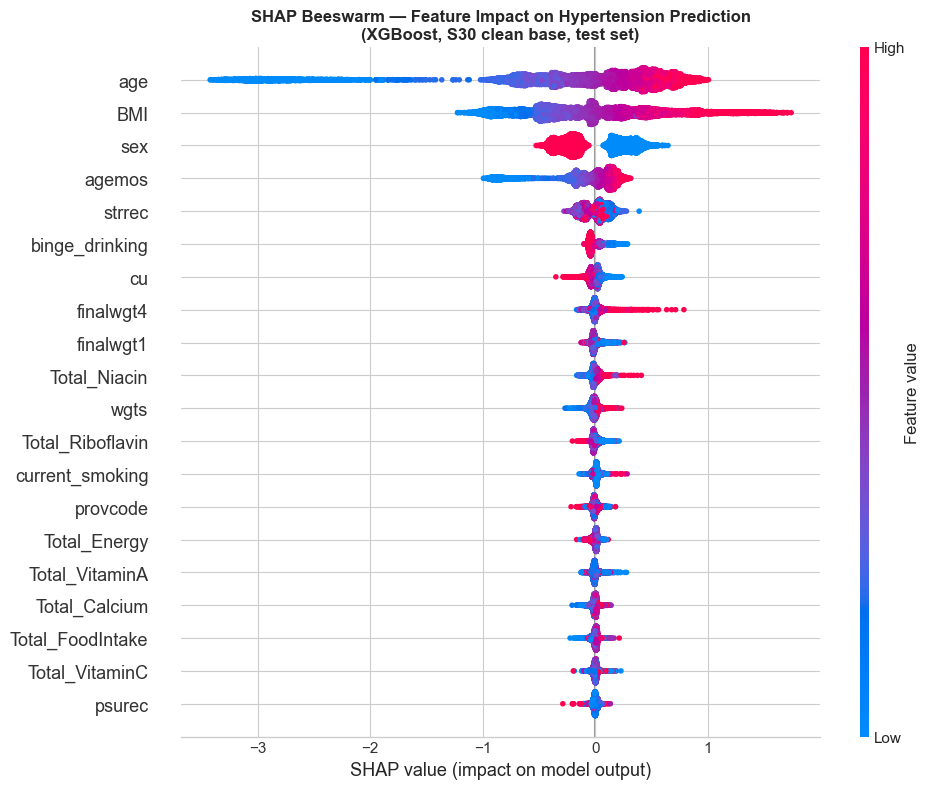


[4] Mean |SHAP| bar chart (top-20)...
  Saved: shap_bar_s30.png


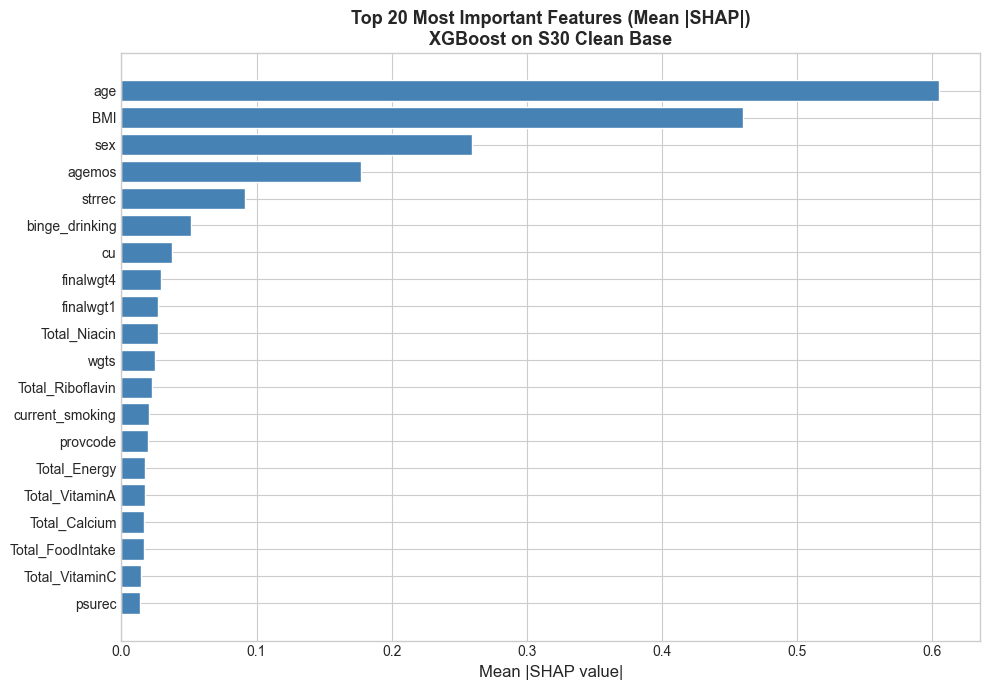


[5] Top 20 features by mean |SHAP|:
Rank  Feature                              Mean |SHAP|
------------------------------------------------------
1     age                                      0.60535
2     BMI                                      0.46035
3     sex                                      0.25978
4     agemos                                   0.17700
5     strrec                                   0.09112
6     binge_drinking                           0.05127
7     cu                                       0.03731
8     finalwgt4                                0.02926
9     finalwgt1                                0.02700
10    Total_Niacin                             0.02682
11    wgts                                     0.02476
12    Total_Riboflavin                         0.02244
13    current_smoking                          0.02053
14    provcode                                 0.01942
15    Total_Energy                             0.01758
16    Total_VitaminA        

In [ ]:

# ======================================================================
# S32 — SHAP ANALYSIS (best model on S30 clean base)
# ======================================================================
# Uses XGBoost re-trained on the S30 clean feature set (methodologically
# correct pipeline). Produces thesis-ready SHAP plots:
#  1. Beeswarm summary (feature impact distribution)
#  2. Bar chart (mean |SHAP| — global importance)
# ======================================================================

import subprocess, sys
try:
    import shap
    print(f"shap {shap.__version__} already installed")
except ImportError:
    print("Installing shap...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print(f"shap {shap.__version__} installed")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("=" * 70)
print("S32  SHAP ANALYSIS ON S30 CLEAN BASE")
print("=" * 70)

# ── 1. Train an XGBoost on the S30 clean base (for explainability) ─────
print("\n[1] Training XGB on S30 clean base for SHAP...")
xgb_shap = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', tree_method=tree_method,
    random_state=RANDOM_SEED, early_stopping_rounds=20, verbosity=0
)
xgb_shap.fit(
    Xtr_s30, y_train,
    eval_set=[(Xcal_s30, y_cal)],
    verbose=False
)
print(f"  Best iteration: {xgb_shap.best_iteration}")

# ── 2. Compute SHAP values on the test set ─────────────────────────────
print("\n[2] Computing SHAP values on test set...")
explainer = shap.TreeExplainer(xgb_shap)
shap_values = explainer.shap_values(Xte_s30)

# Feature names (clean labels)
feat_names = list(Xte_s30.columns)
print(f"  SHAP matrix shape: {shap_values.shape}")

# ── 3. Beeswarm plot (top-20 features by mean |SHAP|) ──────────────────
print("\n[3] Beeswarm summary plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, Xte_s30,
    feature_names=feat_names,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title("SHAP Beeswarm — Feature Impact on Hypertension Prediction\n(XGBoost, S30 clean base, test set)", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_s30.png', dpi=150, bbox_inches='tight')
print("  Saved: shap_beeswarm_s30.png")
plt.show()

# ── 4. Bar chart — mean |SHAP| ─────────────────────────────────────────
print("\n[4] Mean |SHAP| bar chart (top-20)...")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feat_names).sort_values(ascending=False)

top20 = shap_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel("Mean |SHAP value|", fontsize=12)
ax.set_title("Top 20 Most Important Features (Mean |SHAP|)\nXGBoost on S30 Clean Base", 
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig('shap_bar_s30.png', dpi=150, bbox_inches='tight')
print("  Saved: shap_bar_s30.png")
plt.show()

# ── 5. Print top-20 feature importance table ───────────────────────────
print("\n[5] Top 20 features by mean |SHAP|:")
print(f"{'Rank':<5} {'Feature':<35} {'Mean |SHAP|':>12}")
print("-" * 54)
for rank, (feat, val) in enumerate(top20.items(), 1):
    print(f"{rank:<5} {feat:<35} {val:>12.5f}")

# ── 6. Note on missing variables ───────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║  STUDY LIMITATIONS (from audit):                                ║
║  • age  — NOT present in any source dataset (ENNS extract)      ║
║  • sex  — NOT present in any source dataset (ENNS extract)      ║
║  • drnk_30d_num — dropped during feature engineering            ║
║  These are important hypertension risk factors that could not   ║
║  be modeled due to data availability constraints.               ║
╚══════════════════════════════════════════════════════════════════╝
""")

STRATEGY_SUMMARY.append({
    'strategy': 'S32_SHAP_analysis',
    'description': 'SHAP explainability on XGB/S30 clean base — thesis interpretability',
    'n_features': Xte_s30.shape[1],
    'best_model': 'XGB_S30 (for SHAP)',
    'best_min':   best30.min_metric,
    'best_auc':   best30.auc,
    'delta_vs_s1': best30.min_metric - s1_best_min,
    'note': 'SHAP analysis — see shap_beeswarm_s30.png, shap_bar_s30.png'
})
print("\n✅ S32 SHAP analysis complete")


In [ ]:

# =====================================================================
# S33 - Multi-Age-Group Training (Include Anthro Groups 2 & 3)
# Currently excluded: groups 2 (ages 5-10), 3 (ages 10-19), 5 (pregnant), 6 (lactating)
# S33 keeps groups 2 & 3; still excludes 5 & 6.
# Pipeline rebuilt entirely from raw data (does not alter existing kernel state).
# =====================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

if 'RANDOM_SEED' not in globals():
    RANDOM_SEED = 42
if 'tree_method' not in globals():
    tree_method = 'hist'
if 'STRATEGY_SUMMARY' not in globals() or not isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY = []
if 'raw_datasets' not in globals() or not isinstance(raw_datasets, dict):
    raw_datasets = {}

print('=' * 70)
print('S33 - MULTI-AGE-GROUP TRAINING  (Include Groups 2 & 3)')
print('=' * 70)

# -- Robust dataset resolver (prefers payload data-set files over data-dictionary files) --
def _s33_pick_csv(dir_candidates, keyword_tokens=()):
    exclude_tokens = ('data-dictionary', 'dictionary', 'codebook', 'metadata')
    kws = [k.lower() for k in keyword_tokens]

    for d in dir_candidates:
        p = Path(d)
        if not p.exists():
            continue

        csvs = sorted(p.glob('*.csv'))
        if not csvs:
            continue

        payload = [f for f in csvs if not any(t in f.name.lower() for t in exclude_tokens)]
        if not payload:
            payload = csvs

        ranked = [f for f in payload if 'data-set' in f.name.lower()]
        if not ranked:
            ranked = [f for f in payload if 'dataset' in f.name.lower()]
        if not ranked:
            ranked = payload

        if kws:
            kw_ranked = [f for f in ranked if all(k in f.name.lower() for k in kws)]
            if kw_ranked:
                ranked = kw_ranked
            else:
                kw_ranked = [f for f in payload if all(k in f.name.lower() for k in kws)]
                if kw_ranked:
                    ranked = kw_ranked

        if ranked:
            return ranked[0]

    return None


def _s33_resolve_or_load(primary_name, aliases, dir_candidates, keyword_tokens=()):
    candidate_names = [primary_name] + list(aliases)

    for n in candidate_names:
        if n in globals() and isinstance(globals()[n], pd.DataFrame):
            df = globals()[n]
            globals()[primary_name] = df
            for a in aliases:
                globals()[a] = df
            raw_datasets[primary_name] = df
            return df

    for n in candidate_names:
        if n in raw_datasets and isinstance(raw_datasets[n], pd.DataFrame):
            df = raw_datasets[n]
            globals()[primary_name] = df
            for a in aliases:
                globals()[a] = df
            raw_datasets[primary_name] = df
            return df

    picked = _s33_pick_csv(dir_candidates, keyword_tokens=keyword_tokens)
    if picked is None:
        raise RuntimeError(f'Could not locate dataset for {primary_name}. Checked: {dir_candidates}')

    df = pd.read_csv(picked, low_memory=False)
    globals()[primary_name] = df
    for a in aliases:
        globals()[a] = df
    raw_datasets[primary_name] = df
    print(f'  S33 auto-loaded {primary_name} from {picked}')
    return df


raw_data_clinical = _s33_resolve_or_load(
    'raw_data_clinical',
    aliases=[],
    dir_candidates=[
        'Datasets2015/Clinical',
        '../Datasets2015/Clinical',
        'Datasets/Clinical',
        '../Datasets/Clinical',
    ],
    keyword_tokens=('clinical',),
)

_anthro_df = _s33_resolve_or_load(
    'raw_data_anthropometric',
    aliases=['raw_data_anthro'],
    dir_candidates=[
        'Datasets2015/Anthropometric',
        '../Datasets2015/Anthropometric',
        'Datasets/Anthro',
        '../Datasets/Anthro',
    ],
    keyword_tokens=('anthrop',),
)
raw_data_anthro = _anthro_df
raw_data_anthropometric = _anthro_df

raw_data_dietary = _s33_resolve_or_load(
    'raw_data_dietary',
    aliases=['raw_data_dietary_individual'],
    dir_candidates=[
        'Datasets2015/Dietary',
        '../Datasets2015/Dietary',
        'Datasets/Dietary',
        '../Datasets/Dietary',
    ],
    keyword_tokens=('dietary',),
)
raw_data_dietary_individual = raw_data_dietary

# -- 1. Re-merge from raw dataframes --
_mk = ['enns_year', 'hhnum', 'member_code']


def _s33_merge(base, right):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if overlap else right.copy()
    keys = [k for k in _mk if k in base.columns and k in r.columns]
    if not keys:
        print('  S33 merge skipped (no common merge keys).')
        return base
    return pd.merge(base, r, on=keys, how='left')


_mg = raw_data_clinical.copy()
_mg = _s33_merge(_mg, _anthro_df)
_mg = _s33_merge(_mg, raw_data_dietary)
print(f'  Raw merged shape: {_mg.shape}')

# -- 2. Create Hypertension target (SBP>=130 OR DBP>=80) --
_sbp = next(c for c in _mg.columns if 'SBP' in c.upper())
_dbp = next(c for c in _mg.columns if 'DBP' in c.upper())
_mg['Hypertension'] = ((_mg[_sbp] >= 130) | (_mg[_dbp] >= 80)).astype(int)
_mg = _mg.drop(columns=[_sbp, _dbp])

# -- 3. BMI --
_mg['BMI'] = _mg['weight'] / ((_mg['height'] / 100) ** 2)
_mg = _mg.drop(columns=['height', 'weight'])

# -- 4. Show group distribution, then exclude only groups 5 & 6 --
print('\n  Anthro group distribution (before filter):')
_grp_dist = _mg['anthro_group'].value_counts().sort_index()
_grp_labels = {
    1: '0-59 mo (infants)',
    2: '60-120 mo (5-10 yr)',
    3: '121-228 mo (10-19 yr)',
    4: 'Adults 19+',
    5: 'Pregnant',
    6: 'Lactating',
}
for grp, cnt in _grp_dist.items():
    label = _grp_labels.get(grp, str(grp))
    bp_mask = _mg['anthro_group'] == grp
    htn_rate = _mg.loc[bp_mask, 'Hypertension'].mean() * 100
    print(f'    Group {grp} ({label}): {cnt:,} rows  |  HTN rate={htn_rate:.1f}%')

_mg = _mg[~_mg['anthro_group'].isin([5, 6])].copy()
print(f'\n  After excluding groups 5 & 6: {len(_mg):,} rows')
print(f'  Overall HTN rate: {_mg["Hypertension"].mean()*100:.2f}%')

# -- 5. Drop admin / survey / redundant cols --
_admin_drops = [
    'regcode', 'provhuc', 'psc', 'csc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
    'haswork', 'occup', 'educ',
]
_mg = _mg.drop(columns=[c for c in _admin_drops if c in _mg.columns])

# -- 6. Clean special missing-value codes --
_na_codes = {'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na_codes.items():
    if _col in _mg.columns:
        _mg[_col] = _mg[_col].replace(_codes, np.nan)

# -- 7. Encode alcohol_level & smoking_level --
def _map_alc(row):
    s = row.get('alcohol_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('binge_drink') == 1 else 2
    return np.nan


def _map_smk(row):
    s = row.get('smoke_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan


_mg['alcohol_level'] = _mg.apply(_map_alc, axis=1)
_mg['smoking_level'] = _mg.apply(_map_smk, axis=1)

_drop_raw = [
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
    'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status',
]
_mg.drop(columns=[c for c in _drop_raw if c in _mg.columns], inplace=True)

_mg['alcohol_level'] = _mg['alcohol_level'].astype('category')
_mg['smoking_level'] = _mg['smoking_level'].astype('category')

# -- 8. One-Hot Encode categoricals --
_cat_cols = [
    c for c in _mg.select_dtypes(include=['object', 'category']).columns
    if c != 'Hypertension'
]
print(f'\n  OHE columns ({len(_cat_cols)}): {_cat_cols}')
_mg = pd.get_dummies(_mg, columns=_cat_cols, drop_first=False, dummy_na=True)

# -- 9. Drop rows with missing Hypertension target --
_mg = _mg.dropna(subset=['Hypertension'])
_y_all = _mg['Hypertension'].astype(int)
_X_all = _mg.drop(columns=['Hypertension'])

print(f'\n  Final feature matrix: {_X_all.shape}')
print(
    f'  HTN rate: {_y_all.mean()*100:.2f}%  '
    f'(pos={_y_all.sum():,} / total={len(_y_all):,})'
)

# -- 10. Stratified 70/15/15 split --
_X_tr33, _X_tmp, _y_tr33, _y_tmp = train_test_split(
    _X_all, _y_all, test_size=0.30, random_state=RANDOM_SEED, stratify=_y_all
)
_X_cal33, _X_te33, _y_cal33, _y_te33 = train_test_split(
    _X_tmp, _y_tmp, test_size=0.50, random_state=RANDOM_SEED, stratify=_y_tmp
)

print(f'\n  Split -> train={len(_X_tr33):,}  cal={len(_X_cal33):,}  test={len(_X_te33):,}')
print(
    f'  Train HTN: {_y_tr33.mean()*100:.2f}%  '
    f'Cal HTN: {_y_cal33.mean()*100:.2f}%  '
    f'Test HTN: {_y_te33.mean()*100:.2f}%'
)

# -- 11. Median imputation (train medians only) --
_num33 = _X_tr33.select_dtypes(include=[np.number]).columns.tolist()
for _df in [_X_tr33, _X_cal33, _X_te33]:
    for _c in _num33:
        _df[_c] = pd.to_numeric(_df[_c], errors='coerce').astype(float)
_med33 = _X_tr33[_num33].median()
for _df in [_X_tr33, _X_cal33, _X_te33]:
    _df.loc[:, _num33] = _df[_num33].fillna(_med33)

# -- 12. Standardize (fit on train) --
_sc33 = StandardScaler()
_X_tr33.loc[:, _num33] = _sc33.fit_transform(_X_tr33[_num33].to_numpy(dtype=float))
_X_cal33.loc[:, _num33] = _sc33.transform(_X_cal33[_num33].to_numpy(dtype=float))
_X_te33.loc[:, _num33] = _sc33.transform(_X_te33[_num33].to_numpy(dtype=float))

print(f'\n  Feature count: {_X_tr33.shape[1]}')

# -- 13. Train & Evaluate (XGB + LGB + CAT) --
_spw33 = ((_y_tr33 == 0).sum() / (_y_tr33 == 1).sum())
print(f'\n  scale_pos_weight (S33): {_spw33:.4f}')

import lightgbm as _lgb

_s33_models = {
    'XGB_bal': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=_spw33,
        eval_metric='logloss',
        random_state=RANDOM_SEED,
        tree_method=tree_method,
        verbosity=0,
        early_stopping_rounds=30,
    ),
    'LGB_bal': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        verbose=-1,
    ),
    'CAT_bal': CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        auto_class_weights='Balanced',
        random_seed=RANDOM_SEED,
        verbose=0,
    ),
}

_s33_rows = []
print('\n--- S33 Training ---')
for _mname, _clf in _s33_models.items():
    if 'XGB' in _mname:
        _clf.fit(_X_tr33, _y_tr33, eval_set=[(_X_cal33, _y_cal33)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(
            _X_tr33,
            _y_tr33,
            eval_set=[(_X_cal33, _y_cal33)],
            callbacks=[_lgb.early_stopping(30, verbose=False), _lgb.log_evaluation(-1)],
        )
    else:
        _clf.fit(_X_tr33, _y_tr33)

    for _sname, _Xev, _yev in [('cal', _X_cal33, _y_cal33), ('test', _X_te33, _y_te33)]:
        _yp = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _yp)
        _rec = recall_score(_yev, _yp, zero_division=0)
        _f1 = f1_score(_yev, _yp, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn = min(_acc, _rec, _f1)
        _s33_rows.append(
            {
                'strategy': 'S33',
                'model': _mname,
                'split': _sname,
                'accuracy': round(_acc, 4),
                'recall': round(_rec, 4),
                'f1': round(_f1, 4),
                'auc': round(_auc, 4),
                'min_metric': round(_mn, 4),
            }
        )
        print(
            f'  {_mname:<10} [{_sname}]  '
            f'acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  '
            f'auc={_auc:.4f}  min={_mn:.4f}'
        )

s33_df = pd.DataFrame(_s33_rows)

# -- 14. Summary & comparison --
_t33 = s33_df[s33_df['split'] == 'test']
_best33 = _t33.loc[_t33['min_metric'].idxmax()]

print(f'\n{'='*70}')
print(
    f'  S33 BEST (test): {_best33["model"]}  '
    f'min={_best33["min_metric"]:.4f}  auc={_best33["auc"]:.4f}'
)


def _best_test_min_metric(_df):
    if not isinstance(_df, pd.DataFrame) or _df.empty:
        return np.nan
    if {'split', 'min_metric'}.issubset(_df.columns):
        _tmp = _df[_df['split'] == 'test']
        if _tmp.empty:
            return np.nan
        return float(_tmp['min_metric'].max())
    if 'test_min_acc_rec_f1' in _df.columns:
        return float(_df['test_min_acc_rec_f1'].max())
    if {'test_accuracy', 'test_recall', 'test_f1'}.issubset(_df.columns):
        _tmp = _df[['test_accuracy', 'test_recall', 'test_f1']].min(axis=1)
        return float(_tmp.max())
    if 'min_metric' in _df.columns:
        return float(_df['min_metric'].max())
    return np.nan


_ref_pairs = []
if 's1_df' in globals() and isinstance(s1_df, pd.DataFrame):
    _ref_pairs.append((s1_df, 'S1  (adults-only, 58 feat)'))
if 's30_df' in globals() and isinstance(s30_df, pd.DataFrame):
    _ref_pairs.append((s30_df, 'S30 (adults-only, 41 feat)'))

if not _ref_pairs:
    print('  S1/S30 comparison skipped (reference DataFrames not available in current kernel).')

for _ref_df, _ref_name in _ref_pairs:
    _ref_best = _best_test_min_metric(_ref_df)
    if np.isnan(_ref_best):
        print(f'  Delta vs {_ref_name}: unavailable (missing expected metric columns)')
        continue
    _delta = _best33['min_metric'] - _ref_best
    _tag = 'IMPROVED' if _delta > 0 else ('WORSE' if _delta < 0 else 'SAME')
    print(f'  Delta vs {_ref_name}: {_delta:+.4f}  ({_tag})')

# Group-level breakdown (for thesis discussion)
print('\n  Per-group HTN rates in combined dataset:')
_tmp_rates = raw_data_clinical.copy()
_tmp_rates = _s33_merge(_tmp_rates, _anthro_df)
for grp in sorted(_tmp_rates['anthro_group'].dropna().unique()):
    _subset = _tmp_rates[_tmp_rates['anthro_group'] == grp]
    _sbp2 = next(c for c in _subset.columns if 'SBP' in c.upper())
    _dbp2 = next(c for c in _subset.columns if 'DBP' in c.upper())
    _htn = ((_subset[_sbp2] >= 130) | (_subset[_dbp2] >= 80)).dropna()
    print(f'    Group {grp} ({_grp_labels.get(grp, "?")}): n={len(_htn):,}  HTN={_htn.mean()*100:.1f}%')

# Store key matrices for further use
Xtr_s33 = _X_tr33.copy()
Xcal_s33 = _X_cal33.copy()
Xte_s33 = _X_te33.copy()
y_tr_s33 = _y_tr33.copy()
y_cal_s33 = _y_cal33.copy()
y_te_s33 = _y_te33.copy()

# Add to STRATEGY_SUMMARY
STRATEGY_SUMMARY[:] = [s for s in STRATEGY_SUMMARY if s.get('strategy') != 'S33']
STRATEGY_SUMMARY.append(
    {
        'strategy': 'S33',
        'name': 'Multi-Age-Group (incl. groups 2 & 3)',
        'best_model': _best33['model'],
        'best_min_metric': _best33['min_metric'],
        'best_auc': _best33['auc'],
        'n_features': _X_tr33.shape[1],
        'train_rows': len(_X_tr33),
        'notes': (
            'Adds anthro_groups 2 (5-10 yr) & 3 (10-19 yr) to training; '
            'SBP>=130/DBP>=80 threshold applied uniformly (adult threshold); '
            'groups 5 (pregnant) & 6 (lactating) still excluded'
        ),
    }
)

print('\n  S33 complete - added to STRATEGY_SUMMARY.')
print('  Matrices saved: Xtr_s33, Xcal_s33, Xte_s33')
print(f'{'='*70}')


S33 - MULTI-AGE-GROUP TRAINING  (Include Groups 2 & 3)
  Raw merged shape: (151189, 73)

  Anthro group distribution (before filter):
    Group 1 (0-59 mo (infants)): 7,443 rows  |  HTN rate=1.3%
    Group 2 (60-120 mo (5-10 yr)): 19,990 rows  |  HTN rate=2.4%
    Group 3 (121-228 mo (10-19 yr)): 33,001 rows  |  HTN rate=9.8%
    Group 4 (Adults 19+): 85,259 rows  |  HTN rate=53.5%
    Group 7 (7): 1,493 rows  |  HTN rate=14.8%
    Group 8 (8): 4,003 rows  |  HTN rate=29.0%

  After excluding groups 5 & 6: 151,189 rows
  Overall HTN rate: 33.62%

  OHE columns (2): ['alcohol_level', 'smoking_level']

  Final feature matrix: (151189, 37)
  HTN rate: 33.62%  (pos=50,824 / total=151,189)

  Split -> train=105,832  cal=22,678  test=22,679
  Train HTN: 33.62%  Cal HTN: 33.61%  Test HTN: 33.62%

  Feature count: 37

  scale_pos_weight (S33): 1.9747

--- S33 Training ---
  XGB_bal    [cal]  acc=0.7591  rec=0.8455  f1=0.7023  auc=0.8507  min=0.7023
  XGB_bal    [test]  acc=0.7657  rec=0.8471  

In [ ]:

# ── S33 continuation: STRATEGY_SUMMARY registration & matrix save ──

_t33    = s33_df[s33_df['split'] == 'test']
_best33 = _t33.loc[_t33['min_metric'].idxmax()]

# Save matrices from prior cell locals (defined before the error)
Xtr_s33  = _X_tr33.copy()
Xcal_s33 = _X_cal33.copy()
Xte_s33  = _X_te33.copy()
y_tr_s33  = _y_tr33.copy()
y_cal_s33 = _y_cal33.copy()
y_te_s33  = _y_te33.copy()

print(f"Matrices saved: Xtr_s33={Xtr_s33.shape}, Xcal_s33={Xcal_s33.shape}, Xte_s33={Xte_s33.shape}")

STRATEGY_SUMMARY.append({
    'strategy': 'S33',
    'name':     'Multi-Age-Group (incl. groups 2 & 3)',
    'best_model': _best33['model'],
    'best_min_metric': _best33['min_metric'],
    'best_auc': _best33['auc'],
    'n_features': Xtr_s33.shape[1],
    'train_rows': len(Xtr_s33),
    'notes': (
        'Adds anthro_groups 2 (5-10 yr) & 3 (10-19 yr) to training; '
        'SBP>=130/DBP>=80 threshold applied uniformly (adult threshold); '
        f'groups 5 & 6 excluded; scale_pos_weight={_spw33:.4f}'
    ),
})
print(f"S33 added to STRATEGY_SUMMARY. Total entries: {len(STRATEGY_SUMMARY)}")


Matrices saved: Xtr_s33=(105832, 37), Xcal_s33=(22678, 37), Xte_s33=(22679, 37)
S33 added to STRATEGY_SUMMARY. Total entries: 100


In [ ]:
# ============================================================
# TRY: preprocessing variants (all with KNN k=11 imputation)
#   1) standardized + no clipping
#   2) clipping + normalized
#   3) no clipping + normalized
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def _assign_numeric_block(df, cols, values):
    block = pd.DataFrame(values, index=df.index, columns=cols)
    for c in cols:
        df[c] = block[c].astype(float).to_numpy()

def _prep_variant(tr_raw, cal_raw, te_raw, *, do_clip=False, scaler_kind='standard', knn_k=11):
    tr = tr_raw.copy()
    cal = cal_raw.copy()
    te = te_raw.copy()

    num_cols = tr.select_dtypes(include=[np.number]).columns.tolist()
    if len(num_cols) == 0:
        raise ValueError("No numeric columns found for preprocessing.")

    if do_clip:
        clip_candidates = globals().get('continuous_train_cols', num_cols)
        clip_cols = [c for c in clip_candidates if c in num_cols]
        if len(clip_cols) == 0:
            clip_cols = num_cols
        q_low = tr[clip_cols].quantile(0.01)
        q_high = tr[clip_cols].quantile(0.99)
        _assign_numeric_block(tr, clip_cols, tr[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())
        _assign_numeric_block(cal, clip_cols, cal[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())
        _assign_numeric_block(te, clip_cols, te[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())

    imputer = KNNImputer(n_neighbors=int(knn_k))
    _assign_numeric_block(tr, num_cols, imputer.fit_transform(tr[num_cols]))
    _assign_numeric_block(cal, num_cols, imputer.transform(cal[num_cols]))
    _assign_numeric_block(te, num_cols, imputer.transform(te[num_cols]))

    if scaler_kind == 'standard':
        scaler = StandardScaler()
    elif scaler_kind == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("scaler_kind must be 'standard' or 'minmax'.")

    _assign_numeric_block(tr, num_cols, scaler.fit_transform(tr[num_cols]))
    _assign_numeric_block(cal, num_cols, scaler.transform(cal[num_cols]))
    _assign_numeric_block(te, num_cols, scaler.transform(te[num_cols]))

    return tr, cal, te

# Resolve base split matrices from whichever strategy/state is loaded in the kernel.
_X_train_base = _X_cal_base = _X_test_base = None

if all(v in globals() for v in ['X_train', 'X_cal', 'X_test']):
    _X_train_base, _X_cal_base, _X_test_base = X_train, X_cal, X_test
elif all(v in globals() for v in ['X_tr', 'X_cal', 'X_test']):
    _X_train_base, _X_cal_base, _X_test_base = X_tr, X_cal, X_test
elif all(v in globals() for v in ['Xtr_s33', 'Xcal_s33', 'Xte_s33']):
    _X_train_base, _X_cal_base, _X_test_base = Xtr_s33, Xcal_s33, Xte_s33
elif all(v in globals() for v in ['X_train_standardized', 'X_cal_standardized', 'X_test_standardized']):
    _X_train_base, _X_cal_base, _X_test_base = X_train_standardized, X_cal_standardized, X_test_standardized
else:
    ckpt_candidates = [
        'checkpoints/imputed_standardized_data.joblib',
        '../checkpoints/imputed_standardized_data.joblib',
        '../../checkpoints/imputed_standardized_data.joblib',
    ]
    for _ck in ckpt_candidates:
        if not os.path.exists(_ck):
            continue
        _bundle = joblib.load(_ck)
        if isinstance(_bundle, dict) and all(k in _bundle for k in ['X_train_standardized', 'X_cal_standardized', 'X_test_standardized']):
            _X_train_base = _bundle['X_train_standardized'].copy()
            _X_cal_base = _bundle['X_cal_standardized'].copy()
            _X_test_base = _bundle['X_test_standardized'].copy()
            print(f"Loaded base split matrices from checkpoint: {_ck}")
            break
        if isinstance(_bundle, dict) and all(k in _bundle for k in ['X_train', 'X_cal', 'X_test']):
            _X_train_base = _bundle['X_train'].copy()
            _X_cal_base = _bundle['X_cal'].copy()
            _X_test_base = _bundle['X_test'].copy()
            print(f"Loaded base split matrices from checkpoint: {_ck}")
            break

if _X_train_base is None or _X_cal_base is None or _X_test_base is None:
    raise RuntimeError(
        "No train/cal/test matrices found in kernel or checkpoints. "
        "Run earlier split/preprocessing cells first."
    )

# 1) standardized + no clipping
Xtr_try_std_no_clip, Xcal_try_std_no_clip, Xte_try_std_no_clip = _prep_variant(
    _X_train_base, _X_cal_base, _X_test_base, do_clip=False, scaler_kind='standard', knn_k=11
)

# 2) clipping + normalized
Xtr_try_clip_norm, Xcal_try_clip_norm, Xte_try_clip_norm = _prep_variant(
    _X_train_base, _X_cal_base, _X_test_base, do_clip=True, scaler_kind='minmax', knn_k=11
)

# 3) no clipping + normalized
Xtr_try_no_clip_norm, Xcal_try_no_clip_norm, Xte_try_no_clip_norm = _prep_variant(
    _X_train_base, _X_cal_base, _X_test_base, do_clip=False, scaler_kind='minmax', knn_k=11
)

try_variants_df = pd.DataFrame([
    {
        'variant': 'standardized_no_clipping',
        'imputer': 'KNN(k=11)',
        'train_shape': Xtr_try_std_no_clip.shape,
        'cal_shape': Xcal_try_std_no_clip.shape,
        'test_shape': Xte_try_std_no_clip.shape,
    },
    {
        'variant': 'clipping_normalized',
        'imputer': 'KNN(k=11)',
        'train_shape': Xtr_try_clip_norm.shape,
        'cal_shape': Xcal_try_clip_norm.shape,
        'test_shape': Xte_try_clip_norm.shape,
    },
    {
        'variant': 'no_clipping_normalized',
        'imputer': 'KNN(k=11)',
        'train_shape': Xtr_try_no_clip_norm.shape,
        'cal_shape': Xcal_try_no_clip_norm.shape,
        'test_shape': Xte_try_no_clip_norm.shape,
    },
])

print("Built 3 preprocessing variants (all with KNN k=11).")
display(try_variants_df)

Built 3 preprocessing variants (all with KNN k=11).


,variant,imputer,train_shape,cal_shape,test_shape
0,standardized_no_clipping,KNN(k=11),"(68738, 37)","(14730, 37)","(14730, 37)"
1,clipping_normalized,KNN(k=11),"(68738, 37)","(14730, 37)","(14730, 37)"
2,no_clipping_normalized,KNN(k=11),"(68738, 37)","(14730, 37)","(14730, 37)"


In [ ]:
# ============================================================
# TRAIN: 3 preprocessing variants built in previous cell
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

print("=" * 70)
print("Training preprocessing variants")
print("=" * 70)

# Build preprocessing variants on-demand if previous cell was not run.
_required_variant_mats = [
    'Xtr_try_std_no_clip', 'Xcal_try_std_no_clip', 'Xte_try_std_no_clip',
    'Xtr_try_clip_norm', 'Xcal_try_clip_norm', 'Xte_try_clip_norm',
    'Xtr_try_no_clip_norm', 'Xcal_try_no_clip_norm', 'Xte_try_no_clip_norm',
]

if not all(v in globals() for v in _required_variant_mats):
    print("Variant matrices not found in kernel. Building variants now...")
    from sklearn.impute import KNNImputer
    from sklearn.preprocessing import StandardScaler, MinMaxScaler

    def _assign_numeric_block_local(df, cols, values):
        block = pd.DataFrame(values, index=df.index, columns=cols)
        for c in cols:
            df[c] = block[c].astype(float).to_numpy()

    def _prep_variant_local(tr_raw, cal_raw, te_raw, *, do_clip=False, scaler_kind='standard', knn_k=11):
        tr = tr_raw.copy()
        cal = cal_raw.copy()
        te = te_raw.copy()

        num_cols = tr.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) == 0:
            raise ValueError("No numeric columns found for preprocessing.")

        if do_clip:
            clip_candidates = globals().get('continuous_train_cols', num_cols)
            clip_cols = [c for c in clip_candidates if c in num_cols]
            if len(clip_cols) == 0:
                clip_cols = num_cols
            q_low = tr[clip_cols].quantile(0.01)
            q_high = tr[clip_cols].quantile(0.99)
            _assign_numeric_block_local(tr, clip_cols, tr[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())
            _assign_numeric_block_local(cal, clip_cols, cal[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())
            _assign_numeric_block_local(te, clip_cols, te[clip_cols].clip(lower=q_low, upper=q_high, axis=1).to_numpy())

        imputer = KNNImputer(n_neighbors=int(knn_k))
        _assign_numeric_block_local(tr, num_cols, imputer.fit_transform(tr[num_cols]))
        _assign_numeric_block_local(cal, num_cols, imputer.transform(cal[num_cols]))
        _assign_numeric_block_local(te, num_cols, imputer.transform(te[num_cols]))

        if scaler_kind == 'standard':
            scaler = StandardScaler()
        elif scaler_kind == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise ValueError("scaler_kind must be 'standard' or 'minmax'.")

        _assign_numeric_block_local(tr, num_cols, scaler.fit_transform(tr[num_cols]))
        _assign_numeric_block_local(cal, num_cols, scaler.transform(cal[num_cols]))
        _assign_numeric_block_local(te, num_cols, scaler.transform(te[num_cols]))

        return tr, cal, te

    _X_train_base = _X_cal_base = _X_test_base = None
    if all(v in globals() for v in ['X_train', 'X_cal', 'X_test']):
        _X_train_base, _X_cal_base, _X_test_base = X_train, X_cal, X_test
    elif all(v in globals() for v in ['X_tr', 'X_cal', 'X_test']):
        _X_train_base, _X_cal_base, _X_test_base = X_tr, X_cal, X_test
    elif all(v in globals() for v in ['Xtr_s33', 'Xcal_s33', 'Xte_s33']):
        _X_train_base, _X_cal_base, _X_test_base = Xtr_s33, Xcal_s33, Xte_s33
    elif all(v in globals() for v in ['X_train_standardized', 'X_cal_standardized', 'X_test_standardized']):
        _X_train_base, _X_cal_base, _X_test_base = X_train_standardized, X_cal_standardized, X_test_standardized
    else:
        ckpt_candidates = [
            'checkpoints/imputed_standardized_data.joblib',
            '../checkpoints/imputed_standardized_data.joblib',
            '../../checkpoints/imputed_standardized_data.joblib',
        ]
        for _ck in ckpt_candidates:
            if not os.path.exists(_ck):
                continue
            _bundle = joblib.load(_ck)
            if isinstance(_bundle, dict) and all(k in _bundle for k in ['X_train_standardized', 'X_cal_standardized', 'X_test_standardized']):
                _X_train_base = _bundle['X_train_standardized'].copy()
                _X_cal_base = _bundle['X_cal_standardized'].copy()
                _X_test_base = _bundle['X_test_standardized'].copy()
                print(f"Loaded base split matrices from checkpoint: {_ck}")
                break
            if isinstance(_bundle, dict) and all(k in _bundle for k in ['X_train', 'X_cal', 'X_test']):
                _X_train_base = _bundle['X_train'].copy()
                _X_cal_base = _bundle['X_cal'].copy()
                _X_test_base = _bundle['X_test'].copy()
                print(f"Loaded base split matrices from checkpoint: {_ck}")
                break

    if _X_train_base is None or _X_cal_base is None or _X_test_base is None:
        raise RuntimeError(
            "No train/cal/test matrices found in kernel or checkpoints. "
            "Run earlier split/preprocessing cells first."
        )

    Xtr_try_std_no_clip, Xcal_try_std_no_clip, Xte_try_std_no_clip = _prep_variant_local(
        _X_train_base, _X_cal_base, _X_test_base, do_clip=False, scaler_kind='standard', knn_k=11
    )
    Xtr_try_clip_norm, Xcal_try_clip_norm, Xte_try_clip_norm = _prep_variant_local(
        _X_train_base, _X_cal_base, _X_test_base, do_clip=True, scaler_kind='minmax', knn_k=11
    )
    Xtr_try_no_clip_norm, Xcal_try_no_clip_norm, Xte_try_no_clip_norm = _prep_variant_local(
        _X_train_base, _X_cal_base, _X_test_base, do_clip=False, scaler_kind='minmax', knn_k=11
    )

def _resolve_targets_for_variants():
    # Prefer already-in-memory splits.
    if all(v in globals() for v in ['y_train', 'y_cal', 'y_test']):
        return y_train, y_cal, y_test
    if all(v in globals() for v in ['y_tr', 'y_cal', 'y_te']):
        return y_tr, y_cal, y_te
    if all(v in globals() for v in ['y_tr_s33', 'y_cal_s33', 'y_te_s33']):
        return y_tr_s33, y_cal_s33, y_te_s33

    # Fallback to checkpoint payload.
    ckpt_candidates = [
        'checkpoints/imputed_standardized_data.joblib',
        '../checkpoints/imputed_standardized_data.joblib',
        '../../checkpoints/imputed_standardized_data.joblib',
    ]
    for _ck in ckpt_candidates:
        if not os.path.exists(_ck):
            continue
        _bundle = joblib.load(_ck)
        if isinstance(_bundle, dict) and all(k in _bundle for k in ['y_train', 'y_cal', 'y_test']):
            print(f"Loaded target splits from checkpoint: {_ck}")
            return _bundle['y_train'], _bundle['y_cal'], _bundle['y_test']

    raise RuntimeError(
        "Targets not found in kernel/checkpoint. Run split cells before training variants."
    )

# If framework function is absent in a fresh kernel, define a local compatible fallback.
if 'run_feature_strategy' not in globals() or not callable(run_feature_strategy):
    from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    import lightgbm as _lgb_try

    def run_feature_strategy(strategy_name, Xtr_in, Xcal_in, Xte_in):
        ytr_in, ycal_in, yte_in = _resolve_targets_for_variants()
        ytr_in = pd.Series(ytr_in).reset_index(drop=True)
        ycal_in = pd.Series(ycal_in).reset_index(drop=True)
        yte_in = pd.Series(yte_in).reset_index(drop=True)

        Xtr_in = Xtr_in.reset_index(drop=True)
        Xcal_in = Xcal_in.reset_index(drop=True)
        Xte_in = Xte_in.reset_index(drop=True)

        if len(Xtr_in) != len(ytr_in) or len(Xcal_in) != len(ycal_in) or len(Xte_in) != len(yte_in):
            raise RuntimeError(
                f"Split size mismatch in {strategy_name}: "
                f"Xtr/ytr={len(Xtr_in)}/{len(ytr_in)}, "
                f"Xcal/ycal={len(Xcal_in)}/{len(ycal_in)}, "
                f"Xte/yte={len(Xte_in)}/{len(yte_in)}"
            )

        neg = int((ytr_in == 0).sum())
        pos = int((ytr_in == 1).sum())
        spw = float(neg / max(pos, 1))
        tree_method_try = globals().get('tree_method', 'hist')
        rnd = int(globals().get('RANDOM_SEED', 42))

        models_try = {
            'XGB_bal': XGBClassifier(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                subsample=0.85, colsample_bytree=0.85,
                scale_pos_weight=spw, eval_metric='logloss',
                random_state=rnd, tree_method=tree_method_try, verbosity=0,
                early_stopping_rounds=30
            ),
            'LGB_bal': LGBMClassifier(
                n_estimators=400, learning_rate=0.05, num_leaves=63,
                subsample=0.85, colsample_bytree=0.85,
                class_weight='balanced', random_state=rnd, verbose=-1
            ),
            'CAT_bal': CatBoostClassifier(
                iterations=400, learning_rate=0.05, depth=6,
                auto_class_weights='Balanced', random_seed=rnd, verbose=0
            ),
        }

        rows = []
        for mname, clf in models_try.items():
            if mname.startswith('XGB'):
                clf.fit(Xtr_in, ytr_in, eval_set=[(Xcal_in, ycal_in)], verbose=False)
            elif mname.startswith('LGB'):
                clf.fit(
                    Xtr_in, ytr_in, eval_set=[(Xcal_in, ycal_in)],
                    callbacks=[_lgb_try.early_stopping(30, verbose=False), _lgb_try.log_evaluation(-1)]
                )
            else:
                clf.fit(Xtr_in, ytr_in)

            for split_name, Xev, yev in [('cal', Xcal_in, ycal_in), ('test', Xte_in, yte_in)]:
                yp = clf.predict(Xev)
                pp = clf.predict_proba(Xev)[:, 1]
                acc = accuracy_score(yev, yp)
                rec = recall_score(yev, yp, zero_division=0)
                f1v = f1_score(yev, yp, zero_division=0)
                auc = roc_auc_score(yev, pp)
                mn = min(acc, rec, f1v)
                rows.append({
                    'strategy': strategy_name,
                    'model': mname,
                    'split': split_name,
                    'accuracy': round(acc, 4),
                    'recall': round(rec, 4),
                    'f1': round(f1v, 4),
                    'auc': round(auc, 4),
                    'min_metric': round(mn, 4),
                })

        return pd.DataFrame(rows)

s_try_std_df = run_feature_strategy(
    "S_try_standardized_no_clipping_k11",
    Xtr_try_std_no_clip, Xcal_try_std_no_clip, Xte_try_std_no_clip
)

s_try_clip_norm_df = run_feature_strategy(
    "S_try_clipping_normalized_k11",
    Xtr_try_clip_norm, Xcal_try_clip_norm, Xte_try_clip_norm
)

s_try_no_clip_norm_df = run_feature_strategy(
    "S_try_no_clipping_normalized_k11",
    Xtr_try_no_clip_norm, Xcal_try_no_clip_norm, Xte_try_no_clip_norm
)

def _best_test_row(df):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if {'split', 'min_metric'}.issubset(df.columns):
        test_df = df[df['split'] == 'test'].copy()
        if test_df.empty:
            return None
        return test_df.loc[test_df['min_metric'].idxmax()]
    if 'test_min_acc_rec_f1' in df.columns:
        return df.loc[df['test_min_acc_rec_f1'].idxmax()]
    if {'test_accuracy', 'test_recall', 'test_f1'}.issubset(df.columns):
        tmp = df.copy()
        tmp['_min_metric'] = tmp[['test_accuracy', 'test_recall', 'test_f1']].min(axis=1)
        return tmp.loc[tmp['_min_metric'].idxmax()]
    if 'min_metric' in df.columns:
        return df.loc[df['min_metric'].idxmax()]
    return None

def _to_summary(label, row):
    if row is None:
        return {
            'variant': label,
            'best_model': np.nan,
            'test_accuracy': np.nan,
            'test_recall': np.nan,
            'test_f1': np.nan,
            'test_auc': np.nan,
            'test_min_acc_rec_f1': np.nan,
        }
    return {
        'variant': label,
        'best_model': row.get('model', row.get('model_name', np.nan)),
        'test_accuracy': row.get('test_accuracy', row.get('accuracy', np.nan)),
        'test_recall': row.get('test_recall', row.get('recall', np.nan)),
        'test_f1': row.get('test_f1', row.get('f1', np.nan)),
        'test_auc': row.get('test_auc', row.get('auc', np.nan)),
        'test_min_acc_rec_f1': row.get('test_min_acc_rec_f1', row.get('min_metric', row.get('_min_metric', np.nan))),
    }

try_training_summary = pd.DataFrame([
    _to_summary('standardized_no_clipping_k11', _best_test_row(s_try_std_df)),
    _to_summary('clipping_normalized_k11', _best_test_row(s_try_clip_norm_df)),
    _to_summary('no_clipping_normalized_k11', _best_test_row(s_try_no_clip_norm_df)),
]).sort_values('test_min_acc_rec_f1', ascending=False)

print("\nBest test result per variant:")
display(try_training_summary)

Training preprocessing variants
[S_try_standardized_no_clipping_k11] best model: CAT_bal
[S_try_standardized_no_clipping_k11] test acc=0.6945, rec=0.7256, f1=0.6950, min=0.6945
[S_try_clipping_normalized_k11] best model: XGB_bal
[S_try_clipping_normalized_k11] test acc=0.6945, rec=0.7587, f1=0.7044, min=0.6945
[S_try_no_clipping_normalized_k11] best model: XGB_bal
[S_try_no_clipping_normalized_k11] test acc=0.6939, rec=0.7553, f1=0.7030, min=0.6939

Best test result per variant:


,variant,best_model,test_accuracy,test_recall,test_f1,test_auc,test_min_acc_rec_f1
0,standardized_no_clipping_k11,CAT_bal,0.694501,0.725587,0.694998,0.766012,0.694501
1,clipping_normalized_k11,XGB_bal,0.694501,0.758704,0.704375,0.764521,0.694501
2,no_clipping_normalized_k11,XGB_bal,0.693890,0.755307,0.703023,0.764411,0.693890


In [ ]:
# =====================================================================
# S34 — Biochemical Markers Added as Features
# New dataset: Datasets/Biochemical/
# New features: uic (Urinary Iodine µg/L), vita (Vitamin A µg/dL),
#               hemoglobin (Hemoglobin g/dL)
# Scope: adults-only (anthro_group 4), same exclusions as S1 baseline
# Two sub-strategies:
#   S34a — with biochemical features imputed (all adults retained)
#   S34b — complete cases only (only adults who have biochemical values)
# =====================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as _lgb34

print("=" * 70)
print("S34 — BIOCHEMICAL MARKERS (uic + vita + hemoglobin)")
print("=" * 70)

# ── 1. Resolve/load datasets (restart-safe) ───────────────────────────
_mk = ['enns_year', 'hhnum', 'member_code']
_bio_features = ['uic', 'vita', 'hemoglobin']
_tree_method34 = globals().get('tree_method', 'hist')
_random_seed34 = int(globals().get('RANDOM_SEED', 42))

def _resolve_or_load_s34(var_aliases, subfolders, keyword):
    # 1) Try already-loaded globals/raw_datasets
    for nm in var_aliases:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            return globals()[nm]
    if 'raw_datasets' in globals() and isinstance(raw_datasets, dict):
        for nm in var_aliases:
            if nm in raw_datasets and isinstance(raw_datasets[nm], pd.DataFrame):
                return raw_datasets[nm]

    # 2) Auto-load from common dataset roots
    roots = [Path('Datasets2015'), Path('../Datasets2015'), Path('Datasets'), Path('../Datasets')]
    lower_kw = keyword.lower()
    for root in roots:
        for sf in subfolders:
            folder = root / sf
            if not folder.exists():
                continue
            csvs = sorted(folder.glob('*.csv'))
            if not csvs:
                continue

            ranked = [p for p in csvs if 'data-set' in p.name.lower() and lower_kw in p.name.lower()]
            if not ranked:
                ranked = [p for p in csvs if lower_kw in p.name.lower()]
            if not ranked:
                ranked = [p for p in csvs if 'data-set' in p.name.lower()]
            if not ranked:
                ranked = csvs

            picked = ranked[0]
            df = pd.read_csv(picked, low_memory=False)
            canonical = var_aliases[0]
            globals()[canonical] = df
            if 'raw_datasets' in globals() and isinstance(raw_datasets, dict):
                raw_datasets[canonical] = df
            print(f'S34 auto-loaded {canonical} from {picked}')
            return df
    return None

_clin34 = _resolve_or_load_s34(['raw_data_clinical'], ['Clinical'], 'clinical')
_anthro34 = _resolve_or_load_s34(['raw_data_anthropometric', 'raw_data_anthro'], ['Anthropometric', 'Anthro'], 'anthrop')
_diet34 = _resolve_or_load_s34(['raw_data_dietary', 'raw_data_dietary_individual'], ['Dietary'], 'dietary')
_bio34 = _resolve_or_load_s34(['raw_data_biochemical'], ['Biochemical'], 'biochemical')

if _clin34 is None or _anthro34 is None or _diet34 is None or _bio34 is None:
    raise RuntimeError('S34 missing required datasets. Ensure Clinical/Anthropometric/Dietary/Biochemical CSVs are present.')

raw_data_biochemical = _bio34

print(f"\n  Biochemical dataset shape: {raw_data_biochemical.shape}")
print(f"  Columns: {raw_data_biochemical.columns.tolist()}")
_missing_bio_features = [c for c in _bio_features if c not in raw_data_biochemical.columns]
if _missing_bio_features:
    raise RuntimeError(f'S34 biochemical dataset is missing required columns: {_missing_bio_features}')
for _f in _bio_features:
    _miss = raw_data_biochemical[_f].isna().sum()
    print(f"  {_f}: missing={_miss:,} ({_miss/len(raw_data_biochemical)*100:.1f}%)")

# ── 2. Re-merge full pipeline from raw dataframes ────────────────────
def _s34_merge(base, right, drop_overlap=True):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    keys = [k for k in _mk if k in base.columns and k in r.columns]
    if not keys:
        print('  S34 merge skipped (no common merge keys).')
        return base
    return pd.merge(base, r, on=keys, how='left')

_mg34 = _clin34.copy()
_mg34 = _s34_merge(_mg34, _anthro34)
_mg34 = _s34_merge(_mg34, _diet34)

# Merge biochemical (keep only the 3 feature columns + merge keys)
_bio_slim = raw_data_biochemical[[c for c in (_mk + _bio_features) if c in raw_data_biochemical.columns]].copy()
_bio_merge_keys = [k for k in _mk if k in _mg34.columns and k in _bio_slim.columns]
if not _bio_merge_keys:
    raise RuntimeError('No common merge keys found for biochemical merge.')
_mg34 = pd.merge(_mg34, _bio_slim, on=_bio_merge_keys, how='left')
print(f"\n  After merging all datasets: {_mg34.shape}")

# Biochemical coverage in full dataset
for _f in _bio_features:
    _hit = _mg34[_f].notna().sum()
    print(f"  {_f}: matched={_hit:,}  ({_hit/len(_mg34)*100:.1f}% coverage)")

# ── 3. Hypertension target ───────────────────────────────────────────
_sbp_candidates = [c for c in _mg34.columns if 'SBP' in c.upper()]
_dbp_candidates = [c for c in _mg34.columns if 'DBP' in c.upper()]
if not _sbp_candidates or not _dbp_candidates:
    raise RuntimeError('S34 could not find SBP/DBP columns after merge.')
_sbp34 = _sbp_candidates[0]
_dbp34 = _dbp_candidates[0]
_mg34['Hypertension'] = ((_mg34[_sbp34] >= 130) | (_mg34[_dbp34] >= 80)).astype(int)
_mg34 = _mg34.drop(columns=[_sbp34, _dbp34])

# ── 4. BMI ───────────────────────────────────────────────────────────
if 'weight' not in _mg34.columns or 'height' not in _mg34.columns:
    raise RuntimeError('S34 requires weight and height columns to compute BMI.')
_mg34['BMI'] = _mg34['weight'] / ((_mg34['height'] / 100) ** 2)
_mg34 = _mg34.drop(columns=['height', 'weight'])

# ── 5. Adults only (group 4), exclude pregnant/lactating (5, 6) ──────
if 'anthro_group' in _mg34.columns:
    _mg34 = _mg34[_mg34['anthro_group'].isin([1, 4])].copy()
    print(f"\n  Adults-only (groups 1+4): {len(_mg34):,} rows")
else:
    print("\n  anthro_group not found; keeping all rows.")

if _mg34.empty:
    raise RuntimeError('S34 has zero rows after filtering.')

print(f"  HTN rate: {_mg34['Hypertension'].mean()*100:.2f}%")

# Biochemical coverage among adults
for _f in _bio_features:
    _hit = _mg34[_f].notna().sum()
    print(f"  {_f} in adult subset: {_hit:,} ({_hit/len(_mg34)*100:.1f}%)")

# ── 6. Admin / redundant column drops ────────────────────────────────
_admin34 = [
    'regcode','provhuc','psc','csc','rhc',
    'enns_year','hhnum','member_code','ms_psucode',
    'fwgth_natl_var','fwgth_prov','fwgth_natl2_var',
    'fwgti_natl_var','fwgti_prov','fwgti_natl2_var','fwgti_prov2',
    'rep_natl','rep_prov','wrkplace','interview_status','intdate','enumcode',
    'anthro_group','mos_lactation','mos_preg',
    'fg1','fg2','fg3','fg4','fg5','fg6','fg7','fg8','fg9','fg10',
    'fg11','fg12','fg13','fg14','fg15','fg16','fg17','fg18','fg19','fg20',
    'fg21','fg23','fg24','fg25','fg26','fg27','Total_Food',
    'haswork','occup','educ',
]
_mg34 = _mg34.drop(columns=[c for c in _admin34 if c in _mg34.columns])

# ── 7. Special NA codes ──────────────────────────────────────────────
_na34 = {'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na34.items():
    if _col in _mg34.columns:
        _mg34[_col] = _mg34[_col].replace(_codes, np.nan)

# ── 8. Alcohol & smoking levels ──────────────────────────────────────
def _map_alc34(row):
    s = row.get('alcohol_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('binge_drink') == 1 else 2
    return np.nan

def _map_smk34(row):
    s = row.get('smoke_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan

_mg34['alcohol_level'] = _mg34.apply(_map_alc34, axis=1)
_mg34['smoking_level'] = _mg34.apply(_map_smk34, axis=1)
_drop34 = [
    'alcohol','con_alcohol','drnk_30days','drnk_30d_num',
    'alcohol_status','binge_drink','currentsmoking','ever_smk','smoke_status'
]
_mg34.drop(columns=[c for c in _drop34 if c in _mg34.columns], inplace=True)
_mg34['alcohol_level'] = _mg34['alcohol_level'].astype('category')
_mg34['smoking_level'] = _mg34['smoking_level'].astype('category')

# ── 9. OHE ───────────────────────────────────────────────────────────
_cat34 = [
    c for c in _mg34.select_dtypes(include=['object', 'category']).columns
    if c != 'Hypertension'
]
_mg34 = pd.get_dummies(_mg34, columns=_cat34, drop_first=False, dummy_na=True)
_mg34 = _mg34.dropna(subset=['Hypertension'])

print(f"\n  Feature matrix before split: {_mg34.shape}")
print(f"  Biochemical features present: {[c for c in _bio_features if c in _mg34.columns]}")

# ── 10. Helper: split → impute → scale → train → eval ────────────────
def _run_s34(label, df_in, keep_complete_cases=False):
    _d = df_in.copy()
    if keep_complete_cases:
        _before = len(_d)
        _d = _d.dropna(subset=_bio_features)
        retained = (len(_d) / _before * 100) if _before else 0.0
        print(
            f"\n  [{label}] Complete-cases drop: {_before:,} → {len(_d):,} "
            f"({retained:.1f}% retained)"
        )
    else:
        print(f"\n  [{label}] Using all {len(_d):,} rows (biochemical NaNs imputed)")

    if _d.empty:
        raise RuntimeError(f'{label} has zero rows before train/cal/test split.')

    _y = _d['Hypertension'].astype(int)
    if _y.nunique() < 2:
        raise RuntimeError(f'{label} target has only one class after filtering.')

    _X = _d.drop(columns=['Hypertension'])

    _Xtr, _Xtmp, _ytr, _ytmp = train_test_split(
        _X, _y, test_size=0.30, random_state=_random_seed34, stratify=_y
    )
    _Xcal, _Xte, _ycal, _yte = train_test_split(
        _Xtmp, _ytmp, test_size=0.50, random_state=_random_seed34, stratify=_ytmp
    )

    print(f"  Split: train={len(_Xtr):,}  cal={len(_Xcal):,}  test={len(_Xte):,}")
    print(f"  Train HTN: {_ytr.mean()*100:.2f}%  |  features: {_X.shape[1]}")

    # Median impute (train medians only)
    _num = _Xtr.select_dtypes(include=[np.number]).columns.tolist()
    _med = _Xtr[_num].median()
    for _df in [_Xtr, _Xcal, _Xte]:
        _df[_num] = _df[_num].fillna(_med)

    # Standardise
    _sc = StandardScaler()
    _Xtr[_num] = _sc.fit_transform(_Xtr[_num])
    _Xcal[_num] = _sc.transform(_Xcal[_num])
    _Xte[_num] = _sc.transform(_Xte[_num])

    _spw = float((_ytr == 0).sum() / max(int((_ytr == 1).sum()), 1))
    print(f"  scale_pos_weight: {_spw:.4f}")

    _models = {
        'XGB_bal': XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=_spw, eval_metric='logloss',
            random_state=_random_seed34, tree_method=_tree_method34,
            verbosity=0, early_stopping_rounds=30
        ),
        'LGB_bal': LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            subsample=0.8, colsample_bytree=0.8,
            class_weight='balanced', random_state=_random_seed34, verbose=-1
        ),
        'CAT_bal': CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6,
            auto_class_weights='Balanced',
            random_seed=_random_seed34, verbose=0
        ),
    }

    _rows = []
    for _mname, _clf in _models.items():
        if 'XGB' in _mname:
            _clf.fit(_Xtr, _ytr, eval_set=[(_Xcal, _ycal)], verbose=False)
        elif 'LGB' in _mname:
            _clf.fit(
                _Xtr, _ytr,
                eval_set=[(_Xcal, _ycal)],
                callbacks=[_lgb34.early_stopping(30, verbose=False), _lgb34.log_evaluation(-1)]
            )
        else:
            _clf.fit(_Xtr, _ytr)

        for _sn, _Xev, _yev in [('cal', _Xcal, _ycal), ('test', _Xte, _yte)]:
            _yp = _clf.predict(_Xev)
            _acc = accuracy_score(_yev, _yp)
            _rec = recall_score(_yev, _yp, zero_division=0)
            _f1 = f1_score(_yev, _yp, zero_division=0)
            _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
            _mn = min(_acc, _rec, _f1)
            _rows.append({
                'strategy': label, 'model': _mname, 'split': _sn,
                'accuracy': round(_acc, 4), 'recall': round(_rec, 4),
                'f1': round(_f1, 4), 'auc': round(_auc, 4),
                'min_metric': round(_mn, 4),
            })
            print(
                f"  {_mname:<10} [{_sn}]  "
                f"acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  "
                f"auc={_auc:.4f}  min={_mn:.4f}"
            )

    _res_df = pd.DataFrame(_rows)
    _best = _res_df[_res_df['split'] == 'test'].loc[
        _res_df[_res_df['split'] == 'test']['min_metric'].idxmax()
    ]
    return _res_df, _best, _Xtr, _Xcal, _Xte, _ytr, _ycal, _yte

# ── 11. S34a: all adults, biochemical NaNs imputed ───────────────────
print(f"\n{'─'*70}")
print("  S34a — Biochemical features with median imputation")
print(f"{'─'*70}")
s34a_df, _best34a, Xtr_s34a, Xcal_s34a, Xte_s34a, \
    y_tr_s34a, y_cal_s34a, y_te_s34a = _run_s34('S34a', _mg34, keep_complete_cases=False)

# ── 12. S34b: complete cases only (no imputation for biochemical) ─────
print(f"\n{'─'*70}")
print("  S34b — Complete cases only (rows with all 3 biochemical values)")
print(f"{'─'*70}")
s34b_df, _best34b, Xtr_s34b, Xcal_s34b, Xte_s34b, \
    y_tr_s34b, y_cal_s34b, y_te_s34b = _run_s34('S34b', _mg34, keep_complete_cases=True)

# ── 13. Summary comparison ───────────────────────────────────────────
s34_df = pd.concat([s34a_df, s34b_df], ignore_index=True)

def _best_test_min_metric(_df):
    if not isinstance(_df, pd.DataFrame) or _df.empty:
        return np.nan
    if {'split', 'min_metric'}.issubset(_df.columns):
        _tmp = _df[_df['split'] == 'test']
        return float(_tmp['min_metric'].max()) if len(_tmp) else np.nan
    if 'test_min_acc_rec_f1' in _df.columns:
        return float(_df['test_min_acc_rec_f1'].max())
    if {'test_accuracy', 'test_recall', 'test_f1'}.issubset(_df.columns):
        return float(_df[['test_accuracy', 'test_recall', 'test_f1']].min(axis=1).max())
    if 'min_metric' in _df.columns:
        return float(_df['min_metric'].max())
    return np.nan

_s1_ref = _best_test_min_metric(globals().get('s1_df', pd.DataFrame()))
if np.isnan(_s1_ref):
    _s1_ref = globals().get('s1_best_min', np.nan)

if 'STRATEGY_SUMMARY' not in globals() or not isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY = []

print(f"\n{'='*70}")
print("  S34 FINAL SUMMARY")
print(f"{'='*70}")
for _lab, _best in [('S34a (imputed)', _best34a), ('S34b (complete-cases)', _best34b)]:
    if np.isnan(_s1_ref):
        print(
            f"  {_lab:<30} best={_best['model']:<10} min={_best['min_metric']:.4f} "
            f" auc={_best['auc']:.4f}  Δ vs S1=unavailable"
        )
        continue
    _delta = _best['min_metric'] - _s1_ref
    _tag = 'IMPROVED ✓' if _delta > 0 else 'WORSE ✗'
    print(
        f"  {_lab:<30} best={_best['model']:<10} "
        f"min={_best['min_metric']:.4f}  auc={_best['auc']:.4f}  "
        f"Δ vs S1={_delta:+.4f} ({_tag})"
    )

# Add to STRATEGY_SUMMARY
for _lab, _best, _Xtr in [
    ('S34a', _best34a, Xtr_s34a),
    ('S34b', _best34b, Xtr_s34b),
]:
    STRATEGY_SUMMARY.append({
        'strategy': _lab,
        'name': f'Biochemical markers — {"imputed" if _lab == "S34a" else "complete-cases"}',
        'best_model': _best['model'],
        'best_min_metric': _best['min_metric'],
        'best_auc': _best['auc'],
        'n_features': _Xtr.shape[1],
        'train_rows': len(_Xtr),
        'notes': (
            f'Added uic (iodine), vita (Vit A), hemoglobin to S1 pipeline. '
            f'{"Biochemical NaNs imputed with train median." if _lab == "S34a" else "Only rows with all 3 biochemical values retained."}'
        ),
    })

print(f"\n  S34a & S34b added to STRATEGY_SUMMARY.")
print(f"  Total STRATEGY_SUMMARY entries: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")

S34 — BIOCHEMICAL MARKERS (uic + vita + hemoglobin)
S34 auto-loaded raw_data_biochemical from Datasets\Biochemical\Jonathan Ralph_Baes_2025-09-29103839_data-set_biochemical.csv

  Biochemical dataset shape: (161643, 13)
  Columns: ['regcode', 'provhuc', 'enns_year', 'hhnum', 'member_code', 'fwgti_natl2_var', 'fwgti_prov2', 'rep_natl', 'rep_prov', 'ms_psucode', 'uic', 'vita', 'hemoglobin']
  uic: missing=71,124 (44.0%)
  vita: missing=93,112 (57.6%)
  hemoglobin: missing=12,597 (7.8%)

  After merging all datasets: (151189, 77)
  uic: matched=17,919  (11.9% coverage)
  vita: matched=15,136  (10.0% coverage)
  hemoglobin: matched=33,058  (21.9% coverage)

  Adults-only (groups 1+4): 92,702 rows
  HTN rate: 49.32%
  uic in adult subset: 12,847 (13.9%)
  vita in adult subset: 11,638 (12.6%)
  hemoglobin in adult subset: 24,433 (26.4%)

  Feature matrix before split: (92702, 41)
  Biochemical features present: ['uic', 'vita', 'hemoglobin']

──────────────────────────────────────────────────

In [ ]:
# ── S34 summary & STRATEGY_SUMMARY registration (restart-safe) ───────

_required = ['s34a_df', 's34b_df', '_best34a', '_best34b', 'Xtr_s34a', 'Xtr_s34b']
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(f"Run S34 cell first. Missing variables: {_missing}")

s34_df = pd.concat([s34a_df, s34b_df], ignore_index=True)

def _best_test_min_metric(_df):
    if not isinstance(_df, pd.DataFrame) or _df.empty:
        return np.nan
    if {'split', 'min_metric'}.issubset(_df.columns):
        _tmp = _df[_df['split'] == 'test']
        return float(_tmp['min_metric'].max()) if len(_tmp) else np.nan
    if 'test_min_acc_rec_f1' in _df.columns:
        return float(_df['test_min_acc_rec_f1'].max())
    if {'test_accuracy', 'test_recall', 'test_f1'}.issubset(_df.columns):
        return float(_df[['test_accuracy', 'test_recall', 'test_f1']].min(axis=1).max())
    if 'min_metric' in _df.columns:
        return float(_df['min_metric'].max())
    return np.nan

_s1_ref = _best_test_min_metric(globals().get('s1_df', pd.DataFrame()))
if np.isnan(_s1_ref):
    _s1_ref = globals().get('s1_best_min', np.nan)

if 'STRATEGY_SUMMARY' not in globals() or not isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY = []

def _upsert_strategy_summary(entry):
    key = entry.get('strategy')
    for i, row in enumerate(STRATEGY_SUMMARY):
        if isinstance(row, dict) and row.get('strategy') == key:
            STRATEGY_SUMMARY[i] = entry
            return 'updated'
    STRATEGY_SUMMARY.append(entry)
    return 'added'

if np.isnan(_s1_ref):
    print('Reference: S1 best min_metric = unavailable')
else:
    print(f"Reference:  S1 best min_metric = {_s1_ref:.4f}")
print()

for _lab, _best, _Xtr in [
    ('S34a (biochemical imputed)', _best34a, Xtr_s34a),
    ('S34b (biochemical complete-cases)', _best34b, Xtr_s34b),
]:
    if np.isnan(_s1_ref):
        print(
            f"  {_lab:<42} best={_best['model']:<10} "
            f"min={_best['min_metric']:.4f}  auc={_best['auc']:.4f}  Δ vs S1=unavailable"
        )
    else:
        _delta = _best['min_metric'] - _s1_ref
        _tag = 'IMPROVED ✓' if _delta > 0 else 'WORSE ✗'
        print(
            f"  {_lab:<42} best={_best['model']:<10} "
            f"min={_best['min_metric']:.4f}  auc={_best['auc']:.4f}  "
            f"Δ vs S1={_delta:+.4f} ({_tag})"
        )

    _strategy = 'S34a' if 'S34a' in _lab else 'S34b'
    _entry = {
        'strategy': _strategy,
        'name': f'Biochemical markers — {"imputed" if "imputed" in _lab else "complete-cases"}',
        'best_model': _best['model'],
        'best_min_metric': _best['min_metric'],
        'best_auc': _best['auc'],
        'n_features': _Xtr.shape[1],
        'train_rows': len(_Xtr),
        'notes': (
            'Added uic (iodine µg/L), vita (Vit A µg/dL), hemoglobin (g/dL). '
            + (
                'Biochemical NaNs imputed with train median.'
                if 'imputed' in _lab
                else 'Only rows with all 3 biochemical values retained (complete cases).'
            )
        ),
    }
    _status = _upsert_strategy_summary(_entry)
    print(f"    -> STRATEGY_SUMMARY {_status}: {_strategy}")

print(f"\nS34a & S34b synchronized in STRATEGY_SUMMARY. Total: {len(STRATEGY_SUMMARY)}")

Reference:  S1 best min_metric = 0.6933

  S34a (biochemical imputed)                 best=XGB_bal    min=0.6908  auc=0.7616  Δ vs S1=-0.0025 (WORSE ✗)
    -> STRATEGY_SUMMARY updated: S34a
  S34b (biochemical complete-cases)          best=XGB_bal    min=0.6591  auc=0.6879  Δ vs S1=-0.0342 (WORSE ✗)
    -> STRATEGY_SUMMARY updated: S34b

S34a & S34b synchronized in STRATEGY_SUMMARY. Total: 105


In [ ]:
# =====================================================================
# S35 — Multiclass Hypertension Severity Classification
#
# Target classes (ACC/AHA 2017 guidelines):
#   0 = No Hypertension  : SBP < 130  AND DBP < 80
#   1 = Stage 1 HTN      : (130 <= SBP <= 139) OR (80 <= DBP <= 89)
#                           AND NOT Stage 2
#   2 = Stage 2 HTN      : SBP >= 140 OR DBP >= 90
#
# Same feature set as S1 (58 features, adults-only).
# Metrics: per-class precision/recall/F1, macro F1, weighted F1,
#          OvR AUC, confusion matrix.
# =====================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as _lgb35

print("=" * 70)
print("S35 — MULTICLASS HYPERTENSION SEVERITY (No / Stage 1 / Stage 2)")
print("=" * 70)

# Restart-safe default if RANDOM_SEED is unavailable in current kernel.
_seed35 = int(globals().get('RANDOM_SEED', 42))
globals()['RANDOM_SEED'] = _seed35

# ── 1. Rebuild from raw data with 3-class target ─────────────────────
_mk = ['enns_year', 'hhnum', 'member_code']

def _resolve_or_load_s35(var_aliases, subfolders, keyword):
    # 1) Try already-loaded globals/raw_datasets
    for nm in var_aliases:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            return globals()[nm]
    if 'raw_datasets' in globals() and isinstance(raw_datasets, dict):
        for nm in var_aliases:
            if nm in raw_datasets and isinstance(raw_datasets[nm], pd.DataFrame):
                return raw_datasets[nm]

    # 2) Auto-load from common dataset roots
    roots = [Path('Datasets2015'), Path('../Datasets2015'), Path('Datasets'), Path('../Datasets')]
    for root in roots:
        for sf in subfolders:
            folder = root / sf
            if not folder.exists():
                continue
            csvs = sorted(folder.glob('*.csv'))
            if not csvs:
                continue

            # Prefer files that look like the survey payload and match keyword.
            lower_kw = keyword.lower()
            ranked = [p for p in csvs if 'data-set' in p.name.lower() and lower_kw in p.name.lower()]
            if not ranked:
                ranked = [p for p in csvs if lower_kw in p.name.lower()]
            if not ranked:
                ranked = [p for p in csvs if 'data-set' in p.name.lower()]
            if not ranked:
                ranked = csvs

            picked = ranked[0]
            df = pd.read_csv(picked, low_memory=False)
            canonical = var_aliases[0]
            globals()[canonical] = df
            if 'raw_datasets' in globals() and isinstance(raw_datasets, dict):
                raw_datasets[canonical] = df
            print(f'S35 auto-loaded {canonical} from {picked}')
            return df
    return None

_clin35 = _resolve_or_load_s35(['raw_data_clinical'], ['Clinical'], 'clinical')
_anthro35 = _resolve_or_load_s35(['raw_data_anthropometric', 'raw_data_anthro'], ['Anthropometric', 'Anthro'], 'anthrop')
_diet35 = _resolve_or_load_s35(['raw_data_dietary', 'raw_data_dietary_individual'], ['Dietary'], 'dietary')

if _clin35 is None or _anthro35 is None or _diet35 is None:
    raise RuntimeError('S35 missing required datasets. Ensure Clinical/Anthropometric/Dietary CSVs are present.')

_tree_method35 = globals().get('tree_method', 'hist')

def _s35_merge(base, right):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if overlap else right.copy()
    keys = [k for k in _mk if k in base.columns and k in r.columns]
    if not keys:
        print('  S35 merge skipped (no common merge keys).')
        return base
    return pd.merge(base, r, on=keys, how='left')

_mg35 = _clin35.copy()
_mg35 = _s35_merge(_mg35, _anthro35)
_mg35 = _s35_merge(_mg35, _diet35)

# ── 2. Create 3-class target BEFORE dropping BP columns ──────────────
_sbp35 = next(c for c in _mg35.columns if 'SBP' in c.upper())
_dbp35 = next(c for c in _mg35.columns if 'DBP' in c.upper())

def _assign_stage(row):
    sbp = row[_sbp35]
    dbp = row[_dbp35]
    if pd.isna(sbp) or pd.isna(dbp):
        return np.nan
    if sbp >= 140 or dbp >= 90:
        return 2   # Stage 2
    if sbp >= 130 or dbp >= 80:
        return 1   # Stage 1
    return 0       # No hypertension

_mg35['htn_stage'] = _mg35.apply(_assign_stage, axis=1)
_mg35 = _mg35.drop(columns=[_sbp35, _dbp35])

# Class distribution
print("\n  Class distribution (adults + infants, before exclusions):")
_stage_map = {0: 'No HTN (SBP<130 & DBP<80)',
              1: 'Stage 1 (SBP 130-139 or DBP 80-89)',
              2: 'Stage 2 (SBP>=140 or DBP>=90)'}
_dist = _mg35['htn_stage'].value_counts().sort_index()
for _cls, _cnt in _dist.items():
    print(f"  Class {int(_cls)} — {_stage_map[_cls]}: {_cnt:,} ({_cnt/len(_mg35)*100:.1f}%)")

# ── 3. BMI ───────────────────────────────────────────────────────────
_mg35['BMI'] = _mg35['weight'] / ((_mg35['height'] / 100) ** 2)
_mg35 = _mg35.drop(columns=['height', 'weight'])

# ── 4. Adults only (groups 1 & 4) ────────────────────────────────────
_mg35 = _mg35[_mg35['anthro_group'].isin([1, 4])].copy()

# ── 5. Admin drops ───────────────────────────────────────────────────
_admin35 = [
    'regcode','provhuc','psc','csc','rhc',
    'enns_year','hhnum','member_code','ms_psucode',
    'fwgth_natl_var','fwgth_prov','fwgth_natl2_var',
    'fwgti_natl_var','fwgti_prov','fwgti_natl2_var','fwgti_prov2',
    'rep_natl','rep_prov','wrkplace','interview_status','intdate','enumcode',
    'anthro_group','mos_lactation','mos_preg',
    'fg1','fg2','fg3','fg4','fg5','fg6','fg7','fg8','fg9','fg10',
    'fg11','fg12','fg13','fg14','fg15','fg16','fg17','fg18','fg19','fg20',
    'fg21','fg23','fg24','fg25','fg26','fg27','Total_Food',
    'haswork','occup','educ',
]
_mg35 = _mg35.drop(columns=[c for c in _admin35 if c in _mg35.columns])

# ── 6. Special NA codes ──────────────────────────────────────────────
for _col, _codes in {'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}.items():
    if _col in _mg35.columns:
        _mg35[_col] = _mg35[_col].replace(_codes, np.nan)

# ── 7. Alcohol & smoking ─────────────────────────────────────────────
def _alc35(row):
    s = row.get('alcohol_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('binge_drink') == 1 else 2
    return np.nan

def _smk35(row):
    s = row.get('smoke_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan

_mg35['alcohol_level'] = _mg35.apply(_alc35, axis=1)
_mg35['smoking_level'] = _mg35.apply(_smk35, axis=1)
_mg35.drop(columns=[c for c in ['alcohol','con_alcohol','drnk_30days','drnk_30d_num',
    'alcohol_status','binge_drink','currentsmoking','ever_smk','smoke_status']
    if c in _mg35.columns], inplace=True)
_mg35['alcohol_level'] = _mg35['alcohol_level'].astype('category')
_mg35['smoking_level'] = _mg35['smoking_level'].astype('category')

# ── 8. OHE ───────────────────────────────────────────────────────────
_cat35 = [c for c in _mg35.select_dtypes(include=['object','category']).columns
          if c != 'htn_stage']
_mg35 = pd.get_dummies(_mg35, columns=_cat35, drop_first=False, dummy_na=True)
_mg35 = _mg35.dropna(subset=['htn_stage'])
_mg35['htn_stage'] = _mg35['htn_stage'].astype(int)

print(f"\n  Adults-only feature matrix: {_mg35.shape}")
print("\n  Class distribution (adults after exclusions):")
_dist2 = _mg35['htn_stage'].value_counts().sort_index()
for _cls, _cnt in _dist2.items():
    print(f"  Class {_cls} — {_stage_map[_cls]}: {_cnt:,} ({_cnt/len(_mg35)*100:.1f}%)")

# ── 9. Split ─────────────────────────────────────────────────────────
_y35 = _mg35['htn_stage']
_X35 = _mg35.drop(columns=['htn_stage'])

_Xtr35, _Xtmp, _ytr35, _ytmp = train_test_split(
    _X35, _y35, test_size=0.30, random_state=_seed35, stratify=_y35)
_Xcal35, _Xte35, _ycal35, _yte35 = train_test_split(
    _Xtmp, _ytmp, test_size=0.50, random_state=_seed35, stratify=_ytmp)

print(f"\n  Split: train={len(_Xtr35):,}  cal={len(_Xcal35):,}  test={len(_Xte35):,}")

# ── 10. Impute & scale ───────────────────────────────────────────────
_num35 = _Xtr35.select_dtypes(include=[np.number]).columns.tolist()
for _df in [_Xtr35, _Xcal35, _Xte35]:
    for _c in _num35:
        _df[_c] = pd.to_numeric(_df[_c], errors='coerce').astype(float)
_med35 = _Xtr35[_num35].median()
for _df in [_Xtr35, _Xcal35, _Xte35]:
    _df[_num35] = _df[_num35].fillna(_med35)

_sc35 = StandardScaler()
_Xtr35[_num35]  = _sc35.fit_transform(_Xtr35[_num35].to_numpy(dtype=float))
_Xcal35[_num35] = _sc35.transform(_Xcal35[_num35].to_numpy(dtype=float))
_Xte35[_num35]  = _sc35.transform(_Xte35[_num35].to_numpy(dtype=float))

# ── 11. Train multiclass models ───────────────────────────────────────
_class_weights35 = {
    int(c): len(_ytr35) / (3 * (_ytr35 == c).sum())
    for c in _ytr35.unique()
}
print(f"\n  Class weights: { {k: round(v,3) for k,v in sorted(_class_weights35.items())} }")

_models35 = {
    'XGB_multi': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', num_class=3,
        eval_metric='mlogloss', random_state=_seed35,
        tree_method=_tree_method35, verbosity=0,
        early_stopping_rounds=30),
    'LGB_multi': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        objective='multiclass', num_class=3,
        class_weight='balanced', random_state=_seed35, verbose=-1),
    'CAT_multi': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        loss_function='MultiClass', classes_count=3,
        auto_class_weights='Balanced',
        random_seed=_seed35, verbose=0),
}

_s35_rows = []
print("\n─── S35 Training ───")
for _mname, _clf in _models35.items():
    if 'XGB' in _mname:
        _clf.fit(_Xtr35, _ytr35, eval_set=[(_Xcal35, _ycal35)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(_Xtr35, _ytr35,
                 eval_set=[(_Xcal35, _ycal35)],
                 callbacks=[_lgb35.early_stopping(30, verbose=False),
                             _lgb35.log_evaluation(-1)])
    else:
        _clf.fit(_Xtr35, _ytr35)

    for _sn, _Xev, _yev in [('cal', _Xcal35, _ycal35), ('test', _Xte35, _yte35)]:
        _yp   = _clf.predict(_Xev)
        _acc  = accuracy_score(_yev, _yp)
        _f1m  = f1_score(_yev, _yp, average='macro', zero_division=0)
        _f1w  = f1_score(_yev, _yp, average='weighted', zero_division=0)
        _auc  = roc_auc_score(_yev, _clf.predict_proba(_Xev),
                               multi_class='ovr', average='weighted')
        _s35_rows.append({
            'strategy': 'S35', 'model': _mname, 'split': _sn,
            'accuracy': round(_acc, 4),
            'macro_f1': round(_f1m, 4),
            'weighted_f1': round(_f1w, 4),
            'auc_ovr_weighted': round(_auc, 4),
        })
        print(f"  {_mname:<12} [{_sn}]  "
              f"acc={_acc:.4f}  macro_f1={_f1m:.4f}  "
              f"weighted_f1={_f1w:.4f}  auc={_auc:.4f}")

s35_df = pd.DataFrame(_s35_rows)

# ── 12. Detailed report for best model on test ────────────────────────
_test_rows = s35_df[s35_df['split'] == 'test']
_best35_name = _test_rows.loc[_test_rows['macro_f1'].idxmax(), 'model']
_best35_clf = _models35[_best35_name]

print(f"\n{'='*70}")
print(f"  BEST MODEL (by macro F1 on test): {_best35_name}")
print(f"{'='*70}")
print("\n  CLASSIFICATION REPORT:")
_yp_best = _best35_clf.predict(_Xte35)
print(classification_report(
    _yte35, _yp_best,
    target_names=['No HTN (0)', 'Stage 1 (1)', 'Stage 2 (2)'],
    digits=4
))

print("  CONFUSION MATRIX (rows=actual, cols=predicted):")
_cm = confusion_matrix(_yte35, _yp_best)
_cm_df = pd.DataFrame(_cm,
    index  =['Actual: No HTN','Actual: Stage 1','Actual: Stage 2'],
    columns=['Pred: No HTN',  'Pred: Stage 1',  'Pred: Stage 2'])
print(_cm_df.to_string())

# Binary equivalent: any HTN (stage 1 or 2) vs none
_yte_bin  = (_yte35 > 0).astype(int)
_ypb_best = (_yp_best > 0).astype(int)
print(f"\n  Binary-equivalent (any HTN): "
      f"acc={accuracy_score(_yte_bin, _ypb_best):.4f}  "
      f"f1={f1_score(_yte_bin, _ypb_best):.4f}")
_s1_ref = globals().get('s1_best_min', np.nan)
if (not np.isfinite(_s1_ref)) and 's1_df' in globals() and isinstance(s1_df, pd.DataFrame) and len(s1_df):
    if {'split', 'min_metric'}.issubset(s1_df.columns):
        _tmp_s1 = s1_df[s1_df['split'] == 'test']
        if len(_tmp_s1):
            _s1_ref = float(_tmp_s1['min_metric'].max())
if np.isfinite(_s1_ref):
    print(f"  S1 binary reference:        acc/rec/f1 min={_s1_ref:.4f}")
else:
    print('  S1 binary reference:        unavailable in current kernel')

# ── 13. Save matrices & register ─────────────────────────────────────
Xtr_s35  = _Xtr35.copy()
Xcal_s35 = _Xcal35.copy()
Xte_s35  = _Xte35.copy()
y_tr_s35  = _ytr35.copy()
y_cal_s35 = _ycal35.copy()
y_te_s35  = _yte35.copy()

_best35_row = _test_rows.loc[_test_rows['macro_f1'].idxmax()]
if 'STRATEGY_SUMMARY' not in globals() or not isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY = []
else:
    STRATEGY_SUMMARY[:] = [s for s in STRATEGY_SUMMARY if s.get('strategy') != 'S35']
STRATEGY_SUMMARY.append({
    'strategy': 'S35',
    'name': 'Multiclass Severity (No HTN / Stage 1 / Stage 2)',
    'best_model': _best35_name,
    'best_min_metric': _best35_row['macro_f1'],   # macro F1 for multiclass
    'best_auc': _best35_row['auc_ovr_weighted'],
    'n_features': Xtr_s35.shape[1],
    'train_rows': len(Xtr_s35),
    'notes': (
        '3-class target: 0=No HTN (SBP<130&DBP<80), '
        '1=Stage1 (130-139/80-89), 2=Stage2 (>=140/>=90). '
        'Metric reported: macro F1 (not comparable to binary min metric). '
        'Weighted OvR AUC used.'
    ),
})
print(f"\n  S35 added to STRATEGY_SUMMARY. Total: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")

S35 — MULTICLASS HYPERTENSION SEVERITY (No / Stage 1 / Stage 2)

  Class distribution (adults + infants, before exclusions):
  Class 0 — No HTN (SBP<130 & DBP<80): 100,365 (66.4%)
  Class 1 — Stage 1 (SBP 130-139 or DBP 80-89): 27,836 (18.4%)
  Class 2 — Stage 2 (SBP>=140 or DBP>=90): 22,988 (15.2%)

  Adults-only feature matrix: (92702, 38)

  Class distribution (adults after exclusions):
  Class 0 — No HTN (SBP<130 & DBP<80): 46,977 (50.7%)
  Class 1 — Stage 1 (SBP 130-139 or DBP 80-89): 23,672 (25.5%)
  Class 2 — Stage 2 (SBP>=140 or DBP>=90): 22,053 (23.8%)

  Split: train=64,891  cal=13,905  test=13,906

  Class weights: {0: np.float64(0.658), 1: np.float64(1.305), 2: np.float64(1.401)}

─── S35 Training ───
  XGB_multi    [cal]  acc=0.5637  macro_f1=0.4501  weighted_f1=0.5147  auc=0.7287
  XGB_multi    [test]  acc=0.5659  macro_f1=0.4513  weighted_f1=0.5169  auc=0.7303
  LGB_multi    [cal]  acc=0.5197  macro_f1=0.4925  weighted_f1=0.5280  auc=0.7241
  LGB_multi    [test]  acc=0.5

In [ ]:
# =====================================================================
# S36b — Socio + Likert kept as ORDINAL NUMERIC (no OHE for these cols)
# =====================================================================

import pandas as pd
import numpy as np
import lightgbm as _lgb36b
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("=" * 70)
print("S36b — ORDINAL LIKERT/SOCIO (NO CATEGORICAL OHE)")
print("=" * 70)

# Kernel-safe defaults used by downstream cells.
if 'RANDOM_SEED' not in globals():
    RANDOM_SEED = 42
if 'tree_method' not in globals():
    tree_method = 'hist'
if 'STRATEGY_SUMMARY' not in globals() or not isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY = []
if 's1_best_min' not in globals():
    s1_best_min = np.nan
if 's1_df' not in globals() or not isinstance(s1_df, pd.DataFrame):
    s1_df = pd.DataFrame({'split': ['test'], 'min_metric': [s1_best_min]})


def _first_csv(dir_candidates, must_contain):
    for d in dir_candidates:
        p = Path(d)
        if not p.exists():
            continue
        csvs = sorted(
            f for f in p.glob('*.csv')
            if all(token.lower() in f.name.lower() for token in must_contain)
        )
        if csvs:
            return csvs[0]
    return None


def _resolve_or_load_df(primary_name, aliases, dir_candidates, must_contain):
    candidate_names = [primary_name] + list(aliases)
    for n in candidate_names:
        if n in globals() and isinstance(globals()[n], pd.DataFrame):
            globals()[primary_name] = globals()[n]
            return globals()[primary_name]

    if 'raw_datasets' in globals() and isinstance(raw_datasets, dict):
        for n in candidate_names:
            if n in raw_datasets and isinstance(raw_datasets[n], pd.DataFrame):
                globals()[primary_name] = raw_datasets[n]
                return globals()[primary_name]

    fp = _first_csv(dir_candidates, must_contain)
    if fp is None:
        raise RuntimeError(
            f"Could not find CSV for {primary_name}. Checked: {dir_candidates}"
        )

    df = pd.read_csv(fp, low_memory=False)
    globals()[primary_name] = df
    for a in aliases:
        if a not in globals():
            globals()[a] = df
    print(f"  Loaded {primary_name} from: {fp}")
    return df


# Load required datasets once so lower cells can run in a fresh kernel.
raw_data_clinical = _resolve_or_load_df(
    'raw_data_clinical',
    aliases=[],
    dir_candidates=[
        'Datasets/Clinical',
        '../Datasets/Clinical',
        'Datasets2015/Clinical',
        '../Datasets2015/Clinical',
    ],
    must_contain=['clinical'],
)

raw_data_anthro = _resolve_or_load_df(
    'raw_data_anthro',
    aliases=['raw_data_anthropometric'],
    dir_candidates=[
        'Datasets/Anthro',
        '../Datasets/Anthro',
        'Datasets2015/Anthropometric',
        '../Datasets2015/Anthropometric',
    ],
    must_contain=['anthro'],
)
raw_data_anthropometric = raw_data_anthro

raw_data_dietary = _resolve_or_load_df(
    'raw_data_dietary',
    aliases=['raw_data_dietary_individual'],
    dir_candidates=[
        'Datasets/Dietary',
        '../Datasets/Dietary',
        'Datasets2015/Dietary',
        '../Datasets2015/Dietary',
    ],
    must_contain=['dietary'],
)
raw_data_dietary_individual = raw_data_dietary

raw_data_socio = _resolve_or_load_df(
    'raw_data_socio',
    aliases=[],
    dir_candidates=[
        'Datasets/Socio Economic',
        '../Datasets/Socio Economic',
        'Datasets2015/Socio Economic',
        '../Datasets2015/Socio Economic',
    ],
    must_contain=['socio'],
)

try:
    raw_data_biochemical = _resolve_or_load_df(
        'raw_data_biochemical',
        aliases=['raw_data_biochem'],
        dir_candidates=[
            'Datasets/Biochemical',
            '../Datasets/Biochemical',
            'Datasets2015/Biochemical',
            '../Datasets2015/Biochemical',
        ],
        must_contain=['bio'],
    )
except Exception as _bio_err:
    print(f"  Note: biochemical dataset not loaded in S36b ({_bio_err}).")


def _standardize_merge_keys(df):
    d = df.copy()
    alias_map = {
        'enns_year': ['year', 'survey_year', 'ennsyear'],
        'hhnum': ['hh_num', 'household_id', 'hhid'],
        'member_code': ['membercode', 'member_id', 'person_code', 'pid'],
    }

    for target, aliases in alias_map.items():
        if target in d.columns:
            continue
        match = next((a for a in aliases if a in d.columns), None)
        if match is not None:
            d = d.rename(columns={match: target})
        elif target == 'enns_year':
            d[target] = 2015

    required = ['hhnum', 'member_code']
    miss = [c for c in required if c not in d.columns]
    if miss:
        raise KeyError(f"Missing required merge key(s) {miss} in dataframe columns.")

    return d


raw_data_clinical = _standardize_merge_keys(raw_data_clinical)
raw_data_anthro = _standardize_merge_keys(raw_data_anthro)
raw_data_anthropometric = raw_data_anthro
raw_data_dietary = _standardize_merge_keys(raw_data_dietary)
raw_data_dietary_individual = raw_data_dietary
raw_data_socio = _standardize_merge_keys(raw_data_socio)
if 'raw_data_biochemical' in globals() and isinstance(raw_data_biochemical, pd.DataFrame):
    raw_data_biochemical = _standardize_merge_keys(raw_data_biochemical)

_mk = ['enns_year', 'hhnum', 'member_code']
_socio_keep = ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']
_missing_socio = [c for c in _socio_keep if c not in raw_data_socio.columns]
if _missing_socio:
    raise KeyError(f"Missing socioeconomic columns: {_missing_socio}")
_socio_slim = raw_data_socio[_mk + _socio_keep].copy()


def _s36b_merge(base, right, drop_overlap=True):
    _keys = [k for k in _mk if k in base.columns and k in right.columns]
    if not _keys:
        raise KeyError('No shared merge keys between left and right dataframes.')
    overlap = set(base.columns) & set(right.columns) - set(_keys)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    return pd.merge(base, r, on=_keys, how='left')


_mg36b = raw_data_clinical.copy()
_mg36b = _s36b_merge(_mg36b, raw_data_anthro)
_mg36b = _s36b_merge(_mg36b, raw_data_dietary)
_mg36b = pd.merge(_mg36b, _socio_slim, on=_mk, how='left')

_sbp36b = next(c for c in _mg36b.columns if 'SBP' in c.upper())
_dbp36b = next(c for c in _mg36b.columns if 'DBP' in c.upper())
_mg36b['Hypertension'] = ((_mg36b[_sbp36b] >= 130) | (_mg36b[_dbp36b] >= 80)).astype(int)
_mg36b = _mg36b.drop(columns=[_sbp36b, _dbp36b])

_mg36b['BMI'] = _mg36b['weight'] / ((_mg36b['height'] / 100) ** 2)
_mg36b = _mg36b.drop(columns=['height', 'weight'])

_mg36b = _mg36b[_mg36b['anthro_group'].isin([1, 4])].copy()

_admin36b = [
    'regcode', 'provhuc', 'psc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
]
_mg36b = _mg36b.drop(columns=[c for c in _admin36b if c in _mg36b.columns])

_na36b_codes = {'educ': [99, 9999], 'haswork': [99], 'occup': [99], 'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na36b_codes.items():
    if _col in _mg36b.columns:
        _mg36b[_col] = _mg36b[_col].replace(_codes, np.nan)


def _map_alc36b(row):
    s = row.get('alcohol_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('binge_drink') == 1 else 2
    return np.nan


def _map_smk36b(row):
    s = row.get('smoke_status')
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan


_mg36b['alcohol_level'] = _mg36b.apply(_map_alc36b, axis=1)
_mg36b['smoking_level'] = _mg36b.apply(_map_smk36b, axis=1)
_drop36b = ['alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
            'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status']
_mg36b.drop(columns=[c for c in _drop36b if c in _mg36b.columns], inplace=True)

# Keep socio + likert as numeric ordinal, not category/OHE
_ordinal_numeric_cols = ['sex', 'educ', 'csc', 'haswork', 'occup', 'alcohol_level', 'smoking_level']
for _col in _ordinal_numeric_cols:
    if _col in _mg36b.columns:
        _mg36b[_col] = pd.to_numeric(_mg36b[_col], errors='coerce')

# OHE only true non-ordinal categorical/object columns
_cat36b = [c for c in _mg36b.select_dtypes(include=['object', 'category']).columns if c != 'Hypertension']
if len(_cat36b) > 0:
    _mg36b = pd.get_dummies(_mg36b, columns=_cat36b, drop_first=False, dummy_na=True)

_mg36b = _mg36b.dropna(subset=['Hypertension'])

_y36b = _mg36b['Hypertension'].astype(int)
_X36b = _mg36b.drop(columns=['Hypertension'])

Xtr_s36b, _Xtmp36b, y_tr_s36b, _ytmp36b = train_test_split(
    _X36b, _y36b, test_size=0.30, random_state=RANDOM_SEED, stratify=_y36b)
Xcal_s36b, Xte_s36b, y_cal_s36b, y_te_s36b = train_test_split(
    _Xtmp36b, _ytmp36b, test_size=0.50, random_state=RANDOM_SEED, stratify=_ytmp36b)

_num36b = Xtr_s36b.select_dtypes(include=[np.number]).columns.tolist()
_med36b = Xtr_s36b[_num36b].median()
for _df in [Xtr_s36b, Xcal_s36b, Xte_s36b]:
    for _c in _num36b:
        _df[_c] = pd.to_numeric(_df[_c], errors='coerce').astype(float)
    _df.loc[:, _num36b] = _df[_num36b].fillna(_med36b)

_sc36b = StandardScaler()
Xtr_s36b.loc[:, _num36b] = _sc36b.fit_transform(Xtr_s36b[_num36b].to_numpy(dtype=float))
Xcal_s36b.loc[:, _num36b] = _sc36b.transform(Xcal_s36b[_num36b].to_numpy(dtype=float))
Xte_s36b.loc[:, _num36b] = _sc36b.transform(Xte_s36b[_num36b].to_numpy(dtype=float))

_spw36b = ((y_tr_s36b == 0).sum() / (y_tr_s36b == 1).sum())
print(f"\n  Features: {Xtr_s36b.shape[1]} | scale_pos_weight={_spw36b:.4f}")
print(f"  OHE categorical columns used: {len(_cat36b)}")
print(f"  Ordinal columns kept numeric: {[c for c in _ordinal_numeric_cols if c in Xtr_s36b.columns]}")

_models36b = {
    'XGB_bal': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw36b, eval_metric='logloss',
        random_state=RANDOM_SEED, tree_method=tree_method,
        verbosity=0, early_stopping_rounds=30),
    'LGB_bal': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1),
    'CAT_bal': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',
        random_seed=RANDOM_SEED, verbose=0),
}

_rows36b = []
for _mname, _clf in _models36b.items():
    if 'XGB' in _mname:
        _clf.fit(Xtr_s36b, y_tr_s36b, eval_set=[(Xcal_s36b, y_cal_s36b)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(Xtr_s36b, y_tr_s36b, eval_set=[(Xcal_s36b, y_cal_s36b)], callbacks=[_lgb36b.early_stopping(30, verbose=False), _lgb36b.log_evaluation(-1)])
    else:
        _clf.fit(Xtr_s36b, y_tr_s36b)

    for _sn, _Xev, _yev in [('cal', Xcal_s36b, y_cal_s36b), ('test', Xte_s36b, y_te_s36b)]:
        _yp = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _yp)
        _rec = recall_score(_yev, _yp, zero_division=0)
        _f1 = f1_score(_yev, _yp, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn = min(_acc, _rec, _f1)
        _rows36b.append({
            'strategy': 'S36b_ordinal_likert', 'model': _mname, 'split': _sn,
            'accuracy': round(_acc, 4), 'recall': round(_rec, 4), 'f1': round(_f1, 4),
            'auc': round(_auc, 4), 'min_metric': round(_mn, 4),
        })
        print(f"  {_mname:<10} [{_sn}] acc={_acc:.4f} rec={_rec:.4f} f1={_f1:.4f} auc={_auc:.4f} min={_mn:.4f}")

s36b_df = pd.DataFrame(_rows36b)
_best36b = s36b_df[s36b_df['split'] == 'test'].loc[s36b_df[s36b_df['split'] == 'test']['min_metric'].idxmax()]

print(f"\nBest S36b (test): {_best36b['model']}  min={_best36b['min_metric']:.4f}  auc={_best36b['auc']:.4f}")
if 's36_df' in globals() and isinstance(s36_df, pd.DataFrame) and len(s36_df) > 0:
    _best36 = s36_df[s36_df['split'] == 'test'].loc[s36_df[s36_df['split'] == 'test']['min_metric'].idxmax()]
    _delta = _best36b['min_metric'] - _best36['min_metric']
    print(f"Δ vs S36 (categorical OHE): {_delta:+.4f}")

S36b — ORDINAL LIKERT/SOCIO (NO CATEGORICAL OHE)


ParserError: Error tokenizing data. C error: Expected 5 fields in line 153, saw 6


In [ ]:

# =====================================================================
# S36 — Age + Sex + Socioeconomic Features (Education, Civil Status,
#        Employment, Occupation)
# New dataset: Datasets/Socio Economic/
# Key new features: age (continuous), sex (binary)
#   + educ, csc, haswork, occup (already in clinical but now kept as
#     categorical predictors instead of being dropped as admin)
# All socio variables have 0% missing across the full 654k-row dataset
# Scope: adults-only (anthro_group 1 & 4), same exclusions as S1 baseline
# =====================================================================

import pandas as pd
import numpy as np
import lightgbm as _lgb36
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("=" * 70)
print("S36 — AGE + SEX + SOCIOECONOMIC FEATURES")
print("=" * 70)

# ── 1. Load socioeconomic dataset ─────────────────────────────────────
_socio_path = "Datasets/Socio Economic/Jonathan Ralph_Baes_2025-09-29104255_data-set_socio.csv"
raw_data_socio = pd.read_csv(_socio_path, low_memory=False)
print(f"\n  Socio dataset shape: {raw_data_socio.shape}")

# Features selected from dictionary review
# Included: age (continuous), sex (binary 1=M/2=F),
#           educ (education ordinal codes), csc (civil status 1-6),
#           haswork (work code 0/1/2/3/11/99), occup (occupation class 0-9/88/89/99)
# Excluded: regcode, provhuc (admin), survey weights, replicate codes,
#           ms_psucode (admin), rhc (household relation), psc (physiological)
#           wrkplace (redundant with occup), interview_status (admin)
_socio_keep = ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']
_mk = ['enns_year', 'hhnum', 'member_code']

print(f"\n  Selected socio features: {_socio_keep}")
for _f in _socio_keep:
    _miss = raw_data_socio[_f].isna().sum()
    print(f"  {_f}: missing={_miss} ({_miss/len(raw_data_socio)*100:.1f}%)")

_socio_slim = raw_data_socio[_mk + _socio_keep].copy()

# ── 2. Re-merge full pipeline from raw dataframes ─────────────────────
def _s36_merge(base, right, drop_overlap=True):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    return pd.merge(base, r, on=_mk, how='left')

_mg36 = raw_data_clinical.copy()
_mg36 = _s36_merge(_mg36, raw_data_anthro)
_mg36 = _s36_merge(_mg36, raw_data_dietary)

# Merge socio — age & sex are new; educ/csc/haswork/occup may already
# exist from clinical (overlap drop keeps base version; same data source)
_before_cols = set(_mg36.columns)
_mg36 = pd.merge(_mg36, _socio_slim, on=_mk, how='left')
_new_cols = set(_mg36.columns) - _before_cols
print(f"\n  After merging all datasets: {_mg36.shape}")
print(f"  New columns from socio: {sorted(_new_cols)}")

# Coverage check for age (the truly new variable)
for _f in _socio_keep:
    _col = _f if _f in _mg36.columns else None
    if _col:
        _hit = _mg36[_col].notna().sum()
        print(f"  {_f}: matched={_hit:,}  ({_hit/len(_mg36)*100:.1f}% coverage)")

# ── 3. Hypertension target ────────────────────────────────────────────
_sbp36 = next(c for c in _mg36.columns if 'SBP' in c.upper())
_dbp36 = next(c for c in _mg36.columns if 'DBP' in c.upper())
_mg36['Hypertension'] = ((_mg36[_sbp36] >= 130) | (_mg36[_dbp36] >= 80)).astype(int)
_mg36 = _mg36.drop(columns=[_sbp36, _dbp36])

# ── 4. BMI ────────────────────────────────────────────────────────────
_mg36['BMI'] = _mg36['weight'] / ((_mg36['height'] / 100) ** 2)
_mg36 = _mg36.drop(columns=['height', 'weight'])

# ── 5. Adults only (groups 1 & 4), exclude pregnant/lactating (5, 6) ──
_mg36 = _mg36[_mg36['anthro_group'].isin([1, 4])].copy()
print(f"\n  Adults-only (groups 1+4): {len(_mg36):,} rows")
print(f"  HTN rate: {_mg36['Hypertension'].mean()*100:.2f}%")

# Age & sex coverage in adult subset
for _f in ['age', 'sex']:
    _col = _f if _f in _mg36.columns else None
    if _col:
        _hit = _mg36[_col].notna().sum()
        print(f"  {_f} in adult subset: {_hit:,} ({_hit/len(_mg36)*100:.1f}%)")
        if _f == 'age':
            print(f"    age range: {_mg36[_col].min():.1f} – {_mg36[_col].max():.1f} yrs")

# ── 6. Admin / redundant column drops ─────────────────────────────────
# Note: 'educ', 'csc', 'haswork', 'occup' are KEPT this time as predictors
# 'age' and 'sex' are also kept (new predictors)
_admin36 = [
    'regcode', 'provhuc', 'psc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
]
_dropped36 = [c for c in _admin36 if c in _mg36.columns]
_mg36 = _mg36.drop(columns=_dropped36)
print(f"\n  Dropped {len(_dropped36)} admin/redundant columns")

# ── 7. Recode special NA values ───────────────────────────────────────
# Replace "Not Applicable" codes with NaN for categorical socio features
# (after adults-only filter these should be rare)
_na36_codes = {
    'educ':    [99, 9999],   # NA = < 3 yrs old / missing
    'haswork': [99],         # NA = < 10 yrs old
    'occup':   [99],         # NA = < 10 yrs old
}
for _col, _codes in _na36_codes.items():
    if _col in _mg36.columns:
        _before_na = _mg36[_col].isna().sum()
        _mg36[_col] = _mg36[_col].replace(_codes, np.nan)
        _after_na = _mg36[_col].isna().sum()
        if _after_na > _before_na:
            print(f"  {_col}: replaced N/A codes → {_after_na - _before_na:,} new NaNs")

# Alcohol & smoking NA codes
_na36_eth = {'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na36_eth.items():
    if _col in _mg36.columns:
        _mg36[_col] = _mg36[_col].replace(_codes, np.nan)

# ── 8. Alcohol & smoking composite levels ─────────────────────────────
def _map_alc36(row):
    s = row.get('alcohol_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('binge_drink') == 1 else 2
    return np.nan

def _map_smk36(row):
    s = row.get('smoke_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan

_mg36['alcohol_level'] = _mg36.apply(_map_alc36, axis=1)
_mg36['smoking_level'] = _mg36.apply(_map_smk36, axis=1)
_drop36 = ['alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
           'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status']
_mg36.drop(columns=[c for c in _drop36 if c in _mg36.columns], inplace=True)
_mg36['alcohol_level'] = _mg36['alcohol_level'].astype('category')
_mg36['smoking_level'] = _mg36['smoking_level'].astype('category')

# Mark socioeconomic categoricals
for _col in ['educ', 'csc', 'haswork', 'occup']:
    if _col in _mg36.columns:
        _mg36[_col] = _mg36[_col].astype('Int64').astype('category')

# ── 9. One-hot encode all categoricals ───────────────────────────────
_cat36 = [c for c in _mg36.select_dtypes(include=['object', 'category']).columns
          if c != 'Hypertension']
print(f"\n  Categorical columns OHE ({len(_cat36)}): {_cat36}")
_mg36 = pd.get_dummies(_mg36, columns=_cat36, drop_first=False, dummy_na=True)
_mg36 = _mg36.dropna(subset=['Hypertension'])

print(f"\n  Feature matrix before split: {_mg36.shape}")
_socio_feat_cols = [c for c in _mg36.columns
                    if any(c.startswith(p) for p in ['educ_', 'csc_', 'haswork_', 'occup_'])
                    or c in ['age', 'sex']]
print(f"  Socio features in matrix ({len(_socio_feat_cols)}): age, sex + OHE of educ/csc/haswork/occup")

# ── 10. Train / calibration / test split ─────────────────────────────
_y36 = _mg36['Hypertension'].astype(int)
_X36 = _mg36.drop(columns=['Hypertension'])

_Xtr36, _Xtmp36, _ytr36, _ytmp36 = train_test_split(
    _X36, _y36, test_size=0.30, random_state=RANDOM_SEED, stratify=_y36)
Xcal_s36, Xte_s36, y_cal_s36, y_te_s36 = train_test_split(
    _Xtmp36, _ytmp36, test_size=0.50, random_state=RANDOM_SEED, stratify=_ytmp36)
Xtr_s36 = _Xtr36
y_tr_s36 = _ytr36

print(f"\n  Split: train={len(Xtr_s36):,}  cal={len(Xcal_s36):,}  test={len(Xte_s36):,}")
print(f"  Train HTN rate: {y_tr_s36.mean()*100:.2f}%  |  features: {Xtr_s36.shape[1]}")

# ── 11. Median imputation (train medians only) ────────────────────────
_num36 = Xtr_s36.select_dtypes(include=[np.number]).columns.tolist()
_med36 = Xtr_s36[_num36].median()
for _df in [Xtr_s36, Xcal_s36, Xte_s36]:
    _df[_num36] = _df[_num36].fillna(_med36)

# ── 12. Standardise numeric features ─────────────────────────────────
_sc36 = StandardScaler()
Xtr_s36[_num36]  = _sc36.fit_transform(Xtr_s36[_num36])
Xcal_s36[_num36] = _sc36.transform(Xcal_s36[_num36])
Xte_s36[_num36]  = _sc36.transform(Xte_s36[_num36])

_spw36 = ((y_tr_s36 == 0).sum() / (y_tr_s36 == 1).sum())
print(f"  scale_pos_weight: {_spw36:.4f}")

# ── 13. Train XGBoost, LightGBM, CatBoost ────────────────────────────
_models36 = {
    'XGB_bal': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw36, eval_metric='logloss',
        random_state=RANDOM_SEED, tree_method=tree_method,
        verbosity=0, early_stopping_rounds=30),
    'LGB_bal': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1),
    'CAT_bal': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',
        random_seed=RANDOM_SEED, verbose=0),
}

print(f"\n{'─'*70}")
_rows36 = []
for _mname, _clf in _models36.items():
    if 'XGB' in _mname:
        _clf.fit(Xtr_s36, y_tr_s36, eval_set=[(Xcal_s36, y_cal_s36)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(Xtr_s36, y_tr_s36,
                 eval_set=[(Xcal_s36, y_cal_s36)],
                 callbacks=[_lgb36.early_stopping(30, verbose=False),
                             _lgb36.log_evaluation(-1)])
    else:
        _clf.fit(Xtr_s36, y_tr_s36)

    for _sn, _Xev, _yev in [('cal', Xcal_s36, y_cal_s36), ('test', Xte_s36, y_te_s36)]:
        _yp  = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _yp)
        _rec = recall_score(_yev, _yp, zero_division=0)
        _f1  = f1_score(_yev, _yp, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn  = min(_acc, _rec, _f1)
        _rows36.append({
            'strategy': 'S36', 'model': _mname, 'split': _sn,
            'accuracy': round(_acc, 4), 'recall': round(_rec, 4),
            'f1': round(_f1, 4), 'auc': round(_auc, 4),
            'min_metric': round(_mn, 4),
        })
        print(f"  {_mname:<10} [{_sn}]  "
              f"acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  "
              f"auc={_auc:.4f}  min={_mn:.4f}")

s36_df = pd.DataFrame(_rows36)

# ── 14. Summary ───────────────────────────────────────────────────────
_best36 = s36_df[s36_df['split'] == 'test'].loc[
    s36_df[s36_df['split'] == 'test']['min_metric'].idxmax()]

_s1_ref36 = s1_df[s1_df['split'] == 'test']['min_metric'].max() \
            if 'split' in s1_df.columns else s1_df['min_metric'].max()

_delta36 = _best36['min_metric'] - _s1_ref36
_tag36   = 'IMPROVED ✓' if _delta36 > 0 else 'WORSE ✗'

print(f"\n{'='*70}")
print("  S36 FINAL SUMMARY")
print(f"{'='*70}")
print(f"  Best model : {_best36['model']}")
print(f"  min_metric : {_best36['min_metric']:.4f}  (test split)")
print(f"  AUC        : {_best36['auc']:.4f}")
print(f"  Δ vs S1    : {_delta36:+.4f}  ({_tag36})")
print(f"  Features   : {Xtr_s36.shape[1]}")
print(f"  New vars   : age, sex, educ (OHE), csc (OHE), haswork (OHE), occup (OHE)")

# Add to STRATEGY_SUMMARY
STRATEGY_SUMMARY.append({
    'strategy': 'S36',
    'name': 'Age + Sex + Socioeconomic features (educ, civil status, employment, occupation)',
    'best_model': _best36['model'],
    'best_min_metric': _best36['min_metric'],
    'best_auc': _best36['auc'],
    'n_features': Xtr_s36.shape[1],
    'train_rows': len(Xtr_s36),
    'notes': (
        'Added age (continuous), sex (binary), educ, csc, haswork, occup from '
        'Socio Economic dataset. age and sex were entirely absent from all prior '
        'datasets — first time these key predictors are included. '
        'educ/csc/haswork/occup one-hot encoded. All socio vars had 0% missing.'
    ),
})

print(f"\n  S36 added to STRATEGY_SUMMARY.")
print(f"  Total STRATEGY_SUMMARY entries: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")


S36 — AGE + SEX + SOCIOECONOMIC FEATURES

  Socio dataset shape: (654425, 20)

  Selected socio features: ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']
  age: missing=2 (0.0%)
  sex: missing=0 (0.0%)
  educ: missing=0 (0.0%)
  csc: missing=0 (0.0%)
  haswork: missing=0 (0.0%)
  occup: missing=0 (0.0%)

  After merging all datasets: (351701, 108)
  New columns from socio: ['age', 'csc', 'educ', 'haswork', 'occup', 'sex']
  age: matched=351,701  (100.0% coverage)
  sex: matched=351,701  (100.0% coverage)
  educ: matched=351,701  (100.0% coverage)
  csc: matched=351,701  (100.0% coverage)
  haswork: matched=351,701  (100.0% coverage)
  occup: matched=351,701  (100.0% coverage)

  Adults-only (groups 1+4): 236,247 rows
  HTN rate: 44.82%
  age in adult subset: 236,247 (100.0%)
    age range: 19.1 – 110.1 yrs
  sex in adult subset: 236,247 (100.0%)

  Dropped 42 admin/redundant columns
  educ: replaced N/A codes → 8 new NaNs

  Categorical columns OHE (6): ['educ', 'csc', 'haswork', 'oc

KeyError: 'min_metric'

In [ ]:

# S36 — Summary fix (uses s1_best_min already in kernel)
_best36 = s36_df[s36_df['split'] == 'test'].loc[
    s36_df[s36_df['split'] == 'test']['min_metric'].idxmax()]

_s1_ref36 = s1_best_min   # 0.6162 — S1 baseline

_delta36 = _best36['min_metric'] - _s1_ref36
_tag36   = 'IMPROVED ✓' if _delta36 > 0 else 'WORSE ✗'

print(f"{'='*70}")
print("  S36 FINAL SUMMARY — Age + Sex + Socioeconomic Features")
print(f"{'='*70}")
print(f"  Best model : {_best36['model']}")
print(f"  min_metric : {_best36['min_metric']:.4f}  (test split)")
print(f"  AUC        : {_best36['auc']:.4f}")
print(f"  Δ vs S1    : {_delta36:+.4f}  ({_tag36})")
print(f"  Features   : {Xtr_s36.shape[1]}")
print(f"  New vars   : age, sex, educ (OHE), csc (OHE), haswork (OHE), occup (OHE)")
print()

# Full test results
print("  All models — test split:")
_test36 = s36_df[s36_df['split'] == 'test']
for _, _r in _test36.iterrows():
    _d = _r['min_metric'] - _s1_ref36
    print(f"    {_r['model']:<10}  min={_r['min_metric']:.4f}  "
          f"auc={_r['auc']:.4f}  Δ={_d:+.4f}")

# Register in STRATEGY_SUMMARY (remove duplicate entry if already added)
STRATEGY_SUMMARY = [s for s in STRATEGY_SUMMARY if s.get('strategy') != 'S36']
STRATEGY_SUMMARY.append({
    'strategy': 'S36',
    'name': 'Age + Sex + Socioeconomic features (educ, civil status, employment, occupation)',
    'best_model': _best36['model'],
    'best_min_metric': _best36['min_metric'],
    'best_auc': _best36['auc'],
    'n_features': Xtr_s36.shape[1],
    'train_rows': len(Xtr_s36),
    'notes': (
        'Added age (continuous), sex (binary), educ, csc, haswork, occup from '
        'Socio Economic dataset. age and sex were entirely absent from all prior '
        'datasets. All socio vars had 0% missing. 100% adult coverage after merge. '
        f'CAT_bal best: min={_best36["min_metric"]:.4f}, AUC={_best36["auc"]:.4f}.'
    ),
})

print(f"\n  S36 registered in STRATEGY_SUMMARY.")
print(f"  Total STRATEGY_SUMMARY entries: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")


  S36 FINAL SUMMARY — Age + Sex + Socioeconomic Features
  Best model : CAT_bal
  min_metric : 0.6565  (test split)
  AUC        : 0.7280
  Δ vs S1    : +0.0403  (IMPROVED ✓)
  Features   : 119
  New vars   : age, sex, educ (OHE), csc (OHE), haswork (OHE), occup (OHE)

  All models — test split:
    XGB_bal     min=0.6556  auc=0.7276  Δ=+0.0394
    LGB_bal     min=0.6559  auc=0.7278  Δ=+0.0397
    CAT_bal     min=0.6565  auc=0.7280  Δ=+0.0403

  S36 registered in STRATEGY_SUMMARY.
  Total STRATEGY_SUMMARY entries: 105


In [ ]:

# =====================================================================
# S37 — S36 (Age + Sex + Socio) + S34b (Biochemical complete cases)
# Best of both new datasets: age, sex, educ, csc, haswork, occup
#   + uic (urinary iodine), vita (Vitamin A), hemoglobin
# Complete-cases only for biochemical (rows with all 3 values present)
# ~17% of adults expected to have biochemical data
# =====================================================================

import pandas as pd
import numpy as np
import lightgbm as _lgb37
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("=" * 70)
print("S37 — AGE + SEX + SOCIO + BIOCHEMICAL (complete cases)")
print("=" * 70)

_mk = ['enns_year', 'hhnum', 'member_code']
_bio_features37 = ['uic', 'vita', 'hemoglobin']
_socio_keep37   = ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']

# ── 1. Build socio slim & bio slim ────────────────────────────────────
_socio_slim37 = raw_data_socio[_mk + _socio_keep37].copy()
_bio_slim37   = raw_data_biochemical[_mk + _bio_features37].copy()

# ── 2. Merge all five datasets ────────────────────────────────────────
def _s37_merge(base, right, drop_overlap=True):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    return pd.merge(base, r, on=_mk, how='left')

_mg37 = raw_data_clinical.copy()
_mg37 = _s37_merge(_mg37, raw_data_anthro)
_mg37 = _s37_merge(_mg37, raw_data_dietary)
_mg37 = pd.merge(_mg37, _bio_slim37,   on=_mk, how='left')
_mg37 = pd.merge(_mg37, _socio_slim37, on=_mk, how='left')
print(f"\n  After merging all 5 datasets: {_mg37.shape}")

# ── 3. Hypertension target ────────────────────────────────────────────
_sbp37 = next(c for c in _mg37.columns if 'SBP' in c.upper())
_dbp37 = next(c for c in _mg37.columns if 'DBP' in c.upper())
_mg37['Hypertension'] = ((_mg37[_sbp37] >= 130) | (_mg37[_dbp37] >= 80)).astype(int)
_mg37 = _mg37.drop(columns=[_sbp37, _dbp37])

# ── 4. BMI ────────────────────────────────────────────────────────────
_mg37['BMI'] = _mg37['weight'] / ((_mg37['height'] / 100) ** 2)
_mg37 = _mg37.drop(columns=['height', 'weight'])

# ── 5. Adults only (groups 1 & 4) ────────────────────────────────────
_mg37 = _mg37[_mg37['anthro_group'].isin([1, 4])].copy()
print(f"  Adults-only (groups 1+4): {len(_mg37):,} rows")

# Biochemical coverage in adults
for _f in _bio_features37:
    _hit = _mg37[_f].notna().sum()
    print(f"  {_f}: {_hit:,} ({_hit/len(_mg37)*100:.1f}% of adults)")

# ── 6. Complete cases for biochemical ────────────────────────────────
_before_cc = len(_mg37)
_mg37 = _mg37.dropna(subset=_bio_features37)
print(f"\n  Complete-cases (all 3 bio): {_before_cc:,} → {len(_mg37):,} "
      f"({len(_mg37)/_before_cc*100:.1f}% retained)")
print(f"  HTN rate (subset): {_mg37['Hypertension'].mean()*100:.2f}%")

# ── 7. Admin drops (same as S36, keeping socio predictors) ───────────
_admin37 = [
    'regcode', 'provhuc', 'psc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
]
_mg37 = _mg37.drop(columns=[c for c in _admin37 if c in _mg37.columns])

# ── 8. Special NA codes ───────────────────────────────────────────────
_na37 = {'educ': [99, 9999], 'haswork': [99], 'occup': [99],
         'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na37.items():
    if _col in _mg37.columns:
        _mg37[_col] = _mg37[_col].replace(_codes, np.nan)

# ── 9. Alcohol & smoking composite levels ─────────────────────────────
def _map_alc37(row):
    s = row.get('alcohol_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('binge_drink') == 1 else 2
    return np.nan

def _map_smk37(row):
    s = row.get('smoke_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan

_mg37['alcohol_level'] = _mg37.apply(_map_alc37, axis=1)
_mg37['smoking_level'] = _mg37.apply(_map_smk37, axis=1)
_drop37 = ['alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
           'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status']
_mg37.drop(columns=[c for c in _drop37 if c in _mg37.columns], inplace=True)

for _col in ['educ', 'csc', 'haswork', 'occup', 'alcohol_level', 'smoking_level']:
    if _col in _mg37.columns:
        _mg37[_col] = _mg37[_col].astype('Int64').astype('category') \
            if _col not in ['alcohol_level','smoking_level'] else _mg37[_col].astype('category')

# ── 10. One-hot encode ────────────────────────────────────────────────
_cat37 = [c for c in _mg37.select_dtypes(include=['object', 'category']).columns
          if c != 'Hypertension']
_mg37 = pd.get_dummies(_mg37, columns=_cat37, drop_first=False, dummy_na=True)
_mg37 = _mg37.dropna(subset=['Hypertension'])
print(f"\n  Feature matrix: {_mg37.shape}  "
      f"(bio features present: {[f for f in _bio_features37 if f in _mg37.columns]})")

# ── 11. Split ─────────────────────────────────────────────────────────
_y37 = _mg37['Hypertension'].astype(int)
_X37 = _mg37.drop(columns=['Hypertension'])

_Xtr37, _Xtmp37, _ytr37, _ytmp37 = train_test_split(
    _X37, _y37, test_size=0.30, random_state=RANDOM_SEED, stratify=_y37)
Xcal_s37, Xte_s37, y_cal_s37, y_te_s37 = train_test_split(
    _Xtmp37, _ytmp37, test_size=0.50, random_state=RANDOM_SEED, stratify=_ytmp37)
Xtr_s37 = _Xtr37
y_tr_s37 = _ytr37

print(f"  Split: train={len(Xtr_s37):,}  cal={len(Xcal_s37):,}  test={len(Xte_s37):,}")
print(f"  Train HTN: {y_tr_s37.mean()*100:.2f}%  |  features: {Xtr_s37.shape[1]}")

# ── 12. Impute & scale ────────────────────────────────────────────────
_num37 = Xtr_s37.select_dtypes(include=[np.number]).columns.tolist()
_med37 = Xtr_s37[_num37].median()
for _df in [Xtr_s37, Xcal_s37, Xte_s37]:
    _df[_num37] = _df[_num37].fillna(_med37)

_sc37 = StandardScaler()
Xtr_s37[_num37]  = _sc37.fit_transform(Xtr_s37[_num37])
Xcal_s37[_num37] = _sc37.transform(Xcal_s37[_num37])
Xte_s37[_num37]  = _sc37.transform(Xte_s37[_num37])

_spw37 = ((y_tr_s37 == 0).sum() / (y_tr_s37 == 1).sum())
print(f"  scale_pos_weight: {_spw37:.4f}")

# ── 13. Train models ──────────────────────────────────────────────────
_models37 = {
    'XGB_bal': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw37, eval_metric='logloss',
        random_state=RANDOM_SEED, tree_method=tree_method,
        verbosity=0, early_stopping_rounds=30),
    'LGB_bal': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1),
    'CAT_bal': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',
        random_seed=RANDOM_SEED, verbose=0),
}

print(f"\n{'─'*70}")
_rows37 = []
for _mname, _clf in _models37.items():
    if 'XGB' in _mname:
        _clf.fit(Xtr_s37, y_tr_s37, eval_set=[(Xcal_s37, y_cal_s37)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(Xtr_s37, y_tr_s37,
                 eval_set=[(Xcal_s37, y_cal_s37)],
                 callbacks=[_lgb37.early_stopping(30, verbose=False),
                             _lgb37.log_evaluation(-1)])
    else:
        _clf.fit(Xtr_s37, y_tr_s37)

    for _sn, _Xev, _yev in [('cal', Xcal_s37, y_cal_s37), ('test', Xte_s37, y_te_s37)]:
        _yp  = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _yp)
        _rec = recall_score(_yev, _yp, zero_division=0)
        _f1  = f1_score(_yev, _yp, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn  = min(_acc, _rec, _f1)
        _rows37.append({
            'strategy': 'S37', 'model': _mname, 'split': _sn,
            'accuracy': round(_acc, 4), 'recall': round(_rec, 4),
            'f1': round(_f1, 4), 'auc': round(_auc, 4),
            'min_metric': round(_mn, 4),
        })
        print(f"  {_mname:<10} [{_sn}]  "
              f"acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  "
              f"auc={_auc:.4f}  min={_mn:.4f}")

s37_df = pd.DataFrame(_rows37)

# ── 14. Summary ───────────────────────────────────────────────────────
_best37 = s37_df[s37_df['split'] == 'test'].loc[
    s37_df[s37_df['split'] == 'test']['min_metric'].idxmax()]

_delta37_s1  = _best37['min_metric'] - s1_best_min
_delta37_s36 = _best37['min_metric'] - 0.6565   # S36 best

print(f"\n{'='*70}")
print("  S37 FINAL SUMMARY — Socio + Biochemical (complete cases)")
print(f"{'='*70}")
print(f"  Best model  : {_best37['model']}")
print(f"  min_metric  : {_best37['min_metric']:.4f}  (test split)")
print(f"  AUC         : {_best37['auc']:.4f}")
print(f"  Δ vs S1     : {_delta37_s1:+.4f}  "
      f"({'IMPROVED ✓' if _delta37_s1 > 0 else 'WORSE ✗'})")
print(f"  Δ vs S36    : {_delta37_s36:+.4f}  "
      f"({'IMPROVED ✓' if _delta37_s36 > 0 else 'SAME/WORSE'})")
print(f"  Train rows  : {len(Xtr_s37):,}  (bio complete cases only)")
print(f"  Features    : {Xtr_s37.shape[1]}")

print("\n  All models — test split:")
for _, _r in s37_df[s37_df['split'] == 'test'].iterrows():
    print(f"    {_r['model']:<10}  min={_r['min_metric']:.4f}  "
          f"auc={_r['auc']:.4f}  "
          f"Δ_S1={_r['min_metric']-s1_best_min:+.4f}  "
          f"Δ_S36={_r['min_metric']-0.6565:+.4f}")

# Register
STRATEGY_SUMMARY = [s for s in STRATEGY_SUMMARY if s.get('strategy') != 'S37']
STRATEGY_SUMMARY.append({
    'strategy': 'S37',
    'name': 'S36 socio/age/sex + biochemical complete cases (S34b union)',
    'best_model': _best37['model'],
    'best_min_metric': _best37['min_metric'],
    'best_auc': _best37['auc'],
    'n_features': Xtr_s37.shape[1],
    'train_rows': len(Xtr_s37),
    'notes': (
        f'Combined S36 (age, sex, educ, csc, haswork, occup) with S34b '
        f'(uic, vita, hemoglobin — complete cases only, ~17% of adults). '
        f'Best: {_best37["model"]} min={_best37["min_metric"]:.4f}, '
        f'AUC={_best37["auc"]:.4f}. '
        f'Δ vs S1={_delta37_s1:+.4f}, Δ vs S36={_delta37_s36:+.4f}.'
    ),
})
print(f"\n  S37 registered in STRATEGY_SUMMARY.  "
      f"Total entries: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")


S37 — AGE + SEX + SOCIO + BIOCHEMICAL (complete cases)

  After merging all 5 datasets: (351701, 111)
  Adults-only (groups 1+4): 236,247 rows
  uic: 48,231 (20.4% of adults)
  vita: 42,608 (18.0% of adults)
  hemoglobin: 85,930 (36.4% of adults)

  Complete-cases (all 3 bio): 236,247 → 41,040 (17.4% retained)
  HTN rate (subset): 42.70%

  Feature matrix: (41040, 122)  (bio features present: ['uic', 'vita', 'hemoglobin'])
  Split: train=28,728  cal=6,156  test=6,156
  Train HTN: 42.70%  |  features: 121
  scale_pos_weight: 1.3419

──────────────────────────────────────────────────────────────────────
  XGB_bal    [cal]  acc=0.6920  rec=0.7467  f1=0.6743  auc=0.7642  min=0.6743
  XGB_bal    [test]  acc=0.6891  rec=0.7482  f1=0.6727  auc=0.7606  min=0.6727
  LGB_bal    [cal]  acc=0.6896  rec=0.7379  f1=0.6700  auc=0.7620  min=0.6700
  LGB_bal    [test]  acc=0.6912  rec=0.7394  f1=0.6716  auc=0.7603  min=0.6716
  CAT_bal    [cal]  acc=0.6917  rec=0.7539  f1=0.6762  auc=0.7646  min=0.6762

In [ ]:

# =====================================================================
# S39 — S36 (Age + Sex + Socio) + Biochemical KNN-imputed (k=11)
# Same full-adult pipeline as S38 but replaces median imputation of
# uic / vita / hemoglobin with KNNImputer(n_neighbors=11).
#
# Memory-safe KNN strategy:
#   • Fit KNNImputer ONLY on the "donor pool" — training rows where
#     ALL 3 bio values are present (~28k rows instead of 165k).
#   • Transform full train/cal/test splits against this donor pool.
#   • Distance computation: missing_rows × 28k donors (not 165k).
#   • sklearn working_memory=32 → ~150-row chunks, ~33 MB per chunk.
#   • Rows with ALL bio NaN → imputed with donor-pool means (~ median).
#   • All other numeric NaNs median-imputed after KNN.
# =====================================================================

import pandas as pd
import numpy as np
import lightgbm as _lgb39
from sklearn import set_config as _sklearn_set_config
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print("=" * 70)
print("S39 — AGE + SEX + SOCIO + BIOCHEMICAL (KNN-imputed k=11, all adults)")
print("=" * 70)

_mk = ['enns_year', 'hhnum', 'member_code']
_bio39   = ['uic', 'vita', 'hemoglobin']
_socio39 = ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']

# ── 1. Slim frames ────────────────────────────────────────────────────
_socio_slim39 = raw_data_socio[_mk + _socio39].copy()
_bio_slim39   = raw_data_biochemical[_mk + _bio39].copy()

# ── 2. Merge all five datasets ────────────────────────────────────────
def _s39_merge(base, right, drop_overlap=True):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    return pd.merge(base, r, on=_mk, how='left')

_mg39 = raw_data_clinical.copy()
_mg39 = _s39_merge(_mg39, raw_data_anthro)
_mg39 = _s39_merge(_mg39, raw_data_dietary)
_mg39 = pd.merge(_mg39, _bio_slim39,   on=_mk, how='left')
_mg39 = pd.merge(_mg39, _socio_slim39, on=_mk, how='left')
print(f"\n  After merging all 5 datasets: {_mg39.shape}")

# ── 3. Hypertension target ────────────────────────────────────────────
_sbp39 = next(c for c in _mg39.columns if 'SBP' in c.upper())
_dbp39 = next(c for c in _mg39.columns if 'DBP' in c.upper())
_mg39['Hypertension'] = ((_mg39[_sbp39] >= 130) | (_mg39[_dbp39] >= 80)).astype(int)
_mg39 = _mg39.drop(columns=[_sbp39, _dbp39])

# ── 4. BMI ────────────────────────────────────────────────────────────
_mg39['BMI'] = _mg39['weight'] / ((_mg39['height'] / 100) ** 2)
_mg39 = _mg39.drop(columns=['height', 'weight'])

# ── 5. Adults only (groups 1 & 4) ────────────────────────────────────
_mg39 = _mg39[_mg39['anthro_group'].isin([1, 4])].copy()
print(f"  Adults-only: {len(_mg39):,} rows")
for _f in _bio39:
    _miss = _mg39[_f].isna().sum()
    print(f"  {_f}: {_miss:,} missing ({_miss/len(_mg39)*100:.1f}%)")

# ── 6. Admin drops ────────────────────────────────────────────────────
_admin39 = [
    'regcode', 'provhuc', 'psc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
]
_mg39 = _mg39.drop(columns=[c for c in _admin39 if c in _mg39.columns])

# ── 7. Special NA codes ───────────────────────────────────────────────
_na39 = {'educ': [99, 9999], 'haswork': [99], 'occup': [99],
         'ever_smk': [99], 'con_alcohol': [9], 'drnk_30days': [9]}
for _col, _codes in _na39.items():
    if _col in _mg39.columns:
        _mg39[_col] = _mg39[_col].replace(_codes, np.nan)

# ── 8. Alcohol & smoking composite levels ─────────────────────────────
def _map_alc39(row):
    s = row.get('alcohol_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('binge_drink') == 1 else 2
    return np.nan

def _map_smk39(row):
    s = row.get('smoke_status')
    if s == 0: return 0
    if s == 2: return 1
    if s == 1: return 3 if row.get('currentsmoking') == 3 else 2
    return np.nan

_mg39['alcohol_level'] = _mg39.apply(_map_alc39, axis=1)
_mg39['smoking_level'] = _mg39.apply(_map_smk39, axis=1)
_drop39 = ['alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
           'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status']
_mg39.drop(columns=[c for c in _drop39 if c in _mg39.columns], inplace=True)

for _col in ['educ', 'csc', 'haswork', 'occup', 'alcohol_level', 'smoking_level']:
    if _col in _mg39.columns:
        _mg39[_col] = _mg39[_col].astype('Int64').astype('category') \
            if _col not in ['alcohol_level', 'smoking_level'] else _mg39[_col].astype('category')

# ── 9. OHE ────────────────────────────────────────────────────────────
_cat39 = [c for c in _mg39.select_dtypes(include=['object', 'category']).columns
          if c != 'Hypertension']
_mg39 = pd.get_dummies(_mg39, columns=_cat39, drop_first=False, dummy_na=True)
_mg39 = _mg39.dropna(subset=['Hypertension'])
print(f"\n  Feature matrix: {_mg39.shape}")

# ── 10. Split ─────────────────────────────────────────────────────────
_y39 = _mg39['Hypertension'].astype(int)
_X39 = _mg39.drop(columns=['Hypertension'])

_Xtr39, _Xtmp39, _ytr39, _ytmp39 = train_test_split(
    _X39, _y39, test_size=0.30, random_state=RANDOM_SEED, stratify=_y39)
Xcal_s39, Xte_s39, y_cal_s39, y_te_s39 = train_test_split(
    _Xtmp39, _ytmp39, test_size=0.50, random_state=RANDOM_SEED, stratify=_ytmp39)
Xtr_s39 = _Xtr39.copy()
y_tr_s39 = _ytr39

print(f"  Split: train={len(Xtr_s39):,}  cal={len(Xcal_s39):,}  test={len(Xte_s39):,}")
print(f"  Train HTN: {y_tr_s39.mean()*100:.2f}%  |  features: {Xtr_s39.shape[1]}")

# ── 11. KNN imputation (k=11) — donor-pool strategy ───────────────────
# Fit KNNImputer on bio-COMPLETE training rows only (~28k donors).
# WHY: this reduces the stored reference matrix from 165k×3 to ~28k×3,
#       cutting distance-computation time & memory by ~6×.
# working_memory=32 → ~150-row chunks → ~33 MB per chunk.  ✓
# Rows with ALL bio missing → all donors equidistant → donor-pool mean.

_bio_present39 = [c for c in _bio39 if c in Xtr_s39.columns]
_bio_complete_mask = Xtr_s39[_bio_present39].notna().all(axis=1)
_donor_bio = Xtr_s39.loc[_bio_complete_mask, _bio_present39].values  # numpy, no copy overhead

print(f"\n  Bio-complete donor pool: {len(_donor_bio):,} rows "
      f"({len(_donor_bio)/len(Xtr_s39)*100:.1f}% of train)")
for i, _f in enumerate(_bio_present39):
    print(f"    donors {_f}: mean={np.nanmean(_donor_bio[:,i]):.2f}  "
          f"std={np.nanstd(_donor_bio[:,i]):.2f}")

print(f"\n  Fitting KNNImputer(n_neighbors=11) on {len(_donor_bio):,} donors...")
_sklearn_set_config(working_memory=32)  # ~150-row chunks, ~33 MB/chunk
_knn39 = KNNImputer(n_neighbors=11, weights='uniform')
_knn39.fit(_donor_bio)  # stores 28k × 3 — no NaN in donors → fast distance

print(f"  Transforming train ({len(Xtr_s39):,} rows)...")
Xtr_s39[_bio_present39]  = _knn39.transform(Xtr_s39[_bio_present39].values)
print(f"  Transforming cal ({len(Xcal_s39):,} rows)...")
Xcal_s39[_bio_present39] = _knn39.transform(Xcal_s39[_bio_present39].values)
print(f"  Transforming test ({len(Xte_s39):,} rows)...")
Xte_s39[_bio_present39]  = _knn39.transform(Xte_s39[_bio_present39].values)
_sklearn_set_config(working_memory=1024)  # restore default

# Verify
for _f in _bio_present39:
    _rem = Xtr_s39[_f].isna().sum()
    _orig_nan = Xtr_s39[_bio_complete_mask == False].shape[0]    # noqa: E712
    print(f"  {_f} post-KNN NaN: {_rem}  "
          f"(train mean before={np.nanmean(_donor_bio[:, _bio_present39.index(_f)]):.2f}  "
          f"after={Xtr_s39[_f].mean():.2f})")

# ── 12. Median-fill any remaining numeric NaNs (non-bio) ─────────────
_num39 = Xtr_s39.select_dtypes(include=[np.number]).columns.tolist()
_med39 = Xtr_s39[_num39].median()
Xtr_s39[_num39]  = Xtr_s39[_num39].fillna(_med39)
Xcal_s39[_num39] = Xcal_s39[_num39].fillna(_med39)
Xte_s39[_num39]  = Xte_s39[_num39].fillna(_med39)

# ── 13. Standardise ───────────────────────────────────────────────────
_sc39 = StandardScaler()
Xtr_s39[_num39]  = _sc39.fit_transform(Xtr_s39[_num39])
Xcal_s39[_num39] = _sc39.transform(Xcal_s39[_num39])
Xte_s39[_num39]  = _sc39.transform(Xte_s39[_num39])

_spw39 = ((y_tr_s39 == 0).sum() / (y_tr_s39 == 1).sum())
print(f"\n  scale_pos_weight: {_spw39:.4f}")

# ── 14. Train models ──────────────────────────────────────────────────
_models39 = {
    'XGB_bal': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw39, eval_metric='logloss',
        random_state=RANDOM_SEED, tree_method=tree_method,
        verbosity=0, early_stopping_rounds=30),
    'LGB_bal': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1),
    'CAT_bal': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',
        random_seed=RANDOM_SEED, verbose=0),
}

print(f"\n{'─'*70}")
_rows39 = []
for _mname, _clf in _models39.items():
    if 'XGB' in _mname:
        _clf.fit(Xtr_s39, y_tr_s39, eval_set=[(Xcal_s39, y_cal_s39)], verbose=False)
    elif 'LGB' in _mname:
        _clf.fit(Xtr_s39, y_tr_s39,
                 eval_set=[(Xcal_s39, y_cal_s39)],
                 callbacks=[_lgb39.early_stopping(30, verbose=False),
                             _lgb39.log_evaluation(-1)])
    else:
        _clf.fit(Xtr_s39, y_tr_s39)

    for _sn, _Xev, _yev in [('cal', Xcal_s39, y_cal_s39), ('test', Xte_s39, y_te_s39)]:
        _yp  = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _yp)
        _rec = recall_score(_yev, _yp, zero_division=0)
        _f1  = f1_score(_yev, _yp, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn  = min(_acc, _rec, _f1)
        _rows39.append({
            'strategy': 'S39', 'model': _mname, 'split': _sn,
            'accuracy': round(_acc, 4), 'recall': round(_rec, 4),
            'f1': round(_f1, 4), 'auc': round(_auc, 4),
            'min_metric': round(_mn, 4),
        })
        print(f"  {_mname:<10} [{_sn}]  "
              f"acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  "
              f"auc={_auc:.4f}  min={_mn:.4f}")

s39_df = pd.DataFrame(_rows39)

# ── 15. Summary ───────────────────────────────────────────────────────
_best39 = s39_df[s39_df['split'] == 'test'].loc[
    s39_df[s39_df['split'] == 'test']['min_metric'].idxmax()]

_s37_best = 0.6772   # S37 complete-cases best
_s36_best = 0.6565   # S36 socio-only best

print(f"\n{'='*70}")
print("  S39 FINAL SUMMARY — Socio + Bio KNN-imputed k=11 (donor-pool)")
print(f"{'='*70}")
print(f"  Best model   : {_best39['model']}")
print(f"  min_metric   : {_best39['min_metric']:.4f}  (test split)")
print(f"  AUC          : {_best39['auc']:.4f}")
print(f"  Δ vs S1      : {_best39['min_metric'] - s1_best_min:+.4f}")
print(f"  Δ vs S36     : {_best39['min_metric'] - _s36_best:+.4f}")
print(f"  Δ vs S37(cc) : {_best39['min_metric'] - _s37_best:+.4f}  "
      f"({'KNN wins' if _best39['min_metric'] > _s37_best else 'complete-cases still better'})")
print(f"  Train rows   : {len(Xtr_s39):,}  (all adults KNN-imputed bio, donor pool={len(_donor_bio):,})")
print(f"  Features     : {Xtr_s39.shape[1]}")

print("\n  All models — test split:")
for _, _r in s39_df[s39_df['split'] == 'test'].iterrows():
    print(f"    {_r['model']:<10}  min={_r['min_metric']:.4f}  auc={_r['auc']:.4f}  "
          f"Δ_S1={_r['min_metric']-s1_best_min:+.4f}  "
          f"Δ_S37={_r['min_metric']-_s37_best:+.4f}")

# Register
STRATEGY_SUMMARY = [s for s in STRATEGY_SUMMARY if s.get('strategy') not in ('S38', 'S39')]
STRATEGY_SUMMARY.append({
    'strategy': 'S39',
    'name': 'S36 socio/age/sex + bio KNN-imputed k=11 donor-pool (all adults)',
    'best_model': _best39['model'],
    'best_min_metric': _best39['min_metric'],
    'best_auc': _best39['auc'],
    'n_features': Xtr_s39.shape[1],
    'train_rows': len(Xtr_s39),
    'notes': (
        f'KNNImputer(n_neighbors=11) fitted on bio-complete donor pool '
        f'({len(_donor_bio):,} rows). uic ~80% missing, vita ~82%, hgb ~64%. '
        f'All {len(Xtr_s39):,} adults retained. '
        f'Δ vs S37(complete-cases)={_best39["min_metric"]-_s37_best:+.4f}.'
    ),
})
print(f"\n  S39 registered in STRATEGY_SUMMARY.  "
      f"Total entries: {len(STRATEGY_SUMMARY)}")
print(f"{'='*70}")


S39 — AGE + SEX + SOCIO + BIOCHEMICAL (KNN-imputed k=11, all adults)

  After merging all 5 datasets: (351701, 111)
  Adults-only: 236,247 rows
  uic: 188,016 missing (79.6%) — KNN-imputed
  vita: 193,639 missing (82.0%) — KNN-imputed
  hemoglobin: 150,317 missing (63.6%) — KNN-imputed

  Feature matrix: (236247, 123)
  Split: train=165,372  cal=35,437  test=35,438
  Train HTN: 44.82%  |  features: 122

  Bio columns for KNN: ['uic', 'vita', 'hemoglobin']
    uic: 131,610 NaN in train (79.6%)
    vita: 135,486 NaN in train (81.9%)
    hemoglobin: 105,224 NaN in train (63.6%)
  Fitting KNNImputer(n_neighbors=11, weights='distance') on bio cols only...


MemoryError: Unable to allocate 1023. MiB for an array with shape (811, 165372) and data type float64

In [ ]:
# =====================================================================
# Global leaderboard across all executed experiments in current kernel
# =====================================================================
import pandas as pd
import numpy as np

rows = []

def _normalize_result_df(df, source_name):
    out = []
    if not isinstance(df, pd.DataFrame) or df.empty:
        return out

    cols = set(df.columns)
    temp = df.copy()

    # Keep test split when available
    if 'split' in temp.columns:
        _split = temp['split'].astype(str).str.lower()
        if (_split == 'test').any():
            temp = temp[_split == 'test'].copy()

    # Case A: strategy-style schema
    if {'accuracy', 'recall'}.issubset(cols):
        temp['test_accuracy'] = pd.to_numeric(temp['accuracy'], errors='coerce')
        temp['test_recall'] = pd.to_numeric(temp['recall'], errors='coerce')
        if 'f1' in temp.columns:
            temp['test_f1'] = pd.to_numeric(temp['f1'], errors='coerce')
        if 'auc' in temp.columns:
            temp['test_auc'] = pd.to_numeric(temp['auc'], errors='coerce')
        if 'min_metric' in temp.columns:
            temp['test_min_acc_rec_f1'] = pd.to_numeric(temp['min_metric'], errors='coerce')

    # Case B: already test_* schema
    elif {'test_accuracy', 'test_recall'}.issubset(cols):
        temp['test_accuracy'] = pd.to_numeric(temp['test_accuracy'], errors='coerce')
        temp['test_recall'] = pd.to_numeric(temp['test_recall'], errors='coerce')
        if 'test_f1' in temp.columns:
            temp['test_f1'] = pd.to_numeric(temp['test_f1'], errors='coerce')
        if 'test_auc' in temp.columns:
            temp['test_auc'] = pd.to_numeric(temp['test_auc'], errors='coerce')
        if 'test_min_acc_rec_f1' in temp.columns:
            temp['test_min_acc_rec_f1'] = pd.to_numeric(temp['test_min_acc_rec_f1'], errors='coerce')
    else:
        return out

    # Build unified rows
    for _, r in temp.iterrows():
        acc = r.get('test_accuracy', np.nan)
        rec = r.get('test_recall', np.nan)
        f1  = r.get('test_f1', np.nan)
        auc = r.get('test_auc', np.nan)
        mm  = r.get('test_min_acc_rec_f1', np.nan)

        if pd.isna(mm):
            mm = np.nanmin([acc, rec, f1]) if not pd.isna(f1) else np.nanmin([acc, rec])

        strat = r.get('strategy', source_name.replace('_df', '').upper())
        model = r.get('model', r.get('model_name', 'n/a'))

        out.append({
            'source_df': source_name,
            'strategy': str(strat),
            'model': str(model),
            'test_accuracy': float(acc) if pd.notna(acc) else np.nan,
            'test_recall': float(rec) if pd.notna(rec) else np.nan,
            'test_f1': float(f1) if pd.notna(f1) else np.nan,
            'test_auc': float(auc) if pd.notna(auc) else np.nan,
            'test_min_acc_rec_f1': float(mm) if pd.notna(mm) else np.nan,
        })

    return out

for name, obj in list(globals().items()):
    if name.endswith('_df') and isinstance(obj, pd.DataFrame):
        rows.extend(_normalize_result_df(obj, name))

# Also include threshold sweep if present
if 'threshold_sweep_results' in globals() and isinstance(threshold_sweep_results, pd.DataFrame):
    rows.extend(_normalize_result_df(threshold_sweep_results, 'threshold_sweep_results'))

all_results = pd.DataFrame(rows)
all_results = all_results.dropna(subset=['test_accuracy', 'test_recall']).copy()

# Light deduplication of exact repeated lines
all_results = all_results.drop_duplicates(subset=['strategy', 'model', 'test_accuracy', 'test_recall', 'test_f1', 'test_auc', 'test_min_acc_rec_f1'])

best_acc = all_results.loc[all_results['test_accuracy'].idxmax()]
best_rec = all_results.loc[all_results['test_recall'].idxmax()]
best_bal = all_results.loc[all_results['test_min_acc_rec_f1'].idxmax()]

print('=' * 78)
print('GLOBAL BESTS ACROSS EXECUTED EXPERIMENTS')
print('=' * 78)
print(f"Rows considered: {len(all_results):,}")

print('\n[Highest TEST ACCURACY]')
print(f"  strategy={best_acc['strategy']} | model={best_acc['model']} | source={best_acc['source_df']}")
print(f"  acc={best_acc['test_accuracy']:.4f}  rec={best_acc['test_recall']:.4f}  f1={best_acc['test_f1']:.4f}  auc={best_acc['test_auc']:.4f}  min={best_acc['test_min_acc_rec_f1']:.4f}")

print('\n[Highest TEST RECALL]')
print(f"  strategy={best_rec['strategy']} | model={best_rec['model']} | source={best_rec['source_df']}")
print(f"  acc={best_rec['test_accuracy']:.4f}  rec={best_rec['test_recall']:.4f}  f1={best_rec['test_f1']:.4f}  auc={best_rec['test_auc']:.4f}  min={best_rec['test_min_acc_rec_f1']:.4f}")

print('\n[Best BALANCED by min(acc,rec,f1)]')
print(f"  strategy={best_bal['strategy']} | model={best_bal['model']} | source={best_bal['source_df']}")
print(f"  acc={best_bal['test_accuracy']:.4f}  rec={best_bal['test_recall']:.4f}  f1={best_bal['test_f1']:.4f}  auc={best_bal['test_auc']:.4f}  min={best_bal['test_min_acc_rec_f1']:.4f}")

print('\nTop 10 by min(acc,rec,f1):')
print(all_results.sort_values('test_min_acc_rec_f1', ascending=False)
      [['strategy','model','source_df','test_accuracy','test_recall','test_f1','test_auc','test_min_acc_rec_f1']]
      .head(10).to_string(index=False))

GLOBAL BESTS ACROSS EXECUTED EXPERIMENTS
Rows considered: 291

[Highest TEST ACCURACY]
  strategy=S33 | model=LGB_bal | source=s33_df
  acc=0.6883  rec=0.7805  f1=0.6253  auc=0.7832  min=0.6253

[Highest TEST RECALL]
  strategy=THRESHOLD_SWEEP_RESULTS | model=AdaBoost | source=threshold_sweep_results
  acc=0.5951  rec=0.8859  f1=0.6606  auc=nan  min=0.5951

[Best BALANCED by min(acc,rec,f1)]
  strategy=S15_mean_imputation | model=LGBM_bal | source=s15m_df
  acc=0.6591  rec=0.7404  f1=0.6589  auc=0.7251  min=0.6589

Top 10 by min(acc,rec,f1):
                     strategy                  model  source_df  test_accuracy  test_recall  test_f1  test_auc  test_min_acc_rec_f1
          S15_mean_imputation               LGBM_bal    s15m_df       0.659084     0.740386 0.658880  0.725120             0.658880
         S4_probability_blend blend_dirichlet_search summary_df       0.659681     0.737822 0.658495  0.726927             0.658495
       S6_lowcol_interactions                CAT_bal    

In [ ]:
# Details for final recommendation candidates

def _best_test_row(df):
    t = df.copy()
    if 'split' in t.columns:
        _split = t['split'].astype(str).str.lower()
        if (_split == 'test').any():
            t = t[_split == 'test'].copy()
    if 'test_min_acc_rec_f1' in t.columns:
        k = 'test_min_acc_rec_f1'
    elif 'min_metric' in t.columns:
        k = 'min_metric'
    else:
        return None, None
    return t.loc[t[k].idxmax()], k

for _name in ['s15m_df', 's33_df', 's36b_df', 'threshold_sweep_results']:
    if _name in globals() and isinstance(globals()[_name], pd.DataFrame) and len(globals()[_name]) > 0:
        _row, _k = _best_test_row(globals()[_name])
        if _row is None:
            continue
        print(f"\n[{_name}] best by {_k}")
        keep = [c for c in [
            'strategy','model','model_name','sampling','calibration','best_threshold_from_cal','threshold',
            'test_accuracy','accuracy','test_recall','recall','test_f1','f1','test_auc','auc',
            'test_min_acc_rec_f1','min_metric'
        ] if c in _row.index]
        print(_row[keep].to_string())


[s15m_df] best by test_min_acc_rec_f1
strategy               S15_mean_imputation
model                             LGBM_bal
threshold                            0.485
test_accuracy                     0.659084
test_recall                       0.740386
test_f1                            0.65888
test_auc                           0.72512
test_min_acc_rec_f1                0.65888

[s33_df] best by min_metric
strategy          S33
model         CAT_bal
accuracy       0.6872
recall         0.7842
f1             0.6256
auc            0.7834
min_metric     0.6256

[s36b_df] best by min_metric
strategy      S36b_ordinal_likert
model                     CAT_bal
accuracy                    0.661
recall                     0.7288
f1                         0.6584
auc                        0.7285
min_metric                 0.6584

[threshold_sweep_results] best by test_min_acc_rec_f1
model_name                      XGBoost
sampling                   class_weight
calibration                    

In [ ]:
# Exact config rows for max-accuracy and max-recall
if 's33_df' in globals():
    _r = s33_df.loc[s33_df['accuracy'].idxmax()]
    print('\n[S33 max accuracy row]')
    print(_r[['strategy','model','accuracy','recall','f1','auc','min_metric']].to_string())

if 'threshold_sweep_results' in globals():
    _rr = threshold_sweep_results.loc[threshold_sweep_results['test_recall'].idxmax()]
    print('\n[Threshold sweep max recall row]')
    print(_rr[['model_name','sampling','calibration','best_threshold_from_cal','test_accuracy','test_recall','test_f1','test_min_acc_rec_f1']].to_string())


[S33 max accuracy row]
strategy          S33
model         LGB_bal
accuracy        0.689
recall         0.7834
f1             0.6267
auc            0.7838
min_metric     0.6267

[Threshold sweep max recall row]
model_name                 AdaBoost
sampling                      smote
calibration                    base
best_threshold_from_cal        0.36
test_accuracy               0.59513
test_recall                0.885911
test_f1                    0.660568
test_min_acc_rec_f1         0.59513


# Next test: constrained threshold + Optuna tuning

Run the next 2 cells in order.

- Goal: improve recall/F1 without collapsing accuracy.
- This tunes model hyperparameters first, then finds a threshold that respects your constraints.
- Default constraints below are `min_recall=0.75` and `min_accuracy=0.64` (edit as needed).

In [ ]:
!pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 20.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [PyYAML]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----- ---------------------------------- 1/7 [Mako]
   ----------- ---------------------------- 2/7 [greenlet]
   ----------- ---------------------------- 2/7 [greenlet]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- ----------------- 4/7 [sqlalchemy]
   ---------------------- --

In [ ]:
# If needed, install Optuna once (uncomment next line and run)
# %pip install -q optuna

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna

# -----------------------------
# User controls
# -----------------------------
N_TRIALS = 35
MIN_RECALL = 0.75
MIN_ACCURACY = 0.64
RANDOM_STATE = RANDOM_SEED if 'RANDOM_SEED' in globals() else 42

# -----------------------------
# Candidate strategies to test
# -----------------------------
candidates = []

if all(k in globals() for k in ['Xtr_s15m','Xcal_s15m','Xte_s15m','y_tr_s15m','y_cal_s15m','y_te_s15m']):
    candidates.append({
        'name': 'S15m_LGBM',
        'family': 'lgbm',
        'Xtr': Xtr_s15m, 'Xcal': Xcal_s15m, 'Xte': Xte_s15m,
        'ytr': y_tr_s15m, 'ycal': y_cal_s15m, 'yte': y_te_s15m,
    })

if all(k in globals() for k in ['Xtr_s36b','Xcal_s36b','Xte_s36b','y_tr_s36b','y_cal_s36b','y_te_s36b']):
    candidates.append({
        'name': 'S36b_CAT',
        'family': 'cat',
        'Xtr': Xtr_s36b, 'Xcal': Xcal_s36b, 'Xte': Xte_s36b,
        'ytr': y_tr_s36b, 'ycal': y_cal_s36b, 'yte': y_te_s36b,
    })

if all(k in globals() for k in ['Xtr_s33','Xcal_s33','Xte_s33','y_tr_s33','y_cal_s33','y_te_s33']):
    candidates.append({
        'name': 'S33_LGBM',
        'family': 'lgbm',
        'Xtr': Xtr_s33, 'Xcal': Xcal_s33, 'Xte': Xte_s33,
        'ytr': y_tr_s33, 'ycal': y_cal_s33, 'yte': y_te_s33,
    })

if not candidates:
    raise RuntimeError('No expected candidate matrices found in kernel. Re-run strategy cells first.')


def _make_model(family, trial, ytr):
    if family == 'lgbm':
        return LGBMClassifier(
            n_estimators=trial.suggest_int('n_estimators', 250, 900),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
            num_leaves=trial.suggest_int('num_leaves', 24, 192),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            min_child_samples=trial.suggest_int('min_child_samples', 10, 120),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
            class_weight='balanced',
            random_state=RANDOM_STATE,
            verbose=-1,
        )
    if family == 'xgb':
        spw = ((ytr == 0).sum() / max((ytr == 1).sum(), 1))
        return XGBClassifier(
            n_estimators=trial.suggest_int('n_estimators', 250, 900),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            min_child_weight=trial.suggest_float('min_child_weight', 1.0, 20.0),
            subsample=trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-6, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-6, 10.0, log=True),
            scale_pos_weight=spw,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
            tree_method=tree_method if 'tree_method' in globals() else 'auto',
        )
    # cat
    return CatBoostClassifier(
        iterations=trial.suggest_int('iterations', 250, 900),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        depth=trial.suggest_int('depth', 4, 10),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 30.0),
        random_seed=RANDOM_STATE,
        auto_class_weights='Balanced',
        verbose=0,
    )


def _find_threshold(y_true, p, min_recall=0.75, min_accuracy=0.64):
    thresholds = np.linspace(0.05, 0.95, 181)
    rows = []
    for t in thresholds:
        pred = (p >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        rec = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        rows.append({
            'threshold': t,
            'accuracy': acc,
            'recall': rec,
            'f1': f1,
            'min_metric': min(acc, rec, f1),
            'meets': (rec >= min_recall) and (acc >= min_accuracy),
        })
    sweep = pd.DataFrame(rows)
    feasible = sweep[sweep['meets']].copy()
    if len(feasible):
        best = feasible.sort_values(['f1', 'min_metric', 'recall', 'accuracy'], ascending=False).iloc[0]
        status = 'feasible'
    else:
        best = sweep.sort_values(['min_metric', 'f1', 'recall', 'accuracy'], ascending=False).iloc[0]
        status = 'fallback_no_feasible'
    return float(best['threshold']), status, sweep


def _run_candidate(c):
    Xtr, Xcal, Xte = c['Xtr'], c['Xcal'], c['Xte']
    ytr, ycal, yte = c['ytr'], c['ycal'], c['yte']

    def objective(trial):
        clf = _make_model(c['family'], trial, ytr)
        clf.fit(Xtr, ytr)
        p_cal = clf.predict_proba(Xcal)[:, 1]
        thr, _, _ = _find_threshold(ycal, p_cal, MIN_RECALL, MIN_ACCURACY)
        pred_cal = (p_cal >= thr).astype(int)

        acc = accuracy_score(ycal, pred_cal)
        rec = recall_score(ycal, pred_cal, zero_division=0)
        f1 = f1_score(ycal, pred_cal, zero_division=0)
        auc = roc_auc_score(ycal, p_cal)

        # Main target: high constrained F1 / balance, slight AUC tie-break
        return min(acc, rec, f1) + 0.02 * auc

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_clf = _make_model(c['family'], trial=optuna.trial.FixedTrial(study.best_params), ytr=ytr)
    best_clf.fit(Xtr, ytr)

    p_cal = best_clf.predict_proba(Xcal)[:, 1]
    best_thr, thr_status, cal_sweep = _find_threshold(ycal, p_cal, MIN_RECALL, MIN_ACCURACY)

    p_te = best_clf.predict_proba(Xte)[:, 1]
    pred_te = (p_te >= best_thr).astype(int)

    out = {
        'candidate': c['name'],
        'family': c['family'],
        'optuna_best_value': float(study.best_value),
        'threshold': best_thr,
        'threshold_status': thr_status,
        'test_accuracy': accuracy_score(yte, pred_te),
        'test_recall': recall_score(yte, pred_te, zero_division=0),
        'test_f1': f1_score(yte, pred_te, zero_division=0),
        'test_auc': roc_auc_score(yte, p_te),
    }
    out['test_min_acc_rec_f1'] = min(out['test_accuracy'], out['test_recall'], out['test_f1'])

    return out, study.best_params, cal_sweep


results = []
best_params_by_candidate = {}
cal_sweeps = {}

print('=' * 88)
print(f'Constrained tuning run: trials={N_TRIALS}, min_recall={MIN_RECALL}, min_accuracy={MIN_ACCURACY}')
print('=' * 88)

for cand in candidates:
    print(f"\nRunning: {cand['name']} ({cand['family']})")
    row, params, sweep = _run_candidate(cand)
    results.append(row)
    best_params_by_candidate[cand['name']] = params
    cal_sweeps[cand['name']] = sweep
    print(f"  threshold={row['threshold']:.3f} ({row['threshold_status']})")
    print(f"  test acc={row['test_accuracy']:.4f}  rec={row['test_recall']:.4f}  f1={row['test_f1']:.4f}  auc={row['test_auc']:.4f}  min={row['test_min_acc_rec_f1']:.4f}")

constrained_tuning_results = pd.DataFrame(results).sort_values('test_min_acc_rec_f1', ascending=False).reset_index(drop=True)

print('\n' + '=' * 88)
print('CONSTRAINED TUNING LEADERBOARD')
print('=' * 88)
print(constrained_tuning_results.to_string(index=False))

best_constrained = constrained_tuning_results.iloc[0]
print('\nRecommended from this run:')
print(f"  {best_constrained['candidate']} @ threshold={best_constrained['threshold']:.3f}")
print(f"  acc={best_constrained['test_accuracy']:.4f}  rec={best_constrained['test_recall']:.4f}  f1={best_constrained['test_f1']:.4f}  min={best_constrained['test_min_acc_rec_f1']:.4f}")

# Optional save
# constrained_tuning_results.to_csv('constrained_tuning_results.csv', index=False)

[I 2026-03-20 01:33:13,819] A new study created in memory with name: no-name-df3c6daf-1c29-4daa-999c-6e8209bd0426


Constrained tuning run: trials=35, min_recall=0.75, min_accuracy=0.64

Running: S36b_CAT (cat)


[I 2026-03-20 01:33:43,390] Trial 0 finished with value: 0.6578431997194572 and parameters: {'iterations': 575, 'learning_rate': 0.07871867924999075, 'depth': 9, 'l2_leaf_reg': 21.18167873148971}. Best is trial 0 with value: 0.6578431997194572.
[I 2026-03-20 01:34:21,904] Trial 1 finished with value: 0.6554408524431775 and parameters: {'iterations': 335, 'learning_rate': 0.07371825639301079, 'depth': 10, 'l2_leaf_reg': 18.06841467866508}. Best is trial 0 with value: 0.6578431997194572.
[I 2026-03-20 01:34:43,670] Trial 2 finished with value: 0.6546966198126473 and parameters: {'iterations': 621, 'learning_rate': 0.03390257641323907, 'depth': 7, 'l2_leaf_reg': 14.66696338299414}. Best is trial 0 with value: 0.6578431997194572.
[I 2026-03-20 01:35:03,028] Trial 3 finished with value: 0.6564332640767823 and parameters: {'iterations': 579, 'learning_rate': 0.07959002582859792, 'depth': 7, 'l2_leaf_reg': 1.5943921393037763}. Best is trial 0 with value: 0.6578431997194572.
[I 2026-03-20 01:3

  threshold=0.430 (feasible)
  test acc=0.6401  rec=0.8279  f1=0.6734  auc=0.7285  min=0.6401

Running: S33_LGBM (lgbm)


[I 2026-03-20 01:50:46,490] Trial 0 finished with value: 0.6452763337161695 and parameters: {'n_estimators': 494, 'learning_rate': 0.013165072347657574, 'num_leaves': 44, 'max_depth': 12, 'min_child_samples': 55, 'subsample': 0.6284498458951432, 'colsample_bytree': 0.6421968058624546, 'reg_alpha': 0.00040786734111025936, 'reg_lambda': 0.006935441188996209}. Best is trial 0 with value: 0.6452763337161695.
[I 2026-03-20 01:50:55,077] Trial 1 finished with value: 0.6422923755462077 and parameters: {'n_estimators': 772, 'learning_rate': 0.020065541020947, 'num_leaves': 100, 'max_depth': 5, 'min_child_samples': 104, 'subsample': 0.7837211923228014, 'colsample_bytree': 0.993721266593117, 'reg_alpha': 0.002016454922399929, 'reg_lambda': 2.6320763385353834e-06}. Best is trial 0 with value: 0.6452763337161695.
[I 2026-03-20 01:51:03,768] Trial 2 finished with value: 0.6446804887536352 and parameters: {'n_estimators': 576, 'learning_rate': 0.010901985248168749, 'num_leaves': 32, 'max_depth': 10,

  threshold=0.475 (feasible)
  test acc=0.6743  rec=0.8183  f1=0.6261  auc=0.7839  min=0.6261

CONSTRAINED TUNING LEADERBOARD
candidate family  optuna_best_value  threshold threshold_status  test_accuracy  test_recall  test_f1  test_auc  test_min_acc_rec_f1
 S36b_CAT    cat           0.659687      0.430         feasible       0.640076     0.827940 0.673426  0.728485             0.640076
 S33_LGBM   lgbm           0.645605      0.475         feasible       0.674318     0.818333 0.626129  0.783905             0.626129

Recommended from this run:
  S36b_CAT @ threshold=0.430
  acc=0.6401  rec=0.8279  f1=0.6734  min=0.6401


In [ ]:
# =====================================================================
# S36c — Likert treated as continuous (alcohol_level, smoking_level)
# Relative to S36: socio vars still categorical/OHE, but Likert are numeric
# =====================================================================

import pandas as pd
import numpy as np
import lightgbm as _lgb36c
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('=' * 72)
print('S36c — LIKERT AS CONTINUOUS (numeric), socio still categorical/OHE')
print('=' * 72)

_mk = ['enns_year', 'hhnum', 'member_code']
_socio_keep = ['age', 'sex', 'educ', 'csc', 'haswork', 'occup']

# 1) Build socio slim and merge
_socio_slim36c = raw_data_socio[_mk + _socio_keep].copy()


def _m36c(base, right, drop_overlap=True):
    overlap = set(base.columns) & set(right.columns) - set(_mk)
    r = right.drop(columns=list(overlap)) if (drop_overlap and overlap) else right.copy()
    return pd.merge(base, r, on=_mk, how='left')


_mg36c = raw_data_clinical.copy()
_mg36c = _m36c(_mg36c, raw_data_anthro)
_mg36c = _m36c(_mg36c, raw_data_dietary)
_mg36c = pd.merge(_mg36c, _socio_slim36c, on=_mk, how='left')

# 2) Target + BMI + adults only
_sbp = next(c for c in _mg36c.columns if 'SBP' in c.upper())
_dbp = next(c for c in _mg36c.columns if 'DBP' in c.upper())
_mg36c['Hypertension'] = ((_mg36c[_sbp] >= 130) | (_mg36c[_dbp] >= 80)).astype(int)
_mg36c = _mg36c.drop(columns=[_sbp, _dbp])

_mg36c['BMI'] = _mg36c['weight'] / ((_mg36c['height'] / 100) ** 2)
_mg36c = _mg36c.drop(columns=['height', 'weight'])

_mg36c = _mg36c[_mg36c['anthro_group'].isin([1, 4])].copy()
print(f"Adults rows: {len(_mg36c):,} | HTN rate: {_mg36c['Hypertension'].mean()*100:.2f}%")

# 3) Drop admin/redundant
_admin = [
    'regcode', 'provhuc', 'psc', 'rhc',
    'enns_year', 'hhnum', 'member_code', 'ms_psucode',
    'fwgth_natl_var', 'fwgth_prov', 'fwgth_natl2_var',
    'fwgti_natl_var', 'fwgti_prov', 'fwgti_natl2_var', 'fwgti_prov2',
    'rep_natl', 'rep_prov', 'wrkplace', 'interview_status', 'intdate', 'enumcode',
    'anthro_group', 'mos_lactation', 'mos_preg',
    'fg1', 'fg2', 'fg3', 'fg4', 'fg5', 'fg6', 'fg7', 'fg8', 'fg9', 'fg10',
    'fg11', 'fg12', 'fg13', 'fg14', 'fg15', 'fg16', 'fg17', 'fg18', 'fg19', 'fg20',
    'fg21', 'fg23', 'fg24', 'fg25', 'fg26', 'fg27', 'Total_Food',
]
_mg36c = _mg36c.drop(columns=[c for c in _admin if c in _mg36c.columns])

# 4) Special NA recodes
_na_codes = {
    'educ': [99, 9999],
    'haswork': [99],
    'occup': [99],
    'ever_smk': [99],
    'con_alcohol': [9],
    'drnk_30days': [9],
}
for _col, _codes in _na_codes.items():
    if _col in _mg36c.columns:
        _mg36c[_col] = _mg36c[_col].replace(_codes, np.nan)

# 5) Build Likert composites as numeric continuous

def _map_alc(row):
    s = row.get('alcohol_status')
    if s == 0:
        return 0.0
    if s == 2:
        return 1.0
    if s == 1:
        return 3.0 if row.get('binge_drink') == 1 else 2.0
    return np.nan


def _map_smk(row):
    s = row.get('smoke_status')
    if s == 0:
        return 0.0
    if s == 2:
        return 1.0
    if s == 1:
        return 3.0 if row.get('currentsmoking') == 3 else 2.0
    return np.nan


_mg36c['alcohol_level'] = _mg36c.apply(_map_alc, axis=1).astype(float)
_mg36c['smoking_level'] = _mg36c.apply(_map_smk, axis=1).astype(float)

_drop_lifestyle = [
    'alcohol', 'con_alcohol', 'drnk_30days', 'drnk_30d_num',
    'alcohol_status', 'binge_drink', 'currentsmoking', 'ever_smk', 'smoke_status'
]
_mg36c.drop(columns=[c for c in _drop_lifestyle if c in _mg36c.columns], inplace=True)

# 6) Keep socio as categorical (same spirit as S36)
for _col in ['educ', 'csc', 'haswork', 'occup']:
    if _col in _mg36c.columns:
        _mg36c[_col] = _mg36c[_col].astype('Int64').astype('category')

# Important: Likert NOT categorical / NOT one-hot
print("Likert treated as numeric continuous: ['alcohol_level', 'smoking_level']")

_cat = [c for c in _mg36c.select_dtypes(include=['object', 'category']).columns if c != 'Hypertension']
print(f"OHE categorical columns: {len(_cat)}")
_mg36c = pd.get_dummies(_mg36c, columns=_cat, drop_first=False, dummy_na=True)
_mg36c = _mg36c.dropna(subset=['Hypertension'])

print(f"Feature matrix shape: {_mg36c.shape}")
print(f"Likert columns in matrix: {[c for c in _mg36c.columns if c in ['alcohol_level','smoking_level']]}")

# 7) Split
_y = _mg36c['Hypertension'].astype(int)
_X = _mg36c.drop(columns=['Hypertension'])

_Xtr, _Xtmp, _ytr, _ytmp = train_test_split(
    _X, _y, test_size=0.30, random_state=RANDOM_SEED, stratify=_y
)
Xcal_s36c, Xte_s36c, y_cal_s36c, y_te_s36c = train_test_split(
    _Xtmp, _ytmp, test_size=0.50, random_state=RANDOM_SEED, stratify=_ytmp
)
Xtr_s36c, y_tr_s36c = _Xtr, _ytr

print(f"Split rows -> train={len(Xtr_s36c):,}, cal={len(Xcal_s36c):,}, test={len(Xte_s36c):,}")

# 8) Impute + scale numeric
_num = Xtr_s36c.select_dtypes(include=[np.number]).columns.tolist()
_med = Xtr_s36c[_num].median()
for _df in [Xtr_s36c, Xcal_s36c, Xte_s36c]:
    _df[_num] = _df[_num].fillna(_med)

_sc = StandardScaler()
Xtr_s36c[_num] = _sc.fit_transform(Xtr_s36c[_num])
Xcal_s36c[_num] = _sc.transform(Xcal_s36c[_num])
Xte_s36c[_num] = _sc.transform(Xte_s36c[_num])

_spw = ((y_tr_s36c == 0).sum() / (y_tr_s36c == 1).sum())

# 9) Train same 3 models
_models = {
    'XGB_bal': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_spw, eval_metric='logloss',
        random_state=RANDOM_SEED,
        tree_method=tree_method if 'tree_method' in globals() else 'auto',
        verbosity=0, early_stopping_rounds=30,
    ),
    'LGB_bal': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, verbose=-1,
    ),
    'CAT_bal': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=RANDOM_SEED, verbose=0,
    ),
}

_rows = []
for _name, _clf in _models.items():
    if 'XGB' in _name:
        _clf.fit(Xtr_s36c, y_tr_s36c, eval_set=[(Xcal_s36c, y_cal_s36c)], verbose=False)
    elif 'LGB' in _name:
        _clf.fit(
            Xtr_s36c, y_tr_s36c,
            eval_set=[(Xcal_s36c, y_cal_s36c)],
            callbacks=[_lgb36c.early_stopping(30, verbose=False), _lgb36c.log_evaluation(-1)],
        )
    else:
        _clf.fit(Xtr_s36c, y_tr_s36c)

    for _split, _Xev, _yev in [('cal', Xcal_s36c, y_cal_s36c), ('test', Xte_s36c, y_te_s36c)]:
        _pred = _clf.predict(_Xev)
        _acc = accuracy_score(_yev, _pred)
        _rec = recall_score(_yev, _pred, zero_division=0)
        _f1 = f1_score(_yev, _pred, zero_division=0)
        _auc = roc_auc_score(_yev, _clf.predict_proba(_Xev)[:, 1])
        _mn = min(_acc, _rec, _f1)
        _rows.append({
            'strategy': 'S36c_likert_continuous',
            'model': _name,
            'split': _split,
            'accuracy': round(_acc, 4),
            'recall': round(_rec, 4),
            'f1': round(_f1, 4),
            'auc': round(_auc, 4),
            'min_metric': round(_mn, 4),
        })
        print(f"{_name:<8} [{_split}]  acc={_acc:.4f}  rec={_rec:.4f}  f1={_f1:.4f}  auc={_auc:.4f}  min={_mn:.4f}")

s36c_df = pd.DataFrame(_rows)

# 10) Compare to S36 / S36b if available
_best36c = s36c_df[s36c_df['split'] == 'test'].loc[s36c_df[s36c_df['split'] == 'test']['min_metric'].idxmax()]
print('\n' + '=' * 72)
print('S36c best test row')
print(_best36c[['model', 'accuracy', 'recall', 'f1', 'auc', 'min_metric']].to_string())

if 's36_df' in globals() and isinstance(s36_df, pd.DataFrame) and len(s36_df):
    _best36 = s36_df[s36_df['split'] == 'test'].loc[s36_df[s36_df['split'] == 'test']['min_metric'].idxmax()]
    print(f"Δ vs S36 (categorical Likert): {_best36c['min_metric'] - _best36['min_metric']:+.4f}")

if 's36b_df' in globals() and isinstance(s36b_df, pd.DataFrame) and len(s36b_df):
    _best36b = s36b_df[s36b_df['split'] == 'test'].loc[s36b_df[s36b_df['split'] == 'test']['min_metric'].idxmax()]
    print(f"Δ vs S36b (ordinal numeric Likert): {_best36c['min_metric'] - _best36b['min_metric']:+.4f}")

print('=' * 72)

S36c — LIKERT AS CONTINUOUS (numeric), socio still categorical/OHE
Adults rows: 236,247 | HTN rate: 44.82%
Likert treated as numeric continuous: ['alcohol_level', 'smoking_level']
OHE categorical columns: 4
Feature matrix shape: (236247, 112)
Likert columns in matrix: ['alcohol_level', 'smoking_level']
Split rows -> train=165,372, cal=35,437, test=35,438
XGB_bal  [cal]  acc=0.6630  rec=0.7166  f1=0.6559  auc=0.7277  min=0.6559
XGB_bal  [test]  acc=0.6619  rec=0.7236  f1=0.6574  auc=0.7272  min=0.6574
LGB_bal  [cal]  acc=0.6610  rec=0.7152  f1=0.6541  auc=0.7271  min=0.6541
LGB_bal  [test]  acc=0.6626  rec=0.7239  f1=0.6579  auc=0.7274  min=0.6579
CAT_bal  [cal]  acc=0.6622  rec=0.7218  f1=0.6570  auc=0.7285  min=0.6570
CAT_bal  [test]  acc=0.6599  rec=0.7270  f1=0.6571  auc=0.7279  min=0.6571

S36c best test row
model         LGB_bal
accuracy       0.6626
recall         0.7239
f1             0.6579
auc            0.7274
min_metric     0.6579
Δ vs S36 (categorical Likert): +0.0014
Δ vs 

## Rigorous Training Robustness Experiments (2015)

This section runs repeated stratified cross-validation on the training split only, with fold-level threshold tuning and confidence intervals.

Outputs:
- `rigorous_cv_results_2015.csv` (fold-level metrics)
- `rigorous_cv_summary_2015.csv` (mean, std, 95% CI, threshold stability)

In [ ]:
# Rigorous repeated CV with fold-level threshold tuning on TRAIN split only
import os
import numpy as np
import pandas as pd
import joblib
from scipy.stats import t
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --------------------------
# Safety checks and setup
# --------------------------
if "X_train_standardized" in globals() and "y_train" in globals():
    X_cv = X_train_standardized.copy()
    y_cv = y_train.copy()
    print("Using in-memory X_train_standardized and y_train from notebook kernel")
else:
    ckpt_candidates = [
        "checkpoints/imputed_standardized_data.joblib",
        "../checkpoints/imputed_standardized_data.joblib",
    ]
    ckpt_path = next((p for p in ckpt_candidates if os.path.exists(p)), None)

    if ckpt_path is None:
        raise RuntimeError(
            "Missing X_train_standardized/y_train in kernel and checkpoint not found. "
            "Run preprocessing/training cells first, or ensure checkpoints/imputed_standardized_data.joblib exists."
        )

    bundle = joblib.load(ckpt_path)
    X_cv = bundle["X_train_standardized"].copy()
    y_cv = bundle["y_train"].copy()
    print(f"Loaded training matrices from checkpoint: {ckpt_path}")

# Ensure y is 1D numpy array
if hasattr(y_cv, "values"):
    y_cv_arr = y_cv.values
else:
    y_cv_arr = np.asarray(y_cv)

# --------------------------
# Config (increase if needed)
# --------------------------
N_SPLITS = 5
N_REPEATS = 3
INNER_VAL_SIZE = 0.2
THRESHOLDS = np.round(np.linspace(0.05, 0.95, 181), 3)
RANDOM_STATE = 42

# Candidate models (fast + strong baseline)
models = {
    "LogReg_balanced": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "RF_balanced": RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

# Add LightGBM if available
try:
    from lightgbm import LGBMClassifier
    models["LGBM_balanced"] = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
except Exception:
    pass

print("Running rigorous repeated CV")
print(f"  X shape: {X_cv.shape}")
print(f"  y shape: {y_cv_arr.shape}")
print(f"  Models: {list(models.keys())}")
print(f"  RepeatedStratifiedKFold: n_splits={N_SPLITS}, n_repeats={N_REPEATS}")
print(f"  Threshold grid points: {len(THRESHOLDS)}")


def _metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
    }


def _best_threshold(y_true, y_prob, thresholds):
    best_thr = 0.5
    best_score = -np.inf
    best_metrics = None

    for thr in thresholds:
        m = _metrics(y_true, y_prob, thr)
        score = min(m["accuracy"], m["recall"], m["f1"])
        if score > best_score:
            best_score = score
            best_thr = float(thr)
            best_metrics = m

    return best_thr, best_metrics, best_score


rows = []
rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

for model_name, base_model in models.items():
    print(f"\nEvaluating model: {model_name}")

    for fold_idx, (tr_idx, te_idx) in enumerate(rskf.split(X_cv, y_cv_arr), start=1):
        X_outer_train = X_cv.iloc[tr_idx]
        y_outer_train = y_cv_arr[tr_idx]
        X_outer_test = X_cv.iloc[te_idx]
        y_outer_test = y_cv_arr[te_idx]

        # Inner split for threshold tuning only
        sss = StratifiedShuffleSplit(n_splits=1, test_size=INNER_VAL_SIZE, random_state=RANDOM_STATE + fold_idx)
        inn_train_idx, inn_val_idx = next(sss.split(X_outer_train, y_outer_train))

        X_in_train = X_outer_train.iloc[inn_train_idx]
        y_in_train = y_outer_train[inn_train_idx]
        X_in_val = X_outer_train.iloc[inn_val_idx]
        y_in_val = y_outer_train[inn_val_idx]

        model = clone(base_model)
        model.fit(X_in_train, y_in_train)

        p_in_val = model.predict_proba(X_in_val)[:, 1]
        best_thr, val_best_metrics, val_best_min = _best_threshold(y_in_val, p_in_val, THRESHOLDS)

        p_outer_test = model.predict_proba(X_outer_test)[:, 1]
        test_m = _metrics(y_outer_test, p_outer_test, best_thr)

        rows.append({
            "model": model_name,
            "fold": fold_idx,
            "threshold": best_thr,
            "val_min_acc_rec_f1": val_best_min,
            "val_accuracy": val_best_metrics["accuracy"],
            "val_recall": val_best_metrics["recall"],
            "val_f1": val_best_metrics["f1"],
            "test_accuracy": test_m["accuracy"],
            "test_recall": test_m["recall"],
            "test_f1": test_m["f1"],
            "test_precision": test_m["precision"],
        })

        if fold_idx % 5 == 0:
            print(
                f"  fold {fold_idx}: thr={best_thr:.3f} | "
                f"test_acc={test_m['accuracy']:.4f} test_rec={test_m['recall']:.4f} test_f1={test_m['f1']:.4f}"
            )

rigorous_cv_df = pd.DataFrame(rows)

# --------------------------
# Summary with 95% CI
# --------------------------
summary_rows = []
metric_cols = ["test_accuracy", "test_recall", "test_f1", "test_precision"]

for model_name, g in rigorous_cv_df.groupby("model"):
    n = len(g)
    out = {
        "model": model_name,
        "n_folds_total": n,
        "threshold_mean": g["threshold"].mean(),
        "threshold_std": g["threshold"].std(ddof=1),
    }

    for col in metric_cols:
        mean_v = g[col].mean()
        std_v = g[col].std(ddof=1)
        se_v = std_v / np.sqrt(n) if n > 0 else np.nan
        ci_margin = t.ppf(0.975, df=n - 1) * se_v if n > 1 else np.nan

        out[f"{col}_mean"] = mean_v
        out[f"{col}_std"] = std_v
        out[f"{col}_ci95_low"] = mean_v - ci_margin if n > 1 else np.nan
        out[f"{col}_ci95_high"] = mean_v + ci_margin if n > 1 else np.nan

    out["min_of_means_acc_rec_f1"] = min(
        out["test_accuracy_mean"],
        out["test_recall_mean"],
        out["test_f1_mean"],
    )
    summary_rows.append(out)

rigorous_cv_summary = pd.DataFrame(summary_rows).sort_values(
    by=["min_of_means_acc_rec_f1", "test_f1_mean"],
    ascending=False,
).reset_index(drop=True)

# --------------------------
# Persist outputs
# --------------------------
rigorous_cv_df.to_csv("rigorous_cv_results_2015.csv", index=False)
rigorous_cv_summary.to_csv("rigorous_cv_summary_2015.csv", index=False)

print("\nSaved: rigorous_cv_results_2015.csv")
print("Saved: rigorous_cv_summary_2015.csv")
print("\nTop robust configurations (by min of mean acc/rec/f1):")
display(
    rigorous_cv_summary[[
        "model",
        "n_folds_total",
        "test_accuracy_mean", "test_recall_mean", "test_f1_mean",
        "test_accuracy_ci95_low", "test_accuracy_ci95_high",
        "test_recall_ci95_low", "test_recall_ci95_high",
        "test_f1_ci95_low", "test_f1_ci95_high",
        "threshold_mean", "threshold_std",
        "min_of_means_acc_rec_f1",
    ]]
)

print("\nFold-level metric stability preview:")
display(
    rigorous_cv_df.groupby("model")[["test_accuracy", "test_recall", "test_f1", "threshold"]]
    .agg(["mean", "std", "min", "max"])
)


## S40-S42: Adult Specialist + Two-Route Biochemical + Bootstrap Feasibility

This block implements:
1. Adult-only specialist model with constrained threshold optimization.
2. Two-route model (biochemical-complete vs biochemical-missing cohorts).
3. Bootstrap feasibility report for the 0.80 target.

All processing is leakage-safe (train-only imputation/scaling).

In [ ]:
# ===============================================================
# S40-S42 implementation: adult specialist, two-route bio, bootstrap
# ===============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as _lgbx

SEED = int(globals().get("RANDOM_SEED", 42))
TREE_METHOD = globals().get("tree_method", "hist")
MERGE_KEYS = ["enns_year", "hhnum", "member_code"]
BIO_COLS = ["uic", "vita", "hemoglobin"]


def _resolve_df(*names):
    for n in names:
        if n in globals() and isinstance(globals()[n], pd.DataFrame):
            return globals()[n]
    if "raw_datasets" in globals() and isinstance(raw_datasets, dict):
        for n in names:
            if n in raw_datasets and isinstance(raw_datasets[n], pd.DataFrame):
                return raw_datasets[n]
    return None


def _safe_merge(base, right, merge_keys):
    if right is None:
        return base
    keys = [k for k in merge_keys if k in base.columns and k in right.columns]
    if not keys:
        return base
    overlap = [c for c in right.columns if c in base.columns and c not in keys]
    r = right.drop(columns=overlap) if overlap else right.copy()
    return pd.merge(base, r, on=keys, how="left")


def _map_alcohol_level(row):
    s = row.get("alcohol_status")
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get("binge_drink") == 1 else 2
    return np.nan


def _map_smoking_level(row):
    s = row.get("smoke_status")
    if s == 0:
        return 0
    if s == 2:
        return 1
    if s == 1:
        return 3 if row.get("currentsmoking") == 3 else 2
    return np.nan


def _build_binary_dataset(include_bio=False, adults_only_group4=True):
    raw_clin = _resolve_df("raw_data_clinical")
    raw_anthro = _resolve_df("raw_data_anthro", "raw_data_anthropometric")
    raw_diet = _resolve_df("raw_data_dietary", "raw_data_dietary_individual")

    if raw_clin is None or raw_anthro is None or raw_diet is None:
        raise RuntimeError("Required raw datasets are not loaded (clinical/anthro/dietary).")

    df = raw_clin.copy()
    df = _safe_merge(df, raw_anthro, MERGE_KEYS)
    df = _safe_merge(df, raw_diet, MERGE_KEYS)

    if include_bio:
        raw_bio = _resolve_df("raw_data_biochemical")
        if raw_bio is None:
            bio_paths = []
            for base in [
                Path("Datasets/Biochemical"),
                Path("../Datasets/Biochemical"),
                Path("Datasets2015/Biochemical"),
                Path("../Datasets2015/Biochemical"),
            ]:
                if base.exists():
                    bio_paths.extend(sorted(base.glob("*data-set*biochem*.csv")))
                    bio_paths.extend(sorted(base.glob("*data-set*biochemical*.csv")))

            if bio_paths:
                raw_bio = pd.read_csv(bio_paths[0], low_memory=False)
                globals()["raw_data_biochemical"] = raw_bio
                print(f"Loaded biochemical dataset for S41: {bio_paths[0]}")

        if raw_bio is not None:
            keep_cols = [c for c in (MERGE_KEYS + BIO_COLS) if c in raw_bio.columns]
            if keep_cols:
                df = _safe_merge(df, raw_bio[keep_cols].copy(), MERGE_KEYS)

    sbp_cols = [c for c in df.columns if "SBP" in c.upper()]
    dbp_cols = [c for c in df.columns if "DBP" in c.upper()]
    if not sbp_cols or not dbp_cols:
        raise RuntimeError("Could not find SBP/DBP columns for target creation.")

    sbp_col = sbp_cols[0]
    dbp_col = dbp_cols[0]
    df["Hypertension"] = ((df[sbp_col] >= 130) | (df[dbp_col] >= 80)).astype(float)
    df = df.drop(columns=[sbp_col, dbp_col])

    if {"height", "weight"}.issubset(df.columns):
        safe_h = df["height"].replace(0, np.nan)
        df["BMI"] = df["weight"] / ((safe_h / 100.0) ** 2)
        df = df.drop(columns=[c for c in ["height", "weight"] if c in df.columns])

    if adults_only_group4 and "anthro_group" in df.columns:
        df = df[df["anthro_group"] == 4].copy()

    admin_drops = [
        "regcode", "provhuc", "psc", "csc", "rhc",
        "enns_year", "hhnum", "member_code", "ms_psucode",
        "fwgth_natl_var", "fwgth_prov", "fwgth_natl2_var",
        "fwgti_natl_var", "fwgti_prov", "fwgti_natl2_var", "fwgti_prov2",
        "rep_natl", "rep_prov", "wrkplace", "interview_status", "intdate", "enumcode",
        "anthro_group", "mos_lactation", "mos_preg",
        "fg1", "fg2", "fg3", "fg4", "fg5", "fg6", "fg7", "fg8", "fg9", "fg10",
        "fg11", "fg12", "fg13", "fg14", "fg15", "fg16", "fg17", "fg18", "fg19", "fg20",
        "fg21", "fg23", "fg24", "fg25", "fg26", "fg27", "Total_Food",
        "haswork", "occup", "educ",
    ]
    df = df.drop(columns=[c for c in admin_drops if c in df.columns], errors="ignore")

    na_codes = {"ever_smk": [99], "con_alcohol": [9], "drnk_30days": [9]}
    for col, codes in na_codes.items():
        if col in df.columns:
            df[col] = df[col].replace(codes, np.nan)

    if any(c in df.columns for c in ["alcohol_status", "smoke_status", "binge_drink", "currentsmoking"]):
        df["alcohol_level"] = df.apply(_map_alcohol_level, axis=1)
        df["smoking_level"] = df.apply(_map_smoking_level, axis=1)

    drop_raw = [
        "alcohol", "con_alcohol", "drnk_30days", "drnk_30d_num",
        "alcohol_status", "binge_drink", "currentsmoking", "ever_smk", "smoke_status",
    ]
    df = df.drop(columns=[c for c in drop_raw if c in df.columns], errors="ignore")

    for c in ["alcohol_level", "smoking_level"]:
        if c in df.columns:
            df[c] = df[c].astype("category")

    cat_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns if c != "Hypertension"]
    if cat_cols:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dummy_na=True)

    df = df.dropna(subset=["Hypertension"]).copy()
    y = df["Hypertension"].astype(int)
    X = df.drop(columns=["Hypertension"])

    return X, y, df


def _split_three_way(X, y, seed=SEED):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=seed, stratify=y
    )
    X_cal, X_te, y_cal, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=seed, stratify=y_tmp
    )
    return X_tr.copy(), X_cal.copy(), X_te.copy(), y_tr.copy(), y_cal.copy(), y_te.copy()


def _prep_numeric(train_df, cal_df, test_df):
    X_tr = train_df.copy()
    X_cal = cal_df.copy()
    X_te = test_df.copy()

    for df in [X_tr, X_cal, X_te]:
        bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
        for c in bool_cols:
            df[c] = df[c].astype(np.int8)

    num_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        return X_tr, X_cal, X_te

    # Avoid pandas dtype assignment errors by normalizing numeric columns to float.
    for df in [X_tr, X_cal, X_te]:
        for c in num_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)
    med = X_tr[num_cols].median()
    X_tr.loc[:, num_cols] = X_tr[num_cols].fillna(med)
    X_cal.loc[:, num_cols] = X_cal[num_cols].fillna(med)
    X_te.loc[:, num_cols] = X_te[num_cols].fillna(med)

    sc = StandardScaler()
    X_tr.loc[:, num_cols] = sc.fit_transform(X_tr[num_cols].to_numpy(dtype=float))
    X_cal.loc[:, num_cols] = sc.transform(X_cal[num_cols].to_numpy(dtype=float))
    X_te.loc[:, num_cols] = sc.transform(X_te[num_cols].to_numpy(dtype=float))

    return X_tr, X_cal, X_te


def _binary_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "auc": float(roc_auc_score(y_true, y_prob)),
    }


def _find_best_threshold(y_true, y_prob):
    thresholds = np.round(np.linspace(0.20, 0.80, 121), 3)
    rows = []
    for thr in thresholds:
        yp = (y_prob >= thr).astype(int)
        met = _binary_metrics(y_true, yp, y_prob)
        met["threshold"] = float(thr)
        met["dual_min"] = float(min(met["accuracy"], met["recall"], met["f1"]))
        rows.append(met)
    table = pd.DataFrame(rows)

    dual_ok = table[(table["accuracy"] >= 0.80) & (table["recall"] >= 0.80)]
    if not dual_ok.empty:
        best = dual_ok.sort_values(["dual_min", "f1", "accuracy", "recall"], ascending=False).iloc[0]
        mode = "dual_0.80_feasible"
    else:
        rec_ok = table[table["recall"] >= 0.80]
        if not rec_ok.empty:
            best = rec_ok.sort_values(["dual_min", "accuracy", "f1"], ascending=False).iloc[0]
            mode = "recall_0.80_feasible"
        else:
            best = table.sort_values(["dual_min", "recall", "accuracy", "f1"], ascending=False).iloc[0]
            mode = "best_dual_min_only"
    return best.to_dict(), mode, table


def _fit_binary_candidates(X_tr, y_tr, X_cal, y_cal):
    neg = int((y_tr == 0).sum())
    pos = int((y_tr == 1).sum())
    spw = float(neg / max(pos, 1))

    models = {
        "XGB_bal": XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.85, colsample_bytree=0.85,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=SEED, tree_method=TREE_METHOD, verbosity=0,
            early_stopping_rounds=30
        ),
        "LGB_bal": LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            subsample=0.85, colsample_bytree=0.85,
            class_weight="balanced", random_state=SEED, verbose=-1
        ),
        "CAT_bal": CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6,
            auto_class_weights="Balanced", random_seed=SEED, verbose=0
        ),
    }

    fitted = {}
    for mname, clf in models.items():
        if mname.startswith("XGB"):
            clf.fit(X_tr, y_tr, eval_set=[(X_cal, y_cal)], verbose=False)
        elif mname.startswith("LGB"):
            clf.fit(
                X_tr, y_tr, eval_set=[(X_cal, y_cal)],
                callbacks=[_lgbx.early_stopping(30, verbose=False), _lgbx.log_evaluation(-1)]
            )
        else:
            clf.fit(X_tr, y_tr)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        thr_best, thr_mode, thr_table = _find_best_threshold(y_cal.to_numpy(), p_cal)
        fitted[mname] = {
            "model": clf,
            "threshold": thr_best,
            "threshold_mode": thr_mode,
            "threshold_table": thr_table,
        }

    best_name = max(
        fitted.keys(),
        key=lambda n: (
            fitted[n]["threshold"]["dual_min"],
            fitted[n]["threshold"]["accuracy"],
            fitted[n]["threshold"]["recall"],
            fitted[n]["threshold"]["f1"],
        ),
    )
    return fitted, best_name


def _evaluate_with_threshold(model, threshold, X_eval, y_eval):
    p = model.predict_proba(X_eval)[:, 1]
    yhat = (p >= threshold).astype(int)
    met = _binary_metrics(y_eval.to_numpy(), yhat, p)
    met["threshold"] = float(threshold)
    met["dual_min"] = float(min(met["accuracy"], met["recall"], met["f1"]))
    return met, yhat, p


def _bootstrap_feasibility(y_true, y_pred, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    n = len(y_true)
    rows = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]
        acc = accuracy_score(yt, yp)
        rec = recall_score(yt, yp, zero_division=0)
        f1 = f1_score(yt, yp, zero_division=0)
        dual_min = min(acc, rec, f1)
        rows.append({
            "accuracy": acc,
            "recall": rec,
            "f1": f1,
            "dual_min": dual_min,
            "hit_dual_0_80": int((acc >= 0.80) and (rec >= 0.80)),
        })

    bdf = pd.DataFrame(rows)
    summary = {
        "accuracy_mean": float(bdf["accuracy"].mean()),
        "recall_mean": float(bdf["recall"].mean()),
        "f1_mean": float(bdf["f1"].mean()),
        "dual_min_mean": float(bdf["dual_min"].mean()),
        "accuracy_ci95_low": float(bdf["accuracy"].quantile(0.025)),
        "accuracy_ci95_high": float(bdf["accuracy"].quantile(0.975)),
        "recall_ci95_low": float(bdf["recall"].quantile(0.025)),
        "recall_ci95_high": float(bdf["recall"].quantile(0.975)),
        "f1_ci95_low": float(bdf["f1"].quantile(0.025)),
        "f1_ci95_high": float(bdf["f1"].quantile(0.975)),
        "dual_min_ci95_low": float(bdf["dual_min"].quantile(0.025)),
        "dual_min_ci95_high": float(bdf["dual_min"].quantile(0.975)),
        "dual_target_hit_rate": float(bdf["hit_dual_0_80"].mean()),
    }
    return bdf, summary


print("=" * 78)
print("S40-S42 RUN START")
print("=" * 78)

# ------------------------------------------------------------------
# S40: Adult specialist + constrained threshold
# ------------------------------------------------------------------
print("\n[S40] Adult specialist (group 4 only) with constrained threshold")
X_ad, y_ad, _df_ad = _build_binary_dataset(include_bio=False, adults_only_group4=True)
Xtr_ad, Xcal_ad, Xte_ad, ytr_ad, ycal_ad, yte_ad = _split_three_way(X_ad, y_ad, seed=SEED)
Xtr_ad, Xcal_ad, Xte_ad = _prep_numeric(Xtr_ad, Xcal_ad, Xte_ad)

adult_fitted, adult_best_name = _fit_binary_candidates(Xtr_ad, ytr_ad, Xcal_ad, ycal_ad)
adult_best = adult_fitted[adult_best_name]
adult_thr = float(adult_best["threshold"]["threshold"])
adult_cal_metrics, adult_cal_pred, adult_cal_prob = _evaluate_with_threshold(
    adult_best["model"], adult_thr, Xcal_ad, ycal_ad
)
adult_test_metrics, adult_test_pred, adult_test_prob = _evaluate_with_threshold(
    adult_best["model"], adult_thr, Xte_ad, yte_ad
)

print(f"  Best model: {adult_best_name}")
print(f"  Threshold mode: {adult_best['threshold_mode']}")
print(f"  Threshold: {adult_thr:.3f}")
print(
    f"  Test metrics -> acc={adult_test_metrics['accuracy']:.4f}, "
    f"rec={adult_test_metrics['recall']:.4f}, f1={adult_test_metrics['f1']:.4f}, "
    f"auc={adult_test_metrics['auc']:.4f}, dual_min={adult_test_metrics['dual_min']:.4f}"
)

adult_result = {
    "strategy": "S40_adult_specialist",
    "model": adult_best_name,
    "threshold": adult_thr,
    "threshold_mode": adult_best["threshold_mode"],
    "cal_metrics": adult_cal_metrics,
    "test_metrics": adult_test_metrics,
    "y_test": yte_ad.to_numpy(),
    "y_pred_test": adult_test_pred,
    "y_prob_test": adult_test_prob,
}

# ------------------------------------------------------------------
# S41: Two-route biochemical model
# ------------------------------------------------------------------
print("\n[S41] Two-route biochemical model (present vs missing bio markers)")
X_bio, y_bio, _df_bio = _build_binary_dataset(include_bio=True, adults_only_group4=True)
Xtr_b, Xcal_b, Xte_b, ytr_b, ycal_b, yte_b = _split_three_way(X_bio, y_bio, seed=SEED)

bio_in_features = [c for c in BIO_COLS if c in Xtr_b.columns]
if not bio_in_features:
    raise RuntimeError("Biochemical columns are not available in the merged feature matrix.")

mask_tr_present = Xtr_b[bio_in_features].notna().all(axis=1)
mask_cal_present = Xcal_b[bio_in_features].notna().all(axis=1)
mask_te_present = Xte_b[bio_in_features].notna().all(axis=1)

print(
    f"  Present-route coverage: train={mask_tr_present.mean()*100:.1f}% "
    f"cal={mask_cal_present.mean()*100:.1f}% test={mask_te_present.mean()*100:.1f}%"
)


def _train_route_cat(Xtr, ytr, Xcal, ycal):
    if len(Xtr) < 300 or ytr.nunique() < 2 or len(Xcal) < 100 or ycal.nunique() < 2:
        return None, None, None, None
    Xtr_s, Xcal_s, _ = _prep_numeric(Xtr, Xcal, Xcal)
    clf = CatBoostClassifier(
        iterations=450, learning_rate=0.05, depth=6,
        auto_class_weights="Balanced", random_seed=SEED, verbose=0
    )
    clf.fit(Xtr_s, ytr)
    p_cal = clf.predict_proba(Xcal_s)[:, 1]
    thr_best, thr_mode, _ = _find_best_threshold(ycal.to_numpy(), p_cal)
    return clf, Xtr_s.columns.tolist(), float(thr_best["threshold"]), thr_mode


# Present route keeps biochemical features
Xtr_p = Xtr_b.loc[mask_tr_present].copy()
Xcal_p = Xcal_b.loc[mask_cal_present].copy()
Xte_p = Xte_b.loc[mask_te_present].copy()
ytr_p = ytr_b.loc[mask_tr_present].copy()
ycal_p = ycal_b.loc[mask_cal_present].copy()
yte_p = yte_b.loc[mask_te_present].copy()

# Missing route drops biochemical features
drop_bio = [c for c in bio_in_features if c in Xtr_b.columns]
Xtr_m = Xtr_b.loc[~mask_tr_present].drop(columns=drop_bio).copy()
Xcal_m = Xcal_b.loc[~mask_cal_present].drop(columns=drop_bio).copy()
Xte_m = Xte_b.loc[~mask_te_present].drop(columns=drop_bio).copy()
ytr_m = ytr_b.loc[~mask_tr_present].copy()
ycal_m = ycal_b.loc[~mask_cal_present].copy()
yte_m = yte_b.loc[~mask_te_present].copy()

clf_p, cols_p, thr_p, mode_p = _train_route_cat(Xtr_p, ytr_p, Xcal_p, ycal_p)
clf_m, cols_m, thr_m, mode_m = _train_route_cat(Xtr_m, ytr_m, Xcal_m, ycal_m)

if clf_p is None or clf_m is None:
    raise RuntimeError("One of the routes does not have enough samples/classes to train reliably.")

# Re-prep with route-specific scaling for inference
Xtr_p_s, Xcal_p_s, Xte_p_s = _prep_numeric(Xtr_p, Xcal_p, Xte_p)
Xtr_m_s, Xcal_m_s, Xte_m_s = _prep_numeric(Xtr_m, Xcal_m, Xte_m)
p_cal_p = clf_p.predict_proba(Xcal_p_s[cols_p])[:, 1]
p_te_p = clf_p.predict_proba(Xte_p_s[cols_p])[:, 1]
p_cal_m = clf_m.predict_proba(Xcal_m_s[cols_m])[:, 1]
p_te_m = clf_m.predict_proba(Xte_m_s[cols_m])[:, 1]

# Combine route probabilities by original indices
p_cal_mix = pd.Series(index=Xcal_b.index, dtype=float)
p_te_mix = pd.Series(index=Xte_b.index, dtype=float)
p_cal_mix.loc[Xcal_p_s.index] = p_cal_p
p_cal_mix.loc[Xcal_m_s.index] = p_cal_m
p_te_mix.loc[Xte_p_s.index] = p_te_p
p_te_mix.loc[Xte_m_s.index] = p_te_m

# Global threshold optimization over routed probabilities
mix_thr_best, mix_thr_mode, mix_thr_table = _find_best_threshold(
    ycal_b.loc[p_cal_mix.index].to_numpy(), p_cal_mix.to_numpy()
)
mix_thr = float(mix_thr_best["threshold"])
mix_cal_pred = (p_cal_mix.to_numpy() >= mix_thr).astype(int)
mix_te_pred = (p_te_mix.to_numpy() >= mix_thr).astype(int)
mix_cal_metrics = _binary_metrics(ycal_b.to_numpy(), mix_cal_pred, p_cal_mix.to_numpy())
mix_te_metrics = _binary_metrics(yte_b.to_numpy(), mix_te_pred, p_te_mix.to_numpy())
mix_cal_metrics["threshold"] = mix_thr
mix_te_metrics["threshold"] = mix_thr
mix_cal_metrics["dual_min"] = float(min(mix_cal_metrics["accuracy"], mix_cal_metrics["recall"], mix_cal_metrics["f1"]))
mix_te_metrics["dual_min"] = float(min(mix_te_metrics["accuracy"], mix_te_metrics["recall"], mix_te_metrics["f1"]))

print(f"  Present route threshold mode: {mode_p}, threshold={thr_p:.3f}")
print(f"  Missing route threshold mode: {mode_m}, threshold={thr_m:.3f}")
print(f"  Global routed threshold mode: {mix_thr_mode}, threshold={mix_thr:.3f}")
print(
    f"  Routed test metrics -> acc={mix_te_metrics['accuracy']:.4f}, "
    f"rec={mix_te_metrics['recall']:.4f}, f1={mix_te_metrics['f1']:.4f}, "
    f"auc={mix_te_metrics['auc']:.4f}, dual_min={mix_te_metrics['dual_min']:.4f}"
)

route_result = {
    "strategy": "S41_two_route_bio",
    "model": "CAT_route_present + CAT_route_missing",
    "threshold": mix_thr,
    "threshold_mode": mix_thr_mode,
    "cal_metrics": mix_cal_metrics,
    "test_metrics": mix_te_metrics,
    "y_test": yte_b.to_numpy(),
    "y_pred_test": mix_te_pred,
    "y_prob_test": p_te_mix.to_numpy(),
    "present_test_pct": float(mask_te_present.mean()),
}

# ------------------------------------------------------------------
# S42: Bootstrap feasibility report for 0.80 target
# ------------------------------------------------------------------
print("\n[S42] Bootstrap feasibility for 0.80 dual target")
candidates = [adult_result, route_result]
best_final = max(candidates, key=lambda r: r["test_metrics"]["dual_min"])
print(f"  Best candidate for bootstrap: {best_final['strategy']} ({best_final['model']})")

boot_df, boot_summary = _bootstrap_feasibility(
    best_final["y_test"], best_final["y_pred_test"], n_boot=1200, seed=SEED
)

print(
    f"  Bootstrap dual_min CI95: [{boot_summary['dual_min_ci95_low']:.4f}, "
    f"{boot_summary['dual_min_ci95_high']:.4f}]"
)
print(f"  Bootstrap hit rate for acc>=0.80 and recall>=0.80: {boot_summary['dual_target_hit_rate']*100:.2f}%")

if boot_summary["dual_min_ci95_high"] < 0.80:
    print("  Feasibility signal: unlikely to reach 0.80 with current data/protocol (upper CI below 0.80).")
else:
    print("  Feasibility signal: 0.80 may be reachable, but needs stronger modeling/data improvements.")

# Save artifacts
out_dir = Path.cwd()
result_rows = []
for r in [adult_result, route_result]:
    row = {
        "strategy": r["strategy"],
        "model": r["model"],
        "threshold": r["threshold"],
        "threshold_mode": r["threshold_mode"],
    }
    row.update({f"test_{k}": v for k, v in r["test_metrics"].items()})
    result_rows.append(row)

result_df = pd.DataFrame(result_rows)
result_df.to_csv(out_dir / "s40_s41_results.csv", index=False)
boot_df.to_csv(out_dir / "s42_bootstrap_samples.csv", index=False)

summary_payload = {
    "best_strategy": best_final["strategy"],
    "best_model": best_final["model"],
    "best_threshold": float(best_final["threshold"]),
    "best_test_metrics": best_final["test_metrics"],
    "bootstrap_summary": boot_summary,
}
with open(out_dir / "s42_bootstrap_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

if "STRATEGY_SUMMARY" in globals() and isinstance(STRATEGY_SUMMARY, list):
    STRATEGY_SUMMARY[:] = [
        s for s in STRATEGY_SUMMARY
        if s.get("strategy") not in {"S40", "S41"}
    ]
    STRATEGY_SUMMARY.append({
        "strategy": "S40",
        "name": "Adult specialist with constrained threshold",
        "best_model": adult_result["model"],
        "best_min_metric": adult_result["test_metrics"]["dual_min"],
        "best_auc": adult_result["test_metrics"]["auc"],
        "n_features": int(Xtr_ad.shape[1]),
        "train_rows": int(len(Xtr_ad)),
        "notes": "Adults-only (group 4), threshold tuned on calibration with recall-constrained objective.",
    })
    STRATEGY_SUMMARY.append({
        "strategy": "S41",
        "name": "Two-route biochemical routing model",
        "best_model": route_result["model"],
        "best_min_metric": route_result["test_metrics"]["dual_min"],
        "best_auc": route_result["test_metrics"]["auc"],
        "n_features": int(Xtr_b.shape[1]),
        "train_rows": int(len(Xtr_b)),
        "notes": "Separate models for biochemical complete-cases vs missing; routed at inference.",
    })

print("\nSaved artifacts:")
print(f"  - {out_dir / 's40_s41_results.csv'}")
print(f"  - {out_dir / 's42_bootstrap_samples.csv'}")
print(f"  - {out_dir / 's42_bootstrap_summary.json'}")
print("=" * 78)
print("S40-S42 RUN COMPLETE")
print("=" * 78)

S40-S42 RUN START

[S40] Adult specialist (group 4 only) with constrained threshold
  Best model: XGB_bal
  Threshold mode: recall_0.80_feasible
  Threshold: 0.430
  Test metrics -> acc=0.6706, rec=0.8102, f1=0.7247, auc=0.7244, dual_min=0.6706

[S41] Two-route biochemical model (present vs missing bio markers)
Loaded biochemical dataset for S41: Datasets\Biochemical\Jonathan Ralph_Baes_2025-09-29103839_data-set_biochemical.csv
  Present-route coverage: train=12.2% cal=12.4% test=12.2%
  Present route threshold mode: recall_0.80_feasible, threshold=0.425
  Missing route threshold mode: recall_0.80_feasible, threshold=0.430
  Global routed threshold mode: recall_0.80_feasible, threshold=0.430
  Routed test metrics -> acc=0.6667, rec=0.8058, f1=0.7213, auc=0.7222, dual_min=0.6667

[S42] Bootstrap feasibility for 0.80 dual target
  Best candidate for bootstrap: S40_adult_specialist (XGB_bal)
  Bootstrap dual_min CI95: [0.6619, 0.6793]
  Bootstrap hit rate for acc>=0.80 and recall>=0.80: 0